This code currently describes the metric functions, the location of the horizon, the photon shell, the size of the shadow, the photon ring critical exponents, the inner shadow.

In [1]:
using Base.Threads
using CSV
using DataFrames
using Dates
using DelimitedFiles
using DoubleFloats
using EllipticFunctions
# using FastElliptic
using ForwardDiff
using IJulia
using LinearAlgebra
using Logging
using NLsolve
using Optim
using OrderedCollections
using Printf
using ProgressMeter
using PyPlot
using QuadGK
using Roots
using SpecialFunctions
using StaticArrays
using Statistics

###########################################################################################
#  Warning Supression
###########################################################################################

function suppress_warnings(f; enabled::Bool=true)
    enabled || return f()
    Logging.with_logger(NullLogger()) do
        try
            return f()
        catch err
            # Never hide actual failures
            rethrow(err)
        end
    end
end

###########################################################################################
#  Plotting
###########################################################################################

using PyPlot, PyCall
rcParams = PyPlot.PyDict(PyPlot.matplotlib["rcParams"])

fig_width  = 3.4   # inches (PRD one-column width)
fig_height = 3.0   # tuned for aspect ratio
figsize    = (fig_width, fig_height)

rcParams["font.size"]             = 12
rcParams["axes.labelsize"]        = 14
rcParams["axes.titlesize"]        = 14
rcParams["legend.fontsize"]       = 12
rcParams["axes.linewidth"]        = 1.0
rcParams["xtick.labelsize"]       = 12
rcParams["ytick.labelsize"]       = 12
rcParams["xtick.top"]             = true
rcParams["ytick.right"]           = true
rcParams["xtick.direction"]       = "in"
rcParams["ytick.direction"]       = "in"
rcParams["xtick.major.size"]      = 4
rcParams["ytick.major.size"]      = 4
rcParams["xtick.minor.size"]      = 2
rcParams["ytick.minor.size"]      = 2
rcParams["xtick.major.width"]     = 0.8
rcParams["ytick.major.width"]     = 0.8
rcParams["xtick.minor.width"]     = 0.6
rcParams["ytick.minor.width"]     = 0.6
rcParams["xtick.minor.visible"]   = true
rcParams["ytick.minor.visible"]   = true
rcParams["lines.linewidth"]       = 1.2
rcParams["lines.markeredgewidth"] = 0.5
rcParams["lines.markersize"]      = 4
rcParams["errorbar.capsize"]      = 2

try
    rcParams["text.usetex"] = true
    rcParams["font.family"] = "serif"
    PyPlot.rc("text.latex", preamble="\\usepackage{amsmath, amssymb, bm, braket, mathrsfs, newtxmath, newtxtext, slashed}")
catch err
    @warn "LaTeX rendering not available; falling back to Matplotlib mathtext." exception=(err, catch_backtrace())
    rcParams["text.usetex"] = false
end

###########################################################################################
# EHT Constraints
###########################################################################################

const TCOMP = Double64  # convert float64 to double64

# EHT M87* Paper VI, Psaltis+20, Kocherlakota+21
const delta_Min_M87 = TCOMP(-0.18)
const delta_Max_M87 = TCOMP(+0.16)

const rho_sh_Min_M87 = TCOMP(3) * sqrt(TCOMP(3)) * (one(TCOMP) + delta_Min_M87)
const rho_sh_Max_M87 = TCOMP(3) * sqrt(TCOMP(3)) * (one(TCOMP) + delta_Max_M87)

# EHT M87* Paper VI, KECK+ehtim+KS-GRMHD
const delta_Min_SgrA = TCOMP(-0.14)
const delta_Max_SgrA = TCOMP(+0.05)

const rho_sh_Min_SgrA = TCOMP(3) * sqrt(TCOMP(3)) * (one(TCOMP) + delta_Min_SgrA)
const rho_sh_Max_SgrA = TCOMP(3) * sqrt(TCOMP(3)) * (one(TCOMP) + delta_Max_SgrA)

5.45596004384196348903367612362017521

How can we enforce hard boundaries on regions that a free (non-bracketing) root-solver (Newton) cannot enter, without setting non-holonomic constraints?

Transform a variable pre-root-finding such that the root-finder never enters unphysical regions.

For example, if we want to root find on a region x \geq 0, we can should root-find on s where $s = \mathrm{softplus}(x)$.

Taking a page out of the neural net optimization techniques page, define $\mathrm{softplus}(x)$ as follows

$\mathrm{softplus}(x) = \ln{(1+\mathrm{e}^x)}$

Therefore, while $x \in (-\infty, +\infty)$, $s \in [0, \infty)$.

The above creates issues at large $x$ ($|x| \gg 1$) since $s$ intermediately eValuates exponentially large ($x>0$) or exponentially small ($x<0$) Values and is numerically unstable (overflow errors).  

Define another function $\mathrm{softplus}(x)$ that is completely equiValent to $\mathrm{softplus}(x)$ but which does not diverge as $x \rightarrow +\infty$ or that does not become arbitrarily small as $x \rightarrow -\infty$.

For $x \geq 0$, write

$\mathrm{softplus}(x) = \ln{(1+\mathrm{e}^x)} = \ln{[\mathrm{e}^x(1+\mathrm{e}^{-x})]} = x + \ln{(1+\mathrm{e}^{-x})} = x + \ln{(1+\mathrm{e}^{-|x|})}$.

For $x < 0$, write

$\mathrm{softplus}(x) = \ln{(1+\mathrm{e}^x)} = 0 + \ln{(1+\mathrm{e}^{-|x|})}$.

Thus, together,

$\mathrm{softplus}(x) = \mathrm{max.}\{x, 0\} + \ln{(1+\mathrm{e}^{-|x|})}$.

We can invert $\mathrm{softplus}(x)$ on the domain $x \geq 0$ as

$\mathrm{inv\!-\!softplus}(s) = \ln{(\mathrm{e}^s - 1)}$

In [2]:
###########################################################################################
# Numerical Policy
###########################################################################################

# Machine-scale quantities
const EPS_ROUNDOFF = eps(TCOMP)              # true machine epsilon
const EPS_SQRT     = sqrt(EPS_ROUNDOFF)      # sqrt(eps), often the right smooth floor

# Numerical regularization / smoothing (roundoff protection, AD safety)
const EPS_SMOOTH   = TCOMP(100) * EPS_ROUNDOFF

# Solver tolerances (use extra precision, but don't chase conditioning noise)
const TOL_SOLVE    = TCOMP(1e-24)

# Geometric / boundary nudges (avoid exact horizons, turning points, poles)
const EPS_GEOM     = TCOMP(1e-16)

# Polar regularization for sin(theta)
# safe_sin floor ≈ sqrt(EPS_SIN2)
const EPS_SIN2     = (TCOMP(10) * EPS_ROUNDOFF)^2

# Guards against runaway values
const SAFE_LARGE   = TCOMP(1e16)

# Heuristic / physics-scale thresholds (do NOT scale with eps)
const EPS_HEUR     = TCOMP(1e-3)

###########################################################################################
# Smoothing etc. Primitive functions
###########################################################################################

@inline softplus(x) = ifelse(x > zero(x), x + log1p(exp(-x)), log1p(exp(x)))

@inline function invsoftplus(s)
    if s <= zero(s)
        return oftype(s, NaN)
    elseif s > oftype(s, 20)
        return s + log1p(-exp(-s))
    else
        return log(expm1(s))
    end
end

@inline soft_sqrt(x; eps = EPS_SQRT) = sqrt(oftype(x, 0.5) * (x + sqrt(x*x + oftype(x, eps))))

@inline smooth_inv_sqrt(x; eps = EPS_SMOOTH) = inv(sqrt(x + oftype(x, eps)))

@inline smooth_abs(x; eps = EPS_SMOOTH) = sqrt(x*x + oftype(x, eps))

@inline smooth_relu(x; eps = EPS_SMOOTH) = oftype(x, 0.5) * (x + smooth_abs(x; eps=eps))

@inline smooth_step(x; eps = EPS_SMOOTH) = oftype(x, 0.5) * (one(x) + x / smooth_abs(x; eps=eps))

@inline safe_sin(x; eps = EPS_SIN2) = smooth_abs(sin(x); eps)

@inline safe_csc(x; eps = EPS_SIN2) = inv(safe_sin(x; eps))

###########################################################################################
# Integration
# 64-point Gauss–Legendre rule on [-1, 1]
###########################################################################################

const GL64_X = [
    -0.9993050417357722, -0.9963401167719553, -0.9910133714767443, -0.9833362538846260,
    -0.9733268277899109, -0.9610087996520538, -0.9464113748584028, -0.9295691721319396,
    -0.9105221370785028, -0.8893154459951141, -0.8659993981540928, -0.8406292962525803,
    -0.8132653151227975, -0.7839723589433414, -0.7528199072605319, -0.7198818501716109,
    -0.6852363130542333, -0.6489654712546573, -0.6111553551723933, -0.5718956462026340,
    -0.5312794640198946, -0.4894031457070530, -0.4463660172534641, -0.4022701579639916,
    -0.3572201583376681, -0.3113228719902109, -0.2646871622087674, -0.2174236437400071,
    -0.1696444204239928, -0.1214628192961206, -0.0729931217877990, -0.0243502926634244,
     0.0243502926634244,  0.0729931217877990,  0.1214628192961206,  0.1696444204239928,
     0.2174236437400071,  0.2646871622087674,  0.3113228719902109,  0.3572201583376681,
     0.4022701579639916,  0.4463660172534641,  0.4894031457070530,  0.5312794640198946,
     0.5718956462026340,  0.6111553551723933,  0.6489654712546573,  0.6852363130542333,
     0.7198818501716109,  0.7528199072605319,  0.7839723589433414,  0.8132653151227975,
     0.8406292962525803,  0.8659993981540928,  0.8893154459951141,  0.9105221370785028,
     0.9295691721319396,  0.9464113748584028,  0.9610087996520538,  0.9733268277899109,
     0.9833362538846260,  0.9910133714767443,  0.9963401167719553,  0.9993050417357722
]

const GL64_W = [
    0.0017832807216964, 0.0041470332605625, 0.0065044579689784, 0.0088467598263639,
    0.0111681394601311, 0.0134630478967186, 0.0157260304760247, 0.0179517157756973,
    0.0201348231535302, 0.0222701738083833, 0.0243527025687109, 0.0263774697150547,
    0.0283396726142595, 0.0302346570724025, 0.0320579283548516, 0.0338051618371416,
    0.0354722132568824, 0.0370551285402400, 0.0385501531786156, 0.0399537411327203,
    0.0412625632426235, 0.0424735151236536, 0.0435837245293235, 0.0445905581637566,
    0.0454916279274181, 0.0462847965813144, 0.0469681828162100, 0.0475401657148303,
    0.0479993885964583, 0.0483447622348029, 0.0485754674415034, 0.0486909570091397,
    0.0486909570091397, 0.0485754674415034, 0.0483447622348029, 0.0479993885964583,
    0.0475401657148303, 0.0469681828162100, 0.0462847965813144, 0.0454916279274181,
    0.0445905581637566, 0.0435837245293235, 0.0424735151236536, 0.0412625632426235,
    0.0399537411327203, 0.0385501531786156, 0.0370551285402400, 0.0354722132568824,
    0.0338051618371416, 0.0320579283548516, 0.0302346570724025, 0.0283396726142595,
    0.0263774697150547, 0.0243527025687109, 0.0222701738083833, 0.0201348231535302,
    0.0179517157756973, 0.0157260304760247, 0.0134630478967186, 0.0111681394601311,
    0.0088467598263639, 0.0065044579689784, 0.0041470332605625, 0.0017832807216964
]

@inline function gl64_integrate_0_to_U(f, U)
    halfU = oftype(U, 0.5) * U
    acc   = zero(U)
    @inbounds for i in 1:64
        x = oftype(U, GL64_X[i])
        w = oftype(U, GL64_W[i])
        u = halfU * (x + one(U))
        acc += w * f(u)
    end
    return halfU * acc
end

@inline function gl64_integrate(a, b, f)
    (b > a) || return zero(a)

    half = oftype(a, 0.5)
    c = half * (b - a)
    m = half * (b + a)

    acc = zero(m)
    @inbounds for i in 1:64
        x = oftype(m, GL64_X[i])
        w = oftype(m, GL64_W[i])
        th = m + c * x
        acc += w * f(th)
    end
    return c * acc
end

gl64_integrate (generic function with 1 method)

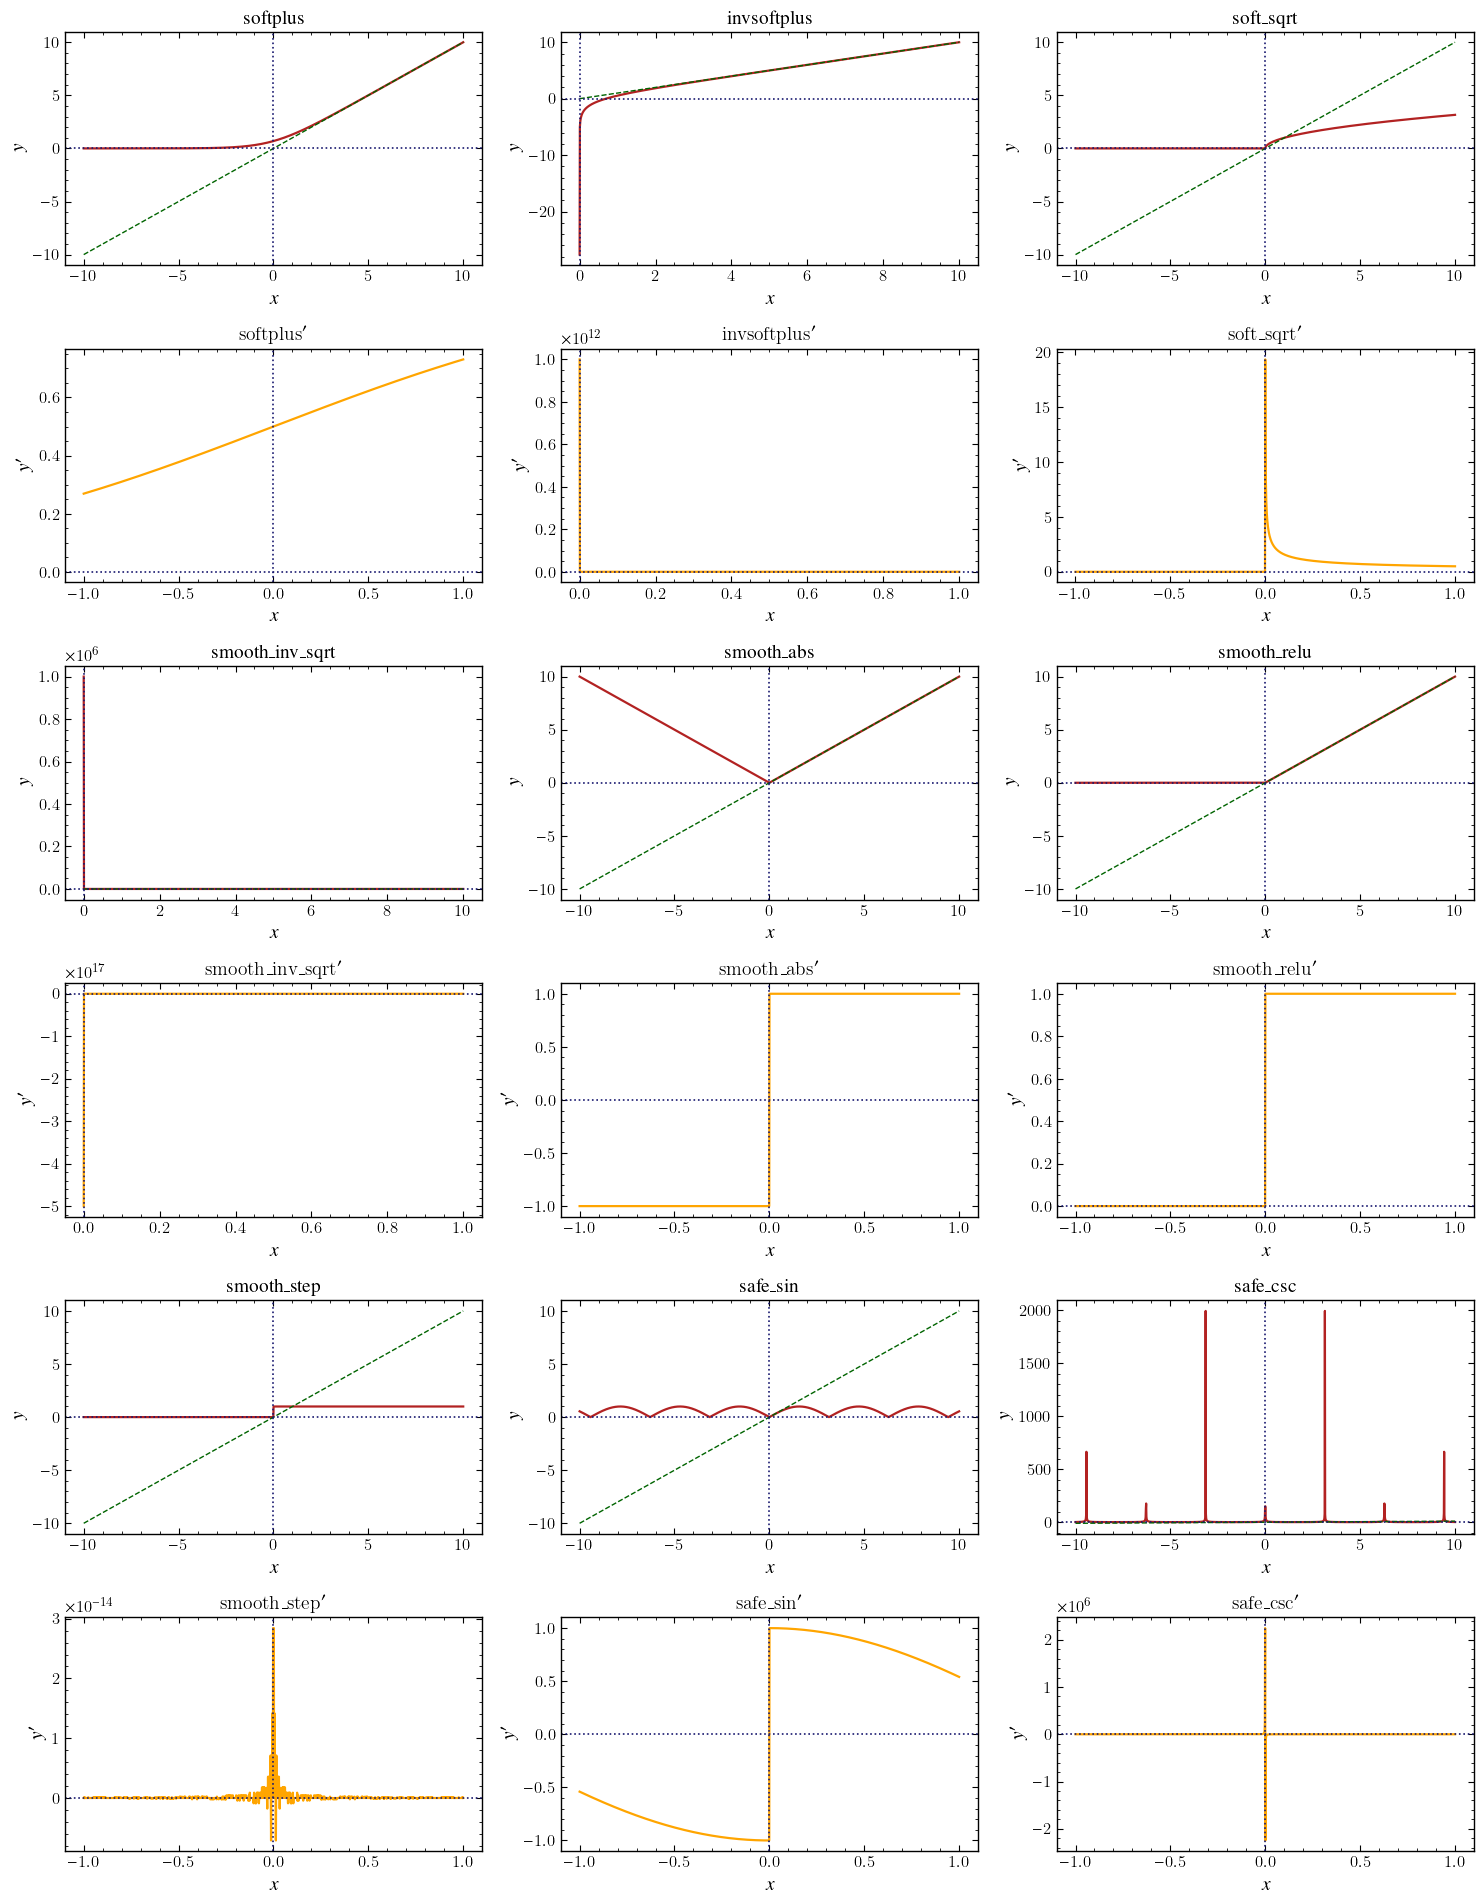

In [3]:
# ------------------------------
# Put your funcs dict here
# ------------------------------
funcs = OrderedDict(
    "softplus"        => softplus,
    "invsoftplus"     => invsoftplus,
    "soft_sqrt"       => soft_sqrt,
    "smooth_inv_sqrt" => smooth_inv_sqrt,
    "smooth_abs"      => smooth_abs,
    "smooth_relu"     => smooth_relu,
    "smooth_step"     => smooth_step,
    "safe_sin"        => safe_sin,
    "safe_csc"        => safe_csc
)

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.", (0,(3,1,1,1)), (0,(5,2)), (0,(1,1))]
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

const X_FULL_F   = range(-10.0, 10.0, length=1500)
const X_POS_F    = range(1e-12, 10.0, length=1500)  # positive-only (avoid 0)
const X_FULL_DF  = range(-1.0, 1.0, length=1500)
const X_POS_DF   = range(1e-12, 1.0, length=1500)

# Choose x-grid per function and per plot-type (:f or :df)
function xgrid_for(fname::AbstractString, kind::Symbol)
    if kind === :f
        return fname in ("invsoftplus", "smooth_inv_sqrt") ? X_POS_F : X_FULL_F
    elseif kind === :df
        return fname in ("invsoftplus", "smooth_inv_sqrt") ? X_POS_DF : X_FULL_DF
    else
        error("Unknown kind = $kind")
    end
end

@inline function safe_eval(f, x)
    try
        y = f(x)
        return isfinite(y) ? y : NaN
    catch
        return NaN
    end
end

@inline function safe_derivative(f, x)
    try
        y = ForwardDiff.derivative(f, x)
        return isfinite(y) ? y : NaN
    catch
        return NaN
    end
end

# ------------------------------
# Layout: one row of f, one row of f' per "block"
# Grid: 3 columns, rows = 2 * ceil(N/3)
# ------------------------------
fn_names = collect(keys(funcs))
N_f      = length(fn_names)
n_cols   = 3
n_blocks = cld(N_f, n_cols)          # number of rows of functions
n_rows   = 2 * n_blocks            # each block has f row + f' row

fig_w = 5.0
fig_h = 3.2
fig = figure(figsize=(n_cols * fig_w, n_rows * fig_h))
gs  = fig.add_gridspec(n_rows, n_cols)

# A tiny helper to get subplot by (row, col) in 1-based indexing
ax_at(r, c) = fig.add_subplot(gs[r, c])

for k in 1:N_f
    fname = fn_names[k]
    f     = funcs[fname]

    # Position in grid (block row, column)
    block = cld(k, n_cols)          # 1..n_blocks
    col   = (k - 1) % n_cols + 1    # 1..n_cols

    # Top row in block: function
    r_f  = 2 * (block - 1) + 1
    ax_f = ax_at(r_f, col)

    x_f  = xgrid_for(fname, :f)
    y_f  = [safe_eval(f, x) for x in x_f]

    # plot f
    ax_f.plot(x_f, y_f, color="firebrick", lw=1.6)
    # identity line for context (only makes sense when x spans negatives too, but harmless)
    ax_f.plot(x_f, x_f, color="darkgreen", lw=1.0, ls="--")
    ax_f.axhline(0.0, color="midnightblue", ls=":")
    ax_f.axvline(0.0, color="midnightblue", ls=":")
    ax_f.set_title(fname)
    ax_f.set_xlabel(L"x")
    ax_f.set_ylabel(L"y")

    # Bottom row in block: derivative
    r_df  = r_f + 1
    ax_df = ax_at(r_df, col)

    x_df  = xgrid_for(fname, :df)
    y_df  = [safe_derivative(f, x) for x in x_df]

    ax_df.plot(x_df, y_df, color="orange", lw=1.6)
    ax_df.axhline(0.0, color="midnightblue", ls=":")
    ax_df.axvline(0.0, color="midnightblue", ls=":")

    latex_name = "\\mathrm{" * replace(fname, "_" => "\\_") * "}^\\prime"
    ax_df.set_title("\$" * latex_name * "\$")
    ax_df.set_xlabel(L"x")
    ax_df.set_ylabel(L"y'")
end

# Turn off unused axes (if N_f is not a multiple of n_cols)
# (We created axes only for k=1:N_f, so nothing extra to hide here.)

fig.tight_layout()
savefig("./Figures/Tests/Fig1-Smoothing-Functions-And-Derivatives.png", dpi=150)

In [4]:
###########################################################################################
# Base Kerr-Hayward (ZM4) Metric Functions in the Johannsen Form [See Walia et al., 2025]
###########################################################################################

@inline function Delta(r, metric_params)  # Trading N for delta
    a, L = metric_params

    r2 = r*r
    r3 = r2*r
    r4 = r2*r2

    L2 = L*L
    L4 = L2*L2

    denom = r4 + oftype(r, 2) * L4
    invden = inv(denom)

    return (one(r) - oftype(r, 2) * r3 * invden) * r2 + a*a
end

@inline function F(r, metric_params)  # This F is not the KN25 F
    a, _ = metric_params
    return r / (r*r + a*a)
end

@inline function f(r, _metric_params)  # This f is not the KN25 f
    return zero(r)
end

f (generic function with 1 method)

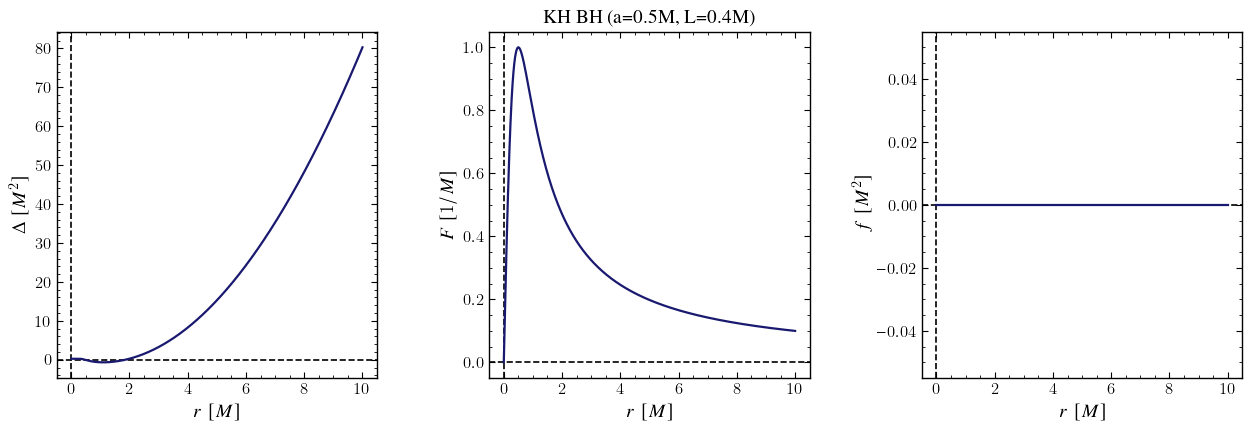

In [5]:
a_Val = 0.5
L_Val = 0.4

Delta_List = []
F_List = []
f_List = []

r_List = range(0., 10., length=1000)
 
for (r, r_Val) in enumerate(r_List)
    push!(Delta_List, Delta(r_Val, (a_Val, L_Val)))
    push!(F_List, F(r_Val, (a_Val, L_Val)))
    push!(f_List, f(r_Val, (a_Val, L_Val)))
end

###########################################################################################
# Figure
###########################################################################################

colors    = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]

linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows = 1
n_cols = 3

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "delta" => fig.add_subplot(gs[1,1]),
    "F" => fig.add_subplot(gs[1,2]),
    "f" => fig.add_subplot(gs[1,3])
)

# Left Panel

axes["delta"].set(xlabel=L"$r\ [M]$", ylabel=L"\Delta\ [M^2]")

axes["delta"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["delta"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

axes["delta"].plot(r_List, Delta_List, color=colors[2], lw=linewidths[3])

# Middle Panel

axes["F"].set(xlabel=L"$r\ [M]$", ylabel=L"F\ [1/M]")

axes["F"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["F"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

axes["F"].plot(r_List, F_List, color=colors[2], lw=linewidths[3])

axes["F"].set_title("KH BH (a=0.5M, L=0.4M)")

# Right Panel

axes["f"].set(xlabel=L"$r\ [M]$", ylabel=L"f\ [M^2]")

axes["f"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["f"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

axes["f"].plot(r_List, f_List, color=colors[2], lw=linewidths[3])

subplots_adjust(wspace=0.35, hspace=0.25)
savefig("./Figures/Tests/Fig2-KH-Metric-Functions.png", dpi=150)

In [6]:
###########################################################################################
# Horizon Radius
###########################################################################################

function rH(metric_params; umin=-10.0, umax=10.0, ngrid=1000, xtol=TOL_SOLVE, f_tol=TOL_SOLVE, dedup_tol=EPS_GEOM)

    # Choose a working scalar type from inputs (keeps Double64 if metric_params is Double64)
    T = promote_type(typeof(metric_params[1]), typeof(metric_params[2]),
                     typeof(xtol), typeof(f_tol), typeof(dedup_tol))

    uminT      = T(umin)
    umaxT      = T(umax)
    xtolT      = T(xtol)
    f_tolT     = T(f_tol)
    dedup_tolT = T(dedup_tol)

    froot(u) = Delta(softplus(u), metric_params)

    us    = range(uminT, umaxT; length=ngrid)  # typed range
    found = T[]

    uprev = first(us)
    fprev = froot(uprev)

    for u in Iterators.rest(us)
        fnow = froot(u)

        if isfinite(fprev) && abs(fprev) ≤ f_tolT
            r_sol = softplus(uprev)
            if isfinite(r_sol) && all(x -> abs(x - r_sol) > dedup_tolT, found)
                push!(found, r_sol)
            end

        elseif isfinite(fprev) && isfinite(fnow) && (fprev * fnow < zero(T))
            r_sol = try
                u_sol = find_zero(froot, (uprev, u); method=:brent, xtol=xtolT)
                softplus(u_sol)
            catch
                nothing
            end
            if r_sol !== nothing && isfinite(r_sol) && all(x -> abs(x - r_sol) > dedup_tolT, found)
                push!(found, r_sol)
            end
        end

        uprev, fprev = u, fnow
    end

    isempty(found) && return T(NaN)
    return maximum(found)
end

# rH cacheing

_is_ad_type(x) = x isa ForwardDiff.Dual
_is_ad_type(mp::Tuple) = any(_is_ad_type, mp)

const _rH_cache_T = Dict{DataType, Any}()
const _rH_lock    = ReentrantLock()

function _rH_cache_for(::Type{T}) where {T}
    lock(_rH_lock) do
        get!(_rH_cache_T, T) do
            Dict{Tuple{T,T}, T}()
        end
    end
end

function rH_cached(metric_params::Tuple{A,B}) where {A<:Real,B<:Real}
    # For AD: don't cache, but DO NOT downcast (keeps Duals / higher precision)
    _is_ad_type(metric_params) && return rH(metric_params)

    T = promote_type(A, B)
    mpT = (T(metric_params[1]), T(metric_params[2]))
    cache = _rH_cache_for(T)

    lock(_rH_lock) do
        return get!(cache, mpT) do
            rH(mpT)
        end
    end
end

function clear_rH_cache!()
    lock(_rH_lock) do
        empty!(_rH_cache_T)
    end
    return nothing
end

###########################################################################################
# Extremal BHs
###########################################################################################

dDeltadr(  r, metric_params) = ForwardDiff.derivative(rr -> Delta(   rr, metric_params), r)
d2Deltadr2(r, metric_params) = ForwardDiff.derivative(rr -> dDeltadr(rr, metric_params), r)

const L_Max = (TCOMP(27)/TCOMP(32))^(TCOMP(0.25))

function a_Ex(metric_params; x_init=[0.5, 2.0], tol=TOL_SOLVE, nudge=EPS_GEOM, backoff=0.99, max_iter=200)

    mp_in = metric_params
    p = TCOMP(mp_in[2])

    x0      = TCOMP[TCOMP(x_init[1]), TCOMP(x_init[2])]
    tolT    = TCOMP(tol)
    nudgeT  = TCOMP(nudge)
    backoffT = TCOMP(backoff)

    function F!(Fvec, x)
        u_a, u_r = x
        a = softplus(u_a)
        r = softplus(u_r)
        mp = (a, p)
        Fvec[1] = Delta(   r, mp)
        Fvec[2] = dDeltadr(r, mp)
        return nothing
    end

    try
        sol = nlsolve(F!, x0; method=:trust_region, autodiff=:forward, xtol=tolT, ftol=tolT)
        a_sol = softplus(sol.zero[1]) + nudgeT

        if !isfinite(a_sol) || a_sol ≤ zero(a_sol)
            @warn "a_Ex: Solver returned NaN/Inf/nonpositive, fallback used."
            return SAFE_LARGE
        end

        a_try = a_sol
        for _ in 1:max_iter
            r_try = suppress_warnings(() -> rH((a_try, p)))
            if isfinite(r_try) && r_try > zero(r_try)
                return a_try
            end
            a_try *= backoffT
            a_try ≤ nudgeT && break
        end

        @warn "a_Ex: No horizon found after backoff; returning last try."
        return a_try
    catch
        @warn "a_Ex: No convergence, fallback used."
        return SAFE_LARGE
    end
end

function p_Ex(metric_params; x_init=[0.5, 2.0], tol=TOL_SOLVE, nudge=EPS_GEOM, backoff=0.99, max_iter=200)

    mp_in = metric_params
    a = TCOMP(mp_in[1])

    x0      = TCOMP[TCOMP(x_init[1]), TCOMP(x_init[2])]
    tolT    = TCOMP(tol)
    nudgeT  = TCOMP(nudge)
    backoffT = TCOMP(backoff)

    function F!(Fvec, x)
        u_p, u_r = x
        p = softplus(u_p)
        r = softplus(u_r)
        mp = (a, p)
        Fvec[1] = Delta(   r, mp)
        Fvec[2] = dDeltadr(r, mp)
        return nothing
    end

    try
        sol = nlsolve(F!, x0; method=:trust_region, autodiff=:forward, xtol=tolT, ftol=tolT)
        p_sol = softplus(sol.zero[1]) + nudgeT

        if !isfinite(p_sol) || p_sol ≤ zero(p_sol)
            @warn "p_Ex: Solver returned NaN/Inf/nonpositive, fallback used."
            return SAFE_LARGE
        end

        p_try = p_sol
        for _ in 1:max_iter
            r_try = suppress_warnings(() -> rH((a, p_try)))
            if isfinite(r_try) && r_try > zero(r_try)
                return p_try
            end
            p_try *= backoffT
            p_try ≤ nudgeT && break
        end

        @warn "p_Ex: No horizon found after backoff; returning last try."
        return p_try
    catch
        @warn "p_Ex: No convergence, fallback used."
        return SAFE_LARGE
    end
end

p_Ex (generic function with 1 method)

Interpretation tips:
 - abs(Delta_rH) should track tol until it saturates (conditioning/roundoff).
 - newton_err_est ≈ abs(Delta/Delta') is the best single-number estimate of |rH - r*|.
 - slope diagnostics plateau near dDelta_rH for moderate Δ, then peel off near EPS_SMOOTH/EPS_SQRT.
 - tol scaling panel shows how residual and inferred root error respond to solver tol, and where they saturate.


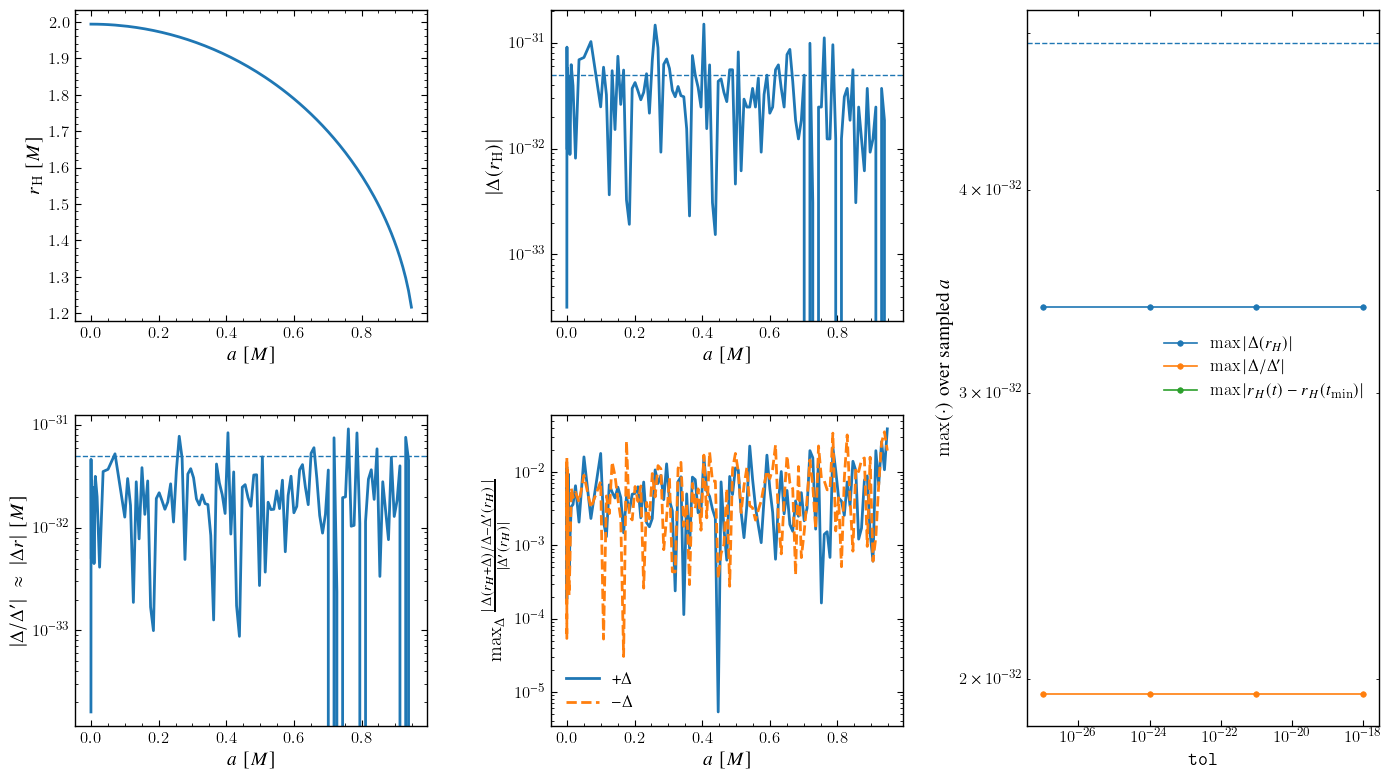

In [7]:
###########################################################################################
# Data
###########################################################################################

L_Val = TCOMP(0.4)

# Sweep a across a wide dynamic range:
a_list_low  = TCOMP(10) .^ range(log10(EPS_SQRT), log10(TCOMP(0.1)), length=100)
a_list_high = range(TCOMP(0.1), a_Ex((TCOMP(0.0), L_Val)), length=101)[2:end]
a_Vals      = vcat(a_list_low, a_list_high)

# Finite-difference steps Δ for the slope/linearity diagnostic
# (plateau then roundoff peel-off)
Delta_LIST = TCOMP[
    1e-6, 1e-8, 1e-10,
    TOL_SOLVE,
    EPS_SMOOTH,
    EPS_SQRT
]

###########################################################################################
# Horizon root accuracy diagnostics (at fixed solver tol = TOL_SOLVE)
###########################################################################################

rH_Vals         = TCOMP[]
Delta_rH_Vals   = TCOMP[]
dDelta_rH_Vals  = TCOMP[]
newton_err_Vals = TCOMP[]   # ≈ |Delta/Delta'| effective |Δr|

slope_plus  = Dict(Δ => TCOMP[] for Δ in Delta_LIST)   # Δ(rH+Δ)/Δ
slope_minus = Dict(Δ => TCOMP[] for Δ in Delta_LIST)   # Δ(rH-Δ)/(-Δ)

for a_Val in a_Vals
    mp_Val = (a_Val, L_Val)

    rH_Val = rH(mp_Val; xtol=TOL_SOLVE, f_tol=TOL_SOLVE, dedup_tol=EPS_GEOM)
    push!(rH_Vals, rH_Val)

    Delta0  = Delta(   rH_Val, mp_Val)
    dDelta0 = dDeltadr(rH_Val, mp_Val)

    push!(Delta_rH_Vals,  Delta0)
    push!(dDelta_rH_Vals, dDelta0)

    err = (isfinite(Delta0) && isfinite(dDelta0) && abs(dDelta0) > zero(dDelta0)) ? abs(Delta0 / dDelta0) : TCOMP(NaN)
    push!(newton_err_Vals, err)

    for Δ in Delta_LIST
        Deltap = Delta(rH_Val + Δ, mp_Val)
        Deltam = Delta(rH_Val - Δ, mp_Val)
        push!(slope_plus[ Δ], Deltap / (+Δ))
        push!(slope_minus[Δ], Deltam / (-Δ))
    end
end

###########################################################################################
# Upgrade: error scaling with solver tolerance (vary xtol=f_tol=t)
###########################################################################################

# A tolerance ladder for Double64. Feel free to tweak the endpoints.
TOL_LIST = TCOMP[
    1e-18, 1e-21, 1e-24, 1e-27
]

# Choose a representative subset of a values for the tol sweep (keeps runtime reasonable)
# - include endpoints + a few midpoints spaced across the list
idxs = unique!(sort!(vcat(1, length(a_Vals),
                          round.(Int, range(1, length(a_Vals); length=8)))))

a_sub = a_Vals[idxs]

# Store tol-sweep results in matrices: rows = a_sub, cols = TOL_LIST
nA  = length(a_sub)
nT  = length(TOL_LIST)

rH_tol      = Matrix{TCOMP}(undef, nA, nT)
resid_tol   = Matrix{TCOMP}(undef, nA, nT)   # |Delta(rH)|
newterr_tol = Matrix{TCOMP}(undef, nA, nT)   # |Delta/Delta'| ≈ |Δr|

for (j, tol) in enumerate(TOL_LIST)
    for (i, a_Val) in enumerate(a_sub)
        mp = (a_Val, L_Val)
        rH_Val = rH(mp; xtol=tol, f_tol=tol, dedup_tol=EPS_GEOM)

        rH_tol[i, j] = rH_Val

        Δ0  = Delta(rH_Val, mp)
        dΔ0 = dDeltadr(rH_Val, mp)

        resid_tol[i, j] = abs(Δ0)
        newterr_tol[i, j] = (isfinite(Δ0) && isfinite(dΔ0) && abs(dΔ0) > zero(dΔ0)) ? abs(Δ0 / dΔ0) : TCOMP(NaN)
    end
end

# A second notion of "error vs tol": compare rH(tol) to the tightest run (last column)
# This is useful when Δ/Δ' is noisy near extremality.
rH_ref = view(rH_tol, :, nT)
diff_to_ref = abs.(rH_tol .- rH_ref)   # includes a zero column at the end

###########################################################################################
# Write CSV (Float64 boundary for I/O)
###########################################################################################

df = DataFrame(
    a              = Float64.(a_Vals),
    rH             = Float64.(rH_Vals),
    Delta_rH       = Float64.(Delta_rH_Vals),
    dDelta_rH      = Float64.(dDelta_rH_Vals),
    newton_err_est = Float64.(newton_err_Vals)
)

tagify(Δ) = replace(replace(@sprintf("%.0e", Float64(Δ)), "." => "p"), "-" => "m")

for Δ in Delta_LIST
    tag = tagify(Δ)
    df[!, "slope_plus_"  * tag] = Float64.(slope_plus[ Δ])
    df[!, "slope_minus_" * tag] = Float64.(slope_minus[Δ])
end

# Add tol-sweep summary columns: max over a_sub (and also store per-a_sub in a second DF below)
for (j, tol) in enumerate(TOL_LIST)
    tag = tagify(tol)
    df[!, "tol_sweep_dummy_" * tag] = fill(NaN, nrow(df))  # placeholder to keep one CSV; see df_tol below
end

out_csv = "./Data/Tests/Fig3-Horizon-Root-Accuracy.csv"
CSV.write(out_csv, df)

# Dedicated CSV for tol sweep (more useful)
df_tol = DataFrame(a = Float64.(a_sub))
for (j, tol) in enumerate(TOL_LIST)
    tag = tagify(tol)
    df_tol[!, "resid_" * tag]   = Float64.(resid_tol[:, j])
    df_tol[!, "newterr_" * tag] = Float64.(newterr_tol[:, j])
    df_tol[!, "dr_ref_" * tag]  = Float64.(diff_to_ref[:, j])
end

out_csv_tol = "./Data/Tests/Fig3b-Horizon-Error-vs-Tol.csv"
CSV.write(out_csv_tol, df_tol)

###########################################################################################
# Plotting Begins
###########################################################################################

function slope_cols(df::DataFrame, prefix::String)
    return sort(filter(nm -> startswith(nm, prefix), String.(names(df))))
end

function cols_to_mat(df::DataFrame, colnames::Vector{String})
    n = nrow(df)
    m = length(colnames)
    M = Array{Float64}(undef, n, m)
    for (j, nm) in enumerate(colnames)
        M[:, j] .= df[!, nm]
    end
    return M
end

dfp = CSV.read(out_csv, DataFrame)

a_plot         = Vector{Float64}(dfp.a)
rH_plot        = Vector{Float64}(dfp.rH)
Delta_rH_plot  = Vector{Float64}(dfp.Delta_rH)
dDelta_rH_plot = Vector{Float64}(dfp.dDelta_rH)
err_plot       = Vector{Float64}(dfp.newton_err_est)

plus_cols  = slope_cols(dfp, "slope_plus_")
minus_cols = slope_cols(dfp, "slope_minus_")

Splus  = cols_to_mat(dfp, plus_cols)
Sminus = cols_to_mat(dfp, minus_cols)

# Relative deviation from Delta'(rH)
floor_d = Float64(EPS_ROUNDOFF)
rel_plus  = abs.(Splus  .- dDelta_rH_plot) ./ max.(abs.(dDelta_rH_plot), floor_d)
rel_minus = abs.(Sminus .- dDelta_rH_plot) ./ max.(abs.(dDelta_rH_plot), floor_d)

max_rel_plus  = vec(maximum(rel_plus,  dims=2))
max_rel_minus = vec(maximum(rel_minus, dims=2))

# Read tol sweep
dft = CSV.read(out_csv_tol, DataFrame)
a_sub_plot = Vector{Float64}(dft.a)

# For the tol sweep plot, summarize by taking max over a_sub:
resid_max   = Float64[]
newterr_max = Float64[]
drref_max   = Float64[]

for tol in TOL_LIST
    tag = tagify(tol)
    push!(resid_max,   maximum(abs.(Vector{Float64}(dft[!, "resid_" * tag]))))
    push!(newterr_max, maximum(abs.(Vector{Float64}(dft[!, "newterr_" * tag]))))
    push!(drref_max,   maximum(abs.(Vector{Float64}(dft[!, "dr_ref_" * tag]))))
end

tol_plot = Float64.(TOL_LIST)

###########################################################################################
# Figure
###########################################################################################

n_rows, n_cols = 2, 3
fig = figure(figsize=(n_cols*fig_width*1.65, n_rows*fig_height*1.55))

# Use subplot2grid to avoid GridSpec slicing issues with PyObject/Colon
ax_rH  = PyPlot.subplot2grid((n_rows, n_cols), (0, 0), fig=fig)
ax_res = PyPlot.subplot2grid((n_rows, n_cols), (0, 1), fig=fig)
ax_err = PyPlot.subplot2grid((n_rows, n_cols), (1, 0), fig=fig)
ax_lin = PyPlot.subplot2grid((n_rows, n_cols), (1, 1), fig=fig)

# Tol scaling occupies full right column (rowspan=2)
ax_tol = PyPlot.subplot2grid((n_rows, n_cols), (0, 2), rowspan=2, fig=fig)

# (1) rH(a)
ax_rH.set(xlabel=L"$a\ [M]$", ylabel=L"$r_{\rm H}\ [M]$")
ax_rH.plot(a_plot, rH_plot, lw=2)

# (2) residual |Delta(rH)|
ax_res.set(xlabel=L"$a\ [M]$", ylabel=L"$|\Delta(r_{\rm H})|$")
ax_res.set_yscale("log")
ax_res.plot(a_plot, abs.(Delta_rH_plot), lw=2)
ax_res.axhline(Float64(EPS_ROUNDOFF), ls="--", lw=1)

# (3) Newton error estimate |Delta/Delta'|
ax_err.set(xlabel=L"$a\ [M]$", ylabel=L"$|\Delta/\Delta'|\ \approx\ |\Delta r|\ [M]$")
ax_err.set_yscale("log")
ax_err.plot(a_plot, err_plot, lw=2)
ax_err.axhline(Float64(EPS_ROUNDOFF), ls="--", lw=1)

# (4) Linearity diagnostic: max relative deviation of slope from dDelta/dr at rH
ax_lin.set(
    xlabel=L"$a\ [M]$",
    ylabel=L"$\max_\Delta \frac{|\,\Delta(r_H+\Delta)/\Delta-\Delta'(r_H)\,|}{|\Delta'(r_H)|}$"
)
ax_lin.set_yscale("log")
ax_lin.plot(a_plot, max_rel_plus,  lw=2, label=L"$+\Delta$")
ax_lin.plot(a_plot, max_rel_minus, lw=2, ls="--", label=L"$-\Delta$")
ax_lin.legend(frameon=false)

# (5) Error scaling with solver tolerance
ax_tol.set(xlabel=L"${\tt tol}$", ylabel=L"$\max(\cdot)$ over sampled $a$")
ax_tol.set_xscale("log")
ax_tol.set_yscale("log")

ax_tol.plot(tol_plot, resid_max,   marker="o", label=L"$\max |\Delta(r_H)|$")
ax_tol.plot(tol_plot, newterr_max, marker="o", label=L"$\max |\Delta/\Delta'|$")
ax_tol.plot(tol_plot, drref_max,   marker="o", label=L"$\max |r_H(t)-r_H(t_{\min})|$")

ax_tol.axhline(Float64(EPS_ROUNDOFF), ls="--", lw=1)
ax_tol.legend(frameon=false)

subplots_adjust(wspace=0.35, hspace=0.30)

out_png = "./Figures/Tests/Fig3-Horizon-Root-Accuracy.png"
savefig(out_png, dpi=150)

println("Interpretation tips:")
println(" - abs(Delta_rH) should track tol until it saturates (conditioning/roundoff).")
println(" - newton_err_est ≈ abs(Delta/Delta') is the best single-number estimate of |rH - r*|.")
println(" - slope diagnostics plateau near dDelta_rH for moderate Δ, then peel off near EPS_SMOOTH/EPS_SQRT.")
println(" - tol scaling panel shows how residual and inferred root error respond to solver tol, and where they saturate.")

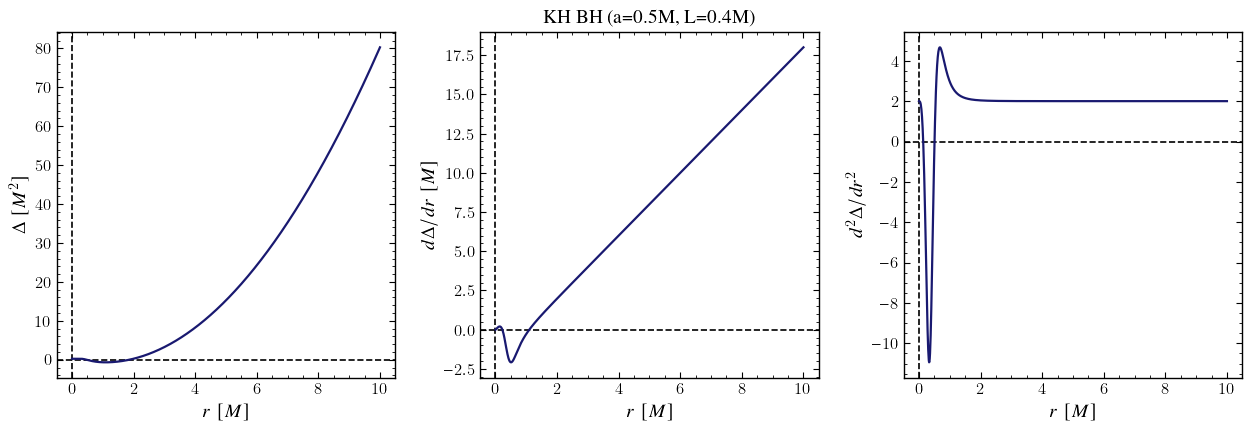

In [8]:
a_Val = 0.5
L_Val = 0.4

Delta_List      = []
dDeltadr_List   = []
d2Deltadr2_List = []

r_List = range(0., 10., length=1000)
 
for (r, r_Val) in enumerate(r_List)
    push!(Delta_List,      Delta(     r_Val, (a_Val, L_Val)))
    push!(dDeltadr_List,   dDeltadr(  r_Val, (a_Val, L_Val)))
    push!(d2Deltadr2_List, d2Deltadr2(r_Val, (a_Val, L_Val)))
end

###########################################################################################
# Figure
###########################################################################################

colors    = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]

linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows = 1
n_cols = 3

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "Delta"      => fig.add_subplot(gs[1,1]),
    "dDeltadr"   => fig.add_subplot(gs[1,2]),
    "d2Deltadr2" => fig.add_subplot(gs[1,3])
)

# Left Panel

axes["Delta"].set(xlabel=L"$r\ [M]$", ylabel=L"\Delta\ [M^2]")

axes["Delta"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["Delta"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

axes["Delta"].plot(r_List, Delta_List, color=colors[2], lw=linewidths[3])

# Middle Panel

axes["dDeltadr"].set(xlabel=L"$r\ [M]$", ylabel=L"d\Delta/dr\ [M]")

axes["dDeltadr"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["dDeltadr"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

axes["dDeltadr"].plot(r_List, dDeltadr_List, color=colors[2], lw=linewidths[3])

axes["dDeltadr"].set_title("KH BH (a=0.5M, L=0.4M)")

# Right Panel

axes["d2Deltadr2"].set(xlabel=L"$r\ [M]$", ylabel=L"d^2\Delta/dr^2")

axes["d2Deltadr2"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["d2Deltadr2"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

axes["d2Deltadr2"].plot(r_List, d2Deltadr2_List, color=colors[2], lw=linewidths[3])

subplots_adjust(wspace=0.25, hspace=0.25)
savefig("./Figures/Tests/Fig4-KH-Metric-Delta-and-Derivatives.png", dpi=150)

┌ Warning: p_Ex: No horizon found after backoff; returning last try.
└ @ Main In[6]:186
┌ Warning: a_Ex: No horizon found after backoff; returning last try.
└ @ Main In[6]:139


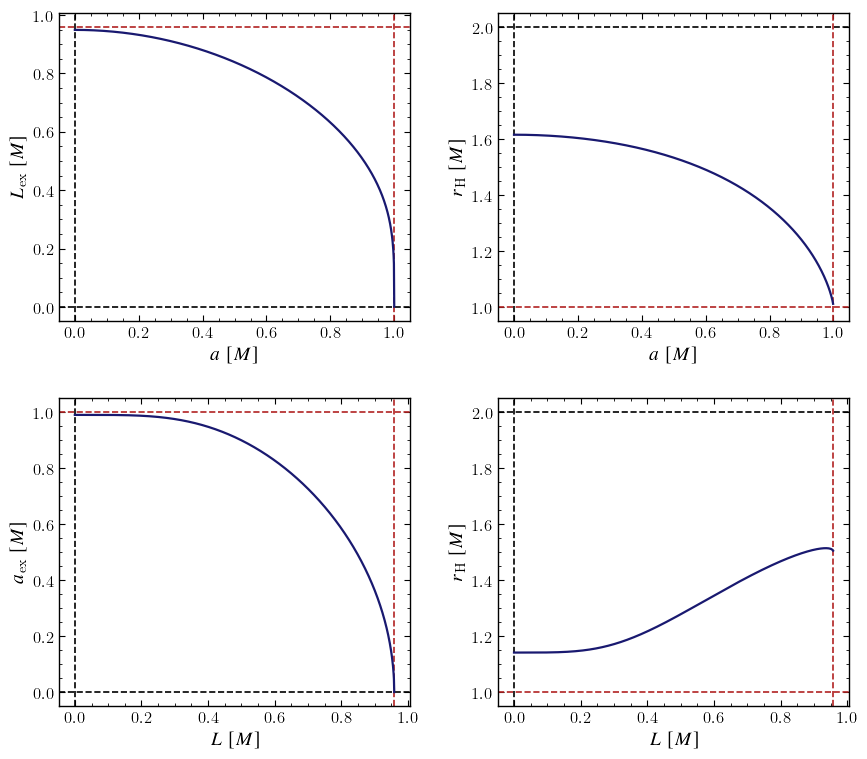

In [9]:
a_List = range(1e-8, 1.0-1e-8, length=1000)

L_Ex_List    = []
rH_L_Ex_List = []
 
for (i, a_Val) in enumerate(a_List)
    L_Ex_Val = p_Ex((a_Val, 0.5))
    push!(L_Ex_List, L_Ex_Val)
    rH_Val = rH((a_Val, L_Ex_Val))
    push!(rH_L_Ex_List, rH_Val)
end

L_List = range(1e-8, L_Max, length=1000)

a_Ex_List    = []
rH_a_Ex_List = []
 
for (i, L_Val) in enumerate(L_List)
    a_Ex_Val = a_Ex((0.5, L_Val))
    push!(a_Ex_List, a_Ex_Val)
    rH_Val = rH((a_Ex_Val, L_Val))
    push!(rH_a_Ex_List, rH_Val)
end

###########################################################################################
# Figure
###########################################################################################

colors    = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]

linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows = 2
n_cols = 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "L_Ex"    => fig.add_subplot(gs[1,1]),
    "rH_L_Ex" => fig.add_subplot(gs[1,2]),
    "a_Ex"    => fig.add_subplot(gs[2,1]),
    "rH_a_Ex" => fig.add_subplot(gs[2,2])
)

# Top-Left Panel

# axes["L_Ex"].set_title("Extremal KH BHs")
axes["L_Ex"].set(xlabel=L"$a\ [M]$", ylabel=L"L_{\rm ex}\ [M]")

axes["L_Ex"].axvline(x=0.0, color=colors[1], ls=linestyles[2])
axes["L_Ex"].axhline(y=0.0, color=colors[1], ls=linestyles[2])

axes["L_Ex"].axvline(x=1.0,   color=colors[4], ls=linestyles[2])
axes["L_Ex"].axhline(y=L_Max, color=colors[4], ls=linestyles[2])

axes["L_Ex"].plot(a_List, L_Ex_List, color=colors[2], lw=linewidths[3])

# Top-Right Panel

axes["rH_L_Ex"].set(xlabel=L"$a\ [M]$", ylabel=L"r_{\rm H}\ [M]")

axes["rH_L_Ex"].axvline(x=0.0, color=colors[1], ls=linestyles[2])
axes["rH_L_Ex"].axhline(y=2.0, color=colors[1], ls=linestyles[2])

axes["rH_L_Ex"].axvline(x=1.0, color=colors[4], ls=linestyles[2])
axes["rH_L_Ex"].axhline(y=1.0, color=colors[4], ls=linestyles[2])

axes["rH_L_Ex"].plot(a_List, rH_L_Ex_List, color=colors[2], lw=linewidths[3])

# Bottom-Left Panel

# axes["a_Ex"].set_title("Extremal KH BHs")
axes["a_Ex"].set(xlabel=L"$L\ [M]$", ylabel=L"a_{\rm ex}\ [M]")

axes["a_Ex"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["a_Ex"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

axes["a_Ex"].axhline(y=1.0,   color=colors[4], ls=linestyles[2])
axes["a_Ex"].axvline(x=L_Max, color=colors[4], ls=linestyles[2])

axes["a_Ex"].plot(L_List, a_Ex_List, color=colors[2], lw=linewidths[3])

# Bottom-Right Panel

axes["rH_a_Ex"].set(xlabel=L"$L\ [M]$", ylabel=L"r_{\rm H}\ [M]")

axes["rH_a_Ex"].axvline(x=0.0, color=colors[1], ls=linestyles[2])
axes["rH_a_Ex"].axhline(y=2.0, color=colors[1], ls=linestyles[2])

axes["rH_a_Ex"].axvline(x=L_Max, color=colors[4], ls=linestyles[2])
axes["rH_a_Ex"].axhline(y=1.0,   color=colors[4], ls=linestyles[2])

axes["rH_a_Ex"].plot(L_List, rH_a_Ex_List, color=colors[2], lw=linewidths[3])

subplots_adjust(wspace=0.25, hspace=0.25)
savefig("./Figures/Tests/Fig5-KH-Extremal-Curves.png", dpi=150)

┌ Warning: p_Ex: No horizon found after backoff; returning last try.
└ @ Main In[6]:186


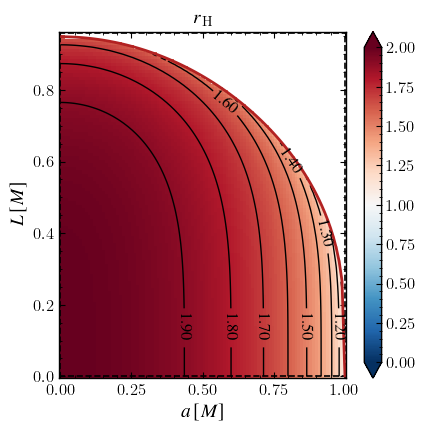

In [10]:
using PyPlot
using PyCall
np = pyimport("numpy")

a_List = collect(range(1e-8, 1.0-1e-8, length=100))
L_List = collect(range(1e-8, L_Max,    length=100))

L_Ex_List = Vector{Float64}(undef, length(a_List))
rH_List   = fill(NaN, length(L_List), length(a_List))  # NOTE: shape (len(L), len(a))

@inbounds for (i, a_Val) in enumerate(a_List)
    L_Ex_Val = p_Ex((a_Val, 0.5))
    L_Ex_List[i] = L_Ex_Val
    
    for (j, L_Val) in enumerate(L_List)
        if L_Val <= L_Ex_Val
            rH_List[j, i] = rH((a_Val, L_Val))
        end
    end
end

mask = np.isnan(rH_List)
rH_masked = np.ma.array(rH_List, mask=mask)

###########################################################################################
# Figure
###########################################################################################
colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 1, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "rH" => fig.add_subplot(gs[1,1])
)

axes["rH"].set_title(L"r_{\rm H}")
axes["rH"].set_xlabel(L"a [M]")
axes["rH"].set_ylabel(L"L [M]")

axes["rH"].axvline(x=0.0,   color="black", linestyle="--")
axes["rH"].axvline(x=1.0,   color="black", linestyle="--")
axes["rH"].axhline(y=0.0,   color="black", linestyle="--")
axes["rH"].axhline(y=L_Max, color="black", linestyle="--")

cp_rH = axes["rH"].pcolormesh(a_List, L_List, rH_masked; cmap="RdBu_r", vmin=0, vmax=2.0, shading="auto")

cl_rH = axes["rH"].contour(a_List, L_List, rH_masked; levels=10, colors="k", linewidths=1.0)
axes["rH"].clabel(cl_rH; inline=true, fmt="%.2f")

axes["rH"].plot(a_List, L_Ex_List, color="firebrick", linewidth=2.0)

fig.colorbar(cp_rH, ax=axes["rH"], extend="both")
savefig("./Figures/Tests/Fig6-KH-Horizon-Radius.png", dpi=150)

Of all the metric functions, only N goes to zero (because delta vanishes at the horizon). This causes g^rr to blow up. 

More importantly, some of the effective potentials diverge.

Typically, this is not cause for concern because we are can set a lax bound on how close a photon can get to the horizon.

However, since the focus here is on the inner shadow, we must be careful.

Our approach is to not regularize r within these functions but to do it before entering them.

This is because regularizing within them will be costly (we will need to eValuate rH every time).

We have opted for a soft-floor of 10*RES16

In [11]:
###########################################################################################
# Remaining Johannsen Metric Functions Form (Defined in terms of Delta, F, f above)
###########################################################################################

@inline function N(r, metric_params)
    Fv = F(r, metric_params)
    return Fv * soft_sqrt(Delta(r, metric_params))
end

@inline function B(r, metric_params)
    return F(r, metric_params) * r
end

@inline function Σ(r, th, metric_params)
    a, _ = metric_params
    c = cos(th)
    u = c*c
    return r*r + f(r, metric_params) + (a*a) * u
end

@inline function Π(r, th, metric_params)
    a, _ = metric_params
    c = cos(th)
    u = c*c
    return r - F(r, metric_params) * (a*a) * (one(r) - u)
end

###########################################################################################
# First-Order Radial Derivatives of the Metric Functions
###########################################################################################

# F is analytic: F(r) = r/(r^2 + a^2)
@inline function dFdr(r, metric_params)
    a, _ = metric_params
    den = r*r + a*a
    return (a*a - r*r) / (den*den)
end

# B(r) = r*F(r) => B = r^2/(r^2+a^2)
@inline function dBdr(r, metric_params)
    a, _ = metric_params
    den = r*r + a*a
    return (oftype(r, 2) * r * a*a) / (den*den)
end

# Keep AD for N (nontrivial due to Delta + soft_sqrt)
dNdr(r, mp)  = ForwardDiff.derivative(rr -> N(rr, mp), r)

###########################################################################################
# Second-Order Radial Derivatives of the Metric Functions
###########################################################################################

@inline function d2Fdr2(r, metric_params)
    a, _ = metric_params
    den = r*r + a*a
    # d/dr [(a^2 - r^2)/den^2] = -2r/den^2 - 4r(a^2 - r^2)/den^3
    return (-oftype(r, 2) * r) / (den*den) - (oftype(r, 4) * r * (a*a - r*r)) / (den*den*den)
end

@inline function d2Bdr2(r, metric_params)
    a, _ = metric_params
    den = r*r + a*a
    # d/dr [ 2 r a^2 / den^2 ] = 2a^2/den^2 - 8 r^2 a^2 / den^3
    return (oftype(r, 2) * a*a) / (den*den) - (oftype(r, 8) * r*r * a*a) / (den*den*den)
end

d2Ndr2(r, mp) = ForwardDiff.derivative(rr -> dNdr(rr, mp), r)

###########################################################################################
# Metric Function Aggregator
###########################################################################################

function metric_funcs(r, metric_params)
    Fv   = F(r, metric_params)
    dFv  = dFdr(r, metric_params)
    d2Fv = d2Fdr2(r, metric_params)

    Nv   = N(r, metric_params)
    dNv  = dNdr(r, metric_params)
    d2Nv = d2Ndr2(r, metric_params)

    Bv   = B(r, metric_params)
    dBv  = dBdr(r, metric_params)
    d2Bv = d2Bdr2(r, metric_params)

    return (Fv, dFv, d2Fv, Nv, dNv, d2Nv, Bv, dBv, d2Bv)
end

metric_funcs (generic function with 1 method)

Check that the KH metric functions are smooth and real-Valued outside the horizon 

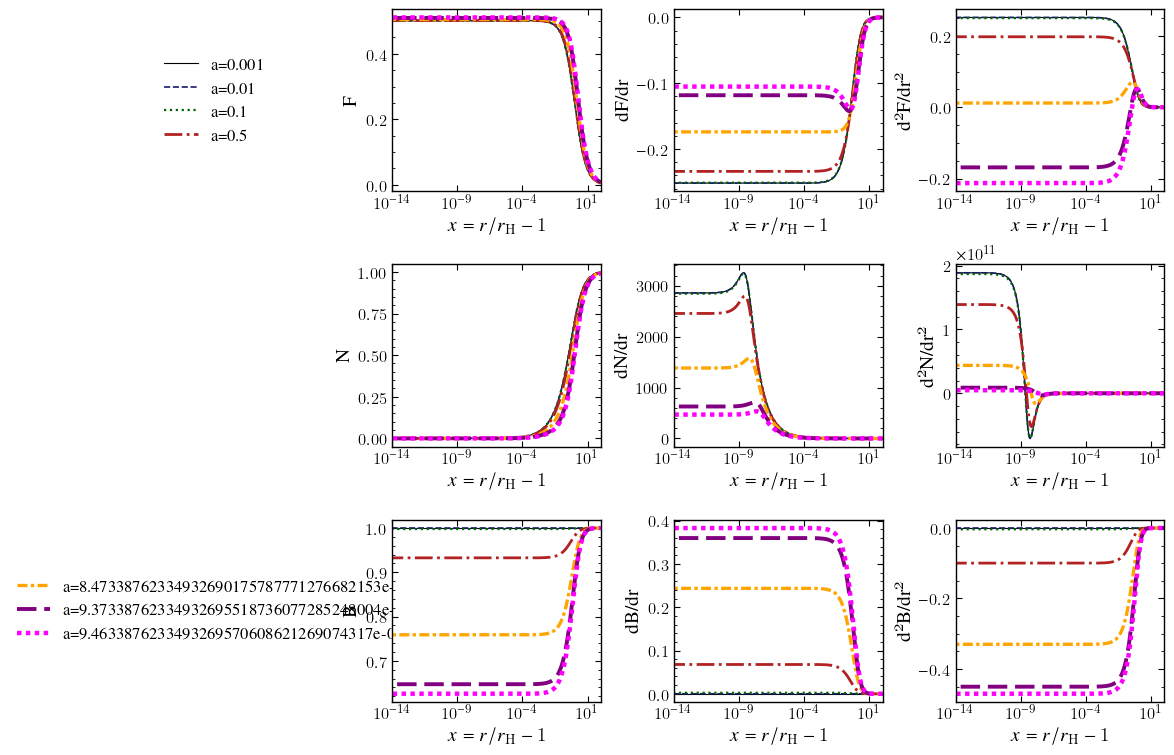

In [12]:
###########################################################################################
# Data
###########################################################################################

L_Val = 0.4
a_Max_Val = a_Ex((0.0, L_Val))

a_list = [0.001, 0.01, 0.1, 0.5,
          a_Max_Val - 0.1,
          a_Max_Val - 0.01,
          a_Max_Val - 0.001]

list_of_metric_funcs_dfs = DataFrame[]

x_list = 10 .^ range(log10(EPS_ROUNDOFF)+1, stop=2, length=1000)

for a_Val in a_list
    
    r_list = (x_list .+ 1.0) .* rH((a_Val, L_Val))

    Vals = [metric_funcs(r, (a_Val, L_Val)) for r in r_list]

    df = DataFrame(
        x          = x_list,
        F_Val      = getindex.(Vals, 1),
        dFdr_Val   = getindex.(Vals, 2),
        d2Fdr2_Val = getindex.(Vals, 3),
        N_Val      = getindex.(Vals, 4),
        dNdr_Val   = getindex.(Vals, 5),
        d2Ndr2_Val = getindex.(Vals, 6),
        B_Val      = getindex.(Vals, 7),
        dBdr_Val   = getindex.(Vals, 8),
        d2Bdr2_Val = getindex.(Vals, 9)
    )

    push!(list_of_metric_funcs_dfs, df)
end

###########################################################################################
# Figure
###########################################################################################

colors    = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]

linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows = 3
n_cols = 4

fig = figure(figsize=(n_cols*fig_width, n_rows*fig_height))
gs  = fig.add_gridspec(n_rows, n_cols)

colnames = names(list_of_metric_funcs_dfs[1])[2:end]

axes = Dict(
    "leg1"   => fig.add_subplot(gs[1,1]),
    "F"      => fig.add_subplot(gs[1,2]),
    "dFdr"   => fig.add_subplot(gs[1,3]),
    "d2Fdr2" => fig.add_subplot(gs[1,4]),
    "N"      => fig.add_subplot(gs[2,2]),
    "dNdr"   => fig.add_subplot(gs[2,3]),
    "d2Ndr2" => fig.add_subplot(gs[2,4]),
    "leg2"   => fig.add_subplot(gs[3,1]),
    "B"      => fig.add_subplot(gs[3,2]),
    "dBdr"   => fig.add_subplot(gs[3,3]),
    "d2Bdr2" => fig.add_subplot(gs[3,4]),
)

# Helper to plot one column across all dfs
function plot_column(ax, dfs, colname; xlabel=L"x = r/r_{\rm H} - 1", ylabel=nothing)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.set_xscale("log")
    # ax.set_xlim(extrema(dfs[1].x))   # infer x-lims from x_list
    ax.set_xlim(1e-14, x_list[end])  

    for (i, df) in enumerate(dfs)
        style_color = colors[mod1(i,length(colors))]
        style_ls    = linestyles[mod1(i,length(linestyles))]
        style_lw    = linewidths[mod1(i,length(linewidths))]

        label = "a=$(a_list[i])"
        ax.plot(df.x, df[!, colname],
                color=style_color, ls=style_ls, lw=style_lw,
                label=label)
    end
end

# Fill panels
plot_column(axes["F"],      list_of_metric_funcs_dfs, "F_Val";      ylabel="F")
plot_column(axes["dFdr"],   list_of_metric_funcs_dfs, "dFdr_Val";   ylabel="dF/dr")
plot_column(axes["d2Fdr2"], list_of_metric_funcs_dfs, "d2Fdr2_Val"; ylabel="d²F/dr²")

plot_column(axes["N"],      list_of_metric_funcs_dfs, "N_Val";      ylabel="N")
plot_column(axes["dNdr"],   list_of_metric_funcs_dfs, "dNdr_Val";   ylabel="dN/dr")
plot_column(axes["d2Ndr2"], list_of_metric_funcs_dfs, "d2Ndr2_Val"; ylabel="d²N/dr²")

plot_column(axes["B"],      list_of_metric_funcs_dfs, "B_Val";      ylabel="B")
plot_column(axes["dBdr"],   list_of_metric_funcs_dfs, "dBdr_Val";   ylabel="dB/dr")
plot_column(axes["d2Bdr2"], list_of_metric_funcs_dfs, "d2Bdr2_Val"; ylabel="d²B/dr²")

# Legends
# Turn off axis ticks and frames
axes["leg1"].axis("off")
axes["leg2"].axis("off")

# Collect handles and labels from one of the plotted axes (they all share the same lines)
handles, labels = axes["F"].get_legend_handles_labels()

# Split into two groups
n = length(handles)
mid = ceil(Int, n/2)

handles1, labels1 = handles[1:mid], labels[1:mid]
handles2, labels2 = handles[mid+1:end], labels[mid+1:end]

# Place legends in the empty panels
axes["leg1"].legend(handles1, labels1, frameon=false, loc="center")
axes["leg2"].legend(handles2, labels2, frameon=false, loc="center")

subplots_adjust(wspace=0.35, hspace=0.4)
savefig("./Figures/Tests/Fig7-KH-Metric-Funcs-and-Derivatives.png", dpi=150)

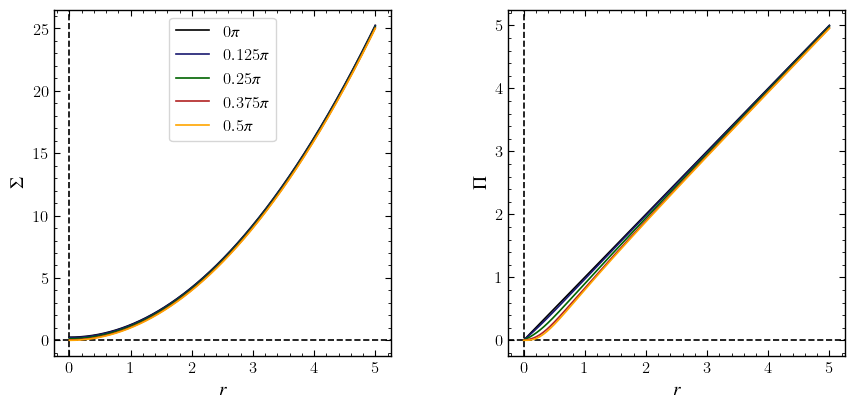

In [13]:
a_Val = 0.5
L_Val = 0.4

r_List  = range(0., 5.0,  length=1000)
th_List = range(0., pi/2, length=5)

Σ_Dict = Dict()
Π_Dict = Dict()

for th in th_List
    Σ_Dict[th] = [Σ(r, th, (a_Val, L_Val)) for r in r_List]
    Π_Dict[th] = [Π(r, th, (a_Val, L_Val)) for r in r_List]
end
 
###########################################################################################
# Figure
###########################################################################################

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 1, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "Σ" => fig.add_subplot(gs[1,1]),
    "Π" => fig.add_subplot(gs[1,2])
)

function pi_label(th; tol=1e-8)
    ratio = th/pi
    if isapprox(ratio, round(ratio), atol=tol)
        # integer multiple
        return "\$$(Int(round(ratio)))\\pi\$"
    elseif isapprox(ratio, 1//3, atol=tol)
        return "\$\\tfrac{\\pi}{3}\$"
    else
        return "\$$(round(ratio, digits=3))\\pi\$"
    end
end

# Left Panel: Σ
axes["Σ"].set(xlabel=L"$r$", ylabel=L"$\Sigma$")
axes["Σ"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["Σ"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

for (i, th) in enumerate(th_List)
    axes["Σ"].plot(r_List, Σ_Dict[th], color=colors[mod1(i,length(colors))], label=pi_label(th))
end

axes["Σ"].legend(ncol=1)

# Right Panel: Π
axes["Π"].set(xlabel=L"$r$", ylabel=L"$\Pi$")
axes["Π"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["Π"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

for (i, th) in enumerate(th_List)
    axes["Π"].plot(r_List, Π_Dict[th], color=colors[mod1(i,length(colors))], label=pi_label(th))
end
# axes["Π"].legend(ncol=1)

subplots_adjust(wspace=0.35, hspace=0.25)
savefig("./Figures/Tests/Fig8-KH-Sigma-Pi.png", dpi=150)

In [14]:
# ORDINARY NULL GEODESICS ONLY (THESE ARE ONLY ONES RELEVANT FOR THE INNER SHADOW)

###########################################################################################
# Carter Constants
# Here one is the Carter Constant and the other the Carter Integral. Keeping both because:
# Gralla and Lupsasca (2020) use eta
# Walia et al. (2025) use scri; Makes many expressions much simpler
###########################################################################################

# NG_params will always mean (eta, xi)

@inline function scri_eta_flag(metric_params, NG_params; eps=EPS_SMOOTH)
    a, _    = metric_params
    eta, xi = NG_params

    scri2     = eta + (xi - a) * (xi - a)
    scri      = soft_sqrt(scri2; eps=eps)
    indicator = smooth_step(scri2; eps=eps)

    return scri, indicator
end

scri_eta(metric_params, NG_params) = scri_eta_flag(metric_params, NG_params)[1]

function eta_scri(metric_params, NG_params, scri) # This trusts (a, xi, scri) are such that eta is positive-Valued (only for Ordinary NGs) when called
    a, _ = metric_params
    xi   = NG_params[2] # This eta is bogus, never used in this function
    return scri*scri - (xi - a) * (xi - a)
end

###########################################################################################
# Null Geodesic Effective Potentials
###########################################################################################

function T_r(r, metric_params, NG_params) # This trusts r > r_H when called
    a, _    = metric_params
    xi      = NG_params[2]
    N_Val   = N(r, metric_params)
    F_Val   = F(r, metric_params)

    invN2 = inv(N_Val * N_Val)
    term  = r - F_Val * a * xi
    return (r * invN2) * term + a*xi - a*a # The first term blows up close to the horizon
end

function Phi_r(r, metric_params, NG_params) # This trusts r > r_H when called
    a, _    = metric_params
    xi      = NG_params[2]
    N_Val   = N(r, metric_params)
    F_Val   = F(r, metric_params)

    invN2 = inv(N_Val * N_Val)
    term  = r - F_Val * a * xi
    return (a * F_Val * invN2) * term - a # The first term blows up close to the horizon
end

function V_r(r, metric_params, NG_params)
    a, _    = metric_params
    eta, xi = NG_params
    N_Val   = N(r, metric_params)
    F_Val   = F(r, metric_params)

    term  = r - F_Val * a * xi
    scri2 = eta + (xi - a) * (xi - a)
    return term*term - (N_Val * N_Val) * scri2
end

function R_r(r, metric_params, NG_params)
    B_Val = B(r, metric_params)
    r2    = r * r
    invB2 = inv(B_Val * B_Val)
    return (r2 * invB2) * V_r(r, metric_params, NG_params)
end

# NOTE: sin-regularization handles coordinate poles (θ → 0, π);
# horizon divergences are handled at the algorithmic level.

function Th(th, metric_params, NG_params; sin_res=EPS_SIN2)
    a, _    = metric_params
    eta, xi = NG_params

    s    = safe_sin(th; eps=sin_res)
    invs = inv(s)

    scri2 = eta + (xi - a) * (xi - a)
    t     = xi*invs - a*s
    return scri2 - t*t
end

###########################################################################################
# Image Plane Cartesian Bardeen Coordinates
###########################################################################################

function alpha(inc, metric_params, NG_params; sin_res=EPS_SIN2)
    xi = NG_params[2]
    return -xi * safe_csc(inc; eps=sin_res)
end

function beta(inc, metric_params, NG_params; k_th_o = 0, Th_res = EPS_SQRT)
    sqrt_Th_Val = soft_sqrt(Th(inc, metric_params, NG_params); eps=Th_res)
    return k_th_o == 0 ? -sqrt_Th_Val : +sqrt_Th_Val
end

###########################################################################################
# Image Plane Polar Coordinates
###########################################################################################

function rho(inc, metric_params, NG_params)
    return hypot(alpha(inc, metric_params, NG_params), beta(inc, metric_params, NG_params))
end

function psi(inc, metric_params, NG_params)
    return atan(beta(inc, metric_params, NG_params), alpha(inc, metric_params, NG_params))
end

psi (generic function with 1 method)

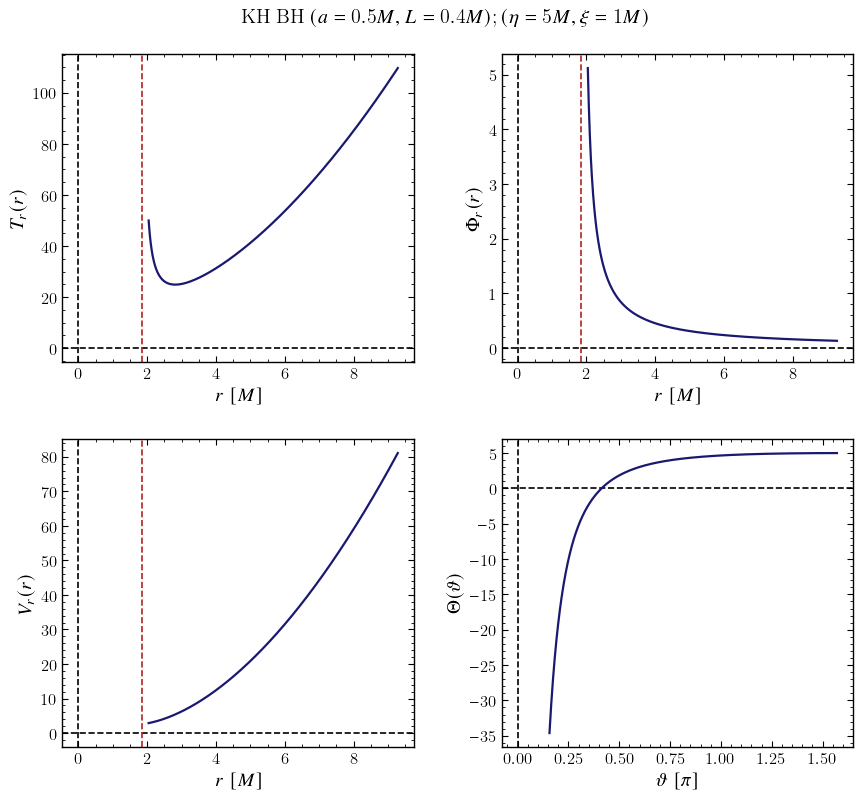

In [15]:
metric_params_Val = (0.5, 0.4)

NG_params_Val = (5., 1.)

T_r_List   = []
V_r_List   = []
Phi_r_List = []
Th_List    = []

rH_Val = rH(metric_params_Val)

r_List = range(rH_Val*1.1, 5*rH_Val, length=1000)

for (r, r_Val) in enumerate(r_List)
    push!(T_r_List,   T_r(  r_Val,  metric_params_Val, NG_params_Val))
    push!(V_r_List,   V_r(  r_Val,  metric_params_Val, NG_params_Val))
    push!(Phi_r_List, Phi_r(r_Val,  metric_params_Val, NG_params_Val))
end

th_List = range(pi/20, pi/2, length=1000)

for (th, th_Val) in enumerate(th_List)
    push!(Th_List, Th(th_Val, metric_params_Val, NG_params_Val))
end

###########################################################################################
# Figure
###########################################################################################

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 2, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "T_r"   => fig.add_subplot(gs[1,1]),
    "V_r"   => fig.add_subplot(gs[2,1]),
    "Phi_r" => fig.add_subplot(gs[1,2]),
    "Th"    => fig.add_subplot(gs[2,2])
)

fig.suptitle(
    L"{\rm KH\ BH}\ (a=0.5M, L=0.4M); (\eta=5M, \xi=1M)",
    y=0.93         # adjust vertical position if overlapping
)

# Top-Left Panel

axes["T_r"].set(xlabel=L"$r\ [M]$", ylabel=L"T_r(r)")

axes["T_r"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["T_r"].axvline(x=0.0, color=colors[1], ls=linestyles[2])
axes["T_r"].axvline(x=rH_Val, color=colors[4], ls=linestyles[2])

axes["T_r"].plot(r_List, T_r_List, color=colors[2], lw=linewidths[3])

# Top-Right Panel

axes["Phi_r"].set(xlabel=L"$r\ [M]$", ylabel=L"\Phi_r(r)")

axes["Phi_r"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["Phi_r"].axvline(x=0.0, color=colors[1], ls=linestyles[2])
axes["Phi_r"].axvline(x=rH_Val, color=colors[4], ls=linestyles[2])

axes["Phi_r"].plot(r_List, Phi_r_List, color=colors[2], lw=linewidths[3])

# Bottom-Left Panel

axes["V_r"].set(xlabel=L"$r\ [M]$", ylabel=L"V_r(r)")

axes["V_r"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["V_r"].axvline(x=0.0, color=colors[1], ls=linestyles[2])
axes["V_r"].axvline(x=rH_Val, color=colors[4], ls=linestyles[2])

axes["V_r"].plot(r_List, V_r_List, color=colors[2], lw=linewidths[3])

# Bottom-Right Panel

axes["Th"].set(xlabel=L"$\vartheta\ [\pi]$", ylabel=L"\Theta(\vartheta)")

axes["Th"].axhline(y=0.0, color=colors[1], ls=linestyles[2])
axes["Th"].axvline(x=0.0, color=colors[1], ls=linestyles[2])

axes["Th"].plot(th_List, Th_List, color=colors[2], lw=linewidths[3])

subplots_adjust(wspace=0.25, hspace=0.25)
savefig("./Figures/Tests/Fig9-KH-NG-Potentials.png", dpi=150)

In [16]:
###########################################################################################
# Photon Sphere seen by the Polar Observer
###########################################################################################

function rSNG_Pole(metric_params; tol=TOL_SOLVE)
    rH_Val = rH_cached(metric_params)

    function rSNG_Pole_Eq(s)
        r = rH_Val + softplus(s)
        return N(r, metric_params) - r * dNdr(r, metric_params)
    end

    # Avoid Float64 seed: 2.0 -> oftype(rH_Val, 2)
    s0 = oftype(rH_Val, 2)
    s_root = find_zero(rSNG_Pole_Eq, s0; xtol=oftype(rH_Val, tol), autodiff=:forward, method=:newton)
    return rH_Val + softplus(s_root)
end

###########################################################################################
# Impact Parameters of Spherical Null Geodesics (SNGs)
###########################################################################################

function xi_SNG(r, metric_params; eps=EPS_SMOOTH, a_min=EPS_HEUR)
    a, p = metric_params

    if abs(a) <= oftype(a, a_min)
        return zero(r)
    end

    # Smoothly enforce nonzero spin to avoid blow-ups in denominators
    a_eff = sqrt(a*a + oftype(a, a_min)^2)
    mp    = (a_eff, p)

    numerator_Val   = N(r, mp) - r * dNdr(r, mp)
    denominator_Val = a_eff * (N(r, mp) * dFdr(r, mp) - F(r, mp) * dNdr(r, mp))

    return numerator_Val / denominator_Val
end

# scri appears in all expressions as a squared quantity. Therefore, we are just picking a covention here.
function scri_SNG(r, metric_params; eps=EPS_SMOOTH, a_min=EPS_HEUR) 
    a, p = metric_params

    if abs(a) <= oftype(a, a_min)
        mp_low_a      = (zero(a), p)
        rSNG_Pole_Val = rSNG_Pole(mp_low_a; tol=oftype(a, TOL_SOLVE))

        numerator_Val   = F(rSNG_Pole_Val, mp_low_a) - rSNG_Pole_Val * dFdr(rSNG_Pole_Val, mp_low_a)
        denominator_Val = F(rSNG_Pole_Val, mp_low_a) * dNdr(rSNG_Pole_Val, mp_low_a) - N(rSNG_Pole_Val, mp_low_a) * dFdr(rSNG_Pole_Val, mp_low_a)

        return numerator_Val / denominator_Val
    end

    a_eff = sqrt(a*a + oftype(a, a_min)^2)
    mp    = (a_eff, p)

    numerator_Val   = F(r, mp) - r * dFdr(r, mp)
    denominator_Val = F(r, mp) * dNdr(r, mp) - N(r, mp) * dFdr(r, mp)

    return numerator_Val / denominator_Val
end

function eta_SNG(r, metric_params; eps=EPS_SMOOTH, a_min=EPS_HEUR)
    a, p = metric_params

    if abs(a) <= oftype(a, a_min)
        mp_low_a      = (zero(a), p)
        rSNG_Pole_Val = rSNG_Pole(mp_low_a; tol=oftype(a, TOL_SOLVE))
        s = scri_SNG(rSNG_Pole_Val, mp_low_a; eps=eps, a_min=a_min)
        return s*s
    end

    a_eff = sqrt(a*a + oftype(a, a_min)^2)

    scri = scri_SNG(r, metric_params; eps=eps, a_min=a_min)
    xi   = xi_SNG(  r, metric_params; eps=eps, a_min=a_min)

    return scri*scri - (xi - a_eff) * (xi - a_eff)
end

###########################################################################################
# Gradient of Impact Parameters in the Photon Shell
###########################################################################################

dxidr_SNG( r, metric_params) = ForwardDiff.derivative(rr -> xi_SNG( rr, metric_params), r)
detadr_SNG(r, metric_params) = ForwardDiff.derivative(rr -> eta_SNG(rr, metric_params), r)

###########################################################################################
# Polar Potential for SNGs in particular and Derivative w.r.t. photon sphere radius (this can be used to find alpha_Max)
###########################################################################################

Theta_SNG(r, th, metric_params) = Th(th, metric_params, (eta_SNG(r, metric_params), xi_SNG(r, metric_params)))

dThetadr_SNG(r, th, metric_params) = ForwardDiff.derivative(rr -> Theta_SNG(rr, th, metric_params), r)

###########################################################################################
# Boundaries of the Photon Shell
###########################################################################################

function rSNG_mp(inc, metric_params; eps=TOL_SOLVE, rH_nudge=EPS_GEOM)
    a, _          = metric_params
    rH_Val        = rH_cached(metric_params)
    rSNG_Pole_Val = rSNG_Pole(metric_params; tol=eps)

    if abs(a) ≤ oftype(a, EPS_HEUR)
        return (rSNG_Pole_Val, rSNG_Pole_Val)
    end

    Theta_SNG_Eq_s(s) = Theta_SNG(rH_Val + softplus(s), inc, metric_params)

    Theta_H = Theta_SNG(rH_Val + oftype(rH_Val, rH_nudge), inc, metric_params)

    s_guess_mid = invsoftplus((rH_Val + rSNG_Pole_Val) / oftype(rH_Val, 2) - rH_Val)
    s_guess_hi  = invsoftplus(rSNG_Pole_Val * oftype(rH_Val, 1.5) - rH_Val)

    if abs(Theta_H) <= oftype(Theta_H, EPS_GEOM)
        s_Max = find_zero(Theta_SNG_Eq_s, s_guess_hi;  xtol=eps, autodiff=:forward, method=:newton)
        return (rH_Val + oftype(rH_Val, rH_nudge), rH_Val + softplus(s_Max))
    else
        s_min = find_zero(Theta_SNG_Eq_s, s_guess_mid; xtol=eps, autodiff=:forward, method=:newton)
        s_Max = find_zero(Theta_SNG_Eq_s, s_guess_hi;  xtol=eps, autodiff=:forward, method=:newton)
        return (rH_Val + softplus(s_min), rH_Val + softplus(s_Max))
    end
end

rSNG_m(inc, metric_params) = rSNG_mp(inc, metric_params)[1]
rSNG_p(inc, metric_params) = rSNG_mp(inc, metric_params)[2]

function rho_SNG_med(inc, metric_params; eps=TOL_SOLVE)
    rSNG_m_Val, rSNG_p_Val = rSNG_mp(inc, metric_params; eps=eps)
    r_SNG_List   = range(rSNG_m_Val, rSNG_p_Val, length=500)
    rho_SNG_List = rho_SNG.(r_SNG_List, inc, Ref(metric_params))
    return median(rho_SNG_List)
end

# rSNG cacheing

const _rSNG_cache_T = Dict{DataType, Any}()
const _rSNG_lock    = ReentrantLock()

function _rSNG_cache_for(::Type{T}) where {T}
    lock(_rSNG_lock) do
        get!(_rSNG_cache_T, T) do
            # key: (inc, (a,p))  value: (rSNG_m, rSNG_p)
            Dict{Tuple{T,Tuple{T,T}}, Tuple{T,T}}()
        end
    end
end

function rSNG_mp_cached(inc::I, metric_params::Tuple{A,B}; eps=TOL_SOLVE, rH_nudge=EPS_GEOM) where {I<:Real,A<:Real,B<:Real}
    # For AD: don't cache (avoid Dual keys + keeps exact scalar type)
    (_is_ad_type(inc) || _is_ad_type(metric_params)) && return rSNG_mp(inc, metric_params; eps=eps, rH_nudge=rH_nudge)

    # If caller requests non-default numerical policy, bypass cache so results can't
    # silently depend on the first eps/rH_nudge that touched this key.
    if eps != TOL_SOLVE || rH_nudge != EPS_GEOM
        return rSNG_mp(inc, metric_params; eps=eps, rH_nudge=rH_nudge)
    end

    # Normalize to a single concrete scalar type (like rH_cached)
    T   = promote_type(I, A, B)
    incT = T(inc)
    mpT  = (T(metric_params[1]), T(metric_params[2]))

    key   = (incT, mpT)
    cache = _rSNG_cache_for(T)

    lock(_rSNG_lock) do
        return get!(cache, key) do
            rSNG_mp(incT, mpT; eps=T(eps), rH_nudge=T(rH_nudge))
        end
    end
end

function clear_rSNG_cache!()
    lock(_rSNG_lock) do
        empty!(_rSNG_cache_T)
    end
    return nothing
end

###########################################################################################
# The Critical Curve
###########################################################################################

alpha_SNG(r, inc, metric_params) = alpha(inc, metric_params, (eta_SNG(r, metric_params), xi_SNG(r, metric_params)))
beta_SNG( r, inc, metric_params) = beta( inc, metric_params, (eta_SNG(r, metric_params), xi_SNG(r, metric_params)))
rho_SNG(  r, inc, metric_params) = rho(  inc, metric_params, (eta_SNG(r, metric_params), xi_SNG(r, metric_params)))
psi_SNG(  r, inc, metric_params) = psi(  inc, metric_params, (eta_SNG(r, metric_params), xi_SNG(r, metric_params)))

psi_SNG (generic function with 1 method)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:07
Progress: 100%|█████████████████████████████████████████| Time: 0:00:05


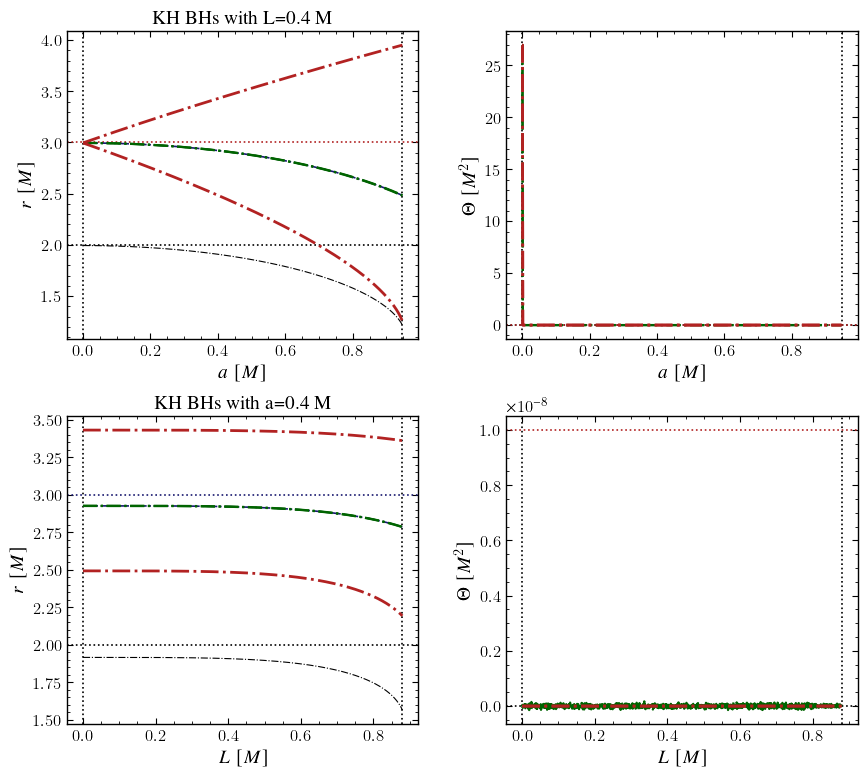

In [17]:
L_Val    = 0.4
a_Ex_Val = a_Ex((0.5, L_Val))

a_List_Ldot4          = range(1e-8, a_Ex_Val, length=1000)

rH_List_Ldot4         = Vector{Float64}(undef, length(a_List_Ldot4))

rSNG_Pole_List_Ldot4   = Vector{Float64}(undef, length(a_List_Ldot4))

Th_PS_pole_List_Ldot4 = Vector{Float64}(undef, length(a_List_Ldot4))

rm_pole_List_Ldot4    = Vector{Float64}(undef, length(a_List_Ldot4))
rp_pole_List_Ldot4    = Vector{Float64}(undef, length(a_List_Ldot4))

Th_m_pole_List_Ldot4  = Vector{Float64}(undef, length(a_List_Ldot4))
Th_p_pole_List_Ldot4  = Vector{Float64}(undef, length(a_List_Ldot4))

rm_eq_List_Ldot4      = Vector{Float64}(undef, length(a_List_Ldot4))
rp_eq_List_Ldot4      = Vector{Float64}(undef, length(a_List_Ldot4))

Th_m_eq_List_Ldot4    = Vector{Float64}(undef, length(a_List_Ldot4))
Th_p_eq_List_Ldot4    = Vector{Float64}(undef, length(a_List_Ldot4))

# Data Generation

@showprogress for i in eachindex(a_List_Ldot4)
    
    a_Val = a_List_Ldot4[i]
    
    metric_params_Val = (a_Val, L_Val)
    
    rH_List_Ldot4[i] = rH(metric_params_Val)
    
    rSNG_Pole_List_Ldot4[i]   = rSNG_Pole(metric_params_Val)
    
    Th_PS_pole_List_Ldot4[i] = Theta_SNG(rSNG_Pole_List_Ldot4[i], pi/2000, metric_params_Val)
    
    rm_pole_List_Ldot4[i], rp_pole_List_Ldot4[i] = rSNG_mp(pi/2000, metric_params_Val)
    
    Th_m_pole_List_Ldot4[i] = Theta_SNG(rm_pole_List_Ldot4[i], pi/2000, metric_params_Val)
    Th_p_pole_List_Ldot4[i] = Theta_SNG(rp_pole_List_Ldot4[i], pi/2000, metric_params_Val)
    
    rm_eq_List_Ldot4[i], rp_eq_List_Ldot4[i] = rSNG_mp(pi/2, metric_params_Val)      
    
    Th_m_eq_List_Ldot4[i] = Theta_SNG(rm_eq_List_Ldot4[i], pi/2, metric_params_Val)
    Th_p_eq_List_Ldot4[i] = Theta_SNG(rp_eq_List_Ldot4[i], pi/2, metric_params_Val)
    
end

###########################################################################################

a_Val    = 0.4
L_Ex_Val = p_Ex((a_Val, 0.5))

L_List_adot4          = range(1e-8, L_Ex_Val, length=1000)

rH_List_adot4         = Vector{Float64}(undef, length(L_List_adot4))

rSNG_Pole_List_adot4   = Vector{Float64}(undef, length(L_List_adot4))

Th_PS_pole_List_adot4 = Vector{Float64}(undef, length(L_List_adot4))

rm_pole_List_adot4    = Vector{Float64}(undef, length(L_List_adot4))
rp_pole_List_adot4    = Vector{Float64}(undef, length(L_List_adot4))

Th_m_pole_List_adot4  = Vector{Float64}(undef, length(L_List_adot4))
Th_p_pole_List_adot4  = Vector{Float64}(undef, length(L_List_adot4))

rm_eq_List_adot4      = Vector{Float64}(undef, length(L_List_adot4))
rp_eq_List_adot4      = Vector{Float64}(undef, length(L_List_adot4))

Th_m_eq_List_adot4    = Vector{Float64}(undef, length(L_List_adot4))
Th_p_eq_List_adot4    = Vector{Float64}(undef, length(L_List_adot4))

# Data Generation

@showprogress for i in eachindex(L_List_adot4)
    
    L_Val = L_List_adot4[i]
    
    metric_params_Val = (a_Val, L_Val)   
    
    rH_List_adot4[i] = rH(metric_params_Val)
    
    rSNG_Pole_List_adot4[i]   = rSNG_Pole(metric_params_Val)
    
    Th_PS_pole_List_adot4[i] = Theta_SNG(rSNG_Pole_List_adot4[i], 1e-3, metric_params_Val)
    
    rm_pole_List_adot4[i], rp_pole_List_adot4[i] = rSNG_mp(pi/2000, metric_params_Val)
    
    Th_m_pole_List_adot4[i] = Theta_SNG(rm_pole_List_adot4[i], pi/2000, metric_params_Val)
    Th_p_pole_List_adot4[i] = Theta_SNG(rp_pole_List_adot4[i], pi/2000, metric_params_Val)
    
    rm_eq_List_adot4[i], rp_eq_List_adot4[i] = rSNG_mp(pi/2, metric_params_Val)      
    
    Th_m_eq_List_adot4[i] = Theta_SNG(rm_eq_List_adot4[i], pi/2, metric_params_Val)
    Th_p_eq_List_adot4[i] = Theta_SNG(rp_eq_List_adot4[i], pi/2, metric_params_Val)
    
end

###########################################################################################
# Figure
###########################################################################################

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 2, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "L"    => fig.add_subplot(gs[1,1]),
    "L_Th" => fig.add_subplot(gs[1,2]),
    "a"    => fig.add_subplot(gs[2,1]),
    "a_Th" => fig.add_subplot(gs[2,2])
)

# Top-Left Panel

axes["L"].set_title("KH BHs with L=0.4 M")
axes["L"].set(xlabel=L"$a\ [M]$", ylabel=L"$r\ [M]$")

axes["L"].axvline(x=0.0,      color=colors[1], ls=linestyles[3])
axes["L"].axvline(x=a_Ex_Val, color=colors[1], ls=linestyles[3])

axes["L"].axhline(y=2.0, color=colors[1], ls=linestyles[3])
axes["L"].axhline(y=3.0, color=colors[4], ls=linestyles[3])

axes["L"].plot(a_List_Ldot4, rH_List_Ldot4,       lw=linewidths[1], ls=linestyles[4], color=colors[1], label=L"r_H") 
axes["L"].plot(a_List_Ldot4, rSNG_Pole_List_Ldot4, lw=linewidths[2], ls=linestyles[4], color=colors[2], label=L"r(0^+)") 
axes["L"].plot(a_List_Ldot4, rm_pole_List_Ldot4,  lw=linewidths[3], ls=linestyles[4], color=colors[3], label=L"r_-(0^+)") 
axes["L"].plot(a_List_Ldot4, rp_pole_List_Ldot4,  lw=linewidths[3], ls=linestyles[4], color=colors[3], label=L"r_+(0^+)") 
axes["L"].plot(a_List_Ldot4, rm_eq_List_Ldot4,    lw=linewidths[4], ls=linestyles[4], color=colors[4], label=L"r_-(\pi/2)") 
axes["L"].plot(a_List_Ldot4, rp_eq_List_Ldot4,    lw=linewidths[4], ls=linestyles[4], color=colors[4], label=L"r_+(\pi/2)")

# Top-Right Panel

axes["L_Th"].set(xlabel=L"$a\ [M]$", ylabel=L"$\Theta\ [M^2]$")

axes["L_Th"].axvline(x=0.0,      color=colors[1], ls=linestyles[3])
axes["L_Th"].axvline(x=a_Ex_Val, color=colors[1], ls=linestyles[3])

axes["L_Th"].axhline(y=0.0,  color=colors[1], ls=linestyles[3])
axes["L_Th"].axhline(y=1e-8, color=colors[4], ls=linestyles[3])

# axes["L_Th"].plot(a_List_Ldot4, Th_PS_pole_List_Ldot4, lw=linewidths[2], ls=linestyles[4], color=colors[2])
axes["L_Th"].plot(a_List_Ldot4, Th_m_pole_List_Ldot4,  lw=linewidths[3], ls=linestyles[4], color=colors[3])
axes["L_Th"].plot(a_List_Ldot4, Th_p_pole_List_Ldot4,  lw=linewidths[3], ls=linestyles[4], color=colors[3])
axes["L_Th"].plot(a_List_Ldot4, Th_m_eq_List_Ldot4,    lw=linewidths[4], ls=linestyles[4], color=colors[4])
axes["L_Th"].plot(a_List_Ldot4, Th_p_eq_List_Ldot4,    lw=linewidths[4], ls=linestyles[4], color=colors[4])

# Bottom-Left Panel

axes["a"].set_title("KH BHs with a=0.4 M")
axes["a"].set(xlabel=L"$L\ [M]$", ylabel=L"r\ [M]")

axes["a"].axvline(x=0.0,      color=colors[1], ls=":")
axes["a"].axvline(x=L_Ex_Val, color=colors[1], ls=":")

axes["a"].axhline(y=2.0, color=colors[1], ls=":")
axes["a"].axhline(y=3.0, color=colors[2], ls=":")

axes["a"].plot(L_List_adot4, rH_List_adot4,       lw=linewidths[1], ls=linestyles[4], color=colors[1], label=L"r_H")
axes["a"].plot(L_List_adot4, rSNG_Pole_List_adot4, lw=linewidths[2], ls=linestyles[4], color=colors[2], label=L"r(0^+)") 
axes["a"].plot(L_List_adot4, rm_pole_List_adot4,  lw=linewidths[3], ls=linestyles[4], color=colors[3], label=L"r_-(0^+)")
axes["a"].plot(L_List_adot4, rp_pole_List_adot4,  lw=linewidths[3], ls=linestyles[4], color=colors[3], label=L"r_+(0^+)")
axes["a"].plot(L_List_adot4, rm_eq_List_adot4,    lw=linewidths[4], ls=linestyles[4], color=colors[4], label=L"r_-(\pi/2)")
axes["a"].plot(L_List_adot4, rp_eq_List_adot4,    lw=linewidths[4], ls=linestyles[4], color=colors[4], label=L"r_+(\pi/2)")

# Bottom-Right Panel

axes["a_Th"].set(xlabel=L"$L\ [M]$", ylabel=L"$\Theta\ [M^2]$")

axes["a_Th"].axvline(x=0.0,      color=colors[1], ls=linestyles[3])
axes["a_Th"].axvline(x=L_Ex_Val, color=colors[1], ls=linestyles[3])

axes["a_Th"].axhline(y=0.0,  color=colors[1], ls=linestyles[3])
axes["a_Th"].axhline(y=1e-8, color=colors[4], ls=linestyles[3])

# axes["a_Th"].plot(L_List_adot4, Th_PS_pole_List_adot4, lw=linewidths[2], ls=linestyles[4], color=colors[2])
axes["a_Th"].plot(L_List_adot4, Th_m_pole_List_adot4,  lw=linewidths[3], ls=linestyles[4], color=colors[3])
axes["a_Th"].plot(L_List_adot4, Th_p_pole_List_adot4,  lw=linewidths[3], ls=linestyles[4], color=colors[3])
axes["a_Th"].plot(L_List_adot4, Th_m_eq_List_adot4,    lw=linewidths[4], ls=linestyles[4], color=colors[4])
axes["a_Th"].plot(L_List_adot4, Th_p_eq_List_adot4,    lw=linewidths[4], ls=linestyles[4], color=colors[4])

# axes["a"].legend(loc="upper left", ncol=1)

subplots_adjust(wspace=0.25, hspace=0.25)
savefig("./Figures/Tests/Fig10-KH-Photon-Shell.png", dpi=150)

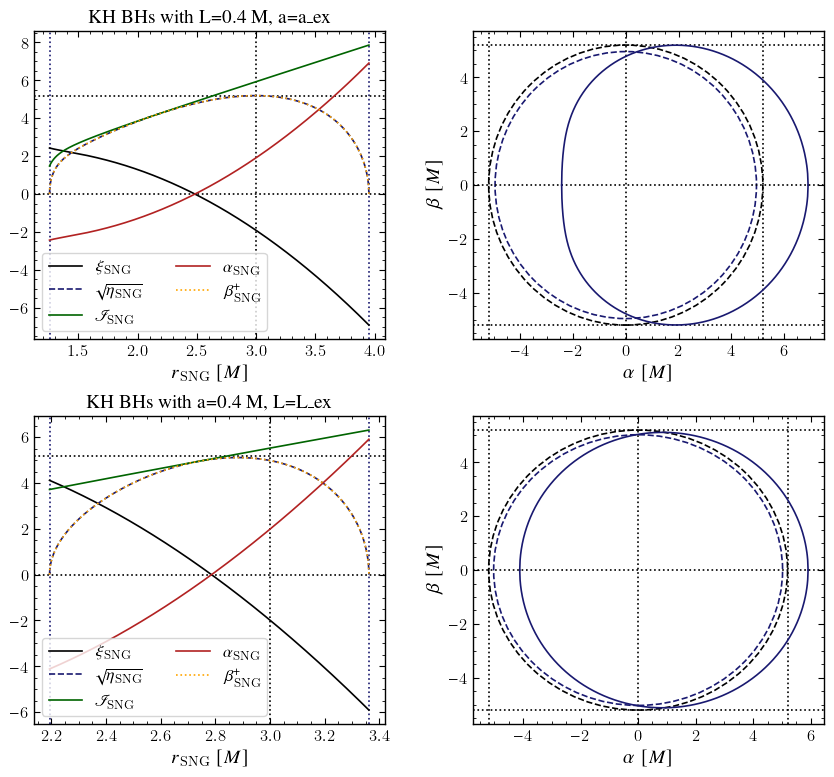

In [18]:
L_Val      = 0.4
a_Ex_Val  = a_Ex((0.5, L_Val))

metric_params_Val_Ldot4 = (a_Ex_Val, L_Val)

rPS_Val_Ldot4 = rSNG_mp(pi/2, metric_params_Val_Ldot4)

rPS_List_Ldot4 = range(rPS_Val_Ldot4[1], rPS_Val_Ldot4[2], length=1000)

xi_List_eq_Ldot4     = []
scri_List_eq_Ldot4   = []
eta_List_eq_Ldot4    = []

alpha_List_eq_Ldot4  = []
beta_m_List_eq_Ldot4 = []
beta_p_List_eq_Ldot4 = []

# Data Generation

@showprogress for i in eachindex(rPS_List_Ldot4)
    r_Val = rPS_List_Ldot4[i]
    
    xi_SNG_Val   =   xi_SNG(r_Val, metric_params_Val_Ldot4)
    eta_SNG_Val  =  eta_SNG(r_Val, metric_params_Val_Ldot4)
    scri_SNG_Val = scri_SNG(r_Val, metric_params_Val_Ldot4)
    
    push!(xi_List_eq_Ldot4,   xi_SNG_Val)
    push!(eta_List_eq_Ldot4,  sqrt(max(eta_SNG_Val, 0.0)))
    push!(scri_List_eq_Ldot4, scri_SNG_Val)
    
    
    push!(alpha_List_eq_Ldot4,  alpha(pi/2, metric_params_Val_Ldot4, (eta_SNG_Val, xi_SNG_Val)))
    push!(beta_m_List_eq_Ldot4, beta( pi/2, metric_params_Val_Ldot4, (eta_SNG_Val, xi_SNG_Val), k_th_o = 0))
    push!(beta_p_List_eq_Ldot4, beta( pi/2, metric_params_Val_Ldot4, (eta_SNG_Val, xi_SNG_Val), k_th_o = 1))
    
end

###########################################################################################

a_Val     = 0.4
L_Ex_Val = p_Ex((a_Val, 0.5))

metric_params_Val_adot4 = (a_Val, L_Ex_Val)
rPS_Val_adot4 = rSNG_mp(pi/2, metric_params_Val_adot4)

rPS_List_adot4 = range(rPS_Val_adot4[1], rPS_Val_adot4[2], length=1000)

xi_List_eq_adot4   = []
scri_List_eq_adot4 = []
eta_List_eq_adot4  = []

alpha_List_eq_adot4  = []
beta_m_List_eq_adot4 = []
beta_p_List_eq_adot4 = []

# Data Generation

@showprogress for i in eachindex(rPS_List_adot4)
    r_Val = rPS_List_adot4[i]
    
    xi_SNG_Val   =   xi_SNG(r_Val, metric_params_Val_adot4)
    eta_SNG_Val  =  eta_SNG(r_Val, metric_params_Val_adot4) 
    scri_SNG_Val = scri_SNG(r_Val, metric_params_Val_adot4)
        
    push!(xi_List_eq_adot4,   xi_SNG_Val)
    push!(eta_List_eq_adot4,  sqrt(max(eta_SNG_Val, 0.0)))
    push!(scri_List_eq_adot4, scri_SNG_Val)
    
    push!(alpha_List_eq_adot4,  alpha(pi/2, metric_params_Val_adot4, (eta_SNG_Val, xi_SNG_Val)))
    push!(beta_m_List_eq_adot4, beta( pi/2, metric_params_Val_adot4, (eta_SNG_Val, xi_SNG_Val), k_th_o = 0))
    push!(beta_p_List_eq_adot4, beta( pi/2, metric_params_Val_adot4, (eta_SNG_Val, xi_SNG_Val), k_th_o = 1))
    
end

###########################################################################################
# Figure
###########################################################################################

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 2, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "L"    => fig.add_subplot(gs[1,1]),
    "L_cc" => fig.add_subplot(gs[1,2]),
    "a"    => fig.add_subplot(gs[2,1]),
    "a_cc" => fig.add_subplot(gs[2,2]),
)

# Top-Left Panel

axes["L"].set_title("KH BHs with L=0.4 M, a=a_ex")
axes["L"].set(xlabel=L"$r_{\rm SNG}\ [M]$")

axes["L"].axvline(x=rPS_Val_Ldot4[1], color=colors[2], ls=linestyles[3])
axes["L"].axvline(x=3.0,              color=colors[1], ls=linestyles[3])
axes["L"].axvline(x=rPS_Val_Ldot4[2], color=colors[2], ls=linestyles[3])

axes["L"].axhline(y=sqrt(27.0), color=colors[1], ls=linestyles[3])
axes["L"].axhline(y=sqrt(0.0),  color=colors[1], ls=linestyles[3])

axes["L"].plot(rPS_List_Ldot4, xi_List_eq_Ldot4,     lw=linewidths[2], ls=linestyles[1], color=colors[1], label=L"\xi_{\rm SNG}") 
axes["L"].plot(rPS_List_Ldot4, eta_List_eq_Ldot4,    lw=linewidths[2], ls=linestyles[2], color=colors[2], label=L"\sqrt{\eta_{\rm SNG}}")
axes["L"].plot(rPS_List_Ldot4, scri_List_eq_Ldot4,   lw=linewidths[2], ls=linestyles[1], color=colors[3], label=L"\mathscr{I}_{\rm SNG}") 
axes["L"].plot(rPS_List_Ldot4, alpha_List_eq_Ldot4,  lw=linewidths[2], ls=linestyles[1], color=colors[4], label=L"\alpha_{\rm SNG}") 
axes["L"].plot(rPS_List_Ldot4, beta_p_List_eq_Ldot4, lw=linewidths[2], ls=linestyles[3], color=colors[5], label=L"\beta^+_{\rm SNG}") 

axes["L"].legend(loc="lower left", ncol=2)

# Top-Right Panel

axes["L_cc"].set(xlabel=L"$\alpha\ [M]$", ylabel=L"$\beta\ [M]$")

axes["L_cc"].axvline(x=-sqrt(27.0), color=colors[1], ls=linestyles[3])
axes["L_cc"].axvline(x=sqrt(0.0),   color=colors[1], ls=linestyles[3])
axes["L_cc"].axvline(x=+sqrt(27.0), color=colors[1], ls=linestyles[3])

axes["L_cc"].axhline(y=-sqrt(27.0), color=colors[1], ls=linestyles[3])
axes["L_cc"].axhline(y=sqrt(0.0),   color=colors[1], ls=linestyles[3])
axes["L_cc"].axhline(y=+sqrt(27.0), color=colors[1], ls=linestyles[3])

circle_L_cc_Schw = matplotlib.patches.Circle((0, 0), sqrt(+27.0),                                edgecolor=colors[1], linestyle=linestyles[2], linewidth=linewidths[2], facecolor="none")
circle_L_cc_KH   = matplotlib.patches.Circle((0, 0), rho_SNG_med(pi/2, metric_params_Val_Ldot4), edgecolor=colors[2], linestyle=linestyles[2], linewidth=linewidths[2], facecolor="none")

axes["L_cc"].add_patch(circle_L_cc_Schw)
axes["L_cc"].add_patch(circle_L_cc_KH)

axes["L_cc"].plot(alpha_List_eq_Ldot4, beta_m_List_eq_Ldot4, lw=linewidths[2], ls=linestyles[1], color=colors[2])
axes["L_cc"].plot(alpha_List_eq_Ldot4, beta_p_List_eq_Ldot4, lw=linewidths[2], ls=linestyles[1], color=colors[2])

# Top-Left Panel

axes["a"].set_title("KH BHs with a=0.4 M, L=L_ex")
axes["a"].set(xlabel=L"$r_{\rm SNG}\ [M]$")

axes["a"].axvline(x=rPS_Val_adot4[1], color=colors[2], ls=linestyles[3])
axes["a"].axvline(x=3.0,              color=colors[1], ls=linestyles[3])
axes["a"].axvline(x=rPS_Val_adot4[2], color=colors[2], ls=linestyles[3])

axes["a"].axhline(y=sqrt(27.0), color=colors[1], ls=linestyles[3])
axes["a"].axhline(y=sqrt(0.0),  color=colors[1], ls=linestyles[3])

axes["a"].plot(rPS_List_adot4, xi_List_eq_adot4,     lw=linewidths[2], ls=linestyles[1], color=colors[1], label=L"\xi_{\rm SNG}") 
axes["a"].plot(rPS_List_adot4, eta_List_eq_adot4,    lw=linewidths[2], ls=linestyles[2], color=colors[2], label=L"\sqrt{\eta_{\rm SNG}}")
axes["a"].plot(rPS_List_adot4, scri_List_eq_adot4,   lw=linewidths[2], ls=linestyles[1], color=colors[3], label=L"\mathscr{I}_{\rm SNG}") 
axes["a"].plot(rPS_List_adot4, alpha_List_eq_adot4,  lw=linewidths[2], ls=linestyles[1], color=colors[4], label=L"\alpha_{\rm SNG}") 
axes["a"].plot(rPS_List_adot4, beta_p_List_eq_adot4, lw=linewidths[2], ls=linestyles[3], color=colors[5], label=L"\beta^+_{\rm SNG}") 

axes["a"].legend(loc="lower left", ncol=2)

# Top-Right Panel

axes["a_cc"].set(xlabel=L"$\alpha\ [M]$", ylabel=L"$\beta\ [M]$")

axes["a_cc"].axvline(x=-sqrt(27.0), color=colors[1], ls=linestyles[3])
axes["a_cc"].axvline(x=sqrt(0.0),   color=colors[1], ls=linestyles[3])
axes["a_cc"].axvline(x=+sqrt(27.0), color=colors[1], ls=linestyles[3])

axes["a_cc"].axhline(y=-sqrt(27.0), color=colors[1], ls=linestyles[3])
axes["a_cc"].axhline(y=sqrt(0.0),   color=colors[1], ls=linestyles[3])
axes["a_cc"].axhline(y=+sqrt(27.0), color=colors[1], ls=linestyles[3])

circle_a_cc_Schw = matplotlib.patches.Circle((0, 0), sqrt(+27.0),                                edgecolor=colors[1], linestyle=linestyles[2], linewidth=linewidths[2], facecolor="none")
circle_a_cc_KH   = matplotlib.patches.Circle((0, 0), rho_SNG_med(pi/2, metric_params_Val_adot4), edgecolor=colors[2], linestyle=linestyles[2], linewidth=linewidths[2], facecolor="none")

axes["a_cc"].add_patch(circle_a_cc_Schw)
axes["a_cc"].add_patch(circle_a_cc_KH)

axes["a_cc"].plot(alpha_List_eq_adot4, beta_m_List_eq_adot4, lw=linewidths[2], ls=linestyles[1], color=colors[2])
axes["a_cc"].plot(alpha_List_eq_adot4, beta_p_List_eq_adot4, lw=linewidths[2], ls=linestyles[1], color=colors[2])

subplots_adjust(wspace=0.25, hspace=0.25)
savefig("./Figures/Tests/Fig11-KH-Critical-Curve.png", dpi=150)

In [19]:
###########################################################################################
# Polar Turning Points
###########################################################################################

function Delta_th(metric_params, NG_params; res_a=EPS_HEUR)
    a, _    = metric_params
    eta, xi = NG_params
    # Smooth nonzero a to avoid division blow-ups as a -> 0
    a_eff = hypot(a, oftype(a, res_a))
    inva2 = inv(a_eff * a_eff)
    return (one(a_eff) - (eta + xi*xi) * inva2) / oftype(a_eff, 2)
end

function u_p(metric_params, NG_params; res_a=EPS_HEUR, warn_vortical::Bool=true)
    a, p    = metric_params
    eta, xi = NG_params

    a_eff = hypot(a, oftype(a, res_a))
    dt    = Delta_th((a_eff, p), NG_params; res_a=res_a)

    if eta < zero(eta)
        warn_vortical && @warn "Vortical geodesics not allowed"
        return oftype(a_eff, NaN)
    end

    inva2 = inv(a_eff * a_eff)
    u_det = muladd(dt, dt, eta * inva2)
    u_det = max(u_det, zero(u_det))

    root_Val = dt + sqrt(u_det)
    
    if !(root_Val > zero(root_Val))
        return oftype(root_Val, NaN)
    end

    return clamp(root_Val, zero(root_Val), one(root_Val))
end

function u_m(metric_params, NG_params; res_a=EPS_HEUR, warn_vortical::Bool=true)
    a, p    = metric_params
    eta, xi = NG_params

    a_eff = hypot(a, oftype(a, res_a))
    dt    = Delta_th((a_eff, p), NG_params; res_a=res_a)

    if eta < zero(eta)
        warn_vortical && @warn "Vortical geodesics not allowed"
        return oftype(a_eff, NaN)
    end

    inva2 = inv(a_eff * a_eff)
    u_det = muladd(dt, dt, eta * inva2)
    u_det = max(u_det, zero(u_det))

    root_Val = dt - sqrt(u_det)
    return root_Val < one(root_Val) ? root_Val : oftype(root_Val, NaN)
end

function th_Min(metric_params, NG_params)
    up = u_p(metric_params, NG_params)
    if !isfinite(up)
        return oftype(up, NaN)
    end
    rt_up = sqrt(up)
    return acos(clamp(rt_up, zero(rt_up), one(rt_up)))
end

function th_Max(metric_params, NG_params)
    up    = u_p(metric_params, NG_params)
    if !isfinite(up)
        return oftype(up, NaN)
    end
    rt_up = sqrt(up)
    v     = isfinite(rt_up) ? acos(-rt_up) : oftype(rt_up, NaN)
    return v == zero(v) ? oftype(v, π) : v
end

###########################################################################################
# Polar Turning Points for Spherical Null Geodesics
###########################################################################################

function u_m_SNG(r, metric_params)
    return u_m(metric_params, (eta_SNG(r, metric_params), xi_SNG(r, metric_params)))
end

function u_p_SNG(r, metric_params)
    return u_p(metric_params, (eta_SNG(r, metric_params), xi_SNG(r, metric_params)))
end

u_p_SNG (generic function with 1 method)

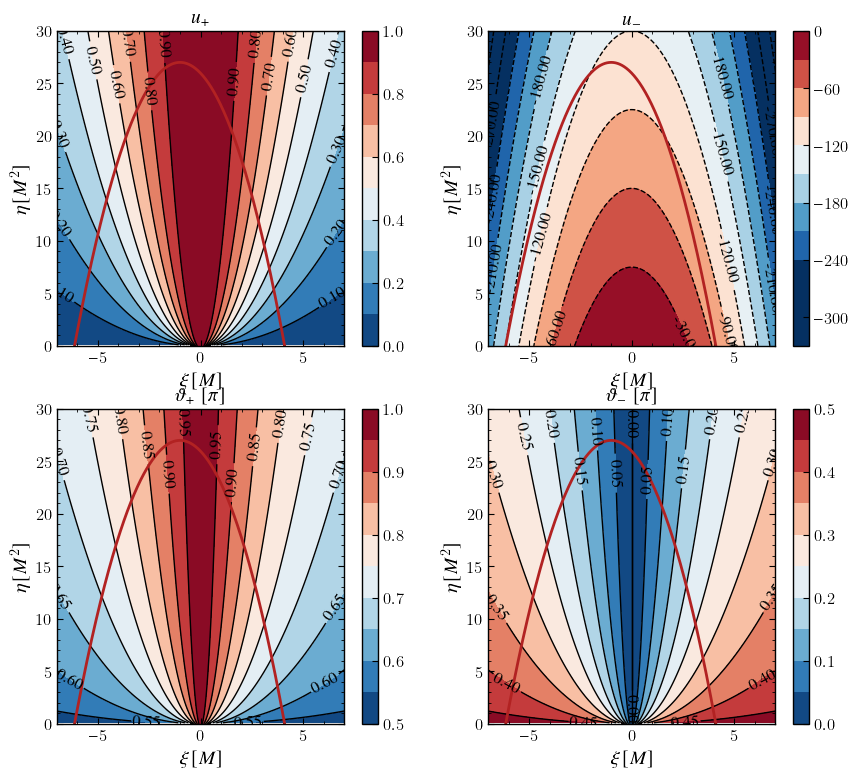

In [20]:
a_Val, L_Val = (0.5, 1e-3)

eta_List = range( 0.0, 30.0, length=300)
xi_List  = range(-7.0, 7.0, length=751)

up_List = Array{Float64}(undef, length(eta_List), length(xi_List))
um_List = Array{Float64}(undef, length(eta_List), length(xi_List))

th_Max_List = Array{Float64}(undef, length(eta_List), length(xi_List))
th_Min_List = Array{Float64}(undef, length(eta_List), length(xi_List))

for (i, eta_Val) in enumerate(eta_List)
    for (j, xi_Val) in enumerate(xi_List)
        
        up_Val = u_p((a_Val, L_Val), (eta_Val, xi_Val))
        um_Val = u_m((a_Val, L_Val), (eta_Val, xi_Val))
        up_List[i, j] = !isnan(up_Val) ? up_Val : NaN
        um_List[i, j] = !isnan(um_Val) ? um_Val : NaN
        
        th_Max_Val = th_Max((a_Val, L_Val), (eta_Val, xi_Val))/pi
        th_Min_Val = th_Min((a_Val, L_Val), (eta_Val, xi_Val))/pi
        th_Max_List[i, j] = !isnan(th_Max_Val) ? th_Max_Val : NaN
        th_Min_List[i, j] = !isnan(th_Min_Val) ? th_Min_Val : NaN
        
    end
end

rPS_m_Val, rPS_p_Val = rSNG_mp(pi/2, (a_Val, L_Val))

rPS_List = range(rPS_m_Val, rPS_p_Val, length=1000)

xi_SNG_List  = [xi_SNG( r, (a_Val, L_Val)) for r in rPS_List] 
eta_SNG_List = [eta_SNG(r, (a_Val, L_Val)) for r in rPS_List]

###########################################################################################
# Figure
###########################################################################################

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows = 2
n_cols = 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "up" => fig.add_subplot(gs[1,1]),
    "um" => fig.add_subplot(gs[1,2]),
    "th_Max" => fig.add_subplot(gs[2,1]),
    "th_Min" => fig.add_subplot(gs[2,2])
)

# Top-Left Panel

axes["up"].set_title(L"u_+")
axes["up"].set_xlabel(L"\xi [M]")
axes["up"].set_ylabel(L"\eta [M^2]")

# axes["up"].axvline(x=0.0, color=colors[1], linestyle=linestyles[2])

cp_up = axes["up"].contourf(xi_List, eta_List, up_List; levels=11, cmap="RdBu_r", vmin=0.0, vmax=1.0)
cl_up = axes["up"].contour( xi_List, eta_List, up_List; levels=11, colors="k", linewidths=1.0)

axes["up"].clabel(cl_up; inline=true, fmt="%.2f")

axes["up"].plot(xi_SNG_List, eta_SNG_List, color=colors[4], linewidth=linewidths[4])

fig.colorbar(cp_up, ax=axes["up"], extend="both")

# Top-Right Panel

axes["um"].set_title(L"u_-")
axes["um"].set_xlabel(L"\xi [M]")
axes["um"].set_ylabel(L"\eta [M^2]")

# axes["um"].axvline(x=0.0, color=colors[1], linestyle=linestyles[2])

cp_um = axes["um"].contourf(xi_List, eta_List, um_List; levels=11, cmap="RdBu_r", vmin=-250, vmax=1.0)
cl_um = axes["um"].contour( xi_List, eta_List, um_List; levels=11, colors="k", linewidths=1.0)

axes["um"].clabel(cl_um; inline=true, fmt="%.2f")

axes["um"].plot(xi_SNG_List, eta_SNG_List, color=colors[4], linewidth=linewidths[4])

fig.colorbar(cp_um, ax=axes["um"], extend="min")

# Bottom-Left Panel

axes["th_Max"].set_title(L"\vartheta_+\ [\pi]")
axes["th_Max"].set_xlabel(L"\xi [M]")
axes["th_Max"].set_ylabel(L"\eta [M^2]")

# axes["th_Max"].axvline(x=0.0, color=colors[1], linestyle=linestyles[2])

cp_th_Max = axes["th_Max"].contourf(xi_List, eta_List, th_Max_List; levels=11, cmap="RdBu_r", vmin=0.5, vmax=1.0)
cl_th_Max = axes["th_Max"].contour( xi_List, eta_List, th_Max_List; levels=11, colors="k", linewidths=1.0)

axes["th_Max"].clabel(cl_th_Max; inline=true, fmt="%.2f")

axes["th_Max"].plot(xi_SNG_List, eta_SNG_List, color=colors[4], linewidth=linewidths[4])

fig.colorbar(cp_th_Max, ax=axes["th_Max"], extend="both")

# Bottom-Right Panel

axes["th_Min"].set_title(L"\vartheta_-\ [\pi]")
axes["th_Min"].set_xlabel(L"\xi [M]")
axes["th_Min"].set_ylabel(L"\eta [M^2]")

# axes["th_Min"].axvline(x=0.0, color=colors[1], linestyle=linestyles[2])

cp_th_Min = axes["th_Min"].contourf(xi_List, eta_List, th_Min_List; levels=11, cmap="RdBu_r", vmin=0.0, vmax=0.5)
cl_th_Min = axes["th_Min"].contour( xi_List, eta_List, th_Min_List; levels=11, colors="k", linewidths=1.0)

axes["th_Min"].clabel(cl_th_Min; inline=true, fmt="%.2f")

axes["th_Min"].plot(xi_SNG_List, eta_SNG_List, color=colors[4], linewidth=linewidths[4])

fig.colorbar(cp_th_Min, ax=axes["th_Min"], extend="both")
savefig("./Figures/Tests/Fig12-KH-NG-Polar-Turning-Points.png", dpi=150)

In [21]:
###########################################################################################
# Max/min xi for given polar turning point and eta
###########################################################################################

function xi_Min_OrdNG(th_ptp, metric_params, NG_params; res_th=EPS_HEUR, denom_floor=EPS_SMOOTH)
    a, _ = metric_params
    eta  = NG_params[1]

    # Nudge away from θ=0,π where trig-based formulas get ill-conditioned
    th_ptp = ifelse(abs(th_ptp) < res_th, copysign(oftype(th_ptp, res_th), th_ptp), th_ptp)

    c = cos(th_ptp)
    c2 = c*c
    c2 = max(c2, oftype(c2, denom_floor))  # avoid division blow-up

    s = sin(th_ptp)

    Val = eta / c2 + a*a
    return Val >= zero(Val) ? -sqrt(Val) * s : oftype(Val, NaN)
end

function xi_Max_OrdNG(th_ptp, metric_params, NG_params; res_th=EPS_HEUR, denom_floor=EPS_SMOOTH)
    a, _ = metric_params
    eta  = NG_params[1]

    th_ptp = ifelse(abs(th_ptp) < res_th, copysign(oftype(th_ptp, res_th), th_ptp), th_ptp)

    c = cos(th_ptp)
    c2 = c*c
    c2 = max(c2, oftype(c2, denom_floor))

    s = sin(th_ptp)

    Val = eta / c2 + a*a
    return Val >= zero(Val) ? +sqrt(Val) * s : oftype(Val, NaN)
end

xi_Max_OrdNG (generic function with 1 method)

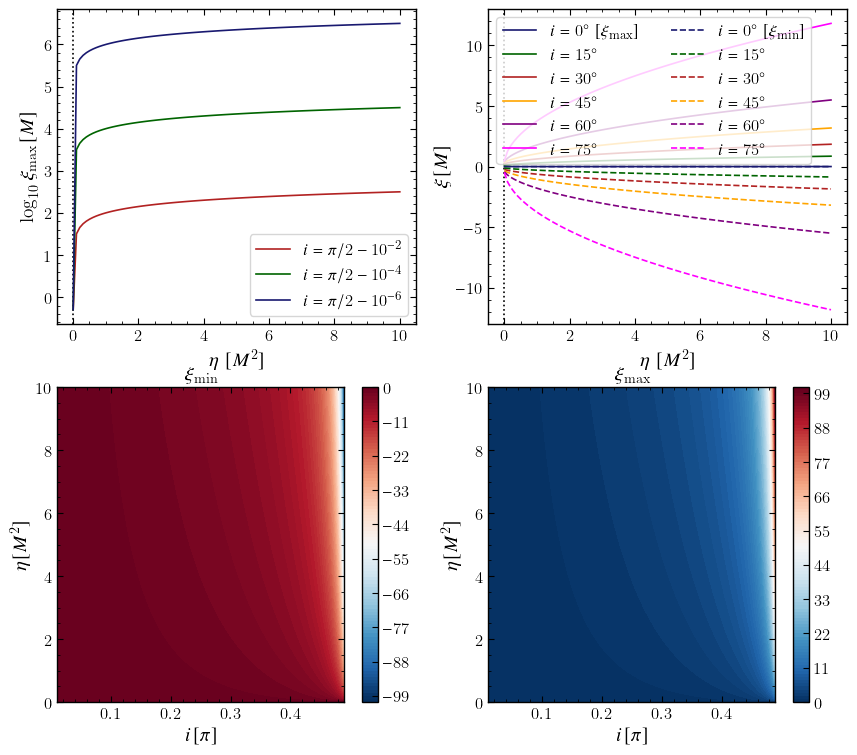

In [22]:
a_Val, L_Val = (0.5, 1e-3)

eta_List = range(0.0,  10.0, length=100)
inc_List = range(1e-2, 0.49, length=100)

xi_Max_List_90_1e2 = []
xi_Max_List_90_1e4 = []
xi_Max_List_90_1e6 = []

xi_Min_List_90 = []
xi_Max_List_90 = []

xi_Min_List_75 = []
xi_Max_List_75 = []

xi_Min_List_60 = []
xi_Max_List_60 = []

xi_Min_List_45 = []
xi_Max_List_45 = []

xi_Min_List_30 = []
xi_Max_List_30 = []

xi_Min_List_15 = []
xi_Max_List_15 = []

xi_Min_List_00 = []
xi_Max_List_00 = []

xi_Min_List = Array{Float64}(undef, length(eta_List), length(inc_List))
xi_Max_List = Array{Float64}(undef, length(eta_List), length(inc_List))

for (i, eta_Val) in enumerate(eta_List)
    
    push!(xi_Max_List_90_1e2, log10(xi_Max_OrdNG(pi/2.0-1e-2, (a_Val, L_Val), (eta_Val, 0.0))))
    push!(xi_Max_List_90_1e4, log10(xi_Max_OrdNG(pi/2.0-1e-4, (a_Val, L_Val), (eta_Val, 0.0))))
    push!(xi_Max_List_90_1e6, log10(xi_Max_OrdNG(pi/2.0-1e-6, (a_Val, L_Val), (eta_Val, 0.0))))
    
    push!(xi_Min_List_90, xi_Min_OrdNG(pi/2.0-1e-3,   (a_Val, L_Val), (eta_Val, 0.0)))
    push!(xi_Max_List_90, xi_Max_OrdNG(pi/2.0-1e-3,   (a_Val, L_Val), (eta_Val, 0.0)))
    
    push!(xi_Min_List_75, xi_Min_OrdNG(75.0*pi/180.0, (a_Val, L_Val), (eta_Val, 0.0)))
    push!(xi_Max_List_75, xi_Max_OrdNG(75.0*pi/180.0, (a_Val, L_Val), (eta_Val, 0.0)))
    
    push!(xi_Min_List_60, xi_Min_OrdNG(pi/3.0,        (a_Val, L_Val), (eta_Val, 0.0)))
    push!(xi_Max_List_60, xi_Max_OrdNG(pi/3.0,        (a_Val, L_Val), (eta_Val, 0.0)))
    
    push!(xi_Min_List_45, xi_Min_OrdNG(pi/4.0,        (a_Val, L_Val), (eta_Val, 0.0)))
    push!(xi_Max_List_45, xi_Max_OrdNG(pi/4.0,        (a_Val, L_Val), (eta_Val, 0.0)))
    
    push!(xi_Min_List_30, xi_Min_OrdNG(pi/6.0,        (a_Val, L_Val), (eta_Val, 0.0)))
    push!(xi_Max_List_30, xi_Max_OrdNG(pi/6.0,        (a_Val, L_Val), (eta_Val, 0.0)))
    
    push!(xi_Min_List_15, xi_Min_OrdNG(pi/12.0,       (a_Val, L_Val), (eta_Val, 0.0)))
    push!(xi_Max_List_15, xi_Max_OrdNG(pi/12.0,       (a_Val, L_Val), (eta_Val, 0.0)))
    
    push!(xi_Min_List_00, xi_Min_OrdNG(1e-3,          (a_Val, L_Val), (eta_Val, 0.0)))
    push!(xi_Max_List_00, xi_Max_OrdNG(1e-3,          (a_Val, L_Val), (eta_Val, 0.0)))
    
    for (j, inc_Val) in enumerate(inc_List)
        xi_Min_List[i, j] = xi_Min_OrdNG(inc_Val*pi, (a_Val, L_Val), (eta_Val, 0.0))
        xi_Max_List[i, j] = xi_Max_OrdNG(inc_Val*pi, (a_Val, L_Val), (eta_Val, 0.0))
    end
end

###########################################################################################
# Figure
###########################################################################################

n_rows = 2
n_cols = 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "xi_Max_Eq"       => fig.add_subplot(gs[1,1]),
    "xi_Min_Max_incs" => fig.add_subplot(gs[1,2]),
    "xi_Min"          => fig.add_subplot(gs[2,1]),
    "xi_Max"          => fig.add_subplot(gs[2,2]),
)

# Top-Left Panel

axes["xi_Max_Eq"].axvline(x=0.0, color=colors[1], ls=linestyles[3])

axes["xi_Max_Eq"].set(xlabel=L"$\eta\ [M^2]$", ylabel=L"$\log_{10}{\xi_{\rm max} [M]}$")

axes["xi_Max_Eq"].plot(eta_List, xi_Max_List_90_1e2, label=L"i = \pi/2 - 10^{-2}", color=colors[4])
axes["xi_Max_Eq"].plot(eta_List, xi_Max_List_90_1e4, label=L"i = \pi/2 - 10^{-4}", color=colors[3])
axes["xi_Max_Eq"].plot(eta_List, xi_Max_List_90_1e6, label=L"i = \pi/2 - 10^{-6}", color=colors[2])

axes["xi_Max_Eq"].legend(loc="best", ncol=1)

# Top-Right Panel

axes["xi_Min_Max_incs"].axvline(x=0.0, color=colors[1], ls=linestyles[3])

axes["xi_Min_Max_incs"].set(xlabel=L"$\eta\ [M^2]$", ylabel=L"$\xi [M]$")

axes["xi_Min_Max_incs"].plot(eta_List, xi_Max_List_00, label=L"i = 0^\circ\ [\xi_{\rm max}]", color=colors[2], linestyle=linestyles[1])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Max_List_15, label=L"i = 15^\circ",                 color=colors[3], linestyle=linestyles[1])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Max_List_30, label=L"i = 30^\circ",                 color=colors[4], linestyle=linestyles[1])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Max_List_45, label=L"i = 45^\circ",                 color=colors[5], linestyle=linestyles[1])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Max_List_60, label=L"i = 60^\circ",                 color=colors[6], linestyle=linestyles[1])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Max_List_75, label=L"i = 75^\circ",                 color=colors[7], linestyle=linestyles[1])

axes["xi_Min_Max_incs"].plot(eta_List, xi_Min_List_00, label=L"i = 0^\circ\ [\xi_{\rm min}]", color=colors[2], linestyle=linestyles[2])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Min_List_15, label=L"i = 15^\circ",                 color=colors[3], linestyle=linestyles[2])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Min_List_30, label=L"i = 30^\circ",                 color=colors[4], linestyle=linestyles[2])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Min_List_45, label=L"i = 45^\circ",                 color=colors[5], linestyle=linestyles[2])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Min_List_60, label=L"i = 60^\circ",                 color=colors[6], linestyle=linestyles[2])
axes["xi_Min_Max_incs"].plot(eta_List, xi_Min_List_75, label=L"i = 75^\circ",                 color=colors[7], linestyle=linestyles[2])

axes["xi_Min_Max_incs"].legend(loc="best", ncol=2)

# Top-Left Panel

cp_xi_Min = axes["xi_Min"].contourf(inc_List, eta_List, xi_Min_List; levels=100, cmap="RdBu_r", vmin=-100, vmax=0)

# cl_xi_Min = axes["xi_Min"].contour(inc_List, eta_List, xi_Min_List; levels=10, colors="k", linewidths=1.0)
# axes["xi_Min"].clabel(cl_xi_Min; inline=true, fmt="%.2f")

axes["xi_Min"].set_xlabel(L"i [\pi]")
axes["xi_Min"].set_ylabel(L"\eta [M^2]")
axes["xi_Min"].set_title(L"\xi_{\rm min}")

fig.colorbar(cp_xi_Min, ax=axes["xi_Min"])

# Top-Right Panel

cp_xi_Max = axes["xi_Max"].contourf(inc_List, eta_List, xi_Max_List; levels=100, cmap="RdBu_r", vmin=0, vmax=100)

# cl_xi_Max = axes["xi_Max"].contour(inc_List, eta_List, xi_Max_List; levels=10, colors="k", linewidths=1.0)
# axes["xi_Max"].clabel(cl_xi_Max; inline=true, fmt="%.2f")

axes["xi_Max"].set_xlabel(L"i [\pi]")
axes["xi_Max"].set_ylabel(L"\eta [M^2]")
axes["xi_Max"].set_title(L"\xi_{\rm max}")

fig.colorbar(cp_xi_Max, ax=axes["xi_Max"])
savefig("./Figures/Tests/Fig13-KH-NG-xi-Bounds-inc.png", dpi=150)

In [23]:
###########################################################################################
# Radial Turning Point
###########################################################################################

function r_tp(metric_params, NG_params; tol = TOL_SOLVE, f_tol = TOL_SOLVE)

    rH_Val  = rH_cached(metric_params)
    rPS_Val = rSNG_mp_cached(oftype(rH_Val, π/2), metric_params)[2]

    eta, xi = NG_params
    NG_params_large = max(abs(eta), abs(xi))

    V_r_Eq_s(s) = V_r(rH_Val + softplus(s), metric_params, NG_params)

    # Make the bracketing typed and consistent with Double64
    s_lo = invsoftplus(oftype(rH_Val, EPS_GEOM))  # r_lo = rH + EPS_GEOM

    s_hi_arg = max(rPS_Val - rH_Val + oftype(rH_Val, 10) * NG_params_large, oftype(rH_Val, 10))
    s_hi = invsoftplus(s_hi_arg)

    grid_num = 400
    s_grid = range(s_lo, s_hi; length = grid_num)
    V_vals = V_r_Eq_s.(s_grid)

    last_bracket = nothing

    for i in 1:(grid_num-1)
        v0, v1 = V_vals[i], V_vals[i+1]

        # Case 1: sign change -> bracket
        if isfinite(v0) && isfinite(v1) && (v0 * v1 < zero(v0))
            last_bracket = (s_grid[i], s_grid[i+1])

        # Case 2: near-zero sample -> try to bracket around it
        elseif isfinite(v0) && abs(v0) ≤ oftype(v0, f_tol)
            if i > 1 && i < grid_num
                last_bracket = (s_grid[i-1], s_grid[i+1])
            else
                last_bracket = (s_grid[i], s_grid[i+1])
            end
        end
    end

    # Return typed NaNs
    last_bracket === nothing && return (oftype(rH_Val, NaN), oftype(rH_Val, NaN))

    sL, sU = last_bracket

    try
        s_tp = find_zero(V_r_Eq_s, (sL, sU); method = :brent, xtol = oftype(rH_Val, tol))
        r_tp_val = rH_Val + softplus(s_tp)
        return (r_tp_val, V_r_Eq_s(s_tp))
    catch
        return (oftype(rH_Val, NaN), oftype(rH_Val, NaN))
    end
end

r_tp (generic function with 1 method)

1.85678022202968534413307263370723904

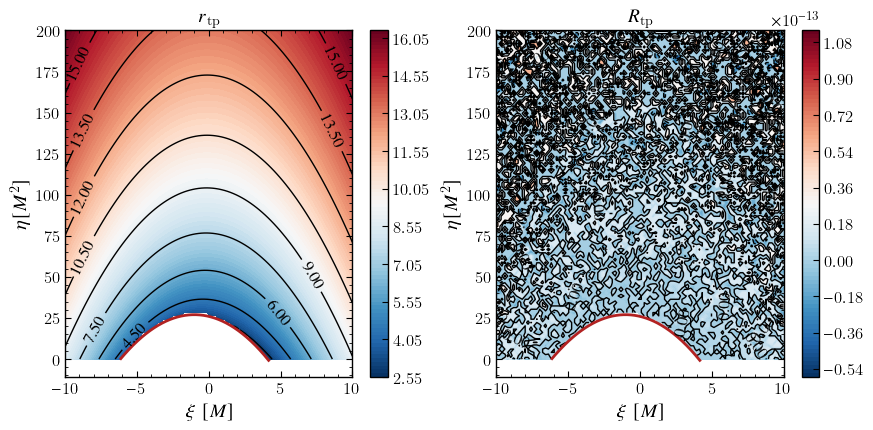

In [24]:
metric_params_Val = (0.5, 0.4)

xi_List  = collect(range(-10.0, 10.0, length=100))
eta_List = collect(range(0.0, 200.0, length=100))

rtp_List = fill(NaN, length(eta_List), length(xi_List))
Rtp_List = fill(NaN, length(eta_List), length(xi_List))

for (i, xi_Val) in enumerate(xi_List)
    for (j, eta_Val) in enumerate(eta_List)
        rtp_Val, Rtp_Val = r_tp(metric_params_Val, (eta_Val, xi_Val))
        if !isnan(rtp_Val)
            rtp_List[j, i], Rtp_List[j, i] = rtp_Val, Rtp_Val
        end
    end
end

rPS_m_Val, rPS_p_Val = rSNG_mp(pi/2, metric_params_Val)

rPS_List = range(rPS_m_Val, rPS_p_Val, length=1000)

xi_SNG_List  = [xi_SNG( r, (a_Val, L_Val)) for r in rPS_List] 
eta_SNG_List = [eta_SNG(r, (a_Val, L_Val)) for r in rPS_List]

###########################################################################################
# Figure
###########################################################################################

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows = 1
n_cols = 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "rtp" => fig.add_subplot(gs[1,1]),
    "Rtp" => fig.add_subplot(gs[1,2])
)

# Left Panel

axes["rtp"].set_xlabel(L"\xi\ [M]")
axes["rtp"].set_ylabel(L"\eta [M^2]")
axes["rtp"].set_title(L"r_{\rm tp}")

cp_rtp = axes["rtp"].contourf(xi_List, eta_List, rtp_List; levels=100, cmap="RdBu_r")
fig.colorbar(cp_rtp, ax=axes["rtp"], extend="both")

cl_rtp = axes["rtp"].contour( xi_List, eta_List, rtp_List; levels=10, colors="k", linewidths=1.0)
axes["rtp"].clabel(cl_rtp; inline=true, fmt="%.2f")

axes["rtp"].plot(xi_SNG_List, eta_SNG_List, color=colors[4], linewidth=linewidths[4])

# Right Panel

axes["Rtp"].set_xlabel(L"\xi\ [M]")
axes["Rtp"].set_ylabel(L"\eta [M^2]")
axes["Rtp"].set_title(L"R_{\rm tp}")

cp_Rtp = axes["Rtp"].contourf(xi_List, eta_List, Rtp_List; levels=100, cmap="RdBu_r")
fig.colorbar(cp_Rtp, ax=axes["Rtp"], extend="both")

cl_Rtp = axes["Rtp"].contour( xi_List, eta_List, Rtp_List; levels=10, colors="k", linewidths=1.0)
axes["Rtp"].clabel(cl_Rtp; inline=true, fmt="%.2f")

axes["Rtp"].plot(xi_SNG_List, eta_SNG_List, color=colors[4], linewidth=linewidths[4])

print(rH(metric_params_Val))
savefig("./Figures/Tests/Fig14-KH-NG-Radial-Turning-Points.png", dpi=150)

In [25]:
###########################################################################################
# Region membership: inside ordinary-geodesic parabola band AND below the SNG shadow curve
###########################################################################################

# Some typing nonsense
@inline function _promote_T(inc, metric_params, eta=zero(inc), xi=zero(inc))
    return promote_type(typeof(inc), typeof(metric_params[1]), typeof(metric_params[2]), typeof(eta), typeof(xi))
end

@inline _nan(::Type{T}) where {T}  = T(NaN)
@inline _ninf(::Type{T}) where {T} = -T(Inf)

# Build shadow curve eta_sh(xi) for xi_min_sh <= xi <= xi_max_sh from parametric SNG curve (xi_SNG(r), eta_SNG(r))
function build_shadow_envelope(inc, metric_params; Nr::Integer=2000, nbins::Integer=4000)
    T = _promote_T(inc, metric_params)

    rmin, rmax = rSNG_mp(inc, metric_params)
    rgrid = range(rmin, rmax; length=Nr)

    xi_vals  = Vector{T}(undef, Nr)
    eta_vals = Vector{T}(undef, Nr)

    @inbounds for (k, r) in enumerate(rgrid)
        xi_vals[k]  = convert(T, xi_SNG(r, metric_params))
        eta_vals[k] = convert(T, eta_SNG(r, metric_params))
    end

    good = isfinite.(xi_vals) .& isfinite.(eta_vals)
    xi_f  = xi_vals[good]
    eta_f = eta_vals[good]

    isempty(xi_f) && return T[], T[], _nan(T), _nan(T)

    xi_min_sh = minimum(xi_f)
    xi_max_sh = maximum(xi_f)

    if !(xi_min_sh < xi_max_sh)
        return T[], T[], xi_min_sh, xi_max_sh
    end

    edges   = range(xi_min_sh, xi_max_sh; length=nbins+1)
    eta_bin = fill(_ninf(T), nbins)

    invd = (T(nbins)) / (xi_max_sh - xi_min_sh)

    @inbounds for k in eachindex(xi_f)
        x = xi_f[k]
        b = Int(floor((x - xi_min_sh) * invd)) + 1
        b = clamp(b, 1, nbins)

        y = eta_f[k]
        if y > eta_bin[b]
            eta_bin[b] = y
        end
    end

    keep = eta_bin .> _ninf(T)

    xi_nodes  = Vector{T}(undef, count(keep))
    eta_nodes = Vector{T}(undef, count(keep))

    idx = 0
    @inbounds for b in 1:nbins
        if keep[b]
            idx += 1
            xi_nodes[idx]  = (edges[b] + edges[b+1]) / T(2)
            eta_nodes[idx] = eta_bin[b]
        end
    end

    return xi_nodes, eta_nodes, xi_min_sh, xi_max_sh
end

@inline _primal(x) = x
@inline _primal(x::ForwardDiff.Dual) = ForwardDiff.value(x)

@inline function eta_sh(xi::Real, xi_nodes::AbstractVector, eta_nodes::AbstractVector)
    n = length(xi_nodes)
    n == 0 && return oftype(xi, NaN)

    x_lo = xi_nodes[1]
    x_hi = xi_nodes[end]

    # Use only the primal part to choose the interpolation bin
    xv = _primal(xi)

    (xv < x_lo || xv > x_hi) && return oftype(xi, NaN)

    i = searchsortedlast(xi_nodes, xv)

    i == n && return xi + (eta_nodes[n] - xi)
    i == 0 && return xi + (eta_nodes[1] - xi)

    x0 = xi_nodes[i]
    x1 = xi_nodes[i+1]
    y0 = eta_nodes[i]
    y1 = eta_nodes[i+1]

    if x1 == x0
        y = max(y0, y1)
        return xi + (y - xi)
    end

    t = (xi - x0) / (x1 - x0)
    return (one(t) - t) * y0 + t * y1
end

# We want the inc to be pi/2 because xi_sh(pi/2) < xi_min_ordNG(inc) < xi_sh(inc != pi/2). This is allowed since there are still no radial turning points for such xi_min_ordNG
function make_shadow_cache(metric_params; Nr=2000, nbins=4000)
    xi_nodes, eta_nodes, xi_min_sh, xi_max_sh = build_shadow_envelope(pi/2 - EPS_HEUR, metric_params; Nr=Nr, nbins=nbins)
    return (xi_nodes  = xi_nodes, eta_nodes = eta_nodes, xi_min_sh = xi_min_sh, xi_max_sh = xi_max_sh)
end

# Physics note: See how we ignore the region outside xi_min_sh <= xi <= xi_max_sh. This is because in this region r_tp exists (see figure above)
# Implementation note: shadow_cache = make_shadow_cache(inc, metric_params) has to be passed into this function because it should not rebuild the shadow envelope every time. The envelope is expensive to compute. Want to compute once and reuse.
function in_region_checker(inc, metric_params, NG_params, shadow_cache)
    eta, xi = NG_params

    T = _promote_T(inc, metric_params, eta, xi)

    etaT = convert(T, eta)
    xiT  = convert(T, xi)

    # Ordinary geodesics: eta > 0
    !(etaT > zero(T)) && return false

    # Shadow xi-domain
    xi_min_shT = convert(T, shadow_cache.xi_nodes[1])
    xi_max_shT = convert(T, shadow_cache.xi_nodes[end])
    !(xi_min_shT <= xiT <= xi_max_shT) && return false

    # Parabola band bounds at this eta
    xi_min = xi_Min_OrdNG(inc, metric_params, (etaT, zero(T)))
    xi_max = xi_Max_OrdNG(inc, metric_params, (etaT, zero(T)))

    # (isnan(xi_min) || isnan(xi_max) || xi_min >= xi_max) && return false
    # isnan(xi_min) / isnan(xi_max) might throw for some types so we are rewriting the above with the below. Logic: if you check NaN == NaN, it will return false. Beauty of NaNs
    (! (xi_min == xi_min) || ! (xi_max == xi_max) || xi_min >= xi_max) && return false
    
    !(xi_min <= xiT <= xi_max) && return false

    # Below the shadow boundary: eta <= eta_sh(xi)
    eta_sh_Val = eta_sh(xiT, shadow_cache.xi_nodes, shadow_cache.eta_nodes)
    !isfinite(eta_sh_Val) && return false

    return etaT <= convert(T, eta_sh_Val)
end

in_region_checker (generic function with 1 method)

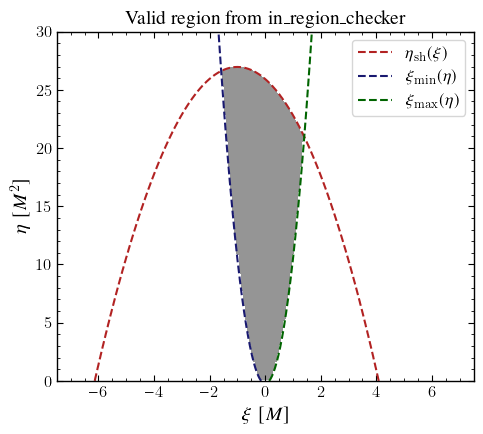

In [26]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0

###########################################################################
# Valid Region Data

eta_List = range(0.0, 30.0, length=150)  
N_xi     = 150                          

shadow_cache_Val = make_shadow_cache(metric_params_Val)

xi_phys_List = fill(NaN, length(eta_List), N_xi)
xi_Min_List  = similar(eta_List)
xi_Max_List  = similar(eta_List)

# Plot grid
eta_List = range(0.0, 30.0; length=300)
xi_List  = range(-7.5, 7.5; length=200)

neta = length(eta_List)
nxi  = length(xi_List)

# Domain field: 1.0 inside region, NaN outside (so contourf can mask it cleanly)
domain_field = Array{Float64}(undef, neta, nxi)
fill!(domain_field, NaN)

@inbounds for (i, eta) in enumerate(eta_List)
    for (j, xi) in enumerate(xi_List)
        if in_region_checker(inc_Val_2, metric_params_Val, (eta, xi), shadow_cache_Val)
            domain_field[i, j] = 1.0
        end
    end
end

###########################################################################

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 1, 1

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict("in_region" => fig.add_subplot(gs[1,1]))

using PyPlot
using PyCall

# --- define masked() exactly as you want it ---
np = pyimport("numpy")
masked(Z) = np.ma.masked_invalid(Z)


mZ = masked(domain_field)   # <-- now works

axes["in_region"].contourf(xi_List, eta_List, mZ; levels=[0.5, 1.5], cmap="Greys")

axes["in_region"].set_xlabel(L"\xi\ [M]")
axes["in_region"].set_ylabel(L"\eta\ [M^2]")
axes["in_region"].set_title("Valid region from in_region_checker")

# Shadow envelope overlay
axes["in_region"].plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, color=colors[4], ls="--", lw=1.5, label=L"$\eta_{\rm sh}(\xi)$")

# Parabola bounds overlay (use inc_Val_2, not inc_Val)
xi_min_curve = Vector{Float64}(undef, neta)
xi_max_curve = Vector{Float64}(undef, neta)

@inbounds for (i, eta) in enumerate(eta_List)
    xi_min_curve[i] = xi_Min_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
    xi_max_curve[i] = xi_Max_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
end

good_min = isfinite.(xi_min_curve)
good_max = isfinite.(xi_max_curve)

axes["in_region"].plot(xi_min_curve[good_min], collect(eta_List)[good_min], color=colors[2], ls="--", lw=1.5, label=L"$\xi_{\rm min}(\eta)$")
axes["in_region"].plot(xi_max_curve[good_max], collect(eta_List)[good_max], color=colors[3], ls="--", lw=1.5, label=L"$\xi_{\rm max}(\eta)$")

axes["in_region"].set_xlim(-7.5, 7.5)
axes["in_region"].set_ylim(0, 30)

axes["in_region"].legend(loc="upper right", frameon=true)
tight_layout()

savefig("./Figures/Tests/Fig15-KH-IS-NG-Allowed-Region.png", dpi=150)

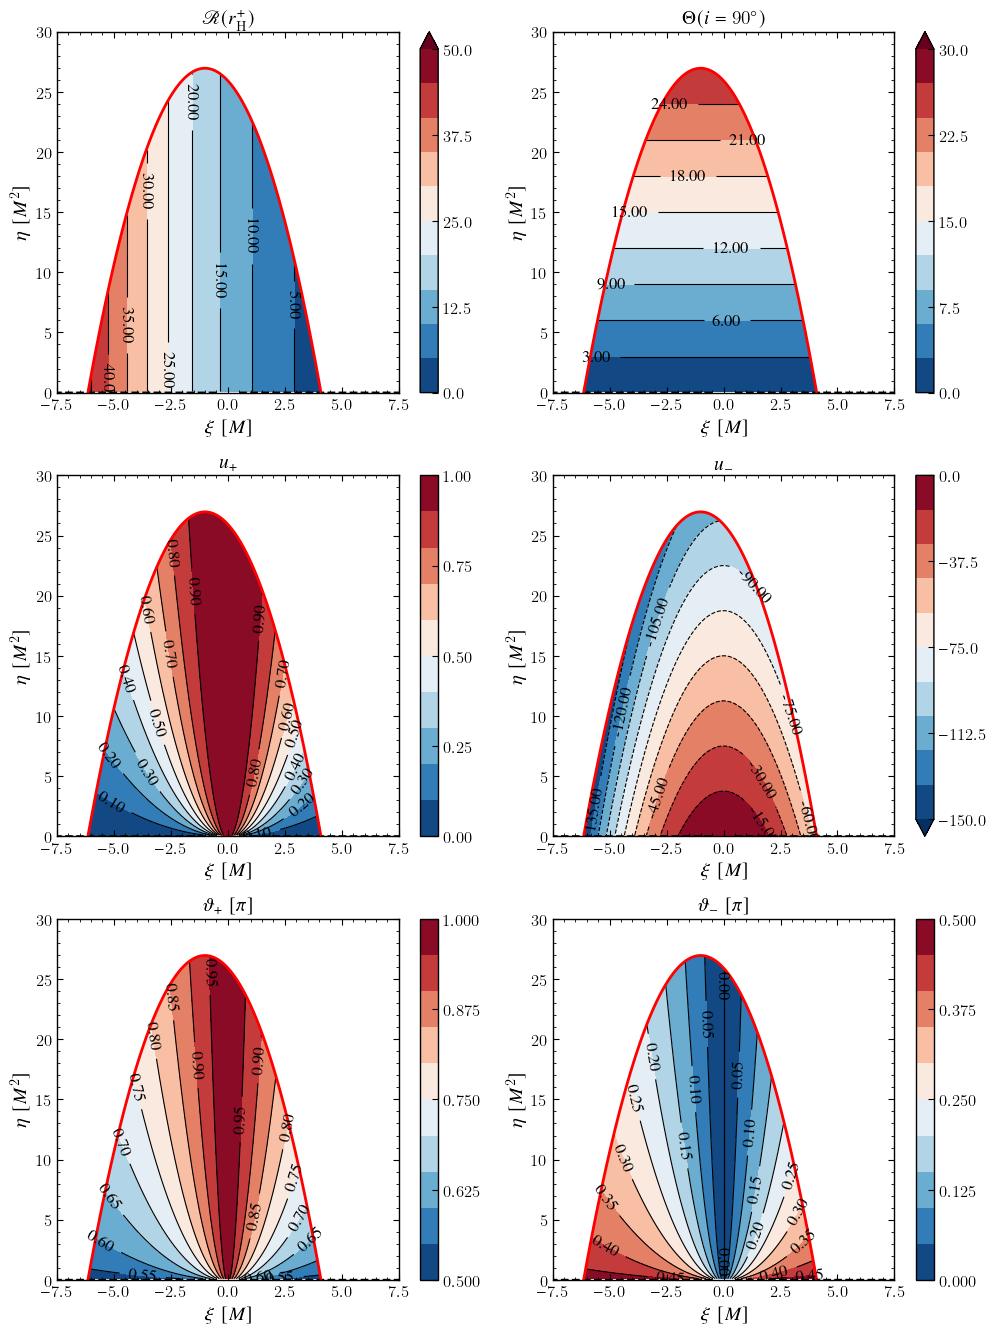

In [27]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

###########################################################################################
# Grid
eta_List = range(0.0, 30.0; length=300)
xi_List  = range(-7.0, 7.0; length=751)

neta = length(eta_List)
nxi  = length(xi_List)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List = fill(NaN, neta)
xi_Max_List = fill(NaN, neta)

@inbounds for (i, eta) in enumerate(eta_List)
    xi_Min_List[i] = xi_Min_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
    xi_Max_List[i] = xi_Max_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid

# T_List      = fill(NaN, neta, nxi)
# Phi_List    = fill(NaN, neta, nxi)
R_List      = fill(NaN, neta, nxi)
Th_List     = fill(NaN, neta, nxi)
up_List     = fill(NaN, neta, nxi)
um_List     = fill(NaN, neta, nxi)
th_Max_List = fill(NaN, neta, nxi)
th_Min_List = fill(NaN, neta, nxi)

rH_Val = rH(metric_params_Val)*(1.0+EPS_GEOM)

@inbounds for (i, eta) in enumerate(eta_List)
    for (j, xi) in enumerate(xi_List)
        NG_params_Val = (eta, xi)
        if in_region_checker(inc_Val_1, metric_params_Val, NG_params_Val, shadow_cache_Val)
            # T_List[i, j]      = T_r(rH_Val,   metric_params_Val, NG_params_Val)
            # Phi_List[i, j]    = Phi_r(rH_Val, metric_params_Val, NG_params_Val)
            R_List[i, j]      = R_r(rH_Val,   metric_params_Val, NG_params_Val)
            Th_List[i, j]     = Th(inc_Val_1, metric_params_Val, NG_params_Val)
            up_List[i, j]     = u_p(          metric_params_Val, NG_params_Val)
            um_List[i, j]     = u_m(          metric_params_Val, NG_params_Val)
            th_Max_List[i, j] = th_Max(       metric_params_Val, NG_params_Val)/pi
            th_Min_List[i, j] = th_Min(       metric_params_Val, NG_params_Val)/pi
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour
xi_mat  = repeat(collect(xi_List)', neta, 1)   # neta × nxi
eta_mat = repeat(collect(eta_List), 1, nxi)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

function plot_phys_contour(fig, ax, extend_x, xi_mat, eta_mat, eta_List, data, title, xi_Min_List, xi_Max_List, shadow_cache_Val; vmin, vmax, nlevels=11, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-7.5, +7.5])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat, eta_mat, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend=extend_x)

    cb = fig.colorbar(cp, ax=ax, extend=extend_x)
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat, eta_mat, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List, eta_List, "k--", lw=1.5)
    ax.plot(xi_Max_List, eta_List, "k--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 3, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    # "T"      => fig.add_subplot(gs[1, 1]),
    # "Phi"    => fig.add_subplot(gs[1, 2]),
    "R"      => fig.add_subplot(gs[1, 1]),
    "Th"     => fig.add_subplot(gs[1, 2]),
    "up"     => fig.add_subplot(gs[2, 1]),
    "um"     => fig.add_subplot(gs[2, 2]),
    "th_Max" => fig.add_subplot(gs[3, 1]),
    "th_Min" => fig.add_subplot(gs[3, 2])
)

# plot_phys_contour(fig, axes["T"],      xi_mat, eta_mat, eta_List, T_List,      L"$\mathscr{T}(r_{\rm H}^+)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-50, vmax=+50)

# plot_phys_contour(fig, axes["Phi"],    xi_mat, eta_mat, eta_List, Phi_List,    L"$\Phi(r_{\rm H}^+)$",        xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-50, vmax=+50)

plot_phys_contour(fig, axes["R"],      "max",     xi_mat, eta_mat, eta_List, R_List,      L"$\mathscr{R}(r_{\rm H}^+)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=50)

plot_phys_contour(fig, axes["Th"],     "max",     xi_mat, eta_mat, eta_List, Th_List,     L"$\Theta(i=90^\circ)$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=+30)

plot_phys_contour(fig, axes["up"],     "neither", xi_mat, eta_mat, eta_List, up_List,     L"$u_+$",                      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=1)

plot_phys_contour(fig, axes["um"],     "min",     xi_mat, eta_mat, eta_List, um_List,     L"$u_-$",                      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-150, vmax=+0)

plot_phys_contour(fig, axes["th_Max"], "neither", xi_mat, eta_mat, eta_List, th_Max_List, L"$\vartheta_+\ [\pi]$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0.5, vmax=1)

plot_phys_contour(fig, axes["th_Min"], "neither", xi_mat, eta_mat, eta_List, th_Min_List, L"$\vartheta_-\ [\pi]$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=0.5)

fig.tight_layout()
savefig("./Figures/Tests/Fig16a-KH-Allowed-Region-NG-Motion-Eq.png", dpi=150)

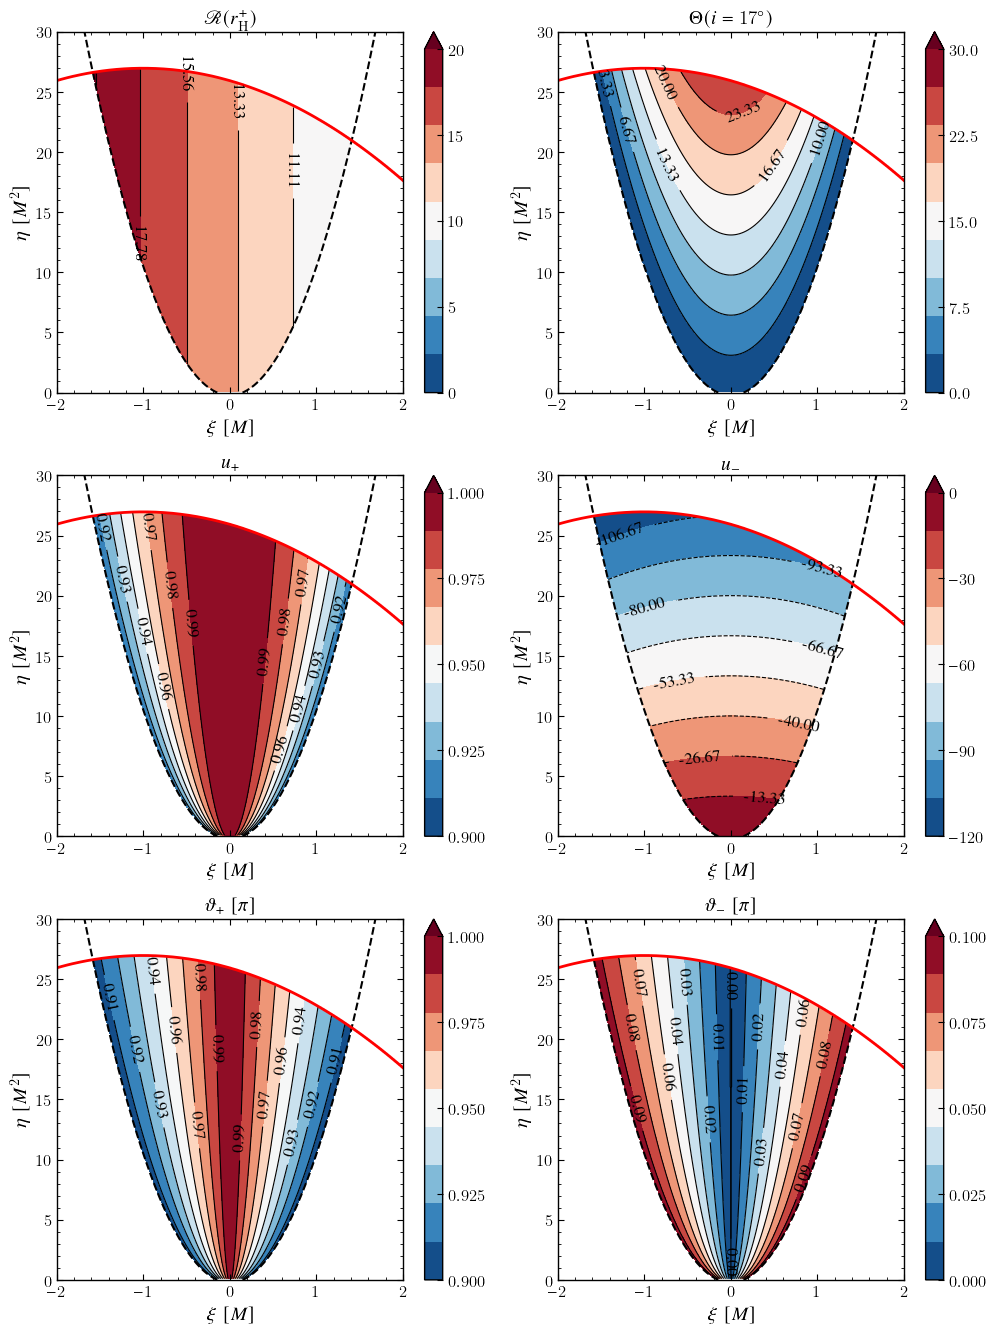

In [28]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

###########################################################################################
# Grid
eta_List = range(0.0, 30.0; length=300)
xi_List  = range(-2.0, 2.0; length=501)

neta = length(eta_List)
nxi  = length(xi_List)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List = fill(NaN, neta)
xi_Max_List = fill(NaN, neta)

@inbounds for (i, eta) in enumerate(eta_List)
    xi_Min_List[i] = xi_Min_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
    xi_Max_List[i] = xi_Max_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid

# T_List      = fill(NaN, neta, nxi)
# Phi_List    = fill(NaN, neta, nxi)
R_List      = fill(NaN, neta, nxi)
Th_List     = fill(NaN, neta, nxi)
up_List     = fill(NaN, neta, nxi)
um_List     = fill(NaN, neta, nxi)
th_Max_List = fill(NaN, neta, nxi)
th_Min_List = fill(NaN, neta, nxi)

rH_Val = rH(metric_params_Val)*(1.0+EPS_GEOM)

@inbounds for (i, eta) in enumerate(eta_List)
    for (j, xi) in enumerate(xi_List)
        NG_params_Val = (eta, xi)
        if in_region_checker(inc_Val_2, metric_params_Val, NG_params_Val, shadow_cache_Val)
            # T_List[i, j]      = T_r(rH_Val,   metric_params_Val, NG_params_Val)
            # Phi_List[i, j]    = Phi_r(rH_Val, metric_params_Val, NG_params_Val)
            R_List[i, j]      = R_r(rH_Val,   metric_params_Val, NG_params_Val)
            Th_List[i, j]     = Th(inc_Val_2, metric_params_Val, NG_params_Val)
            up_List[i, j]     = u_p(          metric_params_Val, NG_params_Val)
            um_List[i, j]     = u_m(          metric_params_Val, NG_params_Val)
            th_Max_List[i, j] = th_Max(       metric_params_Val, NG_params_Val)/pi
            th_Min_List[i, j] = th_Min(       metric_params_Val, NG_params_Val)/pi
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour
xi_mat  = repeat(collect(xi_List)', neta, 1)   # neta × nxi
eta_mat = repeat(collect(eta_List), 1, nxi)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

function plot_phys_contour(fig, ax, xi_mat, eta_mat, eta_List, data, title, xi_Min_List, xi_Max_List, shadow_cache_Val; vmin, vmax, nlevels=10, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-2, +2])
    ax.set_ylim([0., +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat, eta_mat, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat, eta_mat, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List, eta_List, "k--", lw=1.5)
    ax.plot(xi_Max_List, eta_List, "k--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 3, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    # "T"      => fig.add_subplot(gs[1, 1]),
    # "Phi"    => fig.add_subplot(gs[1, 2]),
    "R"      => fig.add_subplot(gs[1, 1]),
    "Th"     => fig.add_subplot(gs[1, 2]),
    "up"     => fig.add_subplot(gs[2, 1]),
    "um"     => fig.add_subplot(gs[2, 2]),
    "th_Max" => fig.add_subplot(gs[3, 1]),
    "th_Min" => fig.add_subplot(gs[3, 2])
)

# plot_phys_contour(fig, axes["T"],      xi_mat, eta_mat, eta_List, T_List,      L"$\mathscr{T}(r_{\rm H}^+)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-50, vmax=+50)

# plot_phys_contour(fig, axes["Phi"],    xi_mat, eta_mat, eta_List, Phi_List,    L"$\Phi(r_{\rm H}^+)$",        xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-50, vmax=+50)

plot_phys_contour(fig, axes["R"],      xi_mat, eta_mat, eta_List, R_List,      L"$\mathscr{R}(r_{\rm H}^+)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=20)

plot_phys_contour(fig, axes["Th"],     xi_mat, eta_mat, eta_List, Th_List,     L"$\Theta(i=17^\circ)$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=+30)

plot_phys_contour(fig, axes["up"],     xi_mat, eta_mat, eta_List, up_List,     L"$u_+$",                      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0.9, vmax=1)

plot_phys_contour(fig, axes["um"],     xi_mat, eta_mat, eta_List, um_List,     L"$u_-$",                      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-120, vmax=+0)

plot_phys_contour(fig, axes["th_Max"], xi_mat, eta_mat, eta_List, th_Max_List, L"$\vartheta_+\ [\pi]$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0.9, vmax=1)

plot_phys_contour(fig, axes["th_Min"], xi_mat, eta_mat, eta_List, th_Min_List, L"$\vartheta_-\ [\pi]$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=0.1)

fig.tight_layout()
savefig("./Figures/Tests/Fig16b-KH-Allowed-Region-NG-Motion-M87.png", dpi=150)

In [29]:
###########################################################################################
# Radial NG Integrals (NO TURNING POINT CASE ONLY)
# Gauss–Legendre (fixed nodes), correct turning-point handling
# Integrate from rH + EPS_GEOM to r_max = 10000
# The fixed nodes is super important because with non-fixed nodes integration, the integral can jump as parameters (e.g., NG_params) vary in a discontinuous manner. 
# This creates problems downstream when we want to do integral equation root-finding. See further in Ch. 6 of Antia (2012, HUP)
###########################################################################################

# Inverse Radial Potential, 1/sqrt(|R_r|)
function radial_weight(r, metric_params, NG_params; eps=EPS_SMOOTH)
    Rr = R_r(r, metric_params, NG_params)
    Rp = smooth_relu(Rr; eps=eps)
    return smooth_inv_sqrt(Rp; eps=eps)
end

# Turning-point detection function
@inline function has_turning_point(metric_params, NG_params)
    rtp, _ = r_tp(metric_params, NG_params; tol=TOL_SOLVE)
    return isfinite(rtp)
end

const R_MAX_OUTER = TCOMP(1e3)

function r0_horizon(metric_params; rH_nudge=EPS_GEOM)
    rH_Val = rH_cached(metric_params)
    scale  = max(one(rH_Val), abs(rH_Val))
    nud    = max(oftype(rH_Val, rH_nudge), oftype(rH_Val, 10) * eps(rH_Val)) * scale
    return rH_Val + nud
end

# General radial integrand
@inline function radial_integrand_builder(factor, r0, metric_params, NG_params; eps=EPS_SMOOTH)
    function f(u)
        r  = r0 + u*u
        dr = oftype(u, 2) * u
        return dr * factor(r, metric_params, NG_params) * radial_weight(r, metric_params, NG_params; eps=eps)
    end
end

# General radial integral for orbits with no radial turning points
function radial_integral(factor, metric_params, NG_params; r_max=R_MAX_OUTER, eps=EPS_SMOOTH, rH_nudge=EPS_GEOM, check_tp::Bool=true)
    check_tp && has_turning_point(metric_params, NG_params) && return oftype(metric_params[1], NaN)

    r0   = r0_horizon(metric_params; rH_nudge=rH_nudge)
    rmax = oftype(r0, r_max)
    U    = sqrt(max(rmax - r0, zero(r0)))

    fac = radial_integrand_builder(factor, r0, metric_params, NG_params; eps=eps)
    return gl64_integrate_0_to_U(fac, U)
end

# Radial NG Integrals
I_r(metric_params, NG_params; kwargs...)   = radial_integral((r, mp, ng) -> one(r), metric_params, NG_params; kwargs...)

I_phi(metric_params, NG_params; kwargs...) = radial_integral(Phi_r, metric_params, NG_params; kwargs...)

I_t(metric_params, NG_params; kwargs...)   = radial_integral(T_r, metric_params, NG_params; kwargs...)

I_t (generic function with 1 method)

In [30]:
# metric_params_Val = (0.5, 1e-3)
metric_params_Val = (0.5, 0.4)
NG_params_Val     = (2.5, 1.0)

println("I_r = $(I_r(  metric_params_Val, NG_params_Val))")
println("I_ϕ = $(I_phi(metric_params_Val, NG_params_Val))")
println("I_t = $(I_t(  metric_params_Val, NG_params_Val))")

println("*************************")

inc_Val = 17.0*pi/180.0

println("ξ_max = $(xi_Max_OrdNG(inc_Val, metric_params_Val, NG_params_Val))")

NG_params_Val = (2.5, 0.5)

println("*************************")

println("I_r = $(I_r(  metric_params_Val, NG_params_Val))")
println("I_ϕ = $(I_phi(metric_params_Val, NG_params_Val))")
println("I_t = $(I_t(  metric_params_Val, NG_params_Val))")

I_r = 0.5711642343280611
I_ϕ = 3.482544141737871
I_t = 1039.4506685985148
*************************
ξ_max = 0.5050231949064934
*************************
I_r = 0.5539970400548673
I_ϕ = 3.4837135517961286
I_t = 1039.1868519391178


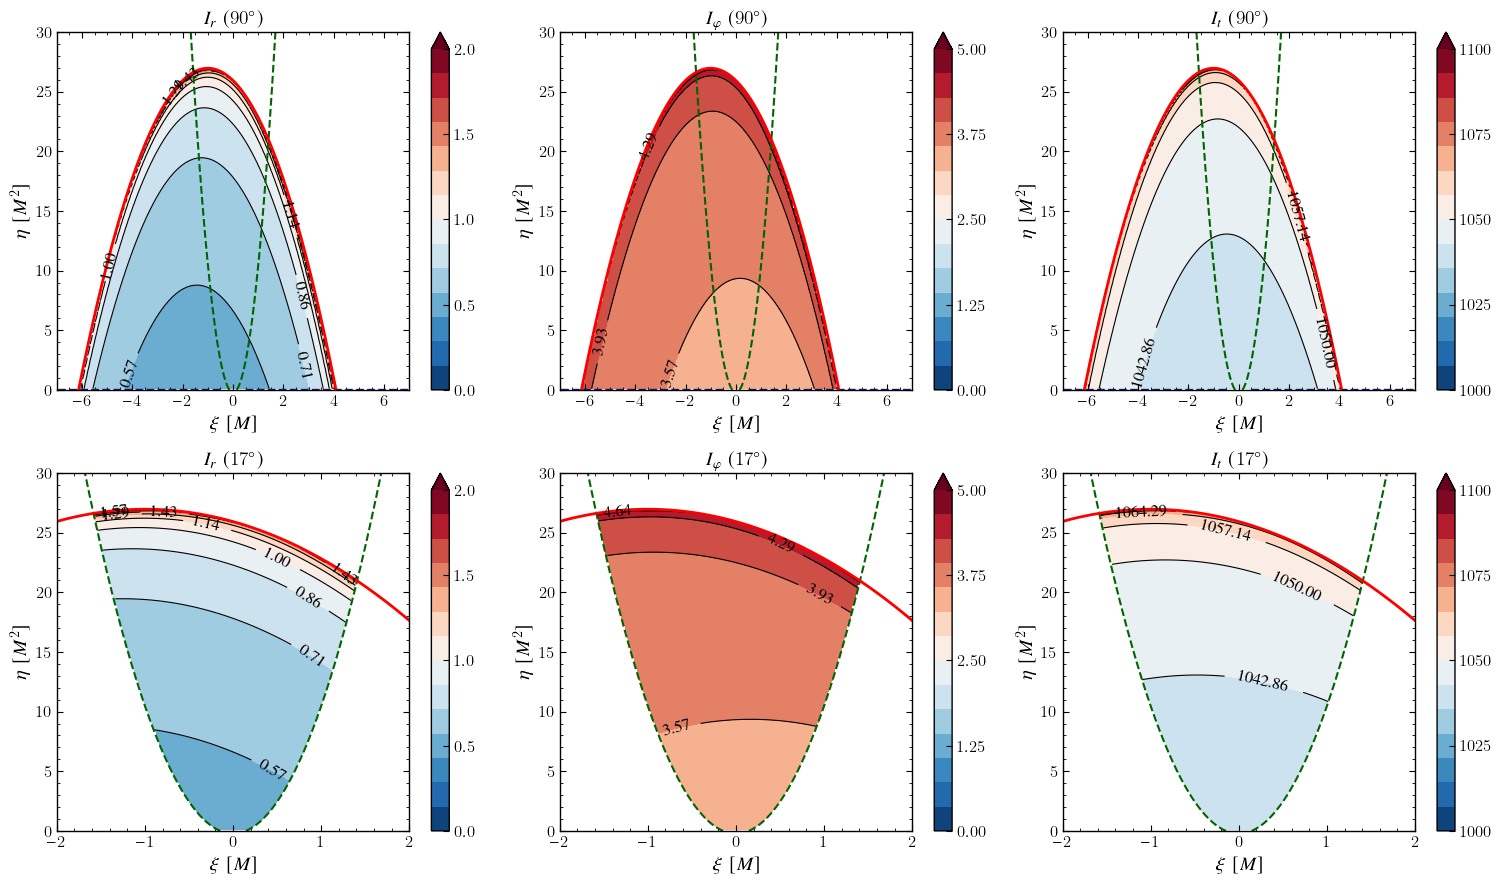

In [31]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Grid
eta_List_90 = range(0.0, 30.0; length=300)
xi_List_90  = range(-10.0, 10.0; length=200)

neta_90 = length(eta_List_90)
nxi_90  = length(xi_List_90)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List_90 = fill(NaN, neta_90)
xi_Max_List_90 = fill(NaN, neta_90)

@inbounds for (i, eta) in enumerate(eta_List_90)
    xi_Min_List_90[i] = xi_Min_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
    xi_Max_List_90[i] = xi_Max_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid
I_r_List_90   = fill(NaN, neta_90, nxi_90)
I_phi_List_90 = fill(NaN, neta_90, nxi_90)
I_t_List_90   = fill(NaN, neta_90, nxi_90)

@inbounds for (i, eta) in enumerate(eta_List_90)
    for (j, xi) in enumerate(xi_List_90)
        NG = (eta, xi)
        if in_region_checker(inc_Val_1, metric_params_Val, NG, shadow_cache_Val)
            I_r_List_90[i, j]   = I_r(  metric_params_Val, NG)
            I_phi_List_90[i, j] = I_phi(metric_params_Val, NG)
            I_t_List_90[i, j]   = I_t(  metric_params_Val, NG)
        end
    end
end

###########################################################################################
# Grid
eta_List_17 = range(0.0, 30.0; length=300)
xi_List_17  = range(-2.0, 2.0; length=200)

neta_17 = length(eta_List_17)
nxi_17  = length(xi_List_17)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List_17 = fill(NaN, neta_17)
xi_Max_List_17 = fill(NaN, neta_17)

@inbounds for (i, eta) in enumerate(eta_List_17)
    xi_Min_List_17[i] = xi_Min_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
    xi_Max_List_17[i] = xi_Max_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid
I_r_List_17   = fill(NaN, neta_17, nxi_17)
I_phi_List_17 = fill(NaN, neta_17, nxi_17)
I_t_List_17   = fill(NaN, neta_17, nxi_17)

@inbounds for (i, eta) in enumerate(eta_List_17)
    for (j, xi) in enumerate(xi_List_17)
        NG = (eta, xi)
        if in_region_checker(inc_Val_2, metric_params_Val, NG, shadow_cache_Val)
            I_r_List_17[i, j]   = I_r(  metric_params_Val, NG)
            I_phi_List_17[i, j] = I_phi(metric_params_Val, NG)
            I_t_List_17[i, j]   = I_t(  metric_params_Val, NG)
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour

xi_mat_90  = repeat(collect(xi_List_90)', neta_90, 1)   # neta × nxi
eta_mat_90 = repeat(collect(eta_List_90), 1, nxi_90)    # neta × nxi

xi_mat_17  = repeat(collect(xi_List_17)', neta_17, 1)   # neta × nxi
eta_mat_17 = repeat(collect(eta_List_17), 1, nxi_17)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

colors     = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]
linestyles = ["-", "--", ":", "-.",
              (0,(3,1,1,1)),   # dash-dot-dot
              (0,(5,2)),       # long dash
              (0,(1,1))]       # dense dotted
linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

function plot_phys_contour_90(fig, ax, xi_mat_90, eta_mat_90, eta_List_90, data, title, xi_Min_List_90, xi_Max_List_90, shadow_cache_Val; vmin, vmax, nlevels=15, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-7, +7])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat_90, eta_mat_90, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat_90, eta_mat_90, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List_90, eta_List_90, color=colors[2], ls="--", lw=1.5)
    ax.plot(xi_Max_List_90, eta_List_90, color=colors[2], ls="--", lw=1.5)
    
    ax.plot(xi_Min_List_17, eta_List_17, color=colors[3], ls="--", lw=1.5)
    ax.plot(xi_Max_List_17, eta_List_17, color=colors[3], ls="--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

function plot_phys_contour_17(fig, ax, xi_mat_17, eta_mat_17, eta_List_17, data, title, xi_Min_List_17, xi_Max_List_17, shadow_cache_Val; vmin, vmax, nlevels=15, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-2, +2])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat_17, eta_mat_17, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat_17, eta_mat_17, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List_17, eta_List_17, color=colors[3], ls="--", lw=1.5)
    ax.plot(xi_Max_List_17, eta_List_17, color=colors[3], ls="--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 2, 3

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "I_r_90"   => fig.add_subplot(gs[1, 1]),
    "I_phi_90" => fig.add_subplot(gs[1, 2]),
    "I_t_90"   => fig.add_subplot(gs[1, 3]),
    "I_r_17"   => fig.add_subplot(gs[2, 1]),
    "I_phi_17" => fig.add_subplot(gs[2, 2]),
    "I_t_17"   => fig.add_subplot(gs[2, 3])
)

plot_phys_contour_90(fig, axes["I_r_90"],   xi_mat_90, eta_mat_90, eta_List_90, I_r_List_90,   L"$I_r\ (90^\circ)$",       xi_Min_List_90, xi_Max_List_90, shadow_cache_Val; vmin=0, vmax=2)

plot_phys_contour_90(fig, axes["I_phi_90"], xi_mat_90, eta_mat_90, eta_List_90, I_phi_List_90, L"$I_\varphi\ (90^\circ)$", xi_Min_List_90, xi_Max_List_90, shadow_cache_Val; vmin=0, vmax=5)

plot_phys_contour_90(fig, axes["I_t_90"],   xi_mat_90, eta_mat_90, eta_List_90, I_t_List_90,   L"$I_t\ (90^\circ)$",       xi_Min_List_90, xi_Max_List_90, shadow_cache_Val; vmin=1000, vmax=1100)

plot_phys_contour_17(fig, axes["I_r_17"],   xi_mat_17, eta_mat_17, eta_List_17, I_r_List_17,   L"$I_r\ (17^\circ)$",       xi_Min_List_17, xi_Max_List_17, shadow_cache_Val; vmin=0, vmax=2)

plot_phys_contour_17(fig, axes["I_phi_17"], xi_mat_17, eta_mat_17, eta_List_17, I_phi_List_17, L"$I_\varphi\ (17^\circ)$", xi_Min_List_17, xi_Max_List_17, shadow_cache_Val; vmin=0, vmax=5)

plot_phys_contour_17(fig, axes["I_t_17"],   xi_mat_17, eta_mat_17, eta_List_17, I_t_List_17,   L"$I_t\ (17^\circ)$",       xi_Min_List_17, xi_Max_List_17, shadow_cache_Val; vmin=1000, vmax=1100)

fig.tight_layout()
savefig("./Figures/Tests/Fig17-KH-NG-Radial-Integrals-IS-Eq.png", dpi=150)

In [32]:
# Polar Integral Helpers

@inline function _clip_psi(phi; phi_tol=EPS_GEOM)
    T = typeof(phi)
    return clamp(phi, zero(T), oftype(phi, pi/2 - phi_tol))
end

@inline function _real_checked(z; atol=EPS_SMOOTH)
    if z isa Real
        return z
    end

    xr = real(z)
    xi = imag(z)

    if !isfinite(xr) || !isfinite(xi)
        return oftype(xr, NaN)
    end

    if abs(xi) > oftype(xi, atol)
        return oftype(xr, NaN)
    end

    return xr
end

@inline function ellipticF_real(phi, m; phi_tol=EPS_GEOM, atol=EPS_SMOOTH)
    phi_c = _clip_psi(phi; phi_tol=phi_tol)
    return _real_checked(ellipticF(phi_c, m); atol=atol)
end

@inline function ellipticE_real(phi, m; phi_tol=EPS_GEOM, atol=EPS_SMOOTH)
    phi_c = _clip_psi(phi; phi_tol=phi_tol)
    return _real_checked(ellipticE(phi_c, m); atol=atol)
end

ellipticE_real (generic function with 1 method)

In [33]:
# ###########################################################################################
# Polar NG Integrals 
# We are directly using Julia's most reliable elliptic functions
# Use eqs. 23, 30a-c of Kapec and Lupsasca (2020)
# In a previous version, we had tried using GL64 quadrature to obtain accurate integrals but xi=0, inc=0 and th_ptp=0 was causing artefacts in the n_ptp=1 results. All of these are now gone.
###########################################################################################

# This is \Psi_+ in eq. 23 or Kapec and Lupsasca (2020)
function Psi_plus(th, metric_params, NG_params; res_a=EPS_HEUR)
    up_Val = u_p(metric_params, NG_params; res_a=res_a)
    c2 = abs2(cos(th))
    x = sqrt(c2 / up_Val)
    T = typeof(x)
    return asin(clamp(x, -one(T), one(T)))
end

function G_th_leg(th, metric_params, NG_params; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    a = metric_params[1]
    um_Val    = u_m(metric_params, NG_params; res_a=res_a)
    up_Val    = u_p(metric_params, NG_params; res_a=res_a)
    m_Val     = up_Val / um_Val
    Psip_Val  = Psi_plus(th, metric_params, NG_params; res_a=res_a)
    prefactor = inv(a * sqrt(-um_Val))

    incomplete_elliptic_kind1 = ellipticF_real(Psip_Val, m_Val; phi_tol=phi_tol)
    return prefactor * incomplete_elliptic_kind1
end

function G_th_full(inc, metric_params, NG_params, n_ptp; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    if n_ptp == 0
        return G_th_leg(inc, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol) 
    elseif n_ptp == 1
        th_ptp_Val = th_Min(metric_params, NG_params) #+ EPS_HEUR
        leg1 = G_th_leg(th_ptp_Val, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol) 
        leg2 = leg1 - G_th_leg(inc, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol)
        return leg1 + leg2
    else
        @warn "polar_integral: unsupported n_ptp=$n_ptp (returning NaN)"
        return oftype(inc, NaN)
    end
end

function G_t_leg(th, metric_params, NG_params; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    a = metric_params[1]
    um_Val    = u_m(metric_params, NG_params; res_a=res_a)
    up_Val    = u_p(metric_params, NG_params; res_a=res_a)
    m_Val     = up_Val / um_Val
    Psip_Val  = Psi_plus(th, metric_params, NG_params; res_a=res_a)
    prefactor = sqrt(-um_Val) / a

    incomplete_elliptic_kind2 = ellipticE_real(Psip_Val, m_Val; phi_tol=phi_tol)
    incomplete_elliptic_kind1 = ellipticF_real(Psip_Val, m_Val; phi_tol=phi_tol)
    return prefactor * (incomplete_elliptic_kind2 - incomplete_elliptic_kind1)
end

function G_t_full(inc, metric_params, NG_params, n_ptp; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    if n_ptp == 0
        return G_t_leg(inc, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol)
    elseif n_ptp == 1
        th_ptp_Val = th_Min(metric_params, NG_params) #+ EPS_HEUR
        leg1 = G_t_leg(th_ptp_Val, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol) 
        leg2 = leg1 - G_t_leg(inc, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol) 
        return leg1 + leg2
    else
        @warn "polar_integral: unsupported n_ptp=$n_ptp (returning NaN)"
        return oftype(inc, NaN)
    end
end

G_t_full (generic function with 1 method)

In [34]:
@inline function ellipticPI_real_v0(phi, n, m; phi_tol=EPS_GEOM, atol=EPS_SMOOTH)
    phi_c = _clip_psi(phi; phi_tol=phi_tol)
    return _real_checked(ellipticPI(phi_c, n, m); atol=atol)
end

function G_phi_leg_v0(th, metric_params, NG_params; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    a = metric_params[1]
    um_Val    = u_m(metric_params, NG_params; res_a=res_a)
    up_Val    = u_p(metric_params, NG_params; res_a=res_a)
    m_Val     = up_Val / um_Val
    Psip_Val  = Psi_plus(th, metric_params, NG_params; res_a=res_a)
    prefactor = inv(a * sqrt(-um_Val))

    incomplete_elliptic_kind3 = ellipticPI_real_v0(Psip_Val, up_Val, m_Val; phi_tol=phi_tol)
    return prefactor * incomplete_elliptic_kind3
end

function G_phi_full_v0(inc, metric_params, NG_params, n_ptp; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    if n_ptp == 0
        return G_phi_leg_v0(inc, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol)
    elseif n_ptp == 1
        th_ptp_Val = th_Min(metric_params, NG_params) #+ EPS_HEUR
        leg1 = G_phi_leg_v0(th_ptp_Val, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol)
        leg2 = leg1 - G_phi_leg_v0(inc, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol)
        return leg1 + leg2
    else
        @warn "polar_integral: unsupported n_ptp=$n_ptp (returning NaN)"
        return oftype(inc, NaN)
    end
end

function H_phi_full_v0(inc, metric_params, NG_params, n_ptp; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    xi = NG_params[2]
    return xi*G_phi_full_v0(inc, metric_params, NG_params, n_ptp; res_a=res_a, phi_tol=phi_tol)
end

H_phi_full_v0 (generic function with 1 method)

In [35]:
function ellipticPI_real_v1(phi, n, m; phi_tol=EPS_GEOM, atol=EPS_SMOOTH, n_tol=EPS_HEUR)
    T = promote_type(typeof(float(phi)), typeof(float(n)), typeof(float(m)))
    
    function _pi3_endpoint_singularity(phi, n)
        phi_ok = isfinite(phi) && (phi >= oftype(phi, pi/2 - phi_tol))
        n_ok   = isfinite(n)   && (n   >= one(n) - oftype(n, n_tol))
        return phi_ok && n_ok
    end

    if _pi3_endpoint_singularity(phi, n)
        return T(Inf)
    end

    phi_c = _clip_psi(phi; phi_tol=phi_tol)
    return _real_checked(ellipticPI(phi_c, n, m); atol=atol)
end

function G_phi_leg_v1(th, metric_params, NG_params; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    a = metric_params[1]
    um_Val    = u_m(metric_params, NG_params; res_a=res_a)
    up_Val    = u_p(metric_params, NG_params; res_a=res_a)
    m_Val     = up_Val / um_Val
    Psip_Val  = Psi_plus(th, metric_params, NG_params; res_a=res_a)
    prefactor = inv(a * sqrt(-um_Val))

    incomplete_elliptic_kind3 = ellipticPI_real_v1(Psip_Val, up_Val, m_Val; phi_tol=phi_tol)
    return prefactor * incomplete_elliptic_kind3
end

function G_phi_full_v1(inc, metric_params, NG_params, n_ptp; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    if n_ptp == 0
        return G_phi_leg_v1(inc, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol)
    elseif n_ptp == 1
        th_ptp_Val = th_Min(metric_params, NG_params) #+ EPS_HEUR
        leg1 = G_phi_leg_v1(th_ptp_Val, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol)
        leg2 = leg1 - G_phi_leg_v1(inc, metric_params, NG_params; res_a=res_a, phi_tol=phi_tol)
        return leg1 + leg2
    else
        @warn "polar_integral: unsupported n_ptp=$n_ptp (returning NaN)"
        return oftype(inc, NaN)
    end
end
    
function H_phi_full_v1(inc, metric_params, NG_params, n_ptp; res_a=EPS_HEUR, phi_tol=EPS_GEOM)
    xi = NG_params[2]
    return xi*G_phi_full_v1(inc, metric_params, NG_params, n_ptp; res_a=res_a, phi_tol=phi_tol)
end

H_phi_full_v1 (generic function with 1 method)

## Regularized Construction of $H_\phi = \xi\,G_\phi$

In the polar geodesic integrals we encounter

$$
G_\phi(\theta)
=
\frac{1}{a\sqrt{-u_-}}\,
\Pi\!\left(u_+;\Psi_+(\theta)\mid m\right),
$$

where

$$
m = \frac{u_+}{u_-}, \qquad n = u_+, \qquad \phi = \Psi_+(\theta),
$$

and the incomplete elliptic integral of the third kind is

$$
\Pi(n;\phi|m)
=
\int_0^\phi
\frac{d\psi}{(1-n\sin^2\psi)\sqrt{1-m\sin^2\psi}}.
$$

The observable quantity appearing in the azimuthal deflection is

$$
H_\phi(\theta)=\xi\,G_\phi(\theta).
$$

Thus

$$
H_\phi(\theta)
=
\frac{1}{a\sqrt{-u_-}}
\left[\xi\,\Pi(n;\phi|m)\right].
$$

The numerical difficulty arises because $\Pi(n;\phi|m)$ diverges in the limit

$$
n \to 1,
\qquad
\phi \to \frac{\pi}{2}.
$$

This corresponds to the Kerr geodesic limit

$$
\xi \to 0,
\qquad
u_+ \to 1,
\qquad
\Psi_+ \to \frac{\pi}{2}.
$$

---

## Endpoint Analysis of the Divergence

Define

$$
\delta = 1-n = 1-u_+ .
$$

Then

$$
1-n\sin^2\psi
=
1-(1-\delta)\sin^2\psi
=
\cos^2\psi + \delta\sin^2\psi .
$$

Near the endpoint we write

$$
\psi = \frac{\pi}{2}-y,
\qquad y \ll 1 .
$$

Then

$$
\cos\psi \approx y,
\qquad
\sin\psi \approx 1 .
$$

Hence

$$
1-n\sin^2\psi
\approx
y^2 + \delta .
$$

The remaining factor in the integrand is smooth,

$$
\sqrt{1-m\sin^2\psi}
\approx
\sqrt{1-m}.
$$

Therefore the divergent part of the elliptic integral behaves like

$$
\Pi(n;\phi|m)
\sim
\frac{1}{\sqrt{1-m}}
\int_0^{y_*}
\frac{dy}{y^2+\delta}.
$$

---

## Divergence of the Elliptic Integral

The integral

$$
\int \frac{dy}{y^2+\delta}
=
\frac{1}{\sqrt{\delta}}
\arctan\!\left(\frac{y}{\sqrt{\delta}}\right).
$$

As $y_* \gg \sqrt{\delta}$,

$$
\arctan\!\left(\frac{y_*}{\sqrt{\delta}}\right)
\to
\frac{\pi}{2}.
$$

Therefore

$$
\Pi(n;\phi|m)
\sim
\frac{\pi}{2\sqrt{1-m}}\frac{1}{\sqrt{\delta}}.
$$

Thus the incomplete elliptic integral diverges as

$$
\Pi \sim \frac{1}{\sqrt{\delta}} .
$$

---

## Kerr Geodesic Scaling

For Kerr geodesics one finds

$$
1-u_+ \sim \frac{\xi^2}{\eta+a^2} + O(\xi^4).
$$

Hence

$$
\delta \sim \frac{\xi^2}{\eta+a^2}.
$$

Substituting into the divergence gives

$$
\Pi
\sim
\frac{\sqrt{\eta+a^2}}{|\xi|}.
$$

Thus

$$
\xi\Pi \sim O(1).
$$

This shows that although $G_\phi$ diverges as $\xi \to 0$, the physical quantity

$$
H_\phi = \xi G_\phi
$$

remains finite.

---

## Singular–Regular Decomposition

To evaluate $H_\phi$ numerically we split

$$
\Pi = \Pi_{\text{sing}} + \Pi_{\text{reg}}.
$$

Near the endpoint the factor

$$
\frac{1}{\sqrt{1-m\sin^2\psi}}
$$

is smooth, so we approximate it by its endpoint value

$$
\frac{1}{\sqrt{1-m}}.
$$

This defines the singular model

$$
\Pi_{\text{sing}}
=
\frac{1}{\sqrt{1-m}}
\int_0^\phi
\frac{d\psi}{\delta + n\cos^2\psi}.
$$

Using the substitution $t=\tan\psi$ one obtains the closed form

$$
\Pi_{\text{sing}}
=
\frac{1}{\sqrt{1-m}\sqrt{\delta}}
\arctan\!\bigl(\sqrt{\delta}\tan\phi\bigr).
$$

---

## Regular Remainder

The finite remainder is

$$
\Pi_{\text{reg}}
=
\int_0^\phi
\frac{1}{1-n\sin^2\psi}
\left[
\frac{1}{\sqrt{1-m\sin^2\psi}}
-
\frac{1}{\sqrt{1-m}}
\right] d\psi.
$$

The bracket vanishes as $\psi\to\pi/2$, so this integral is smooth even when

$$
n\to1,
\qquad
\phi\to\frac{\pi}{2}.
$$

---

## Regularized Expression for $H_\phi$

The finite scaled elliptic term is computed as

$$
\xi\Pi
=
\xi\Pi_{\text{sing}}
+
\xi\Pi_{\text{reg}}.
$$

Substituting back into the geodesic expression gives

$$
H_{\phi,\text{leg}}^{\text{reg}}(\theta)
=
\frac{1}{a\sqrt{-u_-}}
\left[
\xi\Pi_{\text{sing}}
+
\xi\Pi_{\text{reg}}
\right].
$$

Near $\xi=0$ the unstable subtraction $1-u_+$ is replaced by the known asymptotic model

$$
1-u_+ \approx \frac{\xi^2}{\eta+a^2}.
$$

This regularized expression is the mathematical basis of the implementation in `H_phi_leg_reg`.

In [36]:
function H_phi_leg_reg(th, metric_params, NG_params; res_a=EPS_HEUR, delta_switch=EPS_HEUR, xi_switch=EPS_HEUR)

    a       = metric_params[1]
    eta, xi = NG_params

    um_Val   = u_m(metric_params, NG_params; res_a=res_a)
    up_Val   = u_p(metric_params, NG_params; res_a=res_a)
    m_Val    = up_Val / um_Val
    Psip_Val = Psi_plus(th, metric_params, NG_params; res_a=res_a)

    T = promote_type(typeof(float(th)), typeof(float(a)), typeof(float(eta)), typeof(float(xi)),
                     typeof(float(um_Val)), typeof(float(up_Val)), typeof(float(m_Val)), typeof(float(Psip_Val)))

    phi_c = clamp(T(Psip_Val), zero(T), T(pi/2))

    if !isfinite(phi_c) || !isfinite(up_Val) || !isfinite(um_Val) || !isfinite(m_Val)
        return T(NaN)
    end

    if !(isfinite(a) && um_Val < zero(um_Val))
        return T(NaN)
    end

    phi_tp = phi_c == T(pi/2)

    if phi_c == zero(T)
        return zero(T)
    end

    one_minus_m = one(T) - T(m_Val)
    if !(isfinite(one_minus_m) && one_minus_m > zero(T))
        return T(NaN)
    end

    prefactor = inv(a * sqrt(-um_Val))
    rootfac   = sqrt(one_minus_m)

    delta_raw   = one(T) - T(up_Val)
    delta_model = T((xi * xi) / (eta + a * a))

    delta = (abs(xi) <= T(xi_switch) || abs(delta_raw) <= T(delta_switch)) ? delta_model : delta_raw

    if !(isfinite(delta) && delta >= zero(T))
        return T(NaN)
    end

    xiPi_sing = begin
        if delta > T(delta_switch)

            s = sqrt(delta)

            if phi_tp
                xi * (T(pi/2) / (s * rootfac))
            else
                xi * atan(s * tan(phi_c)) / (s * rootfac)
            end

        else

            s = sqrt(delta_model)

            if s == zero(T)
                if phi_tp
                    return T(NaN)
                else
                    return zero(T)
                end
            end

            if phi_tp
                xi * (T(pi/2) / (s * rootfac))
            else
                xi * atan(s * tan(phi_c)) / (s * rootfac)
            end

        end
    end

    if !isfinite(xiPi_sing)
        return xiPi_sing
    end

    f_reg(psi) = begin

        s2 = sin(psi)^2
        denom = one(T) - T(up_Val) * s2

        if !(isfinite(denom) && denom > zero(T))
            return T(NaN)
        end

        reg_part = inv(sqrt(one(T) - T(m_Val) * s2)) - inv(rootfac)

        reg_part / denom

    end

    Pi_reg = gl64_integrate(zero(T), phi_c, f_reg)

    if !isfinite(Pi_reg)
        return T(NaN)
    end

    return prefactor * (xiPi_sing + xi * Pi_reg)

end


function H_phi_full_reg(inc, metric_params, NG_params, n_ptp; res_a=EPS_HEUR, delta_switch=EPS_HEUR, xi_switch=EPS_HEUR)

    if n_ptp == 0

        return H_phi_leg_reg(inc, metric_params, NG_params; res_a=res_a, delta_switch=delta_switch, xi_switch=xi_switch)

    elseif n_ptp == 1

        th_ptp_Val = th_Min(metric_params, NG_params)

        leg1 = H_phi_leg_reg(th_ptp_Val, metric_params, NG_params; res_a=res_a, delta_switch=delta_switch, xi_switch=xi_switch)

        leg2 = leg1 - H_phi_leg_reg(inc, metric_params, NG_params; res_a=res_a, delta_switch=delta_switch, xi_switch=xi_switch)

        return leg1 + leg2

    else

        @warn "polar_integral: unsupported n_ptp=$n_ptp (returning NaN)"
        return oftype(inc, NaN)

    end

end

H_phi_full_reg (generic function with 1 method)

In [37]:
# ###########################################################################################
# # Polar NG Integrals — Gauss–Legendre (fixed nodes), correct turning-point handling
# # This was a previous implementation to polar quadrature but was numerically unstable.
# # As can be seen above, the current implementation uses elliptic functions. 
# # However, since G_φ does blow up at ξ=0, but ξG_φ (which appears in Δφ) is finite, 
# # we have to resort to fixing Δφ with polar quadrature close to ξ=0
# # This is done in this cell.
# ###########################################################################################

# # Polar Potential, 1/√|Θ|
# function polar_weight(th, metric_params, NG_params; eps=EPS_SMOOTH, sin_res=EPS_SIN2)
#     Th_Val   = Th(th, metric_params, NG_params; sin_res=sin_res)
#     Th_Val_p = smooth_relu(Th_Val; eps=eps)
#     # return inv(soft_sqrt(Th_Val_p; eps=eps))
#     return smooth_inv_sqrt(Th_Val_p; eps=eps) 
# end

# # Monotonic polar Leg (no turning points)
# # Endpoint-safe: if Θ(th_a)≈0 or Θ(th_b)≈0, use a t^2 map to remove the 1/sqrt endpoint singularity.
# function polar_leg(th_a, th_b, factor, metric_params, NG_params; eps=EPS_SMOOTH, sin_res=EPS_SIN2, th_floor=EPS_GEOM)

#     (th_b > th_a) || return zero(th_a)

#     # Base integrand in θ
#     @inline f_th(th) = factor(th) * polar_weight(th, metric_params, NG_params; eps=eps, sin_res=sin_res)

#     # Detect whether Θ is ~0 at either endpoint (turning-point / grazing root)
#     Tha = Th(th_a, metric_params, NG_params; sin_res=sin_res)
#     Thb = Th(th_b, metric_params, NG_params; sin_res=sin_res)

#     # Robust tolerance scaling (don’t trigger too easily when Θ is O(1))
#     T = promote_type(typeof(th_a), typeof(th_b), eltype(metric_params))
#     scale  = max(one(T), abs(oftype(one(T), Tha)), abs(oftype(one(T), Thb)))
#     tol_Th = oftype(scale, th_floor) * scale

#     sing_a = isfinite(Tha) && (abs(oftype(one(T), Tha)) ≤ tol_Th)
#     sing_b = isfinite(Thb) && (abs(oftype(one(T), Thb)) ≤ tol_Th)

#     # If no endpoint singularity: plain fixed-node GL on [th_a, th_b]
#     if !(sing_a || sing_b)
#         return gl64_integrate(th_a, th_b, f_th)
#     end

#     # If both endpoints look singular (rare): split and handle each side one-sided
#     if sing_a && sing_b
#         th_m = oftype(th_a, 0.5) * (th_a + th_b)
#         return polar_leg(th_a, th_m, factor, metric_params, NG_params; eps=eps, sin_res=sin_res, th_floor=th_floor) +
#                polar_leg(th_m, th_b, factor, metric_params, NG_params; eps=eps, sin_res=sin_res, th_floor=th_floor)
#     end

#     # One-sided endpoint singularity: t^2 substitution on [0,1]
#     # For a square-root endpoint behavior, p=2 cancels the blow-up cleanly.
#     L = th_b - th_a

#     if sing_a
#         # th = th_a + L t^2,  dth = 2 L t dt
#         return gl64_integrate_0_to_U(t -> begin
#             th  = th_a + L * (t*t)
#             dth = oftype(t, 2) * L * t
#             dth * f_th(th)
#         end, one(L))
#     else
#         # th = th_b - L t^2,  dth = 2 L t dt
#         return gl64_integrate_0_to_U(t -> begin
#             th  = th_b - L * (t*t)
#             dth = oftype(t, 2) * L * t
#             dth * f_th(th)
#         end, one(L))
#     end
# end

# # General polar integrals for orbits with 0 and 1 polar turning points
# function polar_integral(factor, inc, metric_params, NG_params, n_ptp; eps=EPS_SMOOTH, sin_res=EPS_SIN2)
#     th_obs = inc
#     th_eq  = oftype(th_obs, π/2)
#     if n_ptp == 0
#         return polar_leg(th_obs, th_eq, factor, metric_params, NG_params; eps=eps, sin_res=sin_res)
#     elseif n_ptp == 1
#         # observer in northern hemisphere: 0 ≤ inc ≤ π/2
#         th_ptp = th_Min(metric_params, NG_params) # + EPS_HEUR
#         leg1 = polar_leg(th_ptp, th_obs, factor, metric_params, NG_params; eps=eps, sin_res=sin_res)
#         leg2 = polar_leg(th_ptp, th_eq,  factor, metric_params, NG_params; eps=eps, sin_res=sin_res)
#         return leg1 + leg2 
#     else
#         @warn "polar_integral: unsupported n_ptp=$n_ptp (returning NaN)"
#         return oftype(th_obs, NaN)
#     end
# end

# # Polar NG Integrals
# # These are correct but numerically unstable. Implementing these in terms of elliptic functions below

# # G_th(inc, metric_params, NG_params, n_ptp)  = polar_integral(th -> one(th), inc, metric_params, NG_params, n_ptp)

# # G_phi(inc, metric_params, NG_params, n_ptp) = polar_integral(th -> inv(safe_sin(th; eps=EPS_SIN2)^2), inc, metric_params, NG_params, n_ptp; sin_res=EPS_SIN2)

# # G_t(inc, metric_params, NG_params, n_ptp)   = polar_integral(th -> cos(th)*cos(th), inc, metric_params, NG_params, n_ptp)

# # @inline function _smoothstep01(x)
# #     x ≤ 0 && return zero(x)
# #     x ≥ 1 && return one(x)
# #     return x*x*(3 - 2*x)
# # end

# # function H_phi_full_reg(inc, metric_params, NG_params, n_ptp; xi_cut = 1e-5, xi_probe = 5e-4)

# #     eta, xi = NG_params
# #     xi_abs = abs(xi)

# #     # Away from xi = 0, just use the full expression
# #     if xi_abs ≥ 2xi_cut
# #         return H_phi_full(inc, metric_params, NG_params, n_ptp)
# #     end

# #     # Probe scale used to estimate the odd Taylor coefficients
# #     delta = max(xi_probe, 4xi_abs)

# #     # Symmetric sampling removes any tiny even contamination numerically
# #     f1p = H_phi_full(inc, metric_params, (eta,  delta), n_ptp)
# #     f1m = H_phi_full(inc, metric_params, (eta, -delta), n_ptp)
# #     f2p = H_phi_full(inc, metric_params, (eta, 2delta), n_ptp)
# #     f2m = H_phi_full(inc, metric_params, (eta,-2delta), n_ptp)

# #     if !(isfinite(f1p) && isfinite(f1m) && isfinite(f2p) && isfinite(f2m))
# #         return H_phi_full(inc, metric_params, NG_params, n_ptp)
# #     end

# #     g1 = (f1p - f1m)/2   # odd part at delta
# #     g2 = (f2p - f2m)/2   # odd part at 2delta

# #     # Fit  c1*xi + c3*xi^3  through ±delta and ±2delta
# #     c1 = (8g1 - g2) / (6delta)
# #     c3 = (g2 - 2g1) / (6delta^3)

# #     f_reg = xi*(c1 + c3*xi^2)

# #     if xi_abs ≤ xi_cut
# #         return f_reg
# #     end
    
# #     f_full = H_phi_full(inc, metric_params, NG_params, n_ptp)
# #     if !isfinite(f_full)
# #         return f_reg
# #     end

# #     w = _smoothstep01((xi_abs - xi_cut)/xi_cut)
# #     return (1 - w)*f_reg + w*f_full
# # end

In [38]:
# metric_params_Val = (0.5, 1e-3)
metric_params_Val = (0.5, 0.4)
NG_params_Val     = (2.5, 1.0)

println("*************************")

inc_Val = pi/2

println("i = $inc_Val")

println("n_ptp = 0")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 0))")

println("n_ptp = 1")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 1))")

println("*************************")

inc_Val = 17.0*pi/180.0

println("i = $inc_Val")

println("n_ptp = 0")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 0))")

println("n_ptp = 1")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 1))")

println("*************************")

println("ξ_max = $(xi_Max_OrdNG(inc_Val, metric_params_Val, NG_params_Val))")

NG_params_Val = (2.5, 0.5)

println("*************************")

println("n_ptp = 0")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 0))")

println("n_ptp = 1")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 1))")

*************************
i = 1.5707963267948966
n_ptp = 0
G_θ (0 PTP)     = 3.8726809598790715e-17
G_t (0 PTP)     = 0.0
G_ϕ;v0 (0 PTP)  = 3.8726809598790715e-17
G_ϕ;v1 (0 PTP)  = 3.8726809598790715e-17
H_ϕ;v0 (0 PTP)  = 3.8726809598790715e-17
H_ϕ;v1 (0 PTP)  = 3.8726809598790715e-17
H_ϕ;reg (0 PTP) = 3.872680959879072e-17
n_ptp = 1
G_θ (0 PTP)     = 1.6739404239939104
G_t (0 PTP)     = 0.6057252115491881
G_ϕ;v0 (0 PTP)  = 3.1990798611104294
G_ϕ;v1 (0 PTP)  = 3.1990798611104294
H_ϕ;v0 (0 PTP)  = 3.1990798611104294
H_ϕ;v1 (0 PTP)  = 3.1990798611104294
H_ϕ;reg (0 PTP) = 3.1990798647507304
*************************
i = 0.29670597283903605
n_ptp = 0
G_θ (0 PTP)     = 0.8369702119969552
G_t (0 PTP)     = 0.30286260577459406
G_ϕ;v0 (0 PTP)  = 1.5995399305552147
G_ϕ;v1 (0 PTP)  = 1.5995399305552147
H_ϕ;v0 (0 PTP)  = 1.5995399305552147
H_ϕ;v1 (0 PTP)  = 1.5995399305552147
H_ϕ;reg (0 PTP) = 1.5995399323753652
n_ptp = 1
G_θ (0 PTP)     = 0.8369702119969552
G_t (0 PTP)     = 0.30286260577459406


In [39]:
# metric_params_Val = (0.5, 1e-3)
metric_params_Val = (0.5, 0.4)
NG_params_Val     = (2.5, 1e-3)

println("*************************")

inc_Val = pi/2

println("i = $inc_Val")

println("n_ptp = 0")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 0))")

println("n_ptp = 1")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 1))")

println("*************************")

inc_Val = 17.0*pi/180.0

println("i = $inc_Val")

println("n_ptp = 0")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 0))")

println("n_ptp = 1")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 1))")

println("*************************")

println("ξ_max = $(xi_Max_OrdNG(inc_Val, metric_params_Val, NG_params_Val))")

NG_params_Val = (2.5, 1e-4)

println("*************************")

println("n_ptp = 0")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 0))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 0))")

println("n_ptp = 1")

println("G_θ (0 PTP)     = $(G_th_full(     inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_t (0 PTP)     = $(G_t_full(      inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v0 (0 PTP)  = $(G_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("G_ϕ;v1 (0 PTP)  = $(G_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v0 (0 PTP)  = $(H_phi_full_v0( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;v1 (0 PTP)  = $(H_phi_full_v1( inc_Val, metric_params_Val, NG_params_Val, 1))")
println("H_ϕ;reg (0 PTP) = $(H_phi_full_reg(inc_Val, metric_params_Val, NG_params_Val, 1))")

*************************
i = 1.5707963267948966
n_ptp = 0
G_θ (0 PTP)     = 3.8726872969512205e-17
G_t (0 PTP)     = 0.0
G_ϕ;v0 (0 PTP)  = 3.8726872969512205e-17
G_ϕ;v1 (0 PTP)  = 3.8726872969512205e-17
H_ϕ;v0 (0 PTP)  = 3.8726872969512207e-20
H_ϕ;v1 (0 PTP)  = 3.8726872969512207e-20
H_ϕ;reg (0 PTP) = 3.8726872969512207e-20
n_ptp = 1
G_θ (0 PTP)     = 1.93986525498404
G_t (0 PTP)     = 0.9583783572667504
G_ϕ;v0 (0 PTP)  = NaN
G_ϕ;v1 (0 PTP)  = Inf
H_ϕ;v0 (0 PTP)  = NaN
H_ϕ;v1 (0 PTP)  = Inf
H_ϕ;reg (0 PTP) = 3.141692265658989
*************************
i = 0.29670597283903605
n_ptp = 0
G_θ (0 PTP)     = 0.7907762849860811
G_t (0 PTP)     = 0.30520370685983306
G_ϕ;v0 (0 PTP)  = 2.008869317965486
G_ϕ;v1 (0 PTP)  = 2.008869317965486
H_ϕ;v0 (0 PTP)  = 0.0020088693179654863
H_ϕ;v1 (0 PTP)  = 0.0020088693179654863
H_ϕ;reg (0 PTP) = 0.0020088667617213715
n_ptp = 1
G_θ (0 PTP)     = 1.149088969997959
G_t (0 PTP)     = 0.6531746504069174
G_ϕ;v0 (0 PTP)  = NaN
G_ϕ;v1 (0 PTP)  = Inf
H_ϕ;v0 (0 PTP

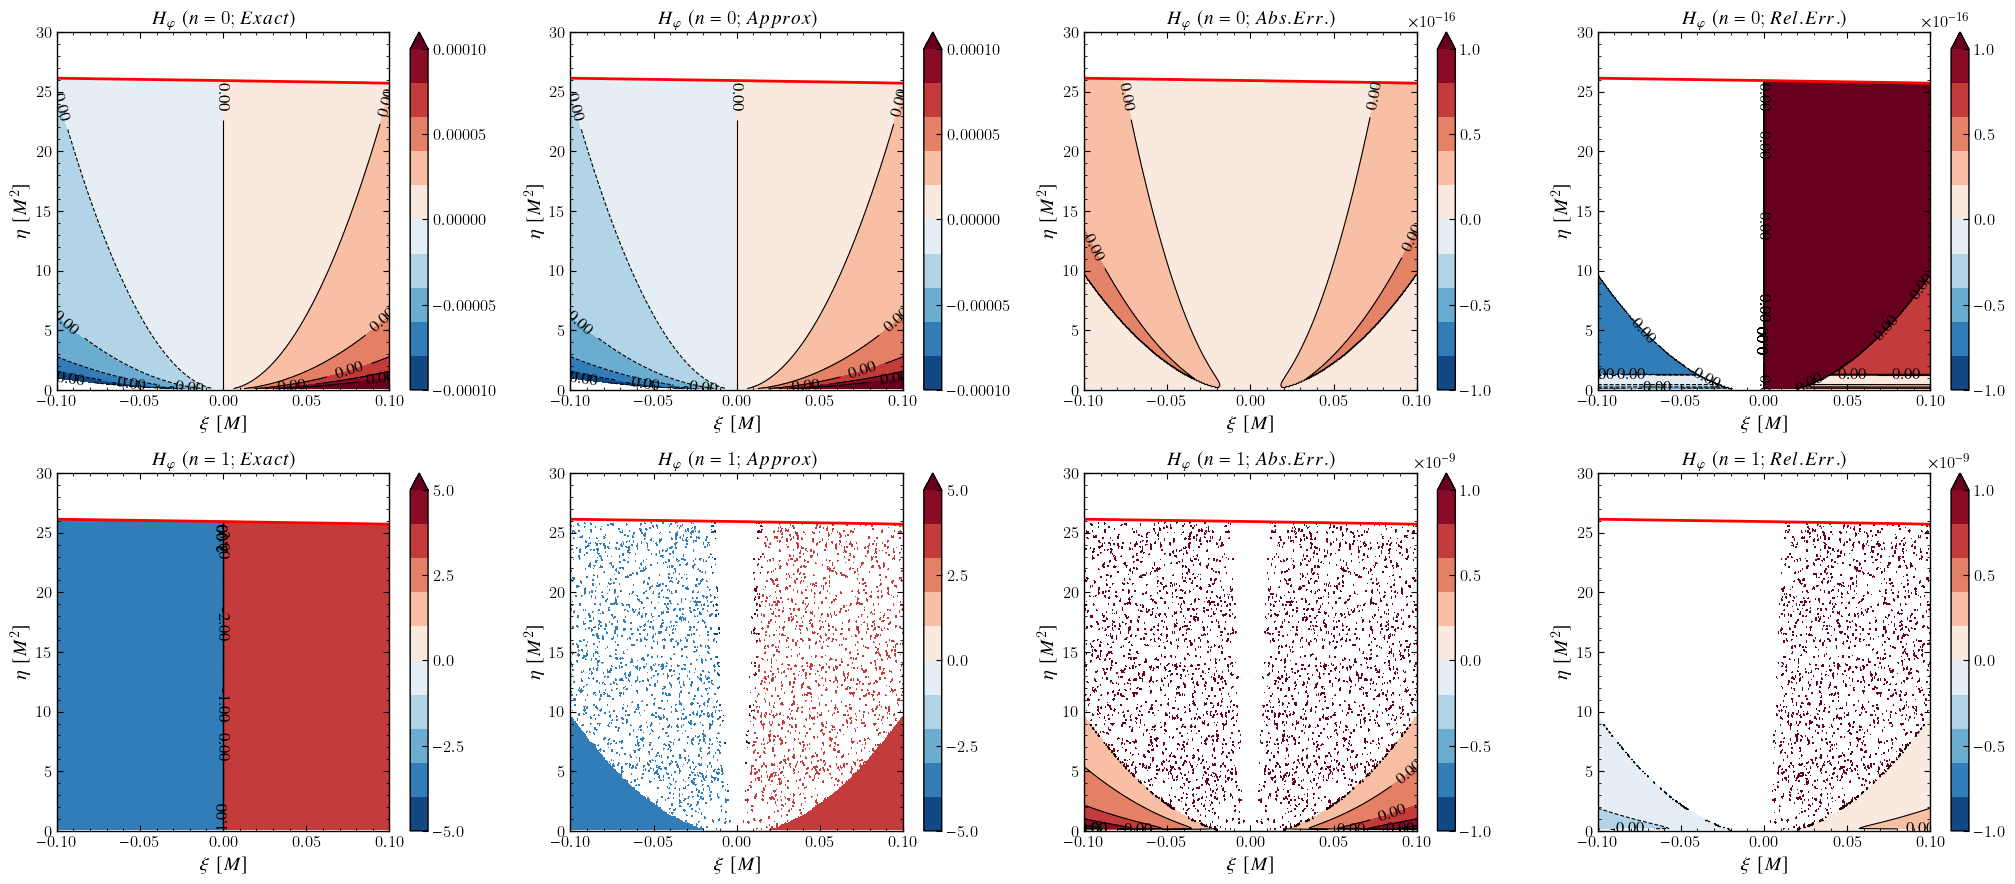

In [40]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

###########################################################################################
# Grid
eta_List = range(0.0, 30.0; length=300)
xi_List  = range(-0.1, 0.1; length=500)

neta = length(eta_List)
nxi  = length(xi_List)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List = fill(NaN, neta)
xi_Max_List = fill(NaN, neta)

@inbounds for (i, eta) in enumerate(eta_List)
    xi_Min_List[i] = xi_Min_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
    xi_Max_List[i] = xi_Max_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid
H_phi_List_n0    = fill(NaN, neta, nxi)
H_phi_List_n0_v1 = fill(NaN, neta, nxi)
H_phi_List_n0_AE = fill(NaN, neta, nxi)
H_phi_List_n0_RE = fill(NaN, neta, nxi)

H_phi_List_n1    = fill(NaN, neta, nxi)
H_phi_List_n1_v1 = fill(NaN, neta, nxi)
H_phi_List_n1_AE = fill(NaN, neta, nxi)
H_phi_List_n1_RE = fill(NaN, neta, nxi)

@inbounds for (i, eta) in enumerate(eta_List)
    for (j, xi) in enumerate(xi_List)
        NG = (eta, xi)
        if in_region_checker(inc_Val_1, metric_params_Val, NG, shadow_cache_Val)
            H_n0_exact  = H_phi_full_reg(inc_Val_1, metric_params_Val, NG, 0)
            H_n0_approx = H_phi_full_v1( inc_Val_1, metric_params_Val, NG, 0)
            H_n1_exact  = H_phi_full_reg(inc_Val_1, metric_params_Val, NG, 1)
            H_n1_approx = H_phi_full_v1( inc_Val_1, metric_params_Val, NG, 1)
            
            H_phi_List_n0[i, j]    = H_n0_exact
            H_phi_List_n0_v1[i, j] = H_n0_approx
            H_phi_List_n0_AE[i, j] = abs(H_n0_exact - H_n0_approx)
            H_phi_List_n0_RE[i, j] = abs(H_n0_exact - H_n0_approx)/H_n0_exact
            
            H_phi_List_n1[i, j]    = H_n1_exact
            H_phi_List_n1_v1[i, j] = H_n1_approx
            H_phi_List_n1_AE[i, j] = abs(H_n1_exact - H_n1_approx)
            H_phi_List_n1_RE[i, j] = abs(H_n1_exact - H_n1_approx)/H_n1_exact
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour
xi_mat  = repeat(collect(xi_List)', neta, 1)   # neta × nxi
eta_mat = repeat(collect(eta_List), 1, nxi)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

function plot_phys_contour(fig, ax, xi_mat, eta_mat, eta_List, data, title, xi_Min_List, xi_Max_List, shadow_cache_Val; vmin, vmax, nlevels=11, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-0.1, +0.1])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat, eta_mat, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat, eta_mat, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List, eta_List, "k--", lw=1.5)
    ax.plot(xi_Max_List, eta_List, "k--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 2, 4

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "H_phi_n0_exact"  => fig.add_subplot(gs[1, 1]),
    "H_phi_n0_approx" => fig.add_subplot(gs[1, 2]),
    "H_phi_n0_AE"     => fig.add_subplot(gs[1, 3]),
    "H_phi_n0_RE"     => fig.add_subplot(gs[1, 4]),
    "H_phi_n1_exact"  => fig.add_subplot(gs[2, 1]),
    "H_phi_n1_approx" => fig.add_subplot(gs[2, 2]),
    "H_phi_n1_AE"     => fig.add_subplot(gs[2, 3]),
    "H_phi_n1_RE"     => fig.add_subplot(gs[2, 4])
)

plot_phys_contour(fig, axes["H_phi_n0_exact"],  xi_mat, eta_mat, eta_List, H_phi_List_n0,    L"$H_\varphi\ (n=0; Exact)$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-4, vmax=1e-4)

plot_phys_contour(fig, axes["H_phi_n0_approx"], xi_mat, eta_mat, eta_List, H_phi_List_n0_v1, L"$H_\varphi\ (n=0; Approx)$",      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-4, vmax=1e-4)

plot_phys_contour(fig, axes["H_phi_n0_AE"],     xi_mat, eta_mat, eta_List, H_phi_List_n0_AE, L"$H_\varphi\ (n=0; Abs. Err.)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-16, vmax=1e-16)

plot_phys_contour(fig, axes["H_phi_n0_RE"],     xi_mat, eta_mat, eta_List, H_phi_List_n0_RE, L"$H_\varphi\ (n=0; Rel. Err.)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-16, vmax=1e-16)

plot_phys_contour(fig, axes["H_phi_n1_exact"],  xi_mat, eta_mat, eta_List, H_phi_List_n1,    L"$H_\varphi\ (n=1; Exact)$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-5, vmax=5)

plot_phys_contour(fig, axes["H_phi_n1_approx"], xi_mat, eta_mat, eta_List, H_phi_List_n1_v1, L"$H_\varphi\ (n=1; Approx)$",      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-5, vmax=5)

plot_phys_contour(fig, axes["H_phi_n1_AE"],     xi_mat, eta_mat, eta_List, H_phi_List_n1_AE, L"$H_\varphi\ (n=1; Abs. Err.)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-9, vmax=1e-9)

plot_phys_contour(fig, axes["H_phi_n1_RE"],     xi_mat, eta_mat, eta_List, H_phi_List_n1_RE, L"$H_\varphi\ (n=1; Rel. Err.)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-9, vmax=1e-9)

fig.tight_layout()
savefig("./Figures/Tests/Fig18a-H_phi-Integrals-IS-Eq.png", dpi=150)

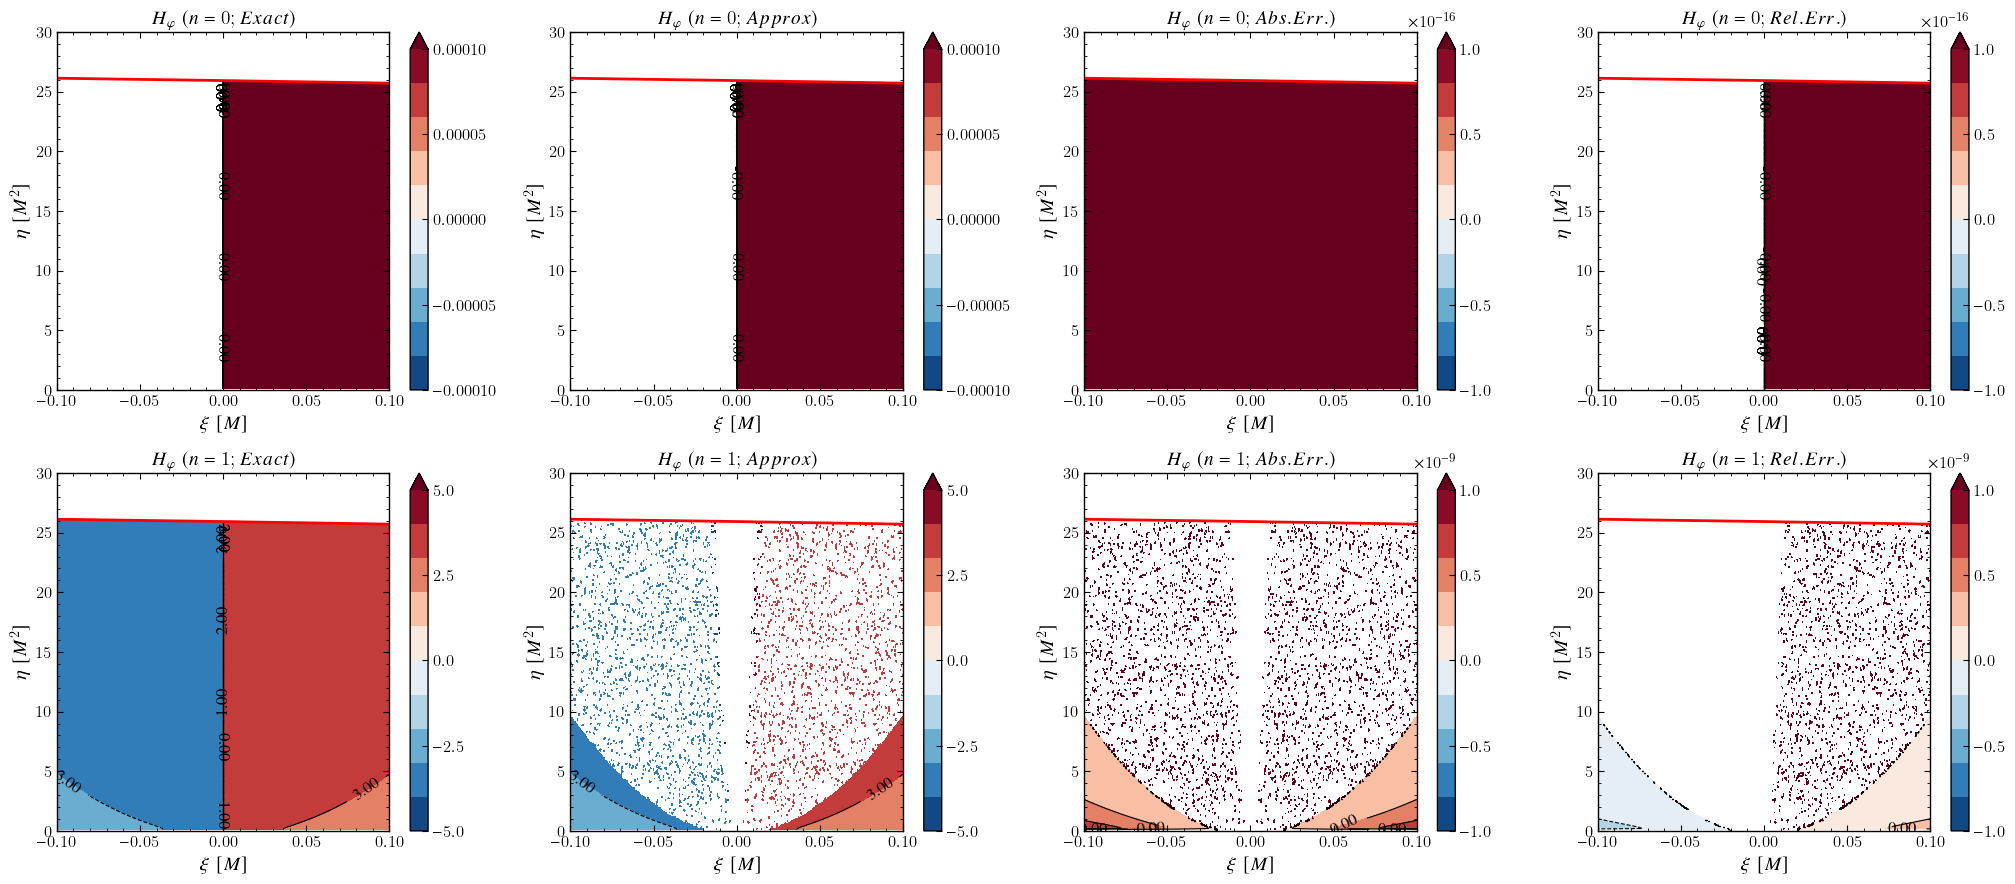

In [41]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

###########################################################################################
# Grid
eta_List = range(0.0, 30.0; length=300)
xi_List  = range(-0.1, 0.1; length=500)

neta = length(eta_List)
nxi  = length(xi_List)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List = fill(NaN, neta)
xi_Max_List = fill(NaN, neta)

@inbounds for (i, eta) in enumerate(eta_List)
    xi_Min_List[i] = xi_Min_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
    xi_Max_List[i] = xi_Max_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid
H_phi_List_n0    = fill(NaN, neta, nxi)
H_phi_List_n0_v1 = fill(NaN, neta, nxi)
H_phi_List_n0_AE = fill(NaN, neta, nxi)
H_phi_List_n0_RE = fill(NaN, neta, nxi)

H_phi_List_n1    = fill(NaN, neta, nxi)
H_phi_List_n1_v1 = fill(NaN, neta, nxi)
H_phi_List_n1_AE = fill(NaN, neta, nxi)
H_phi_List_n1_RE = fill(NaN, neta, nxi)

@inbounds for (i, eta) in enumerate(eta_List)
    for (j, xi) in enumerate(xi_List)
        NG = (eta, xi)
        if in_region_checker(inc_Val_1, metric_params_Val, NG, shadow_cache_Val)
            H_n0_exact  = H_phi_full_reg(inc_Val_2, metric_params_Val, NG, 0)
            H_n0_approx = H_phi_full_v1( inc_Val_2, metric_params_Val, NG, 0)
            H_n1_exact  = H_phi_full_reg(inc_Val_2, metric_params_Val, NG, 1)
            H_n1_approx = H_phi_full_v1( inc_Val_2, metric_params_Val, NG, 1)
            
            H_phi_List_n0[i, j]    = H_n0_exact
            H_phi_List_n0_v1[i, j] = H_n0_approx
            H_phi_List_n0_AE[i, j] = abs(H_n0_exact - H_n0_approx)
            H_phi_List_n0_RE[i, j] = abs(H_n0_exact - H_n0_approx)/H_n0_exact
            
            H_phi_List_n1[i, j]    = H_n1_exact
            H_phi_List_n1_v1[i, j] = H_n1_approx
            H_phi_List_n1_AE[i, j] = abs(H_n1_exact - H_n1_approx)
            H_phi_List_n1_RE[i, j] = abs(H_n1_exact - H_n1_approx)/H_n1_exact
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour
xi_mat  = repeat(collect(xi_List)', neta, 1)   # neta × nxi
eta_mat = repeat(collect(eta_List), 1, nxi)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

function plot_phys_contour(fig, ax, xi_mat, eta_mat, eta_List, data, title, xi_Min_List, xi_Max_List, shadow_cache_Val; vmin, vmax, nlevels=11, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-0.1, +0.1])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat, eta_mat, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat, eta_mat, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List, eta_List, "k--", lw=1.5)
    ax.plot(xi_Max_List, eta_List, "k--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 2, 4

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "H_phi_n0_exact"  => fig.add_subplot(gs[1, 1]),
    "H_phi_n0_approx" => fig.add_subplot(gs[1, 2]),
    "H_phi_n0_AE"     => fig.add_subplot(gs[1, 3]),
    "H_phi_n0_RE"     => fig.add_subplot(gs[1, 4]),
    "H_phi_n1_exact"  => fig.add_subplot(gs[2, 1]),
    "H_phi_n1_approx" => fig.add_subplot(gs[2, 2]),
    "H_phi_n1_AE"     => fig.add_subplot(gs[2, 3]),
    "H_phi_n1_RE"     => fig.add_subplot(gs[2, 4])
)

plot_phys_contour(fig, axes["H_phi_n0_exact"],  xi_mat, eta_mat, eta_List, H_phi_List_n0,    L"$H_\varphi\ (n=0; Exact)$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-4, vmax=1e-4)

plot_phys_contour(fig, axes["H_phi_n0_approx"], xi_mat, eta_mat, eta_List, H_phi_List_n0_v1, L"$H_\varphi\ (n=0; Approx)$",      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-4, vmax=1e-4)

plot_phys_contour(fig, axes["H_phi_n0_AE"],     xi_mat, eta_mat, eta_List, H_phi_List_n0_AE, L"$H_\varphi\ (n=0; Abs. Err.)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-16, vmax=1e-16)

plot_phys_contour(fig, axes["H_phi_n0_RE"],     xi_mat, eta_mat, eta_List, H_phi_List_n0_RE, L"$H_\varphi\ (n=0; Rel. Err.)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-16, vmax=1e-16)

plot_phys_contour(fig, axes["H_phi_n1_exact"],  xi_mat, eta_mat, eta_List, H_phi_List_n1,    L"$H_\varphi\ (n=1; Exact)$",       xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-5, vmax=5)

plot_phys_contour(fig, axes["H_phi_n1_approx"], xi_mat, eta_mat, eta_List, H_phi_List_n1_v1, L"$H_\varphi\ (n=1; Approx)$",      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-5, vmax=5)

plot_phys_contour(fig, axes["H_phi_n1_AE"],     xi_mat, eta_mat, eta_List, H_phi_List_n1_AE, L"$H_\varphi\ (n=1; Abs. Err.)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-9, vmax=1e-9)

plot_phys_contour(fig, axes["H_phi_n1_RE"],     xi_mat, eta_mat, eta_List, H_phi_List_n1_RE, L"$H_\varphi\ (n=1; Rel. Err.)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1e-9, vmax=1e-9)

fig.tight_layout()
savefig("./Figures/Tests/Fig18b-H_phi-Integrals-IS-Pole.png", dpi=150)

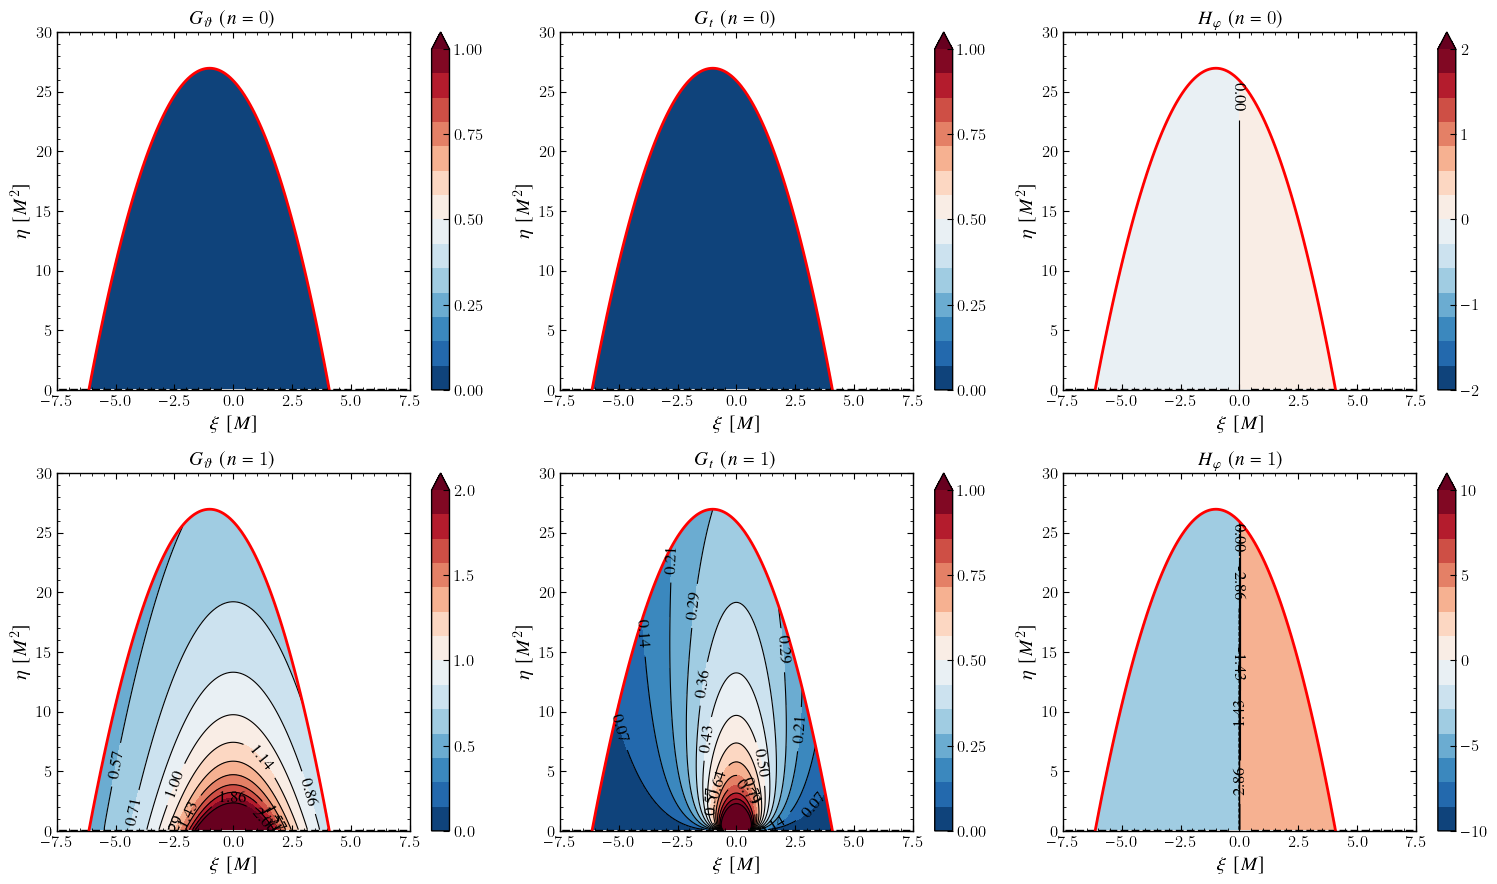

In [42]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

###########################################################################################
# Grid
eta_List = range(0.0, 30.0; length=300)
xi_List  = range(-7.5, 7.5; length=400)

neta = length(eta_List)
nxi  = length(xi_List)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List = fill(NaN, neta)
xi_Max_List = fill(NaN, neta)

@inbounds for (i, eta) in enumerate(eta_List)
    xi_Min_List[i] = xi_Min_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
    xi_Max_List[i] = xi_Max_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid
G_th_List_n0  = fill(NaN, neta, nxi)
G_t_List_n0   = fill(NaN, neta, nxi)
H_phi_List_n0 = fill(NaN, neta, nxi)
# G_phi_List_n0 = fill(NaN, neta, nxi)

G_th_List_n1  = fill(NaN, neta, nxi)
G_t_List_n1   = fill(NaN, neta, nxi)
H_phi_List_n1 = fill(NaN, neta, nxi)
# G_phi_List_n1 = fill(NaN, neta, nxi)

@inbounds for (i, eta) in enumerate(eta_List)
    for (j, xi) in enumerate(xi_List)
        NG = (eta, xi)
        if in_region_checker(inc_Val_1, metric_params_Val, NG, shadow_cache_Val)
            G_th_List_n0[i, j]  = G_th_full(     inc_Val_1, metric_params_Val, NG, 0)
            G_t_List_n0[i, j]   = G_t_full(      inc_Val_1, metric_params_Val, NG, 0)
            H_phi_List_n0[i, j] = H_phi_full_reg(inc_Val_1, metric_params_Val, NG, 0)
            # G_phi_List_n0[i, j] = G_phi_full(inc_Val_1, metric_params_Val, NG, 0)
            
            G_th_List_n1[i, j]  = G_th_full(     inc_Val_1, metric_params_Val, NG, 1)
            G_t_List_n1[i, j]   = G_t_full(      inc_Val_1, metric_params_Val, NG, 1)
            H_phi_List_n1[i, j] = H_phi_full_reg(inc_Val_1, metric_params_Val, NG, 1)
            # G_phi_List_n1[i, j] = G_phi_full(  inc_Val_1, metric_params_Val, NG, 1)
            
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour
xi_mat  = repeat(collect(xi_List)', neta, 1)   # neta × nxi
eta_mat = repeat(collect(eta_List), 1, nxi)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

function plot_phys_contour(fig, ax, xi_mat, eta_mat, eta_List, data, title, xi_Min_List, xi_Max_List, shadow_cache_Val; vmin, vmax, nlevels=15, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-7.5, +7.5])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat, eta_mat, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat, eta_mat, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List, eta_List, "k--", lw=1.5)
    ax.plot(xi_Max_List, eta_List, "k--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 2, 3

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "G_th_n0"  => fig.add_subplot(gs[1, 1]),
    "G_t_n0"   => fig.add_subplot(gs[1, 2]),
    "H_phi_n0" => fig.add_subplot(gs[1, 3]),
    # "G_phi_n0" => fig.add_subplot(gs[1, 4]),    
    "G_th_n1"  => fig.add_subplot(gs[2, 1]),
    "G_t_n1"   => fig.add_subplot(gs[2, 2]),
    "H_phi_n1" => fig.add_subplot(gs[2, 3])
    # "G_phi_n1" => fig.add_subplot(gs[2, 2])
)

plot_phys_contour(fig, axes["G_th_n0"],  xi_mat, eta_mat, eta_List, G_th_List_n0,   L"$G_\vartheta\ (n=0)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=1)

plot_phys_contour(fig, axes["G_t_n0"],   xi_mat, eta_mat, eta_List, G_t_List_n0,    L"$G_t\ (n=0)$",         xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=1)

plot_phys_contour(fig, axes["H_phi_n0"], xi_mat, eta_mat, eta_List, H_phi_List_n0,  L"$H_\varphi\ (n=0)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-2, vmax=2)

# plot_phys_contour(fig, axes["G_phi_n0"], xi_mat, eta_mat, eta_List, G_phi_List_n0,  L"$G_\varphi\ (n=0)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=2)

plot_phys_contour(fig, axes["G_th_n1"],  xi_mat, eta_mat, eta_List, G_th_List_n1,   L"$G_\vartheta\ (n=1)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=2)

plot_phys_contour(fig, axes["G_t_n1"],   xi_mat, eta_mat, eta_List, G_t_List_n1,    L"$G_t\ (n=1)$",         xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=1)

plot_phys_contour(fig, axes["H_phi_n1"], xi_mat, eta_mat, eta_List, H_phi_List_n1,  L"$H_\varphi\ (n=1)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-10, vmax=10)

# plot_phys_contour(fig, axes["G_phi_n1"], xi_mat, eta_mat, eta_List, G_phi_List_n1,  L"$G_\varphi\ (n=1)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=20)

fig.tight_layout()
savefig("./Figures/Tests/Fig18c-KH-NG-Polar-Integrals-IS-Eq.png", dpi=150)

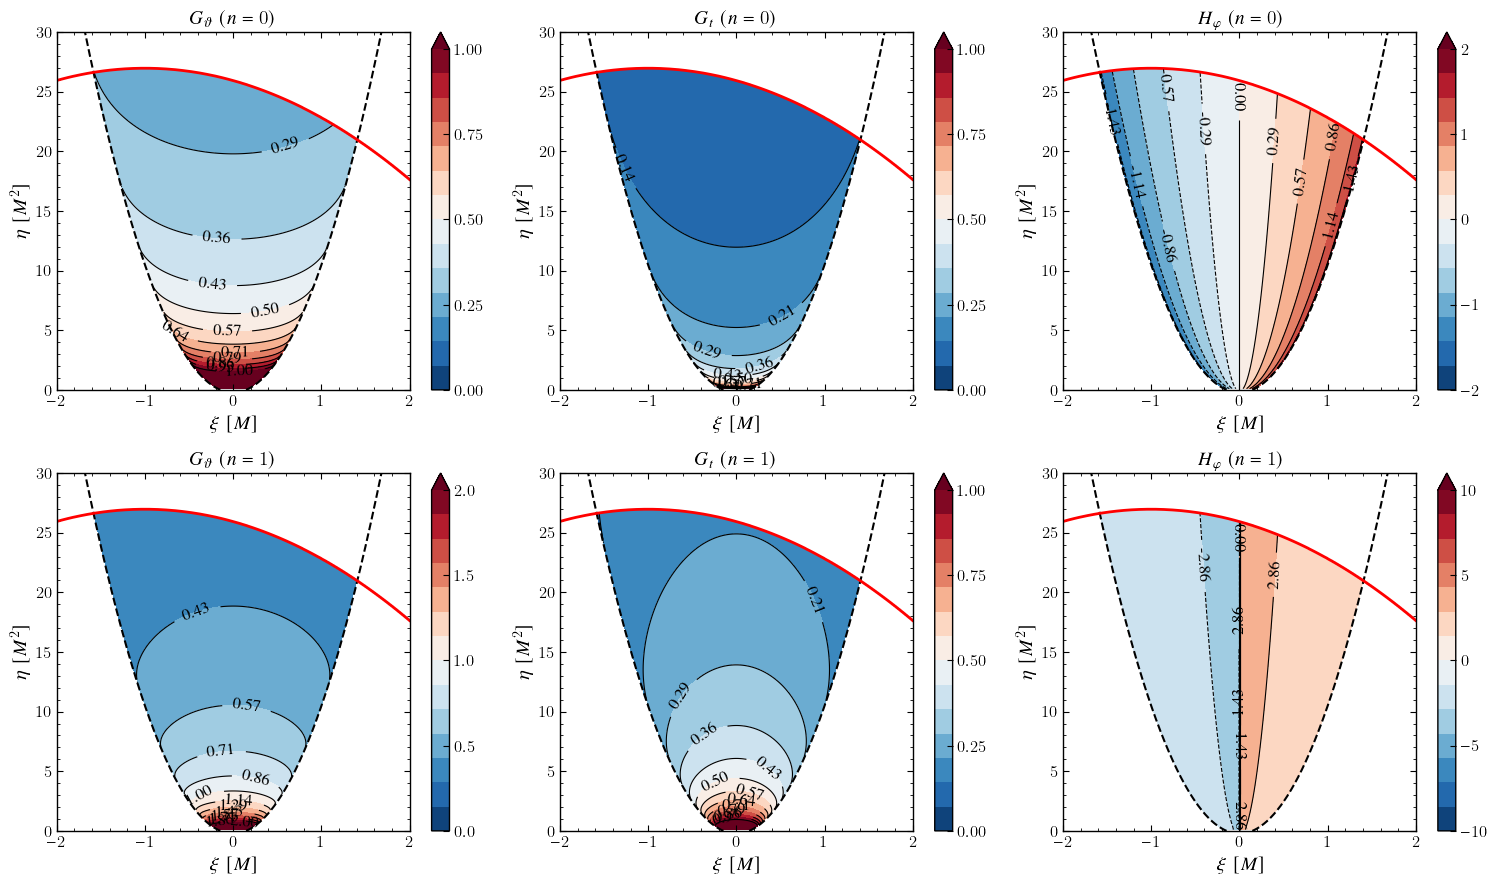

In [43]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

###########################################################################################
# Grid
eta_List = range(0.0, 30.0; length=300)
xi_List  = range(-2, 2; length=400)

neta = length(eta_List)
nxi  = length(xi_List)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List = fill(NaN, neta)
xi_Max_List = fill(NaN, neta)

@inbounds for (i, eta) in enumerate(eta_List)
    xi_Min_List[i] = xi_Min_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
    xi_Max_List[i] = xi_Max_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid
G_th_List_n0  = fill(NaN, neta, nxi)
G_t_List_n0   = fill(NaN, neta, nxi)
H_phi_List_n0 = fill(NaN, neta, nxi)
# G_phi_List_n0 = fill(NaN, neta, nxi)

G_th_List_n1  = fill(NaN, neta, nxi)
G_t_List_n1   = fill(NaN, neta, nxi)
H_phi_List_n1 = fill(NaN, neta, nxi)
# G_phi_List_n1 = fill(NaN, neta, nxi)

@inbounds for (i, eta) in enumerate(eta_List)
    for (j, xi) in enumerate(xi_List)
        NG = (eta, xi)
        if in_region_checker(inc_Val_2, metric_params_Val, NG, shadow_cache_Val)
            G_th_List_n0[i, j]  = G_th_full(     inc_Val_2, metric_params_Val, NG, 0)
            G_t_List_n0[i, j]   = G_t_full(      inc_Val_2, metric_params_Val, NG, 0)
            H_phi_List_n0[i, j] = H_phi_full_reg(inc_Val_2, metric_params_Val, NG, 0)
            # G_phi_List_n0[i, j] = G_phi_full(inc_Val_2, metric_params_Val, NG, 0)
            
            G_th_List_n1[i, j]  = G_th_full(     inc_Val_2, metric_params_Val, NG, 1)
            G_t_List_n1[i, j]   = G_t_full(      inc_Val_2, metric_params_Val, NG, 1)
            H_phi_List_n1[i, j] = H_phi_full_reg(inc_Val_2, metric_params_Val, NG, 1)
            # G_phi_List_n1[i, j] = G_phi_full(  inc_Val_2, metric_params_Val, NG, 1)
            
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour
xi_mat  = repeat(collect(xi_List)', neta, 1)   # neta × nxi
eta_mat = repeat(collect(eta_List), 1, nxi)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

function plot_phys_contour(fig, ax, xi_mat, eta_mat, eta_List, data, title, xi_Min_List, xi_Max_List, shadow_cache_Val; vmin, vmax, nlevels=15, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-2, +2])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat, eta_mat, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat, eta_mat, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List, eta_List, "k--", lw=1.5)
    ax.plot(xi_Max_List, eta_List, "k--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 2, 3

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "G_th_n0"  => fig.add_subplot(gs[1, 1]),
    "G_t_n0"   => fig.add_subplot(gs[1, 2]),
    "H_phi_n0" => fig.add_subplot(gs[1, 3]),
    # "G_phi_n0" => fig.add_subplot(gs[1, 4]),    
    "G_th_n1"  => fig.add_subplot(gs[2, 1]),
    "G_t_n1"   => fig.add_subplot(gs[2, 2]),
    "H_phi_n1" => fig.add_subplot(gs[2, 3])
    # "G_phi_n1" => fig.add_subplot(gs[2, 2])
)

plot_phys_contour(fig, axes["G_th_n0"],  xi_mat, eta_mat, eta_List, G_th_List_n0,   L"$G_\vartheta\ (n=0)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=1)

plot_phys_contour(fig, axes["G_t_n0"],   xi_mat, eta_mat, eta_List, G_t_List_n0,    L"$G_t\ (n=0)$",         xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=1)

plot_phys_contour(fig, axes["H_phi_n0"], xi_mat, eta_mat, eta_List, H_phi_List_n0,  L"$H_\varphi\ (n=0)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-2, vmax=2)

# plot_phys_contour(fig, axes["G_phi_n0"], xi_mat, eta_mat, eta_List, G_phi_List_n0,  L"$G_\varphi\ (n=0)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=2)

plot_phys_contour(fig, axes["G_th_n1"],  xi_mat, eta_mat, eta_List, G_th_List_n1,   L"$G_\vartheta\ (n=1)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=2)

plot_phys_contour(fig, axes["G_t_n1"],   xi_mat, eta_mat, eta_List, G_t_List_n1,    L"$G_t\ (n=1)$",         xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=1)

plot_phys_contour(fig, axes["H_phi_n1"], xi_mat, eta_mat, eta_List, H_phi_List_n1,  L"$H_\varphi\ (n=1)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-10, vmax=10)

# plot_phys_contour(fig, axes["G_phi_n1"], xi_mat, eta_mat, eta_List, G_phi_List_n1,  L"$G_\varphi\ (n=1)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=20)

fig.tight_layout()
savefig("./Figures/Tests/Fig18d-KH-NG-Polar-Integrals-IS-Pole.png", dpi=150)

In [40]:
###########################################################################################
# NG Elapsed Quantities
###########################################################################################

# Delta_phi = I_phi + xi * G_phi
function Delta_phi(inc, metric_params, NG_params, n_ptp)
    xi   = NG_params[2]
    Iphi = I_phi(metric_params, NG_params; check_tp=false)
    # Gphi = G_phi_full(inc, metric_params, NG_params, n_ptp)
    # return Iphi + xi*Gphi
    Hphi = H_phi_full_reg(inc, metric_params, NG_params, n_ptp)
    return Iphi + Hphi
end

# Delta_t = I_t + a^2 * G_t
function Delta_t(inc, metric_params, NG_params, n_ptp)
    a  = metric_params[1]
    It = I_t(metric_params, NG_params; check_tp=false)
    Gt = G_t_full(inc, metric_params, NG_params, n_ptp)
    return It + (a*a) * Gt
end

###########################################################################################
# Inner Shadow Equations
###########################################################################################

# Equation 1: I_r - G_th = 0
eq1(inc, metric_params, NG_params, n_ptp) = I_r(metric_params, NG_params; check_tp=false) - G_th_full(inc, metric_params, NG_params, n_ptp)

# Wrap angle into (-pi, pi]
@inline wrap_to_pi(x) = mod(x + oftype(x, π), oftype(x, 2π)) - oftype(x, π)

# Equation 2: wrap_to_pi(Delta_phi - (phi_obs - phi_em)) = 0
function eq2(inc, metric_params, NG_params, n_ptp, phi_em; phi_obs=zero(phi_em))
    Delta_phis = Delta_phi(inc, metric_params, NG_params, n_ptp) - (phi_obs - phi_em)
    return wrap_to_pi(Delta_phis)
    # return Delta_phis
end

eq2 (generic function with 1 method)

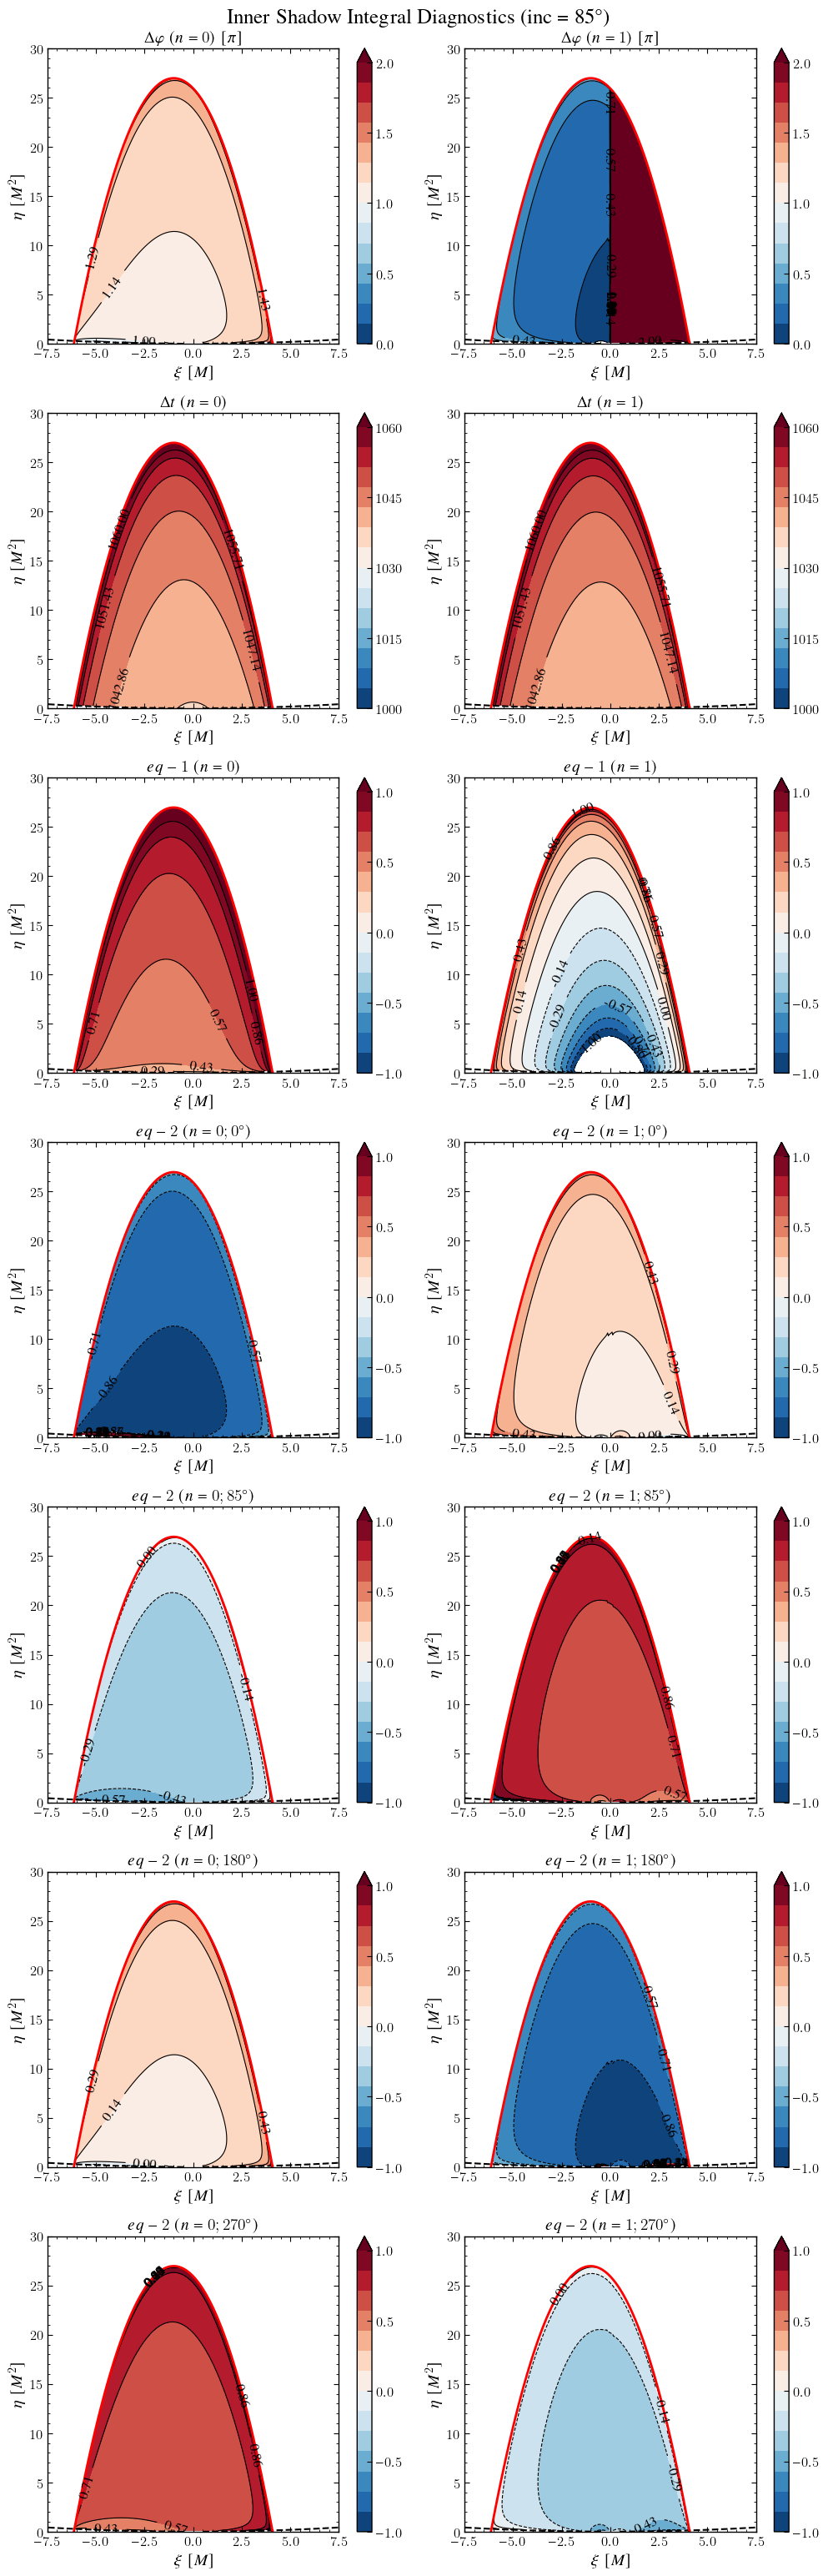

In [45]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = 85.0*pi/180.0
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

###########################################################################################
# Grid
eta_List_85 = range(0.0, 30.0; length=300)
xi_List_85  = range(-7.5, 7.5; length=400)

neta = length(eta_List_85)
nxi  = length(xi_List_85)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List = fill(NaN, neta)
xi_Max_List = fill(NaN, neta)

@inbounds for (i, eta) in enumerate(eta_List_85)
    xi_Min_List[i] = xi_Min_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
    xi_Max_List[i] = xi_Max_OrdNG(inc_Val_1, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid
Delta_phi_n0_List_85 = fill(NaN, neta, nxi)
Delta_phi_n1_List_85 = fill(NaN, neta, nxi)

Delta_t_n0_List_85   = fill(NaN, neta, nxi)
Delta_t_n1_List_85   = fill(NaN, neta, nxi)

eq1_n0_List_85       = fill(NaN, neta, nxi)
eq1_n1_List_85       = fill(NaN, neta, nxi)

eq2_n0_List_85_0     = fill(NaN, neta, nxi)
eq2_n1_List_85_0     = fill(NaN, neta, nxi)

eq2_n0_List_85_85    = fill(NaN, neta, nxi)
eq2_n1_List_85_85    = fill(NaN, neta, nxi)

eq2_n0_List_85_180   = fill(NaN, neta, nxi)
eq2_n1_List_85_180   = fill(NaN, neta, nxi)

eq2_n0_List_85_270   = fill(NaN, neta, nxi)
eq2_n1_List_85_270   = fill(NaN, neta, nxi)

@inbounds for (i, eta) in enumerate(eta_List_85)
    # xi_eff = xi == 0.0 ? 1e-14 : xi
    for (j, xi) in enumerate(xi_List_85)
        if abs(xi) < 1e-12
            println("eta=", eta, "  th_tp=", th_Min(metric_params_Val, (eta, xi)))
        end
        NG = (eta, xi)
        if in_region_checker(inc_Val_1, metric_params_Val, NG, shadow_cache_Val)
            Delta_phi_n0_List_85[i, j] = Delta_phi(inc_Val_1, metric_params_Val, NG, 0)/pi   
            Delta_phi_n1_List_85[i, j] = Delta_phi(inc_Val_1, metric_params_Val, NG, 1)/pi
            
            Delta_t_n0_List_85[i, j]   = Delta_t(  inc_Val_1, metric_params_Val, NG, 0)    
            Delta_t_n1_List_85[i, j]   = Delta_t(  inc_Val_1, metric_params_Val, NG, 1)
            
            eq1_n0_List_85[i, j]       = eq1(      inc_Val_1, metric_params_Val, NG, 0)    
            eq1_n1_List_85[i, j]       = eq1(      inc_Val_1, metric_params_Val, NG, 1)
            
            eq2_n0_List_85_0[i, j]     = eq2(      inc_Val_1, metric_params_Val, NG, 0, EPS_HEUR)/pi
            eq2_n1_List_85_0[i, j]     = eq2(      inc_Val_1, metric_params_Val, NG, 1, EPS_HEUR)/pi
            
            eq2_n0_List_85_85[i, j]    = eq2(      inc_Val_1, metric_params_Val, NG, 0, pi/2.0)/pi
            eq2_n1_List_85_85[i, j]    = eq2(      inc_Val_1, metric_params_Val, NG, 1, pi/2.0)/pi
            
            eq2_n0_List_85_180[i, j]   = eq2(      inc_Val_1, metric_params_Val, NG, 0, pi)/pi
            eq2_n1_List_85_180[i, j]   = eq2(      inc_Val_1, metric_params_Val, NG, 1, pi)/pi
            
            eq2_n0_List_85_270[i, j]   = eq2(      inc_Val_1, metric_params_Val, NG, 0, 3.0*pi/2.0)/pi
            eq2_n1_List_85_270[i, j]   = eq2(      inc_Val_1, metric_params_Val, NG, 1, 3.0*pi/2.0)/pi
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour
xi_mat_85  = repeat(collect(xi_List_85)', neta, 1)   # neta × nxi
eta_mat_85 = repeat(collect(eta_List_85), 1, nxi)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

function plot_phys_contour(fig, ax, xi_mat_85, eta_mat_85, eta_List_85, data, title, xi_Min_List, xi_Max_List, shadow_cache_Val; vmin, vmax, nlevels=15, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-7.5, +7.5])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat_85, eta_mat_85, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat_85, eta_mat_85, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List, eta_List_85, "k--", lw=1.5)
    ax.plot(xi_Max_List, eta_List_85, "k--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 7, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "Delta_phi_n0_85"  => fig.add_subplot(gs[1, 1]),
    "Delta_phi_n1_85"  => fig.add_subplot(gs[1, 2]),
    
    "Delta_t_n0_85"    => fig.add_subplot(gs[2, 1]),
    "Delta_t_n1_85"    => fig.add_subplot(gs[2, 2]),
    
    "eq1_n0_85"        => fig.add_subplot(gs[3, 1]),
    "eq1_n1_85"        => fig.add_subplot(gs[3, 2]),
    
    "eq2_n0_85_0"      => fig.add_subplot(gs[4, 1]),
    "eq2_n1_85_0"      => fig.add_subplot(gs[4, 2]),
    
    "eq2_n0_85_85"     => fig.add_subplot(gs[5, 1]),
    "eq2_n1_85_85"     => fig.add_subplot(gs[5, 2]),
    
    "eq2_n0_85_180"    => fig.add_subplot(gs[6, 1]),
    "eq2_n1_85_180"    => fig.add_subplot(gs[6, 2]),
    
    "eq2_n0_85_270"    => fig.add_subplot(gs[7, 1]),
    "eq2_n1_85_270"    => fig.add_subplot(gs[7, 2])
)

plot_phys_contour(fig, axes["Delta_phi_n0_85"], xi_mat_85, eta_mat_85, eta_List_85, Delta_phi_n0_List_85, L"$\Delta\varphi\ (n=0)\ [\pi]$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=2)
plot_phys_contour(fig, axes["Delta_phi_n1_85"], xi_mat_85, eta_mat_85, eta_List_85, Delta_phi_n1_List_85, L"$\Delta\varphi\ (n=1)\ [\pi]$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=2)

plot_phys_contour(fig, axes["Delta_t_n0_85"],   xi_mat_85, eta_mat_85, eta_List_85, Delta_t_n0_List_85,   L"$\Delta t\ (n=0)$",      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=1000, vmax=1060)
plot_phys_contour(fig, axes["Delta_t_n1_85"],   xi_mat_85, eta_mat_85, eta_List_85, Delta_t_n1_List_85,   L"$\Delta t\ (n=1)$",      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=1000, vmax=1060)

plot_phys_contour(fig, axes["eq1_n0_85"],       xi_mat_85, eta_mat_85, eta_List_85, eq1_n0_List_85,       L"$eq-1\ (n=0)$",          xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq1_n1_85"],       xi_mat_85, eta_mat_85, eta_List_85, eq1_n1_List_85,       L"$eq-1\ (n=1)$",          xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

plot_phys_contour(fig, axes["eq2_n0_85_0"],     xi_mat_85, eta_mat_85, eta_List_85, eq2_n0_List_85_0,     L"$eq-2\ (n=0; 0^\circ)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq2_n1_85_0"],     xi_mat_85, eta_mat_85, eta_List_85, eq2_n1_List_85_0,     L"$eq-2\ (n=1; 0^\circ)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

plot_phys_contour(fig, axes["eq2_n0_85_85"],    xi_mat_85, eta_mat_85, eta_List_85, eq2_n0_List_85_85,    L"$eq-2\ (n=0; 85^\circ)$",  xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq2_n1_85_85"],    xi_mat_85, eta_mat_85, eta_List_85, eq2_n1_List_85_85,    L"$eq-2\ (n=1; 85^\circ)$",  xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

plot_phys_contour(fig, axes["eq2_n0_85_180"],   xi_mat_85, eta_mat_85, eta_List_85, eq2_n0_List_85_180,   L"$eq-2\ (n=0; 180^\circ)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq2_n1_85_180"],   xi_mat_85, eta_mat_85, eta_List_85, eq2_n1_List_85_180,    L"$eq-2\ (n=1; 180^\circ)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

plot_phys_contour(fig, axes["eq2_n0_85_270"],   xi_mat_85, eta_mat_85, eta_List_85, eq2_n0_List_85_270,   L"$eq-2\ (n=0; 270^\circ)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq2_n1_85_270"],   xi_mat_85, eta_mat_85, eta_List_85, eq2_n1_List_85_270,   L"$eq-2\ (n=1; 270^\circ)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

fig.suptitle("Inner Shadow Integral Diagnostics (inc = 85°)", fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.99])

savefig("./Figures/Tests/Fig19a-KH-NG-Polar-Integrals-IS-Eq.png", dpi=150)

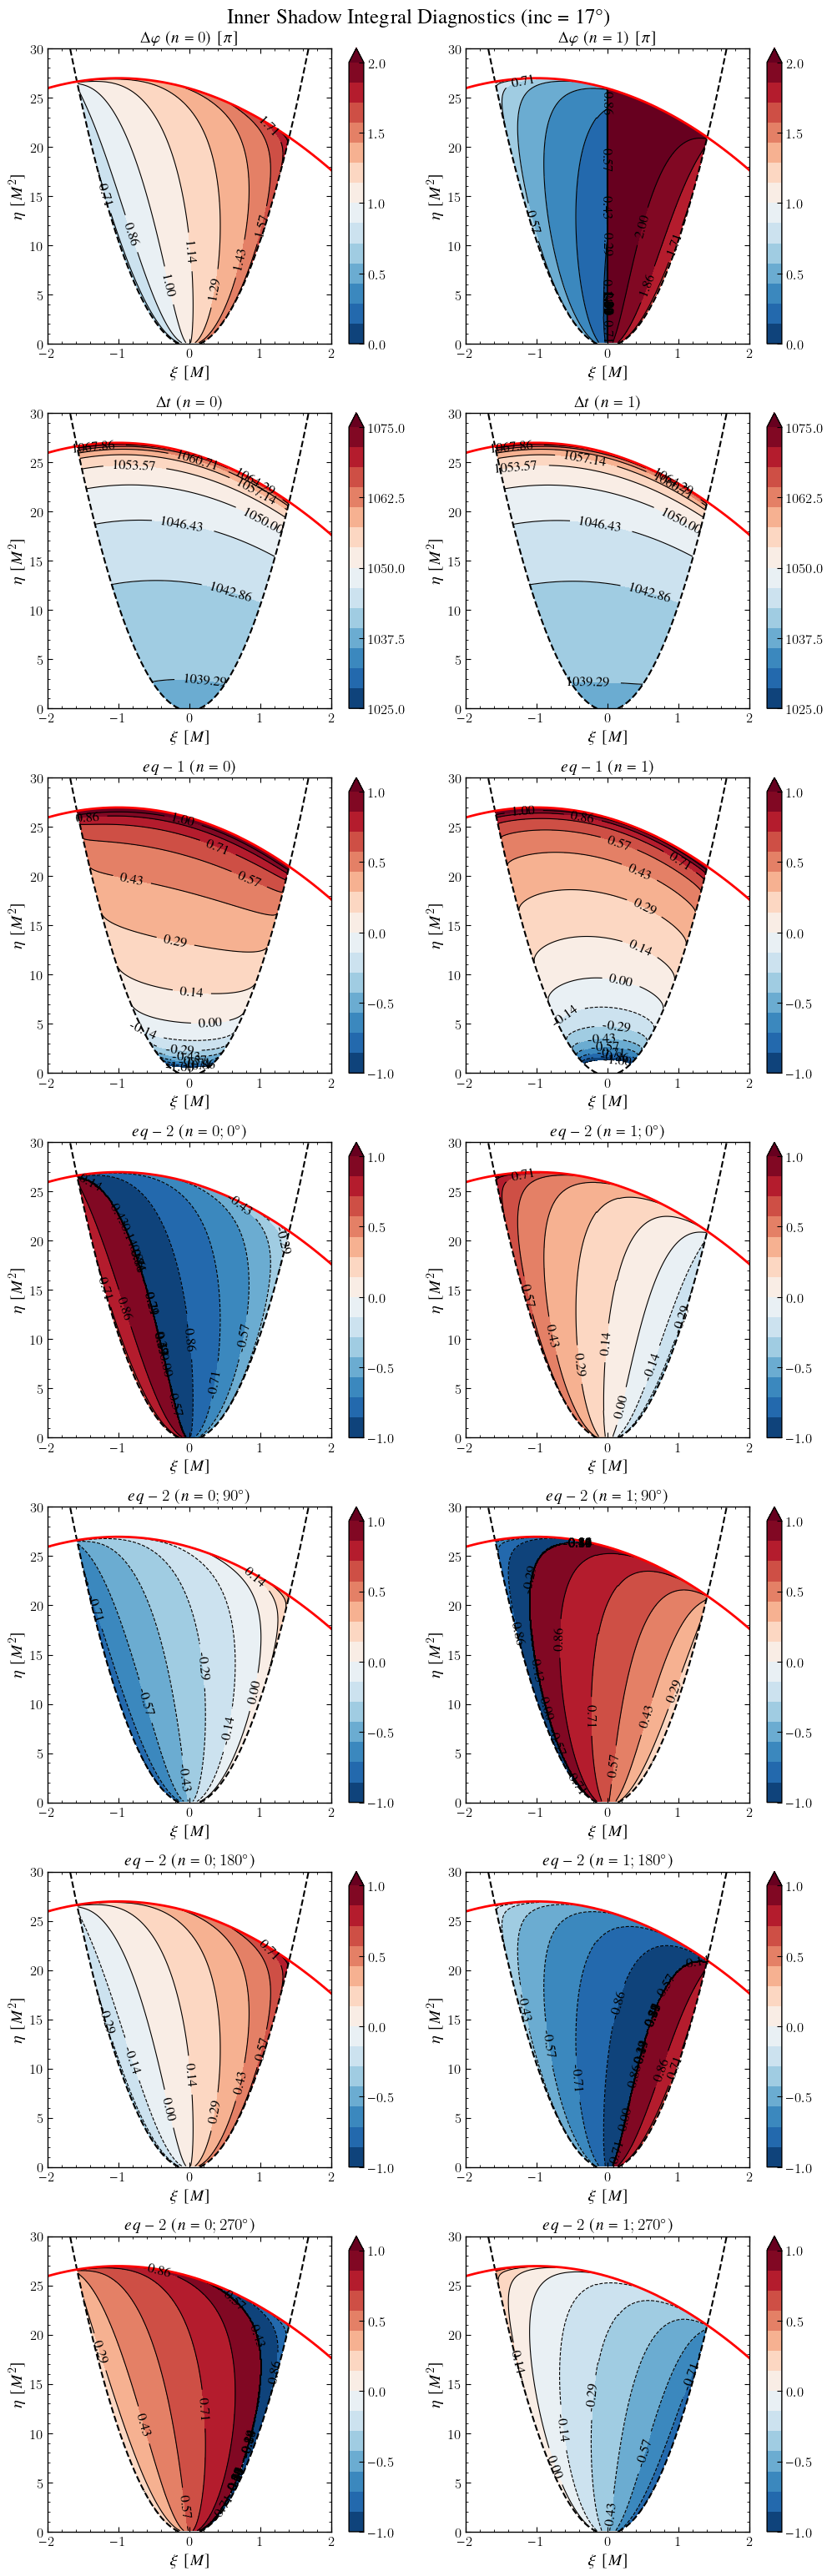

In [46]:
metric_params_Val = (0.5, 0.4)
inc_Val_1         = pi/2 - EPS_HEUR
inc_Val_2         = 17.0*pi/180.0   # (unused below, keep if needed later)

###########################################################################################
# Grid
eta_List_17 = range(0.0, 30.0; length=300)
xi_List_17  = range(-2.0, 2.0; length=400)

neta = length(eta_List_17)
nxi  = length(xi_List_17)

shadow_cache_Val = make_shadow_cache(metric_params_Val)

###########################################################################################
# Precompute xi-min/max (for plotting the ordinary NG band edges)
xi_Min_List = fill(NaN, neta)
xi_Max_List = fill(NaN, neta)

@inbounds for (i, eta) in enumerate(eta_List_17)
    xi_Min_List[i] = xi_Min_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
    xi_Max_List[i] = xi_Max_OrdNG(inc_Val_2, metric_params_Val, (eta, 0.0))
end

###########################################################################################
# Data fields on the (eta, xi) grid
Delta_phi_n0_List_17 = fill(NaN, neta, nxi)
Delta_phi_n1_List_17 = fill(NaN, neta, nxi)

Delta_t_n0_List_17   = fill(NaN, neta, nxi)
Delta_t_n1_List_17   = fill(NaN, neta, nxi)

eq1_n0_List_17       = fill(NaN, neta, nxi)
eq1_n1_List_17       = fill(NaN, neta, nxi)

eq2_n0_List_17_0     = fill(NaN, neta, nxi)
eq2_n1_List_17_0     = fill(NaN, neta, nxi)

eq2_n0_List_17_90    = fill(NaN, neta, nxi)
eq2_n1_List_17_90    = fill(NaN, neta, nxi)

eq2_n0_List_17_180   = fill(NaN, neta, nxi)
eq2_n1_List_17_180   = fill(NaN, neta, nxi)

eq2_n0_List_17_270   = fill(NaN, neta, nxi)
eq2_n1_List_17_270   = fill(NaN, neta, nxi)

@inbounds for (i, eta) in enumerate(eta_List_17)
    # xi_eff = xi == 0.0 ? 1e-14 : xi
    for (j, xi) in enumerate(xi_List_17)
        if abs(xi) < 1e-12
            println("eta=", eta, "  th_tp=", th_Min(metric_params_Val, (eta, xi)))
        end
        NG = (eta, xi)
        if in_region_checker(inc_Val_2, metric_params_Val, NG, shadow_cache_Val)
            Delta_phi_n0_List_17[i, j] = Delta_phi(inc_Val_2, metric_params_Val, NG, 0)/pi   
            Delta_phi_n1_List_17[i, j] = Delta_phi(inc_Val_2, metric_params_Val, NG, 1)/pi
        
            Delta_t_n0_List_17[i, j]   = Delta_t(  inc_Val_2, metric_params_Val, NG, 0)    
            Delta_t_n1_List_17[i, j]   = Delta_t(  inc_Val_2, metric_params_Val, NG, 1)
            
            eq1_n0_List_17[i, j]       = eq1(      inc_Val_2, metric_params_Val, NG, 0)    
            eq1_n1_List_17[i, j]       = eq1(      inc_Val_2, metric_params_Val, NG, 1)
    
            eq2_n0_List_17_0[i, j]     = eq2(      inc_Val_2, metric_params_Val, NG, 0, EPS_HEUR)/pi
            eq2_n1_List_17_0[i, j]     = eq2(      inc_Val_2, metric_params_Val, NG, 1, EPS_HEUR)/pi
            
            eq2_n0_List_17_90[i, j]    = eq2(      inc_Val_2, metric_params_Val, NG, 0, pi/2.0)/pi
            eq2_n1_List_17_90[i, j]    = eq2(      inc_Val_2, metric_params_Val, NG, 1, pi/2.0)/pi
            
            eq2_n0_List_17_180[i, j]   = eq2(      inc_Val_2, metric_params_Val, NG, 0, pi)/pi
            eq2_n1_List_17_180[i, j]   = eq2(      inc_Val_2, metric_params_Val, NG, 1, pi)/pi
            
            eq2_n0_List_17_270[i, j]   = eq2(      inc_Val_2, metric_params_Val, NG, 0, 3.0*pi/2.0)/pi
            eq2_n1_List_17_270[i, j]   = eq2(      inc_Val_2, metric_params_Val, NG, 1, 3.0*pi/2.0)/pi
        end
    end
end

###########################################################################################
# Build meshgrids for contourf/contour
xi_mat_17  = repeat(collect(xi_List_17)', neta, 1)   # neta × nxi
eta_mat_17 = repeat(collect(eta_List_17), 1, nxi)    # neta × nxi

using PyCall
np = pyimport("numpy")

###########################################################################################
# Plot helper with forced levels so colorbar matches vmin/vmax
###########################################################################################

function plot_phys_contour(fig, ax, xi_mat_17, eta_mat_17, eta_List_17, data, title, xi_Min_List, xi_Max_List, shadow_cache_Val; vmin, vmax, nlevels=15, nticks=5)

    ax.set_title(title)
    ax.set_xlabel(L"\xi\ [M]")
    ax.set_ylabel(L"\eta\ [M^2]")

    ax.set_xlim([-2, +2])
    ax.set_ylim([0.,  +30.])

    # Force contour levels to span exactly [vmin, vmax]
    levels = np.linspace(vmin, vmax, nlevels)

    cp = ax.contourf(xi_mat_17, eta_mat_17, data; levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax, extend="max")

    cb = fig.colorbar(cp, ax=ax, extend="max")
    cb.set_ticks(np.linspace(vmin, vmax, nticks))

    cl = ax.contour(xi_mat_17, eta_mat_17, data; levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cl; fmt="%.2f", inline=true)

    ax.plot(xi_Min_List, eta_List_17, "k--", lw=1.5)
    ax.plot(xi_Max_List, eta_List_17, "k--", lw=1.5)

    ax.plot(shadow_cache_Val.xi_nodes, shadow_cache_Val.eta_nodes, "r-", lw=2.0)

    return cp, cb
end

###########################################################################################
# Actual Figure (gridspec + Dict axes)
###########################################################################################

n_rows, n_cols = 7, 2

fig = figure(figsize=(n_cols*fig_width*1.5, n_rows*fig_height*1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "Delta_phi_n0_17"  => fig.add_subplot(gs[1, 1]),
    "Delta_phi_n1_17"  => fig.add_subplot(gs[1, 2]),
    
    "Delta_t_n0_17"    => fig.add_subplot(gs[2, 1]),
    "Delta_t_n1_17"    => fig.add_subplot(gs[2, 2]),
    
    "eq1_n0_17"        => fig.add_subplot(gs[3, 1]),
    "eq1_n1_17"        => fig.add_subplot(gs[3, 2]),
    
    "eq2_n0_17_0"      => fig.add_subplot(gs[4, 1]),
    "eq2_n1_17_0"      => fig.add_subplot(gs[4, 2]),
    
    "eq2_n0_17_90"     => fig.add_subplot(gs[5, 1]),
    "eq2_n1_17_90"     => fig.add_subplot(gs[5, 2]),
    
    "eq2_n0_17_180"    => fig.add_subplot(gs[6, 1]),
    "eq2_n1_17_180"    => fig.add_subplot(gs[6, 2]),
    
    "eq2_n0_17_270"    => fig.add_subplot(gs[7, 1]),
    "eq2_n1_17_270"    => fig.add_subplot(gs[7, 2])
)

plot_phys_contour(fig, axes["Delta_phi_n0_17"], xi_mat_17, eta_mat_17, eta_List_17, Delta_phi_n0_List_17, L"$\Delta\varphi\ (n=0)\ [\pi]$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=2)
plot_phys_contour(fig, axes["Delta_phi_n1_17"], xi_mat_17, eta_mat_17, eta_List_17, Delta_phi_n1_List_17, L"$\Delta\varphi\ (n=1)\ [\pi]$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=0, vmax=2)

plot_phys_contour(fig, axes["Delta_t_n0_17"],   xi_mat_17, eta_mat_17, eta_List_17, Delta_t_n0_List_17,   L"$\Delta t\ (n=0)$",      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=1025, vmax=1075)
plot_phys_contour(fig, axes["Delta_t_n1_17"],   xi_mat_17, eta_mat_17, eta_List_17, Delta_t_n1_List_17,   L"$\Delta t\ (n=1)$",      xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=1025, vmax=1075)

plot_phys_contour(fig, axes["eq1_n0_17"],       xi_mat_17, eta_mat_17, eta_List_17, eq1_n0_List_17,       L"$eq-1\ (n=0)$",          xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq1_n1_17"],       xi_mat_17, eta_mat_17, eta_List_17, eq1_n1_List_17,       L"$eq-1\ (n=1)$",          xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

plot_phys_contour(fig, axes["eq2_n0_17_0"],     xi_mat_17, eta_mat_17, eta_List_17, eq2_n0_List_17_0,     L"$eq-2\ (n=0; 0^\circ)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq2_n1_17_0"],     xi_mat_17, eta_mat_17, eta_List_17, eq2_n1_List_17_0,     L"$eq-2\ (n=1; 0^\circ)$",   xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

plot_phys_contour(fig, axes["eq2_n0_17_90"],    xi_mat_17, eta_mat_17, eta_List_17, eq2_n0_List_17_90,    L"$eq-2\ (n=0; 90^\circ)$",  xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq2_n1_17_90"],    xi_mat_17, eta_mat_17, eta_List_17, eq2_n1_List_17_90,    L"$eq-2\ (n=1; 90^\circ)$",  xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

plot_phys_contour(fig, axes["eq2_n0_17_180"],   xi_mat_17, eta_mat_17, eta_List_17, eq2_n0_List_17_180,   L"$eq-2\ (n=0; 180^\circ)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq2_n1_17_180"],   xi_mat_17, eta_mat_17, eta_List_17, eq2_n1_List_17_180,   L"$eq-2\ (n=1; 180^\circ)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

plot_phys_contour(fig, axes["eq2_n0_17_270"],   xi_mat_17, eta_mat_17, eta_List_17, eq2_n0_List_17_270,   L"$eq-2\ (n=0; 270^\circ)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)
plot_phys_contour(fig, axes["eq2_n1_17_270"],   xi_mat_17, eta_mat_17, eta_List_17, eq2_n1_List_17_270,   L"$eq-2\ (n=1; 270^\circ)$", xi_Min_List, xi_Max_List, shadow_cache_Val; vmin=-1, vmax=1)

fig.suptitle("Inner Shadow Integral Diagnostics (inc = 17°)", fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.99])
# fig.tight_layout()

savefig("./Figures/Tests/Fig19b-KH-NG-Polar-Integrals-IS-Pole.png", dpi=150)

In [41]:
###########################################################################################
# INNER SHADOW ROOTFINDING — PRIORITY-ORDER PHYSICAL SELECTION
#
# For each fixed phi_em:
#
#   1) Try n_ptp = 0, xi < 0
#   2) If no converged root, try n_ptp = 0, xi > 0
#   3) If no converged root, try n_ptp = 1, xi < 0
#   4) If no converged root, try n_ptp = 1, xi > 0
#
# A unique solution is kept: the FIRST converged root found in that priority order.
#
# Image-plane mapping:
#
#   - If chosen solution comes from n_ptp = 0, use k_th_o = 0
#   - If chosen solution comes from n_ptp = 1, use k_th_o = 1
#
# So each phi_em gives exactly one image-plane point (alpha_phys, beta_phys).
#
# To preserve downstream plotting interfaces, we also store branch-specific arrays,
# but only the chosen source branch is marked as converged.
###########################################################################################

###########################################################################################
# Small helpers
###########################################################################################

@inline function _promote_shadow_T(inc, metric_params, x=zero(inc))
    return promote_type(typeof(inc), typeof(metric_params[1]), typeof(metric_params[2]), typeof(x))
end

@inline function _nanT(::Type{T}) where {T}
    return T(NaN)
end

@inline function _infT(::Type{T}) where {T}
    return T(Inf)
end

@inline function _sgn_change(a, b)
    return isfinite(a) && isfinite(b) && ((a == zero(a)) || (b == zero(b)) || signbit(a) != signbit(b))
end

@inline function shadow_sol_valid(sol)
    return isfinite(sol.eta) && isfinite(sol.xi) && isfinite(sol.F[1]) && isfinite(sol.F[2])
end

@inline function shadow_sol_norm(sol)
    return shadow_sol_valid(sol) ? sqrt(abs2(sol.F[1]) + abs2(sol.F[2])) : typeof(sol.eta)(Inf)
end

@inline function shadow_sol_converged(sol; ftol=TOL_SOLVE)
    if !getproperty(sol, :converged)
        return false
    end

    if !(isfinite(sol.eta) && isfinite(sol.xi) && isfinite(sol.F[1]) && isfinite(sol.F[2]))
        return false
    end

    return max(abs(sol.F[1]), abs(sol.F[2])) <= oftype(sol.eta, ftol)
end

###########################################################################################
# Ordinary-NG parabola boundary at fixed xi
#
# This is the INVERTED ordinary-NG condition, so it acts as a LOWER bound on eta.
###########################################################################################

function eta_ord_boundary(inc, metric_params, xi; sin_res=EPS_SIN2)

    a, _ = metric_params

    s  = safe_sin(inc; eps=sin_res)
    c  = cos(inc)

    s2 = s*s
    c2 = c*c

    return c2 * (xi*xi / s2 - a*a)
end

###########################################################################################
# Xi branch interval
#
# Still exclude a tiny gap around xi = 0 because G_phi is singular there.
###########################################################################################

function xi_branch_interval(inc, metric_params, shadow_cache, side; xi_gap=TCOMP(EPS_HEUR), sin_res=EPS_SIN2)

    T = promote_type(typeof(inc), typeof(metric_params[1]), typeof(metric_params[2]), typeof(xi_gap))

    side == -1 || side == +1 || error("side must be ±1")

    if isempty(shadow_cache.xi_nodes) || isempty(shadow_cache.eta_nodes)
        return (_nanT(T), _nanT(T))
    end

    a, _ = metric_params
    s    = safe_sin(inc; eps=sin_res)

    xi_sh_lo = convert(T, shadow_cache.xi_nodes[1])
    xi_sh_hi = convert(T, shadow_cache.xi_nodes[end])

    xi_crit = T(0.95) * abs(convert(T, a) * s)
    xi_gapT = convert(T, xi_gap)

    if side == -1
        xi_lo = xi_sh_lo
        xi_hi = min(-xi_gapT, -xi_crit, xi_sh_hi)
    else
        xi_lo = max( xi_gapT,  xi_crit, xi_sh_lo)
        xi_hi = xi_sh_hi
    end

    return (xi_lo, xi_hi)
end

###########################################################################################
# Full admissible eta interval at fixed xi
###########################################################################################

function eta_interval_for_xi(inc, metric_params, shadow_cache, xi; eta_floor=EPS_GEOM, sin_res=EPS_SIN2)

    T = _promote_shadow_T(inc, metric_params, xi)

    eta_sh_val  = eta_sh(xi, shadow_cache.xi_nodes, shadow_cache.eta_nodes)
    eta_ord_val = eta_ord_boundary(inc, metric_params, xi; sin_res=sin_res)

    eta_lo = max(T(eta_floor), eta_ord_val)
    eta_hi = eta_sh_val

    if !(isfinite(eta_lo) && isfinite(eta_hi) && eta_hi > eta_lo)
        return (_nanT(T), _nanT(T))
    end

    return (eta_lo, eta_hi)
end

###########################################################################################
# Angular branch handling
###########################################################################################

@inline function infer_m_branch(inc, metric_params, NG_params, n_ptp, phi_em; phi_obs=zero(phi_em))
    delta = Delta_phi(inc, metric_params, NG_params, n_ptp) - (phi_obs - phi_em)
    return round(Int, delta / oftype(delta, 2π))
end

@inline function eq2_unwrapped(inc, metric_params, NG_params, n_ptp, phi_em, m; phi_obs=zero(phi_em))
    delta = Delta_phi(inc, metric_params, NG_params, n_ptp) - (phi_obs - phi_em)
    return delta - oftype(delta, 2π) * m
end

function inner_shadow_residual_unwrapped(inc, metric_params, NG_params, n_ptp, phi_em, m;
                                         phi_obs=zero(phi_em))

    r1 = eq1(inc, metric_params, NG_params, n_ptp)
    r2 = eq2_unwrapped(inc, metric_params, NG_params, n_ptp, phi_em, m; phi_obs=phi_obs)

    return SVector(r1, r2)
end

###########################################################################################
# 2D Newton in physical variables (eta, xi)
###########################################################################################

function newton2_eta_xi(F, x0; ftol=TOL_SOLVE, xtol=TOL_SOLVE, maxiter=20)

    T0 = promote_type(typeof(x0[1]), typeof(x0[2]), typeof(ftol), typeof(xtol))

    x = MVector{2,T0}(T0(x0[1]), T0(x0[2]))
    λ = T0(1e-6)

    ftolT = T0(ftol)
    xtolT = T0(xtol)

    Fx = F(x)
    all(isfinite, Fx) || return (converged=false, x=SVector{2,T0}(x), F=Fx, iters=0, reason=:nonfinite_F)

    for k in 1:maxiter
        maxabsF = max(abs(Fx[1]), abs(Fx[2]))
        maxabsF <= ftolT && return (converged=true, x=SVector{2,T0}(x), F=Fx, iters=k, reason=:ftol)

        J = ForwardDiff.jacobian(F, x)
        all(isfinite, J) || return (converged=false, x=SVector{2,T0}(x), F=Fx, iters=k, reason=:nonfinite_J)

        JT = transpose(J)
        A  = JT * J
        b  = -(JT * Fx)

        dx   = nothing
        λloc = λ

        for _ in 1:8
            A11 = A[1,1] + λloc
            A22 = A[2,2] + λloc
            A12 = A[1,2]
            A21 = A[2,1]

            detA = A11*A22 - A12*A21
            if isfinite(detA) && abs(detA) > eps(T0)
                dx1 = ( A22*b[1] - A12*b[2]) / detA
                dx2 = (-A21*b[1] + A11*b[2]) / detA
                dx_try = SVector{2,T0}(dx1, dx2)

                if all(isfinite, dx_try)
                    dx = dx_try
                    break
                end
            end

            λloc *= T0(10)
        end

        dx === nothing && return (converged=false, x=SVector{2,T0}(x), F=Fx, iters=k, reason=:linsolve_failed)

        normF = sqrt(abs2(Fx[1]) + abs2(Fx[2]))
        α = one(T0)
        success = false

        for _ in 1:25
            x_new  = SVector{2,T0}(x[1] + α*dx[1], x[2] + α*dx[2])
            Fx_new = F(x_new)

            if all(isfinite, Fx_new)
                normF_new = sqrt(abs2(Fx_new[1]) + abs2(Fx_new[2]))
                if normF_new < normF
                    x[1] = x_new[1]
                    x[2] = x_new[2]
                    Fx   = Fx_new
                    success = true
                    break
                end
            end

            α *= T0(0.5)
        end

        if !success
            λ = λloc * T0(10)
            continue
        end

        λ = max(λloc / T0(5), T0(1e-14))

        maxabsdx = max(abs(α*dx[1]), abs(α*dx[2]))
        if maxabsdx <= xtolT
            maxabsF = max(abs(Fx[1]), abs(Fx[2]))
            if maxabsF <= ftolT
                return (converged=true, x=SVector{2,T0}(x), F=Fx, iters=k, reason=:xtol_ftol)
            end
        end
    end

    return (converged=false, x=SVector{2,T0}(x), F=Fx, iters=maxiter, reason=:maxiter)
end

###########################################################################################
# Coarse scan over admissible physical domain on one fixed (n_ptp, side) branch
###########################################################################################

function branch_candidates(inc, metric_params, shadow_cache, phi_em, n_ptp, side; 
        phi_obs=zero(phi_em), xi_gap=TCOMP(1e-10), eta_floor=EPS_GEOM, sin_res=EPS_SIN2, nxi=41, neta=41, nkeep=8)

    T = _promote_shadow_T(inc, metric_params, phi_em)

    xi_lo, xi_hi = xi_branch_interval(inc, metric_params, shadow_cache, side; xi_gap=xi_gap, sin_res=sin_res)

    if !(isfinite(xi_lo) && isfinite(xi_hi) && xi_hi > xi_lo)
        return NamedTuple[]
    end

    xis   = collect(range(xi_lo, xi_hi; length=nxi))
    cands = NamedTuple[]

    for xi in xis
        eta_lo, eta_hi = eta_interval_for_xi(inc, metric_params, shadow_cache, xi; eta_floor=eta_floor, sin_res=sin_res)

        if !(isfinite(eta_lo) && isfinite(eta_hi) && eta_hi > eta_lo)
            continue
        end

        etas = collect(range(eta_lo, eta_hi; length=neta))

        for eta in etas
            NG = (eta, xi)

            if !in_region_checker(inc, metric_params, NG, shadow_cache)
                continue
            end

            r1 = eq1(inc, metric_params, NG, n_ptp)
            r2 = eq2(inc, metric_params, NG, n_ptp, phi_em; phi_obs=phi_obs)

            if isfinite(r1) && isfinite(r2)
                score = sqrt(abs2(r1) + abs2(r2))
                push!(cands, (eta=eta, xi=xi, score=score))
            end
        end
    end

    isempty(cands) && return cands

    perm      = sortperm(getfield.(cands, :score))
    nkeep_eff = min(nkeep, length(perm))

    return cands[perm[1:nkeep_eff]]
end

###########################################################################################
# Local refinement for ONE fixed m on fixed (n_ptp, side)
###########################################################################################

function refine_inner_shadow_candidate_fixed_m(inc, metric_params, shadow_cache, phi_em, n_ptp, side, eta_guess, xi_guess, m_try; 
        phi_obs=zero(phi_em), ftol=TOL_SOLVE, xtol=TOL_SOLVE, maxiter=20)

    T = _promote_shadow_T(inc, metric_params, phi_em)

    NG_guess = (eta_guess, xi_guess)

    if !in_region_checker(inc, metric_params, NG_guess, shadow_cache)
        return (converged=false, eta=_nanT(T), xi=_nanT(T), F=SVector{2,T}(_nanT(T), _nanT(T)), n_ptp=n_ptp, side=side, m=m_try, reason=:bad_initial_guess)
    end

    function F_phys(x)
        eta = x[1]
        xi  = x[2]
        NG  = (eta, xi)

        if !in_region_checker(inc, metric_params, NG, shadow_cache)
            bad = oftype(eta, SAFE_LARGE)
            return SVector{2,typeof(bad)}(bad, bad)
        end

        r = inner_shadow_residual_unwrapped(inc, metric_params, NG, n_ptp, phi_em, m_try; phi_obs=phi_obs)

        if !all(isfinite, r)
            bad = oftype(eta, SAFE_LARGE)
            return SVector{2,typeof(bad)}(bad, bad)
        end

        return r
    end

    sol = newton2_eta_xi(F_phys, SVector(eta_guess, xi_guess); ftol=ftol, xtol=xtol, maxiter=maxiter)

    if sol.converged
        NG = (sol.x[1], sol.x[2])

        if in_region_checker(inc, metric_params, NG, shadow_cache)
            side_sol = sol.x[2] < zero(sol.x[2]) ? -1 : +1

            return (converged=true, eta=sol.x[1], xi=sol.x[2], F=sol.F, n_ptp=n_ptp, side=side_sol, m=m_try, reason=sol.reason)
        end
    end

    F0 = inner_shadow_residual_unwrapped(inc, metric_params, NG_guess, n_ptp, phi_em, m_try; phi_obs=phi_obs)

    return (converged=false, eta=eta_guess, xi=xi_guess, F=F0, n_ptp=n_ptp, side=side, m=m_try, reason=:refinement_failed)
end

###########################################################################################
# Local refinement from one candidate on fixed (n_ptp, side)
#
# Robust m-handling near the phi_em = 0 ~ 2π seam:
# try m_guess-1, m_guess, m_guess+1 and keep the best converged one.
###########################################################################################

function refine_inner_shadow_candidate(inc, metric_params, shadow_cache, phi_em, n_ptp, side, eta_guess, xi_guess;
        phi_obs=zero(phi_em), ftol=TOL_SOLVE, xtol=TOL_SOLVE, maxiter=20)

    T = _promote_shadow_T(inc, metric_params, phi_em)

    NG_guess = (eta_guess, xi_guess)

    if !in_region_checker(inc, metric_params, NG_guess, shadow_cache)
        return (converged=false, eta=_nanT(T), xi=_nanT(T), F=SVector{2,T}(_nanT(T), _nanT(T)), n_ptp=n_ptp, side=side, m=typemax(Int), reason=:bad_initial_guess)
    end

    m_guess = infer_m_branch(inc, metric_params, NG_guess, n_ptp, phi_em; phi_obs=phi_obs)

    m_trials = (m_guess - 1, m_guess, m_guess + 1)

    best_sol  = (converged=false, eta=_nanT(T), xi=_nanT(T), F=SVector{2,T}(_nanT(T), _nanT(T)), n_ptp=n_ptp, side=side, m=typemax(Int), reason=:no_m_branch_converged)

    best_norm = _infT(T)

    for m_try in m_trials
        sol_try = refine_inner_shadow_candidate_fixed_m(inc, metric_params, shadow_cache, phi_em, n_ptp, side, eta_guess, xi_guess, m_try; 
            phi_obs=phi_obs, ftol=ftol, xtol=xtol, maxiter=maxiter)

        nrm = shadow_sol_norm(sol_try)

        if shadow_sol_converged(sol_try; ftol=ftol)
            if nrm < best_norm
                best_sol  = sol_try
                best_norm = nrm
            end
        elseif !shadow_sol_valid(best_sol) && nrm < best_norm
            best_sol  = sol_try
            best_norm = nrm
        end
    end

    return best_sol
end

###########################################################################################
# Solve on ONE fixed (n_ptp, side) branch
#
# We keep the best converged candidate on that single branch, ranked only by residual norm.
# No cross-branch physics enters here; branch priority is handled outside.
###########################################################################################

function solve_inner_shadow_point_fixed_branch(inc, metric_params, phi_em, n_ptp, side; 
        phi_obs=zero(phi_em), shadow_cache=make_shadow_cache(metric_params), 
        xi_gap=TCOMP(1e-10), eta_floor=EPS_GEOM, sin_res=EPS_SIN2, nxi=41, neta=41, nkeep=8, ftol=TOL_SOLVE, xtol=TOL_SOLVE, maxiter=20)

    T = _promote_shadow_T(inc, metric_params, phi_em)

    best_sol = (converged=false, eta=_nanT(T), xi=_nanT(T), F=SVector{2,T}(_nanT(T), _nanT(T)), n_ptp=n_ptp, side=side, m=typemax(Int), reason=:no_solution_on_branch)

    best_norm = _infT(T)

    cands = branch_candidates(inc, metric_params, shadow_cache, phi_em, n_ptp, side;
        phi_obs=phi_obs, xi_gap=xi_gap, eta_floor=eta_floor, sin_res=sin_res, nxi=nxi, neta=neta, nkeep=nkeep)

    for cand in cands
        sol = refine_inner_shadow_candidate(inc, metric_params, shadow_cache, phi_em, n_ptp, side, cand.eta, cand.xi;
            phi_obs=phi_obs, ftol=ftol, xtol=xtol, maxiter=maxiter)

        nrm = shadow_sol_norm(sol)

        if shadow_sol_converged(sol; ftol=ftol)
            if nrm < best_norm
                best_sol  = sol
                best_norm = nrm
            end
        elseif !shadow_sol_valid(best_sol) && nrm < best_norm
            best_sol  = sol
            best_norm = nrm
        end
    end

    return best_sol
end

###########################################################################################
# All-branch single-point physical solve
#
# Try all four branches:
#   (n_ptp, side) = (0,-1), (0,+1), (1,-1), (1,+1)
#
# Keep every converged root and choose the one with the smallest residual norm.
###########################################################################################

function solve_inner_shadow_point_physical(inc, metric_params, phi_em; phi_obs=zero(phi_em),
         shadow_cache=make_shadow_cache(metric_params),
        xi_gap=TCOMP(1e-10),eta_floor=EPS_GEOM, sin_res=EPS_SIN2, nxi=41, neta=41, nkeep=8, ftol=TOL_SOLVE, xtol=TOL_SOLVE, maxiter=20)

    T = _promote_shadow_T(inc, metric_params, phi_em)

    trial_order = ((0, -1), (0, +1), (1, -1), (1, +1))

    all_solutions = NamedTuple[]

    for (n_ptp_try, side_try) in trial_order
        sol_try = solve_inner_shadow_point_fixed_branch(inc, metric_params, phi_em, n_ptp_try, side_try;
            phi_obs=phi_obs, shadow_cache=shadow_cache, xi_gap=xi_gap, eta_floor=eta_floor, sin_res=sin_res, 
            nxi=nxi, neta=neta, nkeep=nkeep, ftol=ftol, xtol=xtol, maxiter=maxiter)

        if shadow_sol_converged(sol_try; ftol=ftol)
            push!(all_solutions, sol_try)
        end
    end

    chosen_sol = (converged=false, eta=_nanT(T), xi=_nanT(T), F=SVector{2,T}(_nanT(T), _nanT(T)), n_ptp=-1, side=0, m=typemax(Int), reason=:no_physical_solution)

    best_norm = _infT(T)

    for sol in all_solutions
        nrm = shadow_sol_norm(sol)
        if nrm < best_norm
            chosen_sol = sol
            best_norm = nrm
        end
    end

    alpha_phys = _nanT(T)
    beta_phys  = _nanT(T)

    if shadow_sol_converged(chosen_sol; ftol=ftol)
        NG = (chosen_sol.eta, chosen_sol.xi)

        alpha_phys = alpha(inc, metric_params, NG)

        if chosen_sol.n_ptp == 0
            beta_phys = beta(inc, metric_params, NG; k_th_o=0)
        elseif chosen_sol.n_ptp == 1
            beta_phys = beta(inc, metric_params, NG; k_th_o=1)
        end
    end

    return (sol = chosen_sol, alpha_phys = alpha_phys, beta_phys  = beta_phys)
end

###########################################################################################
# Full curve solver
#
# At each phi_em there is one chosen physical root and therefore one physical image-plane
# point (alpha_phys, beta_phys).
#
# To preserve branch-style outputs:
#
#   - if chosen root came from n_ptp = 0, only n0 arrays are filled/true
#   - if chosen root came from n_ptp = 1, only n1 arrays are filled/true
#
# The image-plane output is stored in alpha_phys, beta_phys.
###########################################################################################

function solve_inner_shadow_curve_physical(inc, metric_params; 
        nphi=360, phi_obs=zero(TCOMP), shadow_cache=make_shadow_cache(metric_params),
        xi_gap=TCOMP(1e-10), eta_floor=EPS_GEOM, sin_res=EPS_SIN2, nxi=41, neta=41, nkeep=8, ftol=TOL_SOLVE, xtol=TOL_SOLVE, maxiter=20)

    T = _promote_shadow_T(inc, metric_params, phi_obs)

    phis = collect(range(zero(T), oftype(zero(T), 2π); length=nphi+1))[1:end-1]

    eta_n0   = fill(_nanT(T), nphi)
    xi_n0    = fill(_nanT(T), nphi)
    eta_n1   = fill(_nanT(T), nphi)
    xi_n1    = fill(_nanT(T), nphi)

    conv_n0  = fill(false, nphi)
    conv_n1  = fill(false, nphi)

    side_n0  = fill(0, nphi)
    side_n1  = fill(0, nphi)

    eq1_n0   = fill(_nanT(T), nphi)
    eq2_n0   = fill(_nanT(T), nphi)
    eq1_n1   = fill(_nanT(T), nphi)
    eq2_n1   = fill(_nanT(T), nphi)

    alpha_phys = fill(_nanT(T), nphi)
    beta_phys  = fill(_nanT(T), nphi)

    src_phys   = fill(-1, nphi)

    for i in eachindex(phis)

        phys = solve_inner_shadow_point_physical(inc, metric_params, phis[i]; 
            phi_obs=phi_obs, shadow_cache=shadow_cache, xi_gap=xi_gap, eta_floor=eta_floor, sin_res=sin_res, 
            nxi=nxi, neta=neta, nkeep=nkeep, ftol=ftol, xtol=xtol, maxiter=maxiter)

        sol = phys.sol

        if shadow_sol_converged(sol; ftol=ftol)

            alpha_phys[i] = phys.alpha_phys
            beta_phys[i]  = phys.beta_phys
            src_phys[i]   = sol.n_ptp

            if sol.n_ptp == 0
                eta_n0[i]  = sol.eta
                xi_n0[i]   = sol.xi
                conv_n0[i] = true
                side_n0[i] = sol.side
                eq1_n0[i]  = sol.F[1]
                eq2_n0[i]  = sol.F[2]

            elseif sol.n_ptp == 1
                eta_n1[i]  = sol.eta
                xi_n1[i]   = sol.xi
                conv_n1[i] = true
                side_n1[i] = sol.side
                eq1_n1[i]  = sol.F[1]
                eq2_n1[i]  = sol.F[2]
            end
        end
    end

    return (phi_em     = phis,

            eta_n0     = eta_n0,
            xi_n0      = xi_n0,
            eta_n1     = eta_n1,
            xi_n1      = xi_n1,

            conv_n0    = conv_n0,
            conv_n1    = conv_n1,

            side_n0    = side_n0,
            side_n1    = side_n1,

            eq1_n0     = eq1_n0,
            eq2_n0     = eq2_n0,
            eq1_n1     = eq1_n1,
            eq2_n1     = eq2_n1,

            alpha_phys = alpha_phys,
            beta_phys  = beta_phys,

            src_phys   = src_phys)
end

solve_inner_shadow_curve_physical (generic function with 1 method)

Saved CSV to: ./Data/Inner-Shadow/Fig20a-KH-a-0p1-L-0p001.csv
Saved figure to: ./Figures/Tests/Fig20a-KH-a-0p1-L-0p001.png


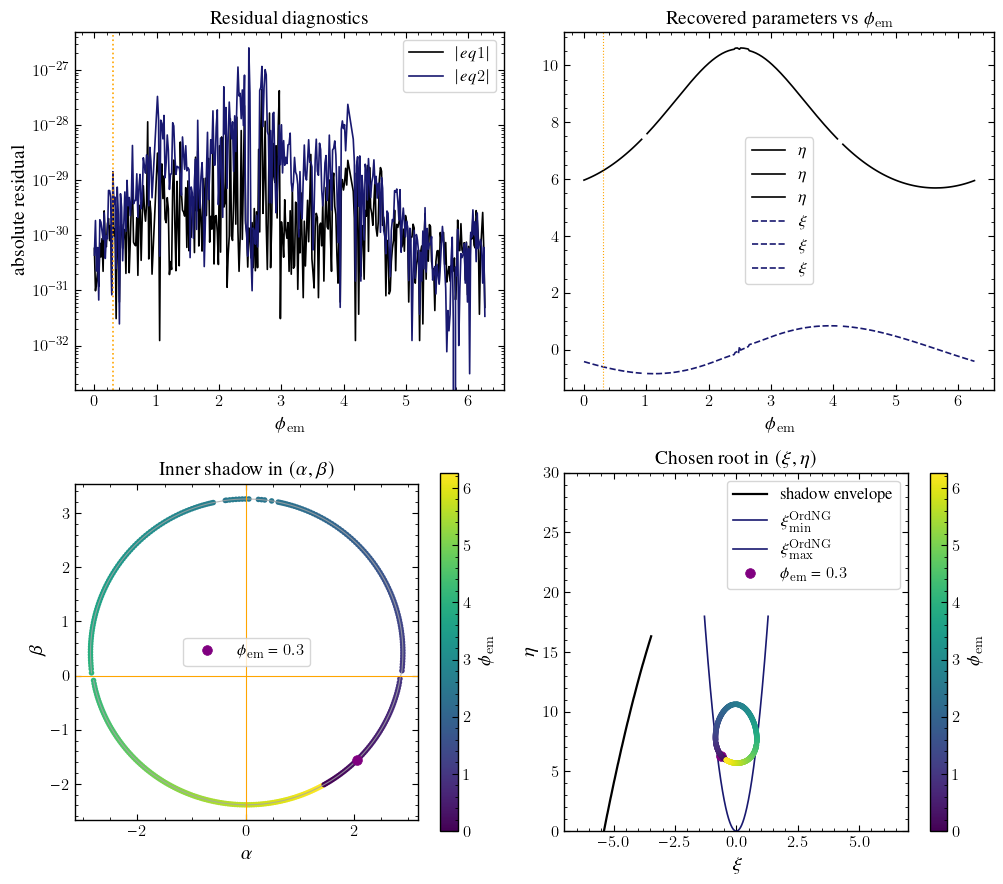

In [54]:
using CSV
using DataFrames
using Statistics
using PyPlot

metric_params_Val = (TCOMP(0.1), TCOMP(1e-3))
inc_Val           = TCOMP(17.0) * TCOMP(pi) / TCOMP(180.0)

phi_em_Val  = TCOMP(0.3)
phi_obs_Val = zero(TCOMP)

nphi_Val  = 360
nxi_Val   = 61
neta_Val  = 61
nkeep_Val = 8

###########################################################################################
# Filename-safe tags
###########################################################################################

aVal = replace(string(Float64(metric_params_Val[1])), "." => "p")
LVal = replace(string(Float64(metric_params_Val[2])), "." => "p")

mkpath("./Data/Inner-Shadow")
mkpath("./Figures/Tests")

csvfile = "./Data/Inner-Shadow/Fig20a-KH-a-$aVal-L-$LVal.csv"
figfile = "./Figures/Tests/Fig20a-KH-a-$aVal-L-$LVal.png"

###########################################################################################
# Solve
###########################################################################################

shadow_cache_Val = make_shadow_cache(metric_params_Val)

pt = solve_inner_shadow_point_physical(
    inc_Val, metric_params_Val, phi_em_Val;
    phi_obs      = phi_obs_Val,
    shadow_cache = shadow_cache_Val,
    nxi          = nxi_Val,
    neta         = neta_Val,
    nkeep        = nkeep_Val
)

curve = solve_inner_shadow_curve_physical(
    inc_Val, metric_params_Val;
    nphi         = nphi_Val,
    phi_obs      = phi_obs_Val,
    shadow_cache = shadow_cache_Val,
    nxi          = nxi_Val,
    neta         = neta_Val,
    nkeep        = nkeep_Val
)

###########################################################################################
# Convert solver outputs to Float64 arrays
###########################################################################################

phis_plot = Float64.(curve.phi_em)

nphi = length(curve.phi_em)

eta_phys_plot = fill(NaN, nphi)
xi_phys_plot  = fill(NaN, nphi)

eq1_phys_plot = fill(NaN, nphi)
eq2_phys_plot = fill(NaN, nphi)

conv_phys = fill(false, nphi)

for i in eachindex(curve.phi_em)
    if curve.conv_n0[i]
        eta_phys_plot[i] = Float64(curve.eta_n0[i])
        xi_phys_plot[i]  = Float64(curve.xi_n0[i])
        eq1_phys_plot[i] = Float64(curve.eq1_n0[i])
        eq2_phys_plot[i] = Float64(curve.eq2_n0[i])
        conv_phys[i]     = true

    elseif curve.conv_n1[i]
        eta_phys_plot[i] = Float64(curve.eta_n1[i])
        xi_phys_plot[i]  = Float64(curve.xi_n1[i])
        eq1_phys_plot[i] = Float64(curve.eq1_n1[i])
        eq2_phys_plot[i] = Float64(curve.eq2_n1[i])
        conv_phys[i]     = true
    end
end

good_phys = findall(conv_phys)

alpha_phys_plot = Float64.(curve.alpha_phys)
beta_phys_plot  = Float64.(curve.beta_phys)

# Keep this stringified explicitly before writing
src_phys_plot = string.(curve.src_phys)

###########################################################################################
# Shadow-envelope curve in (xi, eta)
###########################################################################################

xi_sh_plot  = Float64.(shadow_cache_Val.xi_nodes)
eta_sh_plot = Float64.(shadow_cache_Val.eta_nodes)

###########################################################################################
# Ordinary-NG band edges in (xi, eta)
###########################################################################################

eta_band    = range(0.0, 30.0; length=600)
xi_min_band = Float64[]
xi_max_band = Float64[]

for eta in eta_band
    push!(xi_min_band, Float64(xi_Min_OrdNG(inc_Val, metric_params_Val, (TCOMP(eta), zero(TCOMP)))))
    push!(xi_max_band, Float64(xi_Max_OrdNG(inc_Val, metric_params_Val, (TCOMP(eta), zero(TCOMP)))))
end

###########################################################################################
# Single-point solution
###########################################################################################

sol_phys = pt.sol

eta_sol = shadow_sol_converged(sol_phys) ? Float64(sol_phys.eta) : NaN
xi_sol  = shadow_sol_converged(sol_phys) ? Float64(sol_phys.xi)  : NaN

alpha_phys_sol = isfinite(pt.alpha_phys) ? Float64(pt.alpha_phys) : NaN
beta_phys_sol  = isfinite(pt.beta_phys)  ? Float64(pt.beta_phys)  : NaN

###########################################################################################
# Helpers: spike detection
###########################################################################################

function isolated_spike_mask(y, valid_idx; jump_factor=20.0)
    bad = falses(length(y))
    length(valid_idx) < 3 && return bad

    yv = y[valid_idx]
    dy = abs.(diff(yv))
    dy_fin = filter(isfinite, dy)

    isempty(dy_fin) && return bad

    dy_med = median(dy_fin)
    (!isfinite(dy_med) || dy_med <= 0.0) && return bad

    for j in 2:length(valid_idx)-1
        k  = valid_idx[j]
        km = valid_idx[j-1]
        kp = valid_idx[j+1]

        if !(isfinite(y[km]) && isfinite(y[k]) && isfinite(y[kp]))
            continue
        end

        jl = abs(y[k]  - y[km])
        jr = abs(y[k]  - y[kp])
        jn = abs(y[kp] - y[km])

        if jl > jump_factor * dy_med &&
           jr > jump_factor * dy_med &&
           jn < jump_factor * dy_med
            bad[k] = true
        end
    end

    return bad
end

function isolated_spike_mask_2d(x, y, valid_idx; jump_factor=20.0)
    bad = falses(length(x))
    length(valid_idx) < 3 && return bad

    ds = Float64[]
    for j in 1:length(valid_idx)-1
        k1 = valid_idx[j]
        k2 = valid_idx[j+1]

        if isfinite(x[k1]) && isfinite(y[k1]) && isfinite(x[k2]) && isfinite(y[k2])
            push!(ds, hypot(x[k2] - x[k1], y[k2] - y[k1]))
        end
    end

    ds_fin = filter(isfinite, ds)
    isempty(ds_fin) && return bad

    ds_med = median(ds_fin)
    (!isfinite(ds_med) || ds_med <= 0.0) && return bad

    for j in 2:length(valid_idx)-1
        k  = valid_idx[j]
        km = valid_idx[j-1]
        kp = valid_idx[j+1]

        if !(isfinite(x[km]) && isfinite(y[km]) &&
             isfinite(x[k])  && isfinite(y[k])  &&
             isfinite(x[kp]) && isfinite(y[kp]))
            continue
        end

        jl = hypot(x[k]  - x[km], y[k]  - y[km])
        jr = hypot(x[k]  - x[kp], y[k]  - y[kp])
        jn = hypot(x[kp] - x[km], y[kp] - y[km])

        if jl > jump_factor * ds_med &&
           jr > jump_factor * ds_med &&
           jn < jump_factor * ds_med
            bad[k] = true
        end
    end

    return bad
end

###########################################################################################
# Clean isolated bad samples
###########################################################################################

bad_eta   = isolated_spike_mask(eta_phys_plot, good_phys; jump_factor=20.0)
bad_xi    = isolated_spike_mask(xi_phys_plot,  good_phys; jump_factor=20.0)
bad_ab    = isolated_spike_mask_2d(alpha_phys_plot, beta_phys_plot, good_phys; jump_factor=20.0)
bad_xieta = isolated_spike_mask_2d(xi_phys_plot, eta_phys_plot, good_phys; jump_factor=20.0)

bad_any = bad_eta .| bad_xi .| bad_ab .| bad_xieta
good_clean_mask = conv_phys .& .!bad_any

###########################################################################################
# Pack shadow-envelope and NG-band data into master table columns
###########################################################################################

xi_sh_col       = fill(NaN, nphi)
eta_sh_col      = fill(NaN, nphi)
eta_band_col    = fill(NaN, nphi)
xi_min_band_col = fill(NaN, nphi)
xi_max_band_col = fill(NaN, nphi)

for i in 1:min(nphi, length(xi_sh_plot))
    xi_sh_col[i]  = xi_sh_plot[i]
    eta_sh_col[i] = eta_sh_plot[i]
end

for i in 1:min(nphi, length(eta_band))
    eta_band_col[i]    = Float64(eta_band[i])
    xi_min_band_col[i] = xi_min_band[i]
    xi_max_band_col[i] = xi_max_band[i]
end

###########################################################################################
# Write one master CSV
###########################################################################################

df_master = DataFrame(
    idx            = collect(1:nphi),
    phi_em         = phis_plot,

    conv_phys      = conv_phys,
    src_phys       = src_phys_plot,

    eta_phys       = eta_phys_plot,
    xi_phys        = xi_phys_plot,
    eq1_phys       = eq1_phys_plot,
    eq2_phys       = eq2_phys_plot,

    alpha_phys     = alpha_phys_plot,
    beta_phys      = beta_phys_plot,

    bad_eta        = bad_eta,
    bad_xi         = bad_xi,
    bad_ab         = bad_ab,
    bad_xieta      = bad_xieta,
    bad_any        = bad_any,
    good_clean     = good_clean_mask,

    xi_sh          = xi_sh_col,
    eta_sh         = eta_sh_col,

    eta_band       = eta_band_col,
    xi_min_band    = xi_min_band_col,
    xi_max_band    = xi_max_band_col,

    a              = fill(Float64(metric_params_Val[1]), nphi),
    L              = fill(Float64(metric_params_Val[2]), nphi),
    inc_rad        = fill(Float64(inc_Val), nphi),
    inc_deg        = fill(Float64(inc_Val * 180 / pi), nphi),
    phi_obs        = fill(Float64(phi_obs_Val), nphi),

    phi_em_sol     = fill(Float64(phi_em_Val), nphi),
    xi_sol         = fill(xi_sol, nphi),
    eta_sol        = fill(eta_sol, nphi),
    alpha_phys_sol = fill(alpha_phys_sol, nphi),
    beta_phys_sol  = fill(beta_phys_sol, nphi),

    nphi_meta      = fill(nphi_Val, nphi),
    nxi_meta       = fill(nxi_Val, nphi),
    neta_meta      = fill(neta_Val, nphi),
    nkeep_meta     = fill(nkeep_Val, nphi)
)

CSV.write(csvfile, df_master)
println("Saved CSV to: $csvfile")

###########################################################################################
# Read the CSV back
###########################################################################################

# Force src_phys to come back as String, so there is no type ambiguity
df = CSV.read(csvfile, DataFrame; types=Dict(:src_phys => String))

###########################################################################################
# Reconstruct plotting arrays from the CSV
###########################################################################################

phis_plot       = Vector{Float64}(df.phi_em)
eta_phys_plot   = Vector{Float64}(df.eta_phys)
xi_phys_plot    = Vector{Float64}(df.xi_phys)
eq1_phys_plot   = Vector{Float64}(df.eq1_phys)
eq2_phys_plot   = Vector{Float64}(df.eq2_phys)
alpha_phys_plot = Vector{Float64}(df.alpha_phys)
beta_phys_plot  = Vector{Float64}(df.beta_phys)

conv_phys       = Vector{Bool}(df.conv_phys)
bad_any         = Vector{Bool}(df.bad_any)
good_clean_mask = Vector{Bool}(df.good_clean)

src_phys_plot   = Vector{String}(df.src_phys)

good_phys_clean = findall(good_clean_mask)

xi_sh_plot  = Vector{Float64}(df.xi_sh[isfinite.(df.xi_sh)])
eta_sh_plot = Vector{Float64}(df.eta_sh[isfinite.(df.eta_sh)])

eta_band    = Vector{Float64}(df.eta_band[isfinite.(df.eta_band)])
xi_min_band = Vector{Float64}(df.xi_min_band[isfinite.(df.xi_min_band)])
xi_max_band = Vector{Float64}(df.xi_max_band[isfinite.(df.xi_max_band)])

a_val          = df.a[1]
L_val          = df.L[1]
inc_rad        = df.inc_rad[1]
phi_em_sol     = df.phi_em_sol[1]
xi_sol         = df.xi_sol[1]
eta_sol        = df.eta_sol[1]
alpha_phys_sol = df.alpha_phys_sol[1]
beta_phys_sol  = df.beta_phys_sol[1]

###########################################################################################
# Helpers for plotting
###########################################################################################

function plot_segments(ax, x, y, idx; kwargs...)
    isempty(idx) && return

    start = 1
    for k in 2:length(idx)
        if idx[k] != idx[k-1] + 1
            seg = idx[start:k-1]
            ax.plot(x[seg], y[seg]; kwargs...)
            start = k
        end
    end

    seg = idx[start:end]
    ax.plot(x[seg], y[seg]; kwargs...)
end

function branch_sorted_by_angle(phi, alpha, beta, good_idx)
    phi_v   = Float64[]
    alpha_v = Float64[]
    beta_v  = Float64[]
    ang_v   = Float64[]

    for i in good_idx
        ai    = alpha[i]
        bi    = beta[i]
        phi_i = phi[i]

        if isfinite(ai) && isfinite(bi) && isfinite(phi_i)
            push!(phi_v, phi_i)
            push!(alpha_v, ai)
            push!(beta_v, bi)
            push!(ang_v, atan(bi, ai))
        end
    end

    p = sortperm(ang_v)

    return (
        phi   = phi_v[p],
        alpha = alpha_v[p],
        beta  = beta_v[p],
        ang   = ang_v[p]
    )
end

branch_phys = branch_sorted_by_angle(phis_plot, alpha_phys_plot, beta_phys_plot, good_phys_clean)

###########################################################################################
# Colormap setup
###########################################################################################

phi_min_cb = minimum(phis_plot)
phi_max_cb = maximum(phis_plot)

norm_cb = matplotlib.colors.Normalize(vmin=phi_min_cb, vmax=phi_max_cb)
cmap_cb = "viridis"

###########################################################################################
# Figure
###########################################################################################

colors = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]

linestyles = ["-", "--", ":", "-.",
              (0, (3, 1, 1, 1)),
              (0, (5, 2)),
              (0, (1, 1))]

linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 2, 2

fig = figure(figsize=(n_cols * fig_width * 1.5, n_rows * fig_height * 1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "res_diag"          => fig.add_subplot(gs[1, 1]),
    "sol_params"        => fig.add_subplot(gs[1, 2]),
    "inner_sh_im_plane" => fig.add_subplot(gs[2, 1]),
    "inner_sh_NG"       => fig.add_subplot(gs[2, 2])
)

ax1 = axes["res_diag"]
ax2 = axes["sol_params"]
ax3 = axes["inner_sh_im_plane"]
ax4 = axes["inner_sh_NG"]

###########################################################################################
# Panel 1: Residual diagnostics
###########################################################################################

ax1.set_title("Residual diagnostics")
ax1.set_xlabel(L"\phi_{\rm em}")
ax1.set_ylabel("absolute residual")

if !isempty(good_phys_clean)
    ax1.semilogy(
        phis_plot[good_phys_clean],
        abs.(eq1_phys_plot[good_phys_clean]);
        color = colors[1],
        lw    = linewidths[2],
        label = L"|eq1|"
    )

    ax1.semilogy(
        phis_plot[good_phys_clean],
        abs.(eq2_phys_plot[good_phys_clean]);
        color = colors[2],
        lw    = linewidths[2],
        label = L"|eq2|"
    )
end

ax1.axvline(phi_em_sol, color=colors[5], lw=linewidths[2], ls=linestyles[3])
ax1.legend(loc="best")

###########################################################################################
# Panel 2: Recovered parameters vs phi_em
###########################################################################################

ax2.set_title(L"Recovered parameters vs $\phi_{\rm em}$")
ax2.set_xlabel(L"\phi_{\rm em}")

plot_segments(
    ax2, phis_plot, eta_phys_plot, good_phys_clean;
    color = colors[1],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\eta"
)

plot_segments(
    ax2, phis_plot, xi_phys_plot, good_phys_clean;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[2],
    label = L"\xi"
)

ax2.axvline(phi_em_sol, color=colors[5], lw=linewidths[1], ls=linestyles[3])
ax2.legend(loc="best")

###########################################################################################
# Panel 3: Physical inner shadow in (alpha, beta)
###########################################################################################

ax3.set_title(L"Inner shadow in $(\alpha,\beta)$")
ax3.set_xlabel(L"\alpha")
ax3.set_ylabel(L"\beta")

if !isempty(branch_phys.alpha)
    ax3.scatter(
        branch_phys.alpha,
        branch_phys.beta;
        c          = branch_phys.phi,
        cmap       = cmap_cb,
        norm       = norm_cb,
        s          = 16,
        linewidths = 0.0
    )

    ax3.plot(branch_phys.alpha, branch_phys.beta; color="0.65", lw=0.8, alpha=0.8)
end

if isfinite(alpha_phys_sol) && isfinite(beta_phys_sol)
    ax3.plot([alpha_phys_sol], [beta_phys_sol], "o", color=colors[6], ms=7, label=L"\phi_{\rm em}=0.3")
end

ax3.axhline(0.0, color=colors[5], lw=linewidths[1])
ax3.axvline(0.0, color=colors[5], lw=linewidths[1])
ax3.set_aspect("equal")

cb3 = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_cb, cmap=cmap_cb), ax=ax3)
cb3.set_label(L"\phi_{\rm em}")

ax3.legend(loc="best")

###########################################################################################
# Panel 4: Chosen physical root in (xi, eta), colored by phi_em
###########################################################################################

ax4.set_title(L"Chosen root in $(\xi,\eta)$")
ax4.set_xlabel(L"\xi")
ax4.set_ylabel(L"\eta")

ax4.plot(
    xi_sh_plot, eta_sh_plot;
    color = colors[1],
    lw    = linewidths[3],
    ls    = linestyles[1],
    label = "shadow envelope"
)

ax4.plot(
    xi_min_band, eta_band;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\xi_{\min}^{\rm OrdNG}"
)

ax4.plot(
    xi_max_band, eta_band;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\xi_{\max}^{\rm OrdNG}"
)

if !isempty(good_phys_clean)
    ax4.scatter(
        xi_phys_plot[good_phys_clean],
        eta_phys_plot[good_phys_clean];
        c          = phis_plot[good_phys_clean],
        cmap       = cmap_cb,
        norm       = norm_cb,
        s          = 16,
        linewidths = 0.0,
        zorder     = 3
    )

    plot_segments(ax4, xi_phys_plot, eta_phys_plot, good_phys_clean; color="0.65", lw=0.8, alpha=0.8)
end

if isfinite(xi_sol) && isfinite(eta_sol)
    ax4.plot([xi_sol], [eta_sol], "o", color=colors[6], ms=7, label=L"\phi_{\rm em}=0.3")
end

ax4.set_xlim([-7.0, 7.0])
ax4.set_ylim([0.0, 30.0])

cb4 = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_cb, cmap=cmap_cb), ax=ax4)
cb4.set_label(L"\phi_{\rm em}")

ax4.legend(loc="best")

###########################################################################################
# Save figure
###########################################################################################

fig.tight_layout()
savefig(figfile, dpi=150)

println("Saved figure to: $figfile")

Saved CSV to: ./Data/Inner-Shadow/Fig20b-KH-a-0p1-L-0p5.csv
Saved figure to: ./Figures/Tests/Fig20b-KH-a-0p1-L-0p5.png


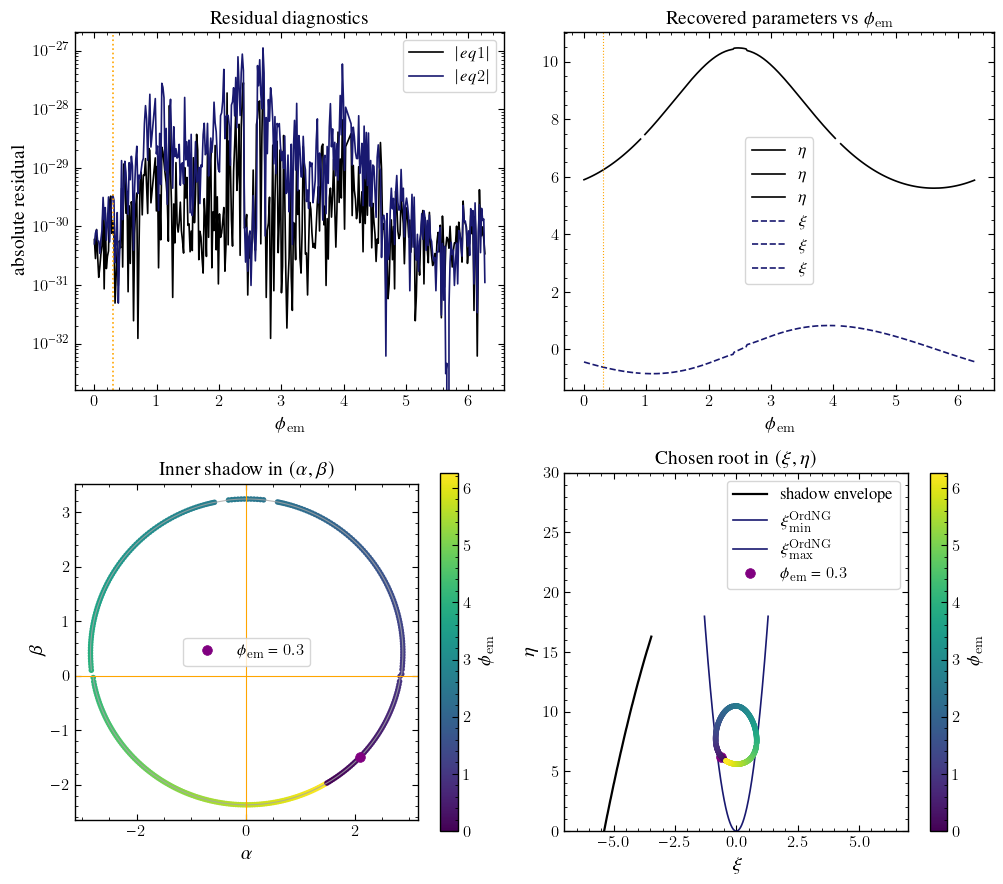

In [55]:
metric_params_Val = (TCOMP(0.1), TCOMP(0.5))
inc_Val           = TCOMP(17.0) * TCOMP(pi) / TCOMP(180.0)

phi_em_Val  = TCOMP(0.3)
phi_obs_Val = zero(TCOMP)

nphi_Val  = 360
nxi_Val   = 61
neta_Val  = 61
nkeep_Val = 8

###########################################################################################
# Filename-safe tags
###########################################################################################

aVal = replace(string(Float64(metric_params_Val[1])), "." => "p")
LVal = replace(string(Float64(metric_params_Val[2])), "." => "p")

mkpath("./Data/Inner-Shadow")
mkpath("./Figures/Tests")

csvfile = "./Data/Inner-Shadow/Fig20b-KH-a-$aVal-L-$LVal.csv"
figfile = "./Figures/Tests/Fig20b-KH-a-$aVal-L-$LVal.png"

###########################################################################################
# Solve
###########################################################################################

shadow_cache_Val = make_shadow_cache(metric_params_Val)

pt = solve_inner_shadow_point_physical(
    inc_Val, metric_params_Val, phi_em_Val;
    phi_obs      = phi_obs_Val,
    shadow_cache = shadow_cache_Val,
    nxi          = nxi_Val,
    neta         = neta_Val,
    nkeep        = nkeep_Val
)

curve = solve_inner_shadow_curve_physical(
    inc_Val, metric_params_Val;
    nphi         = nphi_Val,
    phi_obs      = phi_obs_Val,
    shadow_cache = shadow_cache_Val,
    nxi          = nxi_Val,
    neta         = neta_Val,
    nkeep        = nkeep_Val
)

###########################################################################################
# Convert solver outputs to Float64 arrays
###########################################################################################

phis_plot = Float64.(curve.phi_em)

nphi = length(curve.phi_em)

eta_phys_plot = fill(NaN, nphi)
xi_phys_plot  = fill(NaN, nphi)

eq1_phys_plot = fill(NaN, nphi)
eq2_phys_plot = fill(NaN, nphi)

conv_phys = fill(false, nphi)

for i in eachindex(curve.phi_em)
    if curve.conv_n0[i]
        eta_phys_plot[i] = Float64(curve.eta_n0[i])
        xi_phys_plot[i]  = Float64(curve.xi_n0[i])
        eq1_phys_plot[i] = Float64(curve.eq1_n0[i])
        eq2_phys_plot[i] = Float64(curve.eq2_n0[i])
        conv_phys[i]     = true

    elseif curve.conv_n1[i]
        eta_phys_plot[i] = Float64(curve.eta_n1[i])
        xi_phys_plot[i]  = Float64(curve.xi_n1[i])
        eq1_phys_plot[i] = Float64(curve.eq1_n1[i])
        eq2_phys_plot[i] = Float64(curve.eq2_n1[i])
        conv_phys[i]     = true
    end
end

good_phys = findall(conv_phys)

alpha_phys_plot = Float64.(curve.alpha_phys)
beta_phys_plot  = Float64.(curve.beta_phys)

# Keep this stringified explicitly before writing
src_phys_plot = string.(curve.src_phys)

###########################################################################################
# Shadow-envelope curve in (xi, eta)
###########################################################################################

xi_sh_plot  = Float64.(shadow_cache_Val.xi_nodes)
eta_sh_plot = Float64.(shadow_cache_Val.eta_nodes)

###########################################################################################
# Ordinary-NG band edges in (xi, eta)
###########################################################################################

eta_band    = range(0.0, 30.0; length=600)
xi_min_band = Float64[]
xi_max_band = Float64[]

for eta in eta_band
    push!(xi_min_band, Float64(xi_Min_OrdNG(inc_Val, metric_params_Val, (TCOMP(eta), zero(TCOMP)))))
    push!(xi_max_band, Float64(xi_Max_OrdNG(inc_Val, metric_params_Val, (TCOMP(eta), zero(TCOMP)))))
end

###########################################################################################
# Single-point solution
###########################################################################################

sol_phys = pt.sol

eta_sol = shadow_sol_converged(sol_phys) ? Float64(sol_phys.eta) : NaN
xi_sol  = shadow_sol_converged(sol_phys) ? Float64(sol_phys.xi)  : NaN

alpha_phys_sol = isfinite(pt.alpha_phys) ? Float64(pt.alpha_phys) : NaN
beta_phys_sol  = isfinite(pt.beta_phys)  ? Float64(pt.beta_phys)  : NaN

###########################################################################################
# Helpers: spike detection
###########################################################################################

function isolated_spike_mask(y, valid_idx; jump_factor=20.0)
    bad = falses(length(y))
    length(valid_idx) < 3 && return bad

    yv = y[valid_idx]
    dy = abs.(diff(yv))
    dy_fin = filter(isfinite, dy)

    isempty(dy_fin) && return bad

    dy_med = median(dy_fin)
    (!isfinite(dy_med) || dy_med <= 0.0) && return bad

    for j in 2:length(valid_idx)-1
        k  = valid_idx[j]
        km = valid_idx[j-1]
        kp = valid_idx[j+1]

        if !(isfinite(y[km]) && isfinite(y[k]) && isfinite(y[kp]))
            continue
        end

        jl = abs(y[k]  - y[km])
        jr = abs(y[k]  - y[kp])
        jn = abs(y[kp] - y[km])

        if jl > jump_factor * dy_med &&
           jr > jump_factor * dy_med &&
           jn < jump_factor * dy_med
            bad[k] = true
        end
    end

    return bad
end

function isolated_spike_mask_2d(x, y, valid_idx; jump_factor=20.0)
    bad = falses(length(x))
    length(valid_idx) < 3 && return bad

    ds = Float64[]
    for j in 1:length(valid_idx)-1
        k1 = valid_idx[j]
        k2 = valid_idx[j+1]

        if isfinite(x[k1]) && isfinite(y[k1]) && isfinite(x[k2]) && isfinite(y[k2])
            push!(ds, hypot(x[k2] - x[k1], y[k2] - y[k1]))
        end
    end

    ds_fin = filter(isfinite, ds)
    isempty(ds_fin) && return bad

    ds_med = median(ds_fin)
    (!isfinite(ds_med) || ds_med <= 0.0) && return bad

    for j in 2:length(valid_idx)-1
        k  = valid_idx[j]
        km = valid_idx[j-1]
        kp = valid_idx[j+1]

        if !(isfinite(x[km]) && isfinite(y[km]) &&
             isfinite(x[k])  && isfinite(y[k])  &&
             isfinite(x[kp]) && isfinite(y[kp]))
            continue
        end

        jl = hypot(x[k]  - x[km], y[k]  - y[km])
        jr = hypot(x[k]  - x[kp], y[k]  - y[kp])
        jn = hypot(x[kp] - x[km], y[kp] - y[km])

        if jl > jump_factor * ds_med &&
           jr > jump_factor * ds_med &&
           jn < jump_factor * ds_med
            bad[k] = true
        end
    end

    return bad
end

###########################################################################################
# Clean isolated bad samples
###########################################################################################

bad_eta   = isolated_spike_mask(eta_phys_plot, good_phys; jump_factor=20.0)
bad_xi    = isolated_spike_mask(xi_phys_plot,  good_phys; jump_factor=20.0)
bad_ab    = isolated_spike_mask_2d(alpha_phys_plot, beta_phys_plot, good_phys; jump_factor=20.0)
bad_xieta = isolated_spike_mask_2d(xi_phys_plot, eta_phys_plot, good_phys; jump_factor=20.0)

bad_any = bad_eta .| bad_xi .| bad_ab .| bad_xieta
good_clean_mask = conv_phys .& .!bad_any

###########################################################################################
# Pack shadow-envelope and NG-band data into master table columns
###########################################################################################

xi_sh_col       = fill(NaN, nphi)
eta_sh_col      = fill(NaN, nphi)
eta_band_col    = fill(NaN, nphi)
xi_min_band_col = fill(NaN, nphi)
xi_max_band_col = fill(NaN, nphi)

for i in 1:min(nphi, length(xi_sh_plot))
    xi_sh_col[i]  = xi_sh_plot[i]
    eta_sh_col[i] = eta_sh_plot[i]
end

for i in 1:min(nphi, length(eta_band))
    eta_band_col[i]    = Float64(eta_band[i])
    xi_min_band_col[i] = xi_min_band[i]
    xi_max_band_col[i] = xi_max_band[i]
end

###########################################################################################
# Write one master CSV
###########################################################################################

df_master = DataFrame(
    idx            = collect(1:nphi),
    phi_em         = phis_plot,

    conv_phys      = conv_phys,
    src_phys       = src_phys_plot,

    eta_phys       = eta_phys_plot,
    xi_phys        = xi_phys_plot,
    eq1_phys       = eq1_phys_plot,
    eq2_phys       = eq2_phys_plot,

    alpha_phys     = alpha_phys_plot,
    beta_phys      = beta_phys_plot,

    bad_eta        = bad_eta,
    bad_xi         = bad_xi,
    bad_ab         = bad_ab,
    bad_xieta      = bad_xieta,
    bad_any        = bad_any,
    good_clean     = good_clean_mask,

    xi_sh          = xi_sh_col,
    eta_sh         = eta_sh_col,

    eta_band       = eta_band_col,
    xi_min_band    = xi_min_band_col,
    xi_max_band    = xi_max_band_col,

    a              = fill(Float64(metric_params_Val[1]), nphi),
    L              = fill(Float64(metric_params_Val[2]), nphi),
    inc_rad        = fill(Float64(inc_Val), nphi),
    inc_deg        = fill(Float64(inc_Val * 180 / pi), nphi),
    phi_obs        = fill(Float64(phi_obs_Val), nphi),

    phi_em_sol     = fill(Float64(phi_em_Val), nphi),
    xi_sol         = fill(xi_sol, nphi),
    eta_sol        = fill(eta_sol, nphi),
    alpha_phys_sol = fill(alpha_phys_sol, nphi),
    beta_phys_sol  = fill(beta_phys_sol, nphi),

    nphi_meta      = fill(nphi_Val, nphi),
    nxi_meta       = fill(nxi_Val, nphi),
    neta_meta      = fill(neta_Val, nphi),
    nkeep_meta     = fill(nkeep_Val, nphi)
)

CSV.write(csvfile, df_master)
println("Saved CSV to: $csvfile")

###########################################################################################
# Read the CSV back
###########################################################################################

# Force src_phys to come back as String, so there is no type ambiguity
df = CSV.read(csvfile, DataFrame; types=Dict(:src_phys => String))

###########################################################################################
# Reconstruct plotting arrays from the CSV
###########################################################################################

phis_plot       = Vector{Float64}(df.phi_em)
eta_phys_plot   = Vector{Float64}(df.eta_phys)
xi_phys_plot    = Vector{Float64}(df.xi_phys)
eq1_phys_plot   = Vector{Float64}(df.eq1_phys)
eq2_phys_plot   = Vector{Float64}(df.eq2_phys)
alpha_phys_plot = Vector{Float64}(df.alpha_phys)
beta_phys_plot  = Vector{Float64}(df.beta_phys)

conv_phys       = Vector{Bool}(df.conv_phys)
bad_any         = Vector{Bool}(df.bad_any)
good_clean_mask = Vector{Bool}(df.good_clean)

src_phys_plot   = Vector{String}(df.src_phys)

good_phys_clean = findall(good_clean_mask)

xi_sh_plot  = Vector{Float64}(df.xi_sh[isfinite.(df.xi_sh)])
eta_sh_plot = Vector{Float64}(df.eta_sh[isfinite.(df.eta_sh)])

eta_band    = Vector{Float64}(df.eta_band[isfinite.(df.eta_band)])
xi_min_band = Vector{Float64}(df.xi_min_band[isfinite.(df.xi_min_band)])
xi_max_band = Vector{Float64}(df.xi_max_band[isfinite.(df.xi_max_band)])

a_val          = df.a[1]
L_val          = df.L[1]
inc_rad        = df.inc_rad[1]
phi_em_sol     = df.phi_em_sol[1]
xi_sol         = df.xi_sol[1]
eta_sol        = df.eta_sol[1]
alpha_phys_sol = df.alpha_phys_sol[1]
beta_phys_sol  = df.beta_phys_sol[1]

###########################################################################################
# Helpers for plotting
###########################################################################################

function plot_segments(ax, x, y, idx; kwargs...)
    isempty(idx) && return

    start = 1
    for k in 2:length(idx)
        if idx[k] != idx[k-1] + 1
            seg = idx[start:k-1]
            ax.plot(x[seg], y[seg]; kwargs...)
            start = k
        end
    end

    seg = idx[start:end]
    ax.plot(x[seg], y[seg]; kwargs...)
end

function branch_sorted_by_angle(phi, alpha, beta, good_idx)
    phi_v   = Float64[]
    alpha_v = Float64[]
    beta_v  = Float64[]
    ang_v   = Float64[]

    for i in good_idx
        ai    = alpha[i]
        bi    = beta[i]
        phi_i = phi[i]

        if isfinite(ai) && isfinite(bi) && isfinite(phi_i)
            push!(phi_v, phi_i)
            push!(alpha_v, ai)
            push!(beta_v, bi)
            push!(ang_v, atan(bi, ai))
        end
    end

    p = sortperm(ang_v)

    return (
        phi   = phi_v[p],
        alpha = alpha_v[p],
        beta  = beta_v[p],
        ang   = ang_v[p]
    )
end

branch_phys = branch_sorted_by_angle(phis_plot, alpha_phys_plot, beta_phys_plot, good_phys_clean)

###########################################################################################
# Colormap setup
###########################################################################################

phi_min_cb = minimum(phis_plot)
phi_max_cb = maximum(phis_plot)

norm_cb = matplotlib.colors.Normalize(vmin=phi_min_cb, vmax=phi_max_cb)
cmap_cb = "viridis"

###########################################################################################
# Figure
###########################################################################################

colors = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]

linestyles = ["-", "--", ":", "-.",
              (0, (3, 1, 1, 1)),
              (0, (5, 2)),
              (0, (1, 1))]

linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 2, 2

fig = figure(figsize=(n_cols * fig_width * 1.5, n_rows * fig_height * 1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "res_diag"          => fig.add_subplot(gs[1, 1]),
    "sol_params"        => fig.add_subplot(gs[1, 2]),
    "inner_sh_im_plane" => fig.add_subplot(gs[2, 1]),
    "inner_sh_NG"       => fig.add_subplot(gs[2, 2])
)

ax1 = axes["res_diag"]
ax2 = axes["sol_params"]
ax3 = axes["inner_sh_im_plane"]
ax4 = axes["inner_sh_NG"]

###########################################################################################
# Panel 1: Residual diagnostics
###########################################################################################

ax1.set_title("Residual diagnostics")
ax1.set_xlabel(L"\phi_{\rm em}")
ax1.set_ylabel("absolute residual")

if !isempty(good_phys_clean)
    ax1.semilogy(
        phis_plot[good_phys_clean],
        abs.(eq1_phys_plot[good_phys_clean]);
        color = colors[1],
        lw    = linewidths[2],
        label = L"|eq1|"
    )

    ax1.semilogy(
        phis_plot[good_phys_clean],
        abs.(eq2_phys_plot[good_phys_clean]);
        color = colors[2],
        lw    = linewidths[2],
        label = L"|eq2|"
    )
end

ax1.axvline(phi_em_sol, color=colors[5], lw=linewidths[2], ls=linestyles[3])
ax1.legend(loc="best")

###########################################################################################
# Panel 2: Recovered parameters vs phi_em
###########################################################################################

ax2.set_title(L"Recovered parameters vs $\phi_{\rm em}$")
ax2.set_xlabel(L"\phi_{\rm em}")

plot_segments(
    ax2, phis_plot, eta_phys_plot, good_phys_clean;
    color = colors[1],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\eta"
)

plot_segments(
    ax2, phis_plot, xi_phys_plot, good_phys_clean;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[2],
    label = L"\xi"
)

ax2.axvline(phi_em_sol, color=colors[5], lw=linewidths[1], ls=linestyles[3])
ax2.legend(loc="best")

###########################################################################################
# Panel 3: Physical inner shadow in (alpha, beta)
###########################################################################################

ax3.set_title(L"Inner shadow in $(\alpha,\beta)$")
ax3.set_xlabel(L"\alpha")
ax3.set_ylabel(L"\beta")

if !isempty(branch_phys.alpha)
    ax3.scatter(
        branch_phys.alpha,
        branch_phys.beta;
        c          = branch_phys.phi,
        cmap       = cmap_cb,
        norm       = norm_cb,
        s          = 16,
        linewidths = 0.0
    )

    ax3.plot(branch_phys.alpha, branch_phys.beta; color="0.65", lw=0.8, alpha=0.8)
end

if isfinite(alpha_phys_sol) && isfinite(beta_phys_sol)
    ax3.plot([alpha_phys_sol], [beta_phys_sol], "o", color=colors[6], ms=7, label=L"\phi_{\rm em}=0.3")
end

ax3.axhline(0.0, color=colors[5], lw=linewidths[1])
ax3.axvline(0.0, color=colors[5], lw=linewidths[1])
ax3.set_aspect("equal")

cb3 = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_cb, cmap=cmap_cb), ax=ax3)
cb3.set_label(L"\phi_{\rm em}")

ax3.legend(loc="best")

###########################################################################################
# Panel 4: Chosen physical root in (xi, eta), colored by phi_em
###########################################################################################

ax4.set_title(L"Chosen root in $(\xi,\eta)$")
ax4.set_xlabel(L"\xi")
ax4.set_ylabel(L"\eta")

ax4.plot(
    xi_sh_plot, eta_sh_plot;
    color = colors[1],
    lw    = linewidths[3],
    ls    = linestyles[1],
    label = "shadow envelope"
)

ax4.plot(
    xi_min_band, eta_band;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\xi_{\min}^{\rm OrdNG}"
)

ax4.plot(
    xi_max_band, eta_band;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\xi_{\max}^{\rm OrdNG}"
)

if !isempty(good_phys_clean)
    ax4.scatter(
        xi_phys_plot[good_phys_clean],
        eta_phys_plot[good_phys_clean];
        c          = phis_plot[good_phys_clean],
        cmap       = cmap_cb,
        norm       = norm_cb,
        s          = 16,
        linewidths = 0.0,
        zorder     = 3
    )

    plot_segments(ax4, xi_phys_plot, eta_phys_plot, good_phys_clean; color="0.65", lw=0.8, alpha=0.8)
end

if isfinite(xi_sol) && isfinite(eta_sol)
    ax4.plot([xi_sol], [eta_sol], "o", color=colors[6], ms=7, label=L"\phi_{\rm em}=0.3")
end

ax4.set_xlim([-7.0, 7.0])
ax4.set_ylim([0.0, 30.0])

cb4 = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_cb, cmap=cmap_cb), ax=ax4)
cb4.set_label(L"\phi_{\rm em}")

ax4.legend(loc="best")

###########################################################################################
# Save figure
###########################################################################################

fig.tight_layout()
savefig(figfile, dpi=150)

println("Saved figure to: $figfile")

Saved CSV to: ./Data/Inner-Shadow/Fig20c-KH-a-0p5-L-0p001.csv
Saved figure to: ./Figures/Tests/Fig20c-KH-a-0p5-L-0p001.png


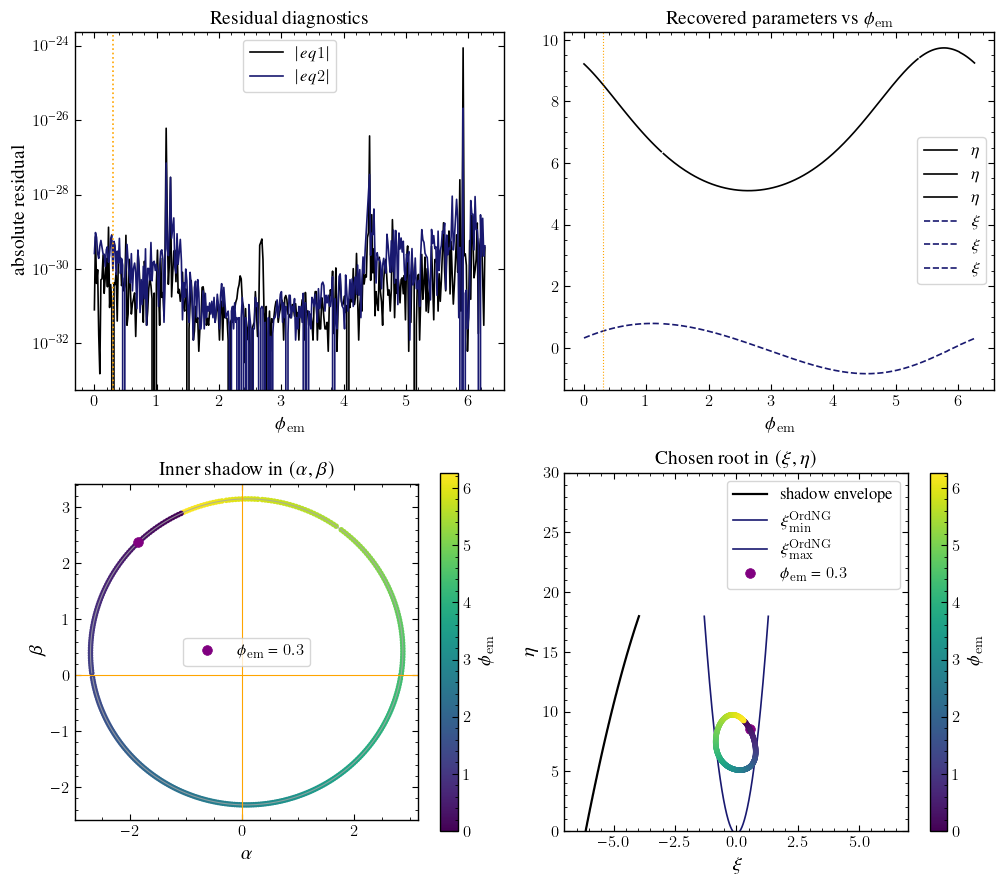

In [42]:
metric_params_Val = (TCOMP(0.5), TCOMP(1e-3))
inc_Val           = TCOMP(17.0) * TCOMP(pi) / TCOMP(180.0)

phi_em_Val  = TCOMP(0.3)
phi_obs_Val = zero(TCOMP)

nphi_Val  = 360
nxi_Val   = 61
neta_Val  = 61
nkeep_Val = 8

###########################################################################################
# Filename-safe tags
###########################################################################################

aVal = replace(string(Float64(metric_params_Val[1])), "." => "p")
LVal = replace(string(Float64(metric_params_Val[2])), "." => "p")

mkpath("./Data/Inner-Shadow")
mkpath("./Figures/Tests")

csvfile = "./Data/Inner-Shadow/Fig20c-KH-a-$aVal-L-$LVal.csv"
figfile = "./Figures/Tests/Fig20c-KH-a-$aVal-L-$LVal.png"

###########################################################################################
# Solve
###########################################################################################

shadow_cache_Val = make_shadow_cache(metric_params_Val)

pt = solve_inner_shadow_point_physical(
    inc_Val, metric_params_Val, phi_em_Val;
    phi_obs      = phi_obs_Val,
    shadow_cache = shadow_cache_Val,
    nxi          = nxi_Val,
    neta         = neta_Val,
    nkeep        = nkeep_Val
)

curve = solve_inner_shadow_curve_physical(
    inc_Val, metric_params_Val;
    nphi         = nphi_Val,
    phi_obs      = phi_obs_Val,
    shadow_cache = shadow_cache_Val,
    nxi          = nxi_Val,
    neta         = neta_Val,
    nkeep        = nkeep_Val
)

###########################################################################################
# Convert solver outputs to Float64 arrays
###########################################################################################

phis_plot = Float64.(curve.phi_em)

nphi = length(curve.phi_em)

eta_phys_plot = fill(NaN, nphi)
xi_phys_plot  = fill(NaN, nphi)

eq1_phys_plot = fill(NaN, nphi)
eq2_phys_plot = fill(NaN, nphi)

conv_phys = fill(false, nphi)

for i in eachindex(curve.phi_em)
    if curve.conv_n0[i]
        eta_phys_plot[i] = Float64(curve.eta_n0[i])
        xi_phys_plot[i]  = Float64(curve.xi_n0[i])
        eq1_phys_plot[i] = Float64(curve.eq1_n0[i])
        eq2_phys_plot[i] = Float64(curve.eq2_n0[i])
        conv_phys[i]     = true

    elseif curve.conv_n1[i]
        eta_phys_plot[i] = Float64(curve.eta_n1[i])
        xi_phys_plot[i]  = Float64(curve.xi_n1[i])
        eq1_phys_plot[i] = Float64(curve.eq1_n1[i])
        eq2_phys_plot[i] = Float64(curve.eq2_n1[i])
        conv_phys[i]     = true
    end
end

good_phys = findall(conv_phys)

alpha_phys_plot = Float64.(curve.alpha_phys)
beta_phys_plot  = Float64.(curve.beta_phys)

# Keep this stringified explicitly before writing
src_phys_plot = string.(curve.src_phys)

###########################################################################################
# Shadow-envelope curve in (xi, eta)
###########################################################################################

xi_sh_plot  = Float64.(shadow_cache_Val.xi_nodes)
eta_sh_plot = Float64.(shadow_cache_Val.eta_nodes)

###########################################################################################
# Ordinary-NG band edges in (xi, eta)
###########################################################################################

eta_band    = range(0.0, 30.0; length=600)
xi_min_band = Float64[]
xi_max_band = Float64[]

for eta in eta_band
    push!(xi_min_band, Float64(xi_Min_OrdNG(inc_Val, metric_params_Val, (TCOMP(eta), zero(TCOMP)))))
    push!(xi_max_band, Float64(xi_Max_OrdNG(inc_Val, metric_params_Val, (TCOMP(eta), zero(TCOMP)))))
end

###########################################################################################
# Single-point solution
###########################################################################################

sol_phys = pt.sol

eta_sol = shadow_sol_converged(sol_phys) ? Float64(sol_phys.eta) : NaN
xi_sol  = shadow_sol_converged(sol_phys) ? Float64(sol_phys.xi)  : NaN

alpha_phys_sol = isfinite(pt.alpha_phys) ? Float64(pt.alpha_phys) : NaN
beta_phys_sol  = isfinite(pt.beta_phys)  ? Float64(pt.beta_phys)  : NaN

###########################################################################################
# Helpers: spike detection
###########################################################################################

function isolated_spike_mask(y, valid_idx; jump_factor=20.0)
    bad = falses(length(y))
    length(valid_idx) < 3 && return bad

    yv = y[valid_idx]
    dy = abs.(diff(yv))
    dy_fin = filter(isfinite, dy)

    isempty(dy_fin) && return bad

    dy_med = median(dy_fin)
    (!isfinite(dy_med) || dy_med <= 0.0) && return bad

    for j in 2:length(valid_idx)-1
        k  = valid_idx[j]
        km = valid_idx[j-1]
        kp = valid_idx[j+1]

        if !(isfinite(y[km]) && isfinite(y[k]) && isfinite(y[kp]))
            continue
        end

        jl = abs(y[k]  - y[km])
        jr = abs(y[k]  - y[kp])
        jn = abs(y[kp] - y[km])

        if jl > jump_factor * dy_med &&
           jr > jump_factor * dy_med &&
           jn < jump_factor * dy_med
            bad[k] = true
        end
    end

    return bad
end

function isolated_spike_mask_2d(x, y, valid_idx; jump_factor=20.0)
    bad = falses(length(x))
    length(valid_idx) < 3 && return bad

    ds = Float64[]
    for j in 1:length(valid_idx)-1
        k1 = valid_idx[j]
        k2 = valid_idx[j+1]

        if isfinite(x[k1]) && isfinite(y[k1]) && isfinite(x[k2]) && isfinite(y[k2])
            push!(ds, hypot(x[k2] - x[k1], y[k2] - y[k1]))
        end
    end

    ds_fin = filter(isfinite, ds)
    isempty(ds_fin) && return bad

    ds_med = median(ds_fin)
    (!isfinite(ds_med) || ds_med <= 0.0) && return bad

    for j in 2:length(valid_idx)-1
        k  = valid_idx[j]
        km = valid_idx[j-1]
        kp = valid_idx[j+1]

        if !(isfinite(x[km]) && isfinite(y[km]) &&
             isfinite(x[k])  && isfinite(y[k])  &&
             isfinite(x[kp]) && isfinite(y[kp]))
            continue
        end

        jl = hypot(x[k]  - x[km], y[k]  - y[km])
        jr = hypot(x[k]  - x[kp], y[k]  - y[kp])
        jn = hypot(x[kp] - x[km], y[kp] - y[km])

        if jl > jump_factor * ds_med &&
           jr > jump_factor * ds_med &&
           jn < jump_factor * ds_med
            bad[k] = true
        end
    end

    return bad
end

###########################################################################################
# Clean isolated bad samples
###########################################################################################

bad_eta   = isolated_spike_mask(eta_phys_plot, good_phys; jump_factor=20.0)
bad_xi    = isolated_spike_mask(xi_phys_plot,  good_phys; jump_factor=20.0)
bad_ab    = isolated_spike_mask_2d(alpha_phys_plot, beta_phys_plot, good_phys; jump_factor=20.0)
bad_xieta = isolated_spike_mask_2d(xi_phys_plot, eta_phys_plot, good_phys; jump_factor=20.0)

bad_any = bad_eta .| bad_xi .| bad_ab .| bad_xieta
good_clean_mask = conv_phys .& .!bad_any

###########################################################################################
# Pack shadow-envelope and NG-band data into master table columns
###########################################################################################

xi_sh_col       = fill(NaN, nphi)
eta_sh_col      = fill(NaN, nphi)
eta_band_col    = fill(NaN, nphi)
xi_min_band_col = fill(NaN, nphi)
xi_max_band_col = fill(NaN, nphi)

for i in 1:min(nphi, length(xi_sh_plot))
    xi_sh_col[i]  = xi_sh_plot[i]
    eta_sh_col[i] = eta_sh_plot[i]
end

for i in 1:min(nphi, length(eta_band))
    eta_band_col[i]    = Float64(eta_band[i])
    xi_min_band_col[i] = xi_min_band[i]
    xi_max_band_col[i] = xi_max_band[i]
end

###########################################################################################
# Write one master CSV
###########################################################################################

df_master = DataFrame(
    idx            = collect(1:nphi),
    phi_em         = phis_plot,

    conv_phys      = conv_phys,
    src_phys       = src_phys_plot,

    eta_phys       = eta_phys_plot,
    xi_phys        = xi_phys_plot,
    eq1_phys       = eq1_phys_plot,
    eq2_phys       = eq2_phys_plot,

    alpha_phys     = alpha_phys_plot,
    beta_phys      = beta_phys_plot,

    bad_eta        = bad_eta,
    bad_xi         = bad_xi,
    bad_ab         = bad_ab,
    bad_xieta      = bad_xieta,
    bad_any        = bad_any,
    good_clean     = good_clean_mask,

    xi_sh          = xi_sh_col,
    eta_sh         = eta_sh_col,

    eta_band       = eta_band_col,
    xi_min_band    = xi_min_band_col,
    xi_max_band    = xi_max_band_col,

    a              = fill(Float64(metric_params_Val[1]), nphi),
    L              = fill(Float64(metric_params_Val[2]), nphi),
    inc_rad        = fill(Float64(inc_Val), nphi),
    inc_deg        = fill(Float64(inc_Val * 180 / pi), nphi),
    phi_obs        = fill(Float64(phi_obs_Val), nphi),

    phi_em_sol     = fill(Float64(phi_em_Val), nphi),
    xi_sol         = fill(xi_sol, nphi),
    eta_sol        = fill(eta_sol, nphi),
    alpha_phys_sol = fill(alpha_phys_sol, nphi),
    beta_phys_sol  = fill(beta_phys_sol, nphi),

    nphi_meta      = fill(nphi_Val, nphi),
    nxi_meta       = fill(nxi_Val, nphi),
    neta_meta      = fill(neta_Val, nphi),
    nkeep_meta     = fill(nkeep_Val, nphi)
)

CSV.write(csvfile, df_master)
println("Saved CSV to: $csvfile")

###########################################################################################
# Read the CSV back
###########################################################################################

# Force src_phys to come back as String, so there is no type ambiguity
df = CSV.read(csvfile, DataFrame; types=Dict(:src_phys => String))

###########################################################################################
# Reconstruct plotting arrays from the CSV
###########################################################################################

phis_plot       = Vector{Float64}(df.phi_em)
eta_phys_plot   = Vector{Float64}(df.eta_phys)
xi_phys_plot    = Vector{Float64}(df.xi_phys)
eq1_phys_plot   = Vector{Float64}(df.eq1_phys)
eq2_phys_plot   = Vector{Float64}(df.eq2_phys)
alpha_phys_plot = Vector{Float64}(df.alpha_phys)
beta_phys_plot  = Vector{Float64}(df.beta_phys)

conv_phys       = Vector{Bool}(df.conv_phys)
bad_any         = Vector{Bool}(df.bad_any)
good_clean_mask = Vector{Bool}(df.good_clean)

src_phys_plot   = Vector{String}(df.src_phys)

good_phys_clean = findall(good_clean_mask)

xi_sh_plot  = Vector{Float64}(df.xi_sh[isfinite.(df.xi_sh)])
eta_sh_plot = Vector{Float64}(df.eta_sh[isfinite.(df.eta_sh)])

eta_band    = Vector{Float64}(df.eta_band[isfinite.(df.eta_band)])
xi_min_band = Vector{Float64}(df.xi_min_band[isfinite.(df.xi_min_band)])
xi_max_band = Vector{Float64}(df.xi_max_band[isfinite.(df.xi_max_band)])

a_val          = df.a[1]
L_val          = df.L[1]
inc_rad        = df.inc_rad[1]
phi_em_sol     = df.phi_em_sol[1]
xi_sol         = df.xi_sol[1]
eta_sol        = df.eta_sol[1]
alpha_phys_sol = df.alpha_phys_sol[1]
beta_phys_sol  = df.beta_phys_sol[1]

###########################################################################################
# Helpers for plotting
###########################################################################################

function plot_segments(ax, x, y, idx; kwargs...)
    isempty(idx) && return

    start = 1
    for k in 2:length(idx)
        if idx[k] != idx[k-1] + 1
            seg = idx[start:k-1]
            ax.plot(x[seg], y[seg]; kwargs...)
            start = k
        end
    end

    seg = idx[start:end]
    ax.plot(x[seg], y[seg]; kwargs...)
end

function branch_sorted_by_angle(phi, alpha, beta, good_idx)
    phi_v   = Float64[]
    alpha_v = Float64[]
    beta_v  = Float64[]
    ang_v   = Float64[]

    for i in good_idx
        ai    = alpha[i]
        bi    = beta[i]
        phi_i = phi[i]

        if isfinite(ai) && isfinite(bi) && isfinite(phi_i)
            push!(phi_v, phi_i)
            push!(alpha_v, ai)
            push!(beta_v, bi)
            push!(ang_v, atan(bi, ai))
        end
    end

    p = sortperm(ang_v)

    return (
        phi   = phi_v[p],
        alpha = alpha_v[p],
        beta  = beta_v[p],
        ang   = ang_v[p]
    )
end

branch_phys = branch_sorted_by_angle(phis_plot, alpha_phys_plot, beta_phys_plot, good_phys_clean)

###########################################################################################
# Colormap setup
###########################################################################################

phi_min_cb = minimum(phis_plot)
phi_max_cb = maximum(phis_plot)

norm_cb = matplotlib.colors.Normalize(vmin=phi_min_cb, vmax=phi_max_cb)
cmap_cb = "viridis"

###########################################################################################
# Figure
###########################################################################################

colors = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]

linestyles = ["-", "--", ":", "-.",
              (0, (3, 1, 1, 1)),
              (0, (5, 2)),
              (0, (1, 1))]

linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 2, 2

fig = figure(figsize=(n_cols * fig_width * 1.5, n_rows * fig_height * 1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "res_diag"          => fig.add_subplot(gs[1, 1]),
    "sol_params"        => fig.add_subplot(gs[1, 2]),
    "inner_sh_im_plane" => fig.add_subplot(gs[2, 1]),
    "inner_sh_NG"       => fig.add_subplot(gs[2, 2])
)

ax1 = axes["res_diag"]
ax2 = axes["sol_params"]
ax3 = axes["inner_sh_im_plane"]
ax4 = axes["inner_sh_NG"]

###########################################################################################
# Panel 1: Residual diagnostics
###########################################################################################

ax1.set_title("Residual diagnostics")
ax1.set_xlabel(L"\phi_{\rm em}")
ax1.set_ylabel("absolute residual")

if !isempty(good_phys_clean)
    ax1.semilogy(
        phis_plot[good_phys_clean],
        abs.(eq1_phys_plot[good_phys_clean]);
        color = colors[1],
        lw    = linewidths[2],
        label = L"|eq1|"
    )

    ax1.semilogy(
        phis_plot[good_phys_clean],
        abs.(eq2_phys_plot[good_phys_clean]);
        color = colors[2],
        lw    = linewidths[2],
        label = L"|eq2|"
    )
end

ax1.axvline(phi_em_sol, color=colors[5], lw=linewidths[2], ls=linestyles[3])
ax1.legend(loc="best")

###########################################################################################
# Panel 2: Recovered parameters vs phi_em
###########################################################################################

ax2.set_title(L"Recovered parameters vs $\phi_{\rm em}$")
ax2.set_xlabel(L"\phi_{\rm em}")

plot_segments(
    ax2, phis_plot, eta_phys_plot, good_phys_clean;
    color = colors[1],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\eta"
)

plot_segments(
    ax2, phis_plot, xi_phys_plot, good_phys_clean;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[2],
    label = L"\xi"
)

ax2.axvline(phi_em_sol, color=colors[5], lw=linewidths[1], ls=linestyles[3])
ax2.legend(loc="best")

###########################################################################################
# Panel 3: Physical inner shadow in (alpha, beta)
###########################################################################################

ax3.set_title(L"Inner shadow in $(\alpha,\beta)$")
ax3.set_xlabel(L"\alpha")
ax3.set_ylabel(L"\beta")

if !isempty(branch_phys.alpha)
    ax3.scatter(
        branch_phys.alpha,
        branch_phys.beta;
        c          = branch_phys.phi,
        cmap       = cmap_cb,
        norm       = norm_cb,
        s          = 16,
        linewidths = 0.0
    )

    ax3.plot(branch_phys.alpha, branch_phys.beta; color="0.65", lw=0.8, alpha=0.8)
end

if isfinite(alpha_phys_sol) && isfinite(beta_phys_sol)
    ax3.plot([alpha_phys_sol], [beta_phys_sol], "o", color=colors[6], ms=7, label=L"\phi_{\rm em}=0.3")
end

ax3.axhline(0.0, color=colors[5], lw=linewidths[1])
ax3.axvline(0.0, color=colors[5], lw=linewidths[1])
ax3.set_aspect("equal")

cb3 = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_cb, cmap=cmap_cb), ax=ax3)
cb3.set_label(L"\phi_{\rm em}")

ax3.legend(loc="best")

###########################################################################################
# Panel 4: Chosen physical root in (xi, eta), colored by phi_em
###########################################################################################

ax4.set_title(L"Chosen root in $(\xi,\eta)$")
ax4.set_xlabel(L"\xi")
ax4.set_ylabel(L"\eta")

ax4.plot(
    xi_sh_plot, eta_sh_plot;
    color = colors[1],
    lw    = linewidths[3],
    ls    = linestyles[1],
    label = "shadow envelope"
)

ax4.plot(
    xi_min_band, eta_band;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\xi_{\min}^{\rm OrdNG}"
)

ax4.plot(
    xi_max_band, eta_band;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\xi_{\max}^{\rm OrdNG}"
)

if !isempty(good_phys_clean)
    ax4.scatter(
        xi_phys_plot[good_phys_clean],
        eta_phys_plot[good_phys_clean];
        c          = phis_plot[good_phys_clean],
        cmap       = cmap_cb,
        norm       = norm_cb,
        s          = 16,
        linewidths = 0.0,
        zorder     = 3
    )

    plot_segments(ax4, xi_phys_plot, eta_phys_plot, good_phys_clean; color="0.65", lw=0.8, alpha=0.8)
end

if isfinite(xi_sol) && isfinite(eta_sol)
    ax4.plot([xi_sol], [eta_sol], "o", color=colors[6], ms=7, label=L"\phi_{\rm em}=0.3")
end

ax4.set_xlim([-7.0, 7.0])
ax4.set_ylim([0.0, 30.0])

cb4 = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_cb, cmap=cmap_cb), ax=ax4)
cb4.set_label(L"\phi_{\rm em}")

ax4.legend(loc="best")

###########################################################################################
# Save figure
###########################################################################################

fig.tight_layout()
savefig(figfile, dpi=150)

println("Saved figure to: $figfile")

Saved CSV to: ./Data/Inner-Shadow/Fig20d-KH-a-0p5-L-0p5.csv
Saved figure to: ./Figures/Tests/Fig20d-KH-a-0p5-L-0p5.png


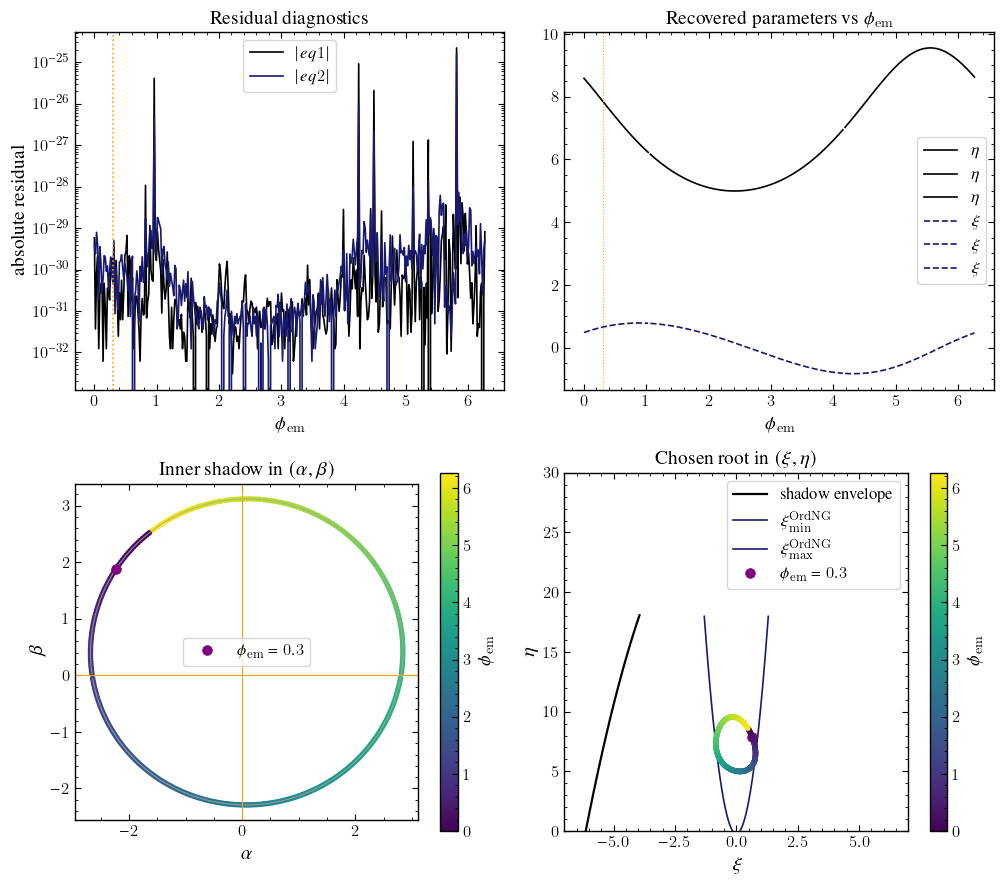

In [ ]:
metric_params_Val = (TCOMP(0.5), TCOMP(0.5))
inc_Val           = TCOMP(17.0) * TCOMP(pi) / TCOMP(180.0)

phi_em_Val  = TCOMP(0.3)
phi_obs_Val = zero(TCOMP)

nphi_Val  = 360
nxi_Val   = 61
neta_Val  = 61
nkeep_Val = 8

###########################################################################################
# Filename-safe tags
###########################################################################################

aVal = replace(string(Float64(metric_params_Val[1])), "." => "p")
LVal = replace(string(Float64(metric_params_Val[2])), "." => "p")

mkpath("./Data/Inner-Shadow")
mkpath("./Figures/Tests")

csvfile = "./Data/Inner-Shadow/Fig20d-KH-a-$aVal-L-$LVal.csv"
figfile = "./Figures/Tests/Fig20d-KH-a-$aVal-L-$LVal.png"

###########################################################################################
# Solve
###########################################################################################

shadow_cache_Val = make_shadow_cache(metric_params_Val)

pt = solve_inner_shadow_point_physical(
    inc_Val, metric_params_Val, phi_em_Val;
    phi_obs      = phi_obs_Val,
    shadow_cache = shadow_cache_Val,
    nxi          = nxi_Val,
    neta         = neta_Val,
    nkeep        = nkeep_Val
)

curve = solve_inner_shadow_curve_physical(
    inc_Val, metric_params_Val;
    nphi         = nphi_Val,
    phi_obs      = phi_obs_Val,
    shadow_cache = shadow_cache_Val,
    nxi          = nxi_Val,
    neta         = neta_Val,
    nkeep        = nkeep_Val
)

###########################################################################################
# Convert solver outputs to Float64 arrays
###########################################################################################

phis_plot = Float64.(curve.phi_em)

nphi = length(curve.phi_em)

eta_phys_plot = fill(NaN, nphi)
xi_phys_plot  = fill(NaN, nphi)

eq1_phys_plot = fill(NaN, nphi)
eq2_phys_plot = fill(NaN, nphi)

conv_phys = fill(false, nphi)

for i in eachindex(curve.phi_em)
    if curve.conv_n0[i]
        eta_phys_plot[i] = Float64(curve.eta_n0[i])
        xi_phys_plot[i]  = Float64(curve.xi_n0[i])
        eq1_phys_plot[i] = Float64(curve.eq1_n0[i])
        eq2_phys_plot[i] = Float64(curve.eq2_n0[i])
        conv_phys[i]     = true

    elseif curve.conv_n1[i]
        eta_phys_plot[i] = Float64(curve.eta_n1[i])
        xi_phys_plot[i]  = Float64(curve.xi_n1[i])
        eq1_phys_plot[i] = Float64(curve.eq1_n1[i])
        eq2_phys_plot[i] = Float64(curve.eq2_n1[i])
        conv_phys[i]     = true
    end
end

good_phys = findall(conv_phys)

alpha_phys_plot = Float64.(curve.alpha_phys)
beta_phys_plot  = Float64.(curve.beta_phys)

# Keep this stringified explicitly before writing
src_phys_plot = string.(curve.src_phys)

###########################################################################################
# Shadow-envelope curve in (xi, eta)
###########################################################################################

xi_sh_plot  = Float64.(shadow_cache_Val.xi_nodes)
eta_sh_plot = Float64.(shadow_cache_Val.eta_nodes)

###########################################################################################
# Ordinary-NG band edges in (xi, eta)
###########################################################################################

eta_band    = range(0.0, 30.0; length=600)
xi_min_band = Float64[]
xi_max_band = Float64[]

for eta in eta_band
    push!(xi_min_band, Float64(xi_Min_OrdNG(inc_Val, metric_params_Val, (TCOMP(eta), zero(TCOMP)))))
    push!(xi_max_band, Float64(xi_Max_OrdNG(inc_Val, metric_params_Val, (TCOMP(eta), zero(TCOMP)))))
end

###########################################################################################
# Single-point solution
###########################################################################################

sol_phys = pt.sol

eta_sol = shadow_sol_converged(sol_phys) ? Float64(sol_phys.eta) : NaN
xi_sol  = shadow_sol_converged(sol_phys) ? Float64(sol_phys.xi)  : NaN

alpha_phys_sol = isfinite(pt.alpha_phys) ? Float64(pt.alpha_phys) : NaN
beta_phys_sol  = isfinite(pt.beta_phys)  ? Float64(pt.beta_phys)  : NaN

###########################################################################################
# Helpers: spike detection
###########################################################################################

function isolated_spike_mask(y, valid_idx; jump_factor=20.0)
    bad = falses(length(y))
    length(valid_idx) < 3 && return bad

    yv = y[valid_idx]
    dy = abs.(diff(yv))
    dy_fin = filter(isfinite, dy)

    isempty(dy_fin) && return bad

    dy_med = median(dy_fin)
    (!isfinite(dy_med) || dy_med <= 0.0) && return bad

    for j in 2:length(valid_idx)-1
        k  = valid_idx[j]
        km = valid_idx[j-1]
        kp = valid_idx[j+1]

        if !(isfinite(y[km]) && isfinite(y[k]) && isfinite(y[kp]))
            continue
        end

        jl = abs(y[k]  - y[km])
        jr = abs(y[k]  - y[kp])
        jn = abs(y[kp] - y[km])

        if jl > jump_factor * dy_med &&
           jr > jump_factor * dy_med &&
           jn < jump_factor * dy_med
            bad[k] = true
        end
    end

    return bad
end

function isolated_spike_mask_2d(x, y, valid_idx; jump_factor=20.0)
    bad = falses(length(x))
    length(valid_idx) < 3 && return bad

    ds = Float64[]
    for j in 1:length(valid_idx)-1
        k1 = valid_idx[j]
        k2 = valid_idx[j+1]

        if isfinite(x[k1]) && isfinite(y[k1]) && isfinite(x[k2]) && isfinite(y[k2])
            push!(ds, hypot(x[k2] - x[k1], y[k2] - y[k1]))
        end
    end

    ds_fin = filter(isfinite, ds)
    isempty(ds_fin) && return bad

    ds_med = median(ds_fin)
    (!isfinite(ds_med) || ds_med <= 0.0) && return bad

    for j in 2:length(valid_idx)-1
        k  = valid_idx[j]
        km = valid_idx[j-1]
        kp = valid_idx[j+1]

        if !(isfinite(x[km]) && isfinite(y[km]) &&
             isfinite(x[k])  && isfinite(y[k])  &&
             isfinite(x[kp]) && isfinite(y[kp]))
            continue
        end

        jl = hypot(x[k]  - x[km], y[k]  - y[km])
        jr = hypot(x[k]  - x[kp], y[k]  - y[kp])
        jn = hypot(x[kp] - x[km], y[kp] - y[km])

        if jl > jump_factor * ds_med &&
           jr > jump_factor * ds_med &&
           jn < jump_factor * ds_med
            bad[k] = true
        end
    end

    return bad
end

###########################################################################################
# Clean isolated bad samples
###########################################################################################

bad_eta   = isolated_spike_mask(eta_phys_plot, good_phys; jump_factor=20.0)
bad_xi    = isolated_spike_mask(xi_phys_plot,  good_phys; jump_factor=20.0)
bad_ab    = isolated_spike_mask_2d(alpha_phys_plot, beta_phys_plot, good_phys; jump_factor=20.0)
bad_xieta = isolated_spike_mask_2d(xi_phys_plot, eta_phys_plot, good_phys; jump_factor=20.0)

bad_any = bad_eta .| bad_xi .| bad_ab .| bad_xieta
good_clean_mask = conv_phys .& .!bad_any

###########################################################################################
# Pack shadow-envelope and NG-band data into master table columns
###########################################################################################

xi_sh_col       = fill(NaN, nphi)
eta_sh_col      = fill(NaN, nphi)
eta_band_col    = fill(NaN, nphi)
xi_min_band_col = fill(NaN, nphi)
xi_max_band_col = fill(NaN, nphi)

for i in 1:min(nphi, length(xi_sh_plot))
    xi_sh_col[i]  = xi_sh_plot[i]
    eta_sh_col[i] = eta_sh_plot[i]
end

for i in 1:min(nphi, length(eta_band))
    eta_band_col[i]    = Float64(eta_band[i])
    xi_min_band_col[i] = xi_min_band[i]
    xi_max_band_col[i] = xi_max_band[i]
end

###########################################################################################
# Write one master CSV
###########################################################################################

df_master = DataFrame(
    idx            = collect(1:nphi),
    phi_em         = phis_plot,

    conv_phys      = conv_phys,
    src_phys       = src_phys_plot,

    eta_phys       = eta_phys_plot,
    xi_phys        = xi_phys_plot,
    eq1_phys       = eq1_phys_plot,
    eq2_phys       = eq2_phys_plot,

    alpha_phys     = alpha_phys_plot,
    beta_phys      = beta_phys_plot,

    bad_eta        = bad_eta,
    bad_xi         = bad_xi,
    bad_ab         = bad_ab,
    bad_xieta      = bad_xieta,
    bad_any        = bad_any,
    good_clean     = good_clean_mask,

    xi_sh          = xi_sh_col,
    eta_sh         = eta_sh_col,

    eta_band       = eta_band_col,
    xi_min_band    = xi_min_band_col,
    xi_max_band    = xi_max_band_col,

    a              = fill(Float64(metric_params_Val[1]), nphi),
    L              = fill(Float64(metric_params_Val[2]), nphi),
    inc_rad        = fill(Float64(inc_Val), nphi),
    inc_deg        = fill(Float64(inc_Val * 180 / pi), nphi),
    phi_obs        = fill(Float64(phi_obs_Val), nphi),

    phi_em_sol     = fill(Float64(phi_em_Val), nphi),
    xi_sol         = fill(xi_sol, nphi),
    eta_sol        = fill(eta_sol, nphi),
    alpha_phys_sol = fill(alpha_phys_sol, nphi),
    beta_phys_sol  = fill(beta_phys_sol, nphi),

    nphi_meta      = fill(nphi_Val, nphi),
    nxi_meta       = fill(nxi_Val, nphi),
    neta_meta      = fill(neta_Val, nphi),
    nkeep_meta     = fill(nkeep_Val, nphi)
)

CSV.write(csvfile, df_master)
println("Saved CSV to: $csvfile")

###########################################################################################
# Read the CSV back
###########################################################################################

# Force src_phys to come back as String, so there is no type ambiguity
df = CSV.read(csvfile, DataFrame; types=Dict(:src_phys => String))

###########################################################################################
# Reconstruct plotting arrays from the CSV
###########################################################################################

phis_plot       = Vector{Float64}(df.phi_em)
eta_phys_plot   = Vector{Float64}(df.eta_phys)
xi_phys_plot    = Vector{Float64}(df.xi_phys)
eq1_phys_plot   = Vector{Float64}(df.eq1_phys)
eq2_phys_plot   = Vector{Float64}(df.eq2_phys)
alpha_phys_plot = Vector{Float64}(df.alpha_phys)
beta_phys_plot  = Vector{Float64}(df.beta_phys)

conv_phys       = Vector{Bool}(df.conv_phys)
bad_any         = Vector{Bool}(df.bad_any)
good_clean_mask = Vector{Bool}(df.good_clean)

src_phys_plot   = Vector{String}(df.src_phys)

good_phys_clean = findall(good_clean_mask)

xi_sh_plot  = Vector{Float64}(df.xi_sh[isfinite.(df.xi_sh)])
eta_sh_plot = Vector{Float64}(df.eta_sh[isfinite.(df.eta_sh)])

eta_band    = Vector{Float64}(df.eta_band[isfinite.(df.eta_band)])
xi_min_band = Vector{Float64}(df.xi_min_band[isfinite.(df.xi_min_band)])
xi_max_band = Vector{Float64}(df.xi_max_band[isfinite.(df.xi_max_band)])

a_val          = df.a[1]
L_val          = df.L[1]
inc_rad        = df.inc_rad[1]
phi_em_sol     = df.phi_em_sol[1]
xi_sol         = df.xi_sol[1]
eta_sol        = df.eta_sol[1]
alpha_phys_sol = df.alpha_phys_sol[1]
beta_phys_sol  = df.beta_phys_sol[1]

###########################################################################################
# Helpers for plotting
###########################################################################################

function plot_segments(ax, x, y, idx; kwargs...)
    isempty(idx) && return

    start = 1
    for k in 2:length(idx)
        if idx[k] != idx[k-1] + 1
            seg = idx[start:k-1]
            ax.plot(x[seg], y[seg]; kwargs...)
            start = k
        end
    end

    seg = idx[start:end]
    ax.plot(x[seg], y[seg]; kwargs...)
end

function branch_sorted_by_angle(phi, alpha, beta, good_idx)
    phi_v   = Float64[]
    alpha_v = Float64[]
    beta_v  = Float64[]
    ang_v   = Float64[]

    for i in good_idx
        ai    = alpha[i]
        bi    = beta[i]
        phi_i = phi[i]

        if isfinite(ai) && isfinite(bi) && isfinite(phi_i)
            push!(phi_v, phi_i)
            push!(alpha_v, ai)
            push!(beta_v, bi)
            push!(ang_v, atan(bi, ai))
        end
    end

    p = sortperm(ang_v)

    return (
        phi   = phi_v[p],
        alpha = alpha_v[p],
        beta  = beta_v[p],
        ang   = ang_v[p]
    )
end

branch_phys = branch_sorted_by_angle(phis_plot, alpha_phys_plot, beta_phys_plot, good_phys_clean)

###########################################################################################
# Colormap setup
###########################################################################################

phi_min_cb = minimum(phis_plot)
phi_max_cb = maximum(phis_plot)

norm_cb = matplotlib.colors.Normalize(vmin=phi_min_cb, vmax=phi_max_cb)
cmap_cb = "viridis"

###########################################################################################
# Figure
###########################################################################################

colors = ["black", "midnightblue", "darkgreen", "firebrick", "orange", "purple", "magenta"]

linestyles = ["-", "--", ":", "-.",
              (0, (3, 1, 1, 1)),
              (0, (5, 2)),
              (0, (1, 1))]

linewidths = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]

n_rows, n_cols = 2, 2

fig = figure(figsize=(n_cols * fig_width * 1.5, n_rows * fig_height * 1.5))
gs  = fig.add_gridspec(n_rows, n_cols)

axes = Dict(
    "res_diag"          => fig.add_subplot(gs[1, 1]),
    "sol_params"        => fig.add_subplot(gs[1, 2]),
    "inner_sh_im_plane" => fig.add_subplot(gs[2, 1]),
    "inner_sh_NG"       => fig.add_subplot(gs[2, 2])
)

ax1 = axes["res_diag"]
ax2 = axes["sol_params"]
ax3 = axes["inner_sh_im_plane"]
ax4 = axes["inner_sh_NG"]

###########################################################################################
# Panel 1: Residual diagnostics
###########################################################################################

ax1.set_title("Residual diagnostics")
ax1.set_xlabel(L"\phi_{\rm em}")
ax1.set_ylabel("absolute residual")

if !isempty(good_phys_clean)
    ax1.semilogy(
        phis_plot[good_phys_clean],
        abs.(eq1_phys_plot[good_phys_clean]);
        color = colors[1],
        lw    = linewidths[2],
        label = L"|eq1|"
    )

    ax1.semilogy(
        phis_plot[good_phys_clean],
        abs.(eq2_phys_plot[good_phys_clean]);
        color = colors[2],
        lw    = linewidths[2],
        label = L"|eq2|"
    )
end

ax1.axvline(phi_em_sol, color=colors[5], lw=linewidths[2], ls=linestyles[3])
ax1.legend(loc="best")

###########################################################################################
# Panel 2: Recovered parameters vs phi_em
###########################################################################################

ax2.set_title(L"Recovered parameters vs $\phi_{\rm em}$")
ax2.set_xlabel(L"\phi_{\rm em}")

plot_segments(
    ax2, phis_plot, eta_phys_plot, good_phys_clean;
    color = colors[1],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\eta"
)

plot_segments(
    ax2, phis_plot, xi_phys_plot, good_phys_clean;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[2],
    label = L"\xi"
)

ax2.axvline(phi_em_sol, color=colors[5], lw=linewidths[1], ls=linestyles[3])
ax2.legend(loc="best")

###########################################################################################
# Panel 3: Physical inner shadow in (alpha, beta)
###########################################################################################

ax3.set_title(L"Inner shadow in $(\alpha,\beta)$")
ax3.set_xlabel(L"\alpha")
ax3.set_ylabel(L"\beta")

if !isempty(branch_phys.alpha)
    ax3.scatter(
        branch_phys.alpha,
        branch_phys.beta;
        c          = branch_phys.phi,
        cmap       = cmap_cb,
        norm       = norm_cb,
        s          = 16,
        linewidths = 0.0
    )

    ax3.plot(branch_phys.alpha, branch_phys.beta; color="0.65", lw=0.8, alpha=0.8)
end

if isfinite(alpha_phys_sol) && isfinite(beta_phys_sol)
    ax3.plot([alpha_phys_sol], [beta_phys_sol], "o", color=colors[6], ms=7, label=L"\phi_{\rm em}=0.3")
end

ax3.axhline(0.0, color=colors[5], lw=linewidths[1])
ax3.axvline(0.0, color=colors[5], lw=linewidths[1])
ax3.set_aspect("equal")

cb3 = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_cb, cmap=cmap_cb), ax=ax3)
cb3.set_label(L"\phi_{\rm em}")

ax3.legend(loc="best")

###########################################################################################
# Panel 4: Chosen physical root in (xi, eta), colored by phi_em
###########################################################################################

ax4.set_title(L"Chosen root in $(\xi,\eta)$")
ax4.set_xlabel(L"\xi")
ax4.set_ylabel(L"\eta")

ax4.plot(
    xi_sh_plot, eta_sh_plot;
    color = colors[1],
    lw    = linewidths[3],
    ls    = linestyles[1],
    label = "shadow envelope"
)

ax4.plot(
    xi_min_band, eta_band;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\xi_{\min}^{\rm OrdNG}"
)

ax4.plot(
    xi_max_band, eta_band;
    color = colors[2],
    lw    = linewidths[2],
    ls    = linestyles[1],
    label = L"\xi_{\max}^{\rm OrdNG}"
)

if !isempty(good_phys_clean)
    ax4.scatter(
        xi_phys_plot[good_phys_clean],
        eta_phys_plot[good_phys_clean];
        c          = phis_plot[good_phys_clean],
        cmap       = cmap_cb,
        norm       = norm_cb,
        s          = 16,
        linewidths = 0.0,
        zorder     = 3
    )

    plot_segments(ax4, xi_phys_plot, eta_phys_plot, good_phys_clean; color="0.65", lw=0.8, alpha=0.8)
end

if isfinite(xi_sol) && isfinite(eta_sol)
    ax4.plot([xi_sol], [eta_sol], "o", color=colors[6], ms=7, label=L"\phi_{\rm em}=0.3")
end

ax4.set_xlim([-7.0, 7.0])
ax4.set_ylim([0.0, 30.0])

cb4 = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_cb, cmap=cmap_cb), ax=ax4)
cb4.set_label(L"\phi_{\rm em}")

ax4.legend(loc="best")

###########################################################################################
# Save figure
###########################################################################################

fig.tight_layout()
savefig(figfile, dpi=150)

println("Saved figure to: $figfile")

In [52]:
###########################################################################################
# INNER SHADOW IMAGE METRICS
#
# Computes, from a single already-solved curve object:
#
#   1. Point-cloud statistics from all valid image-plane points
#      - mean / median / min / max radius
#      - mean / median / min / max alpha
#      - diameter_alpha, diameter_beta, ellipticity = diameter_alpha / diameter_beta
#
#   2. Chael-Johnson-Lupsasca (2021) contour moments
#      - area
#      - centroid_x, centroid_y
#      - centroid_offset
#      - semimajor_axis, semiminor_axis
#      - axis_ratio
#      - mean_radius_cjl
#      - eccentricity_cjl
#      - orientation
#
# No additional rootfinding is performed here.
###########################################################################################

using Statistics
using LinearAlgebra

###########################################################################################
# Polygon image moments for a closed contour
###########################################################################################

function polygon_image_moments(x, y)

    n = length(x)

    n == length(y) || error("x and y must have the same length")
    n >= 3 || error("Need at least 3 contour points")

    A2   = 0.0
    Cx_n = 0.0
    Cy_n = 0.0

    Ixx_o = 0.0
    Iyy_o = 0.0
    Ixy_o = 0.0

    for i in 1:n

        j = (i == n) ? 1 : i + 1

        xi = x[i]
        yi = y[i]
        xj = x[j]
        yj = y[j]

        cross = xi*yj - xj*yi

        A2   += cross
        Cx_n += (xi + xj) * cross
        Cy_n += (yi + yj) * cross

        Ixx_o += (yi*yi + yi*yj + yj*yj) * cross
        Iyy_o += (xi*xi + xi*xj + xj*xj) * cross
        Ixy_o += (2.0*xi*yi + xi*yj + xj*yi + 2.0*xj*yj) * cross
    end

    A = 0.5 * A2
    abs(A) > 0.0 || error("Contour has zero area")

    Cx = Cx_n / (6.0 * A)
    Cy = Cy_n / (6.0 * A)

    Ixx_o /= 12.0
    Iyy_o /= 12.0
    Ixy_o /= 24.0

    # If contour orientation is clockwise, flip to positive-area convention
    if A < 0.0
        A     = -A
        Ixx_o = -Ixx_o
        Iyy_o = -Iyy_o
        Ixy_o = -Ixy_o
    end

    # Second central moments / covariance matrix entries
    Sxx = Iyy_o / A - Cx*Cx
    Syy = Ixx_o / A - Cy*Cy
    Sxy = Ixy_o / A - Cx*Cy

    return (
        area       = A,
        centroid_x = Cx,
        centroid_y = Cy,
        cov        = [Sxx Sxy; Sxy Syy]
    )
end

###########################################################################################
# Single helper: compute all inner-shadow metrics from one solved curve
###########################################################################################

function inner_shadow_all_metrics(curve)

    alpha_pts = Float64[]
    beta_pts  = Float64[]

    alpha_ctr = Float64[]
    beta_ctr  = Float64[]
    ang_ctr   = Float64[]

    good = curve.conv_n1

    for i in eachindex(curve.phi_em)

        if good[i] &&
           isfinite(curve.alpha_up[i]) &&
           isfinite(curve.beta_up[i])

            a = Float64(curve.alpha_up[i])
            b = Float64(curve.beta_up[i])

            push!(alpha_pts, a)
            push!(beta_pts,  b)

            push!(alpha_ctr, a)
            push!(beta_ctr,  b)
            push!(ang_ctr,   atan(b, a))
        end

        if good[i] &&
           isfinite(curve.alpha_dn[i]) &&
           isfinite(curve.beta_dn[i])

            a = Float64(curve.alpha_dn[i])
            b = Float64(curve.beta_dn[i])

            push!(alpha_pts, a)
            push!(beta_pts,  b)

            push!(alpha_ctr, a)
            push!(beta_ctr,  b)
            push!(ang_ctr,   atan(b, a))
        end
    end

    isempty(alpha_pts) && return (
        n_points         = 0,

        mean_radius      = NaN,
        median_radius    = NaN,
        min_radius       = NaN,
        max_radius       = NaN,

        mean_alpha       = NaN,
        median_alpha     = NaN,
        min_alpha        = NaN,
        max_alpha        = NaN,

        diameter_alpha   = NaN,
        diameter_beta    = NaN,
        ellipticity      = NaN,

        area             = NaN,
        centroid_x       = NaN,
        centroid_y       = NaN,
        centroid_offset  = NaN,
        semimajor_axis   = NaN,
        semiminor_axis   = NaN,
        axis_ratio       = NaN,
        mean_radius_cjl  = NaN,
        eccentricity_cjl = NaN,
        orientation      = NaN
    )

    #######################################################################################
    # Point-cloud statistics
    #######################################################################################

    r = sqrt.(alpha_pts.^2 .+ beta_pts.^2)

    mean_radius   = mean(r)
    median_radius = median(r)
    min_radius    = minimum(r)
    max_radius    = maximum(r)

    mean_alpha    = mean(alpha_pts)
    median_alpha  = median(alpha_pts)
    min_alpha     = minimum(alpha_pts)
    max_alpha     = maximum(alpha_pts)

    Dalpha        = maximum(alpha_pts) - minimum(alpha_pts)
    Dbeta         = maximum(beta_pts)  - minimum(beta_pts)
    ell_old       = iszero(Dbeta) ? NaN : Dalpha / Dbeta

    #######################################################################################
    # Build contour sorted by polar angle
    #######################################################################################

    p = sortperm(ang_ctr)

    alpha_s = alpha_ctr[p]
    beta_s  = beta_ctr[p]

    if length(alpha_s) >= 2
        if alpha_s[1] == alpha_s[end] && beta_s[1] == beta_s[end]
            alpha_s = alpha_s[1:end-1]
            beta_s  = beta_s[1:end-1]
        end
    end

    #######################################################################################
    # CJL moment-based metrics
    #######################################################################################

    if length(alpha_s) < 3

        area            = NaN
        centroid_x      = NaN
        centroid_y      = NaN
        centroid_offset = NaN
        semimajor_axis  = NaN
        semiminor_axis  = NaN
        axis_ratio      = NaN
        mean_radius_cjl = NaN
        eccentricity_cjl = NaN
        orientation     = NaN

    else

        moms = polygon_image_moments(alpha_s, beta_s)

        S = Symmetric(moms.cov)
        vals, vecs = eigen(S)

        # ascending order
        λ2 = max(vals[1], 0.0)
        λ1 = max(vals[2], 0.0)

        v1 = vecs[:, 2]

        # For a filled ellipse, covariance eigenvalues are a^2/4 and b^2/4
        semimajor_axis = 2.0 * sqrt(λ1)
        semiminor_axis = 2.0 * sqrt(λ2)

        axis_ratio = iszero(semimajor_axis) ? NaN : semiminor_axis / semimajor_axis

        mean_radius_cjl = sqrt((semimajor_axis^2 + semiminor_axis^2) / 2.0)

        eccentricity_cjl = iszero(semimajor_axis) ? NaN :
                           sqrt(max(0.0, 1.0 - (semiminor_axis^2)/(semimajor_axis^2)))

        orientation = atan(v1[2], v1[1])

        area            = moms.area
        centroid_x      = moms.centroid_x
        centroid_y      = moms.centroid_y
        centroid_offset = hypot(centroid_x, centroid_y)
    end

    return (
        n_points         = length(alpha_pts),

        mean_radius      = mean_radius,
        median_radius    = median_radius,
        min_radius       = min_radius,
        max_radius       = max_radius,

        mean_alpha       = mean_alpha,
        median_alpha     = median_alpha,
        min_alpha        = min_alpha,
        max_alpha        = max_alpha,

        diameter_alpha   = Dalpha,
        diameter_beta    = Dbeta,
        ellipticity      = ell_old,

        area             = area,
        centroid_x       = centroid_x,
        centroid_y       = centroid_y,
        centroid_offset  = centroid_offset,
        semimajor_axis   = semimajor_axis,
        semiminor_axis   = semiminor_axis,
        axis_ratio       = axis_ratio,
        mean_radius_cjl  = mean_radius_cjl,
        eccentricity_cjl = eccentricity_cjl,
        orientation      = orientation
    )
end

inner_shadow_all_metrics (generic function with 1 method)

In [53]:
###########################################################################################
# Kerr inner-shadow diagnostics on a grid of spins and inclinations
#
# Uses the unified helper:
#     inner_shadow_all_metrics(curve)
#
# so all image metrics are computed from the already-solved curve without
# repeated processing or solver calls.
###########################################################################################

using PyPlot
using Statistics
using DataFrames
using CSV

###########################################################################################
# Parameter grid
###########################################################################################

spin_List = collect(range(TCOMP(EPS_HEUR), TCOMP(1.0 - EPS_HEUR); length=10))

inc_min = TCOMP(1e-4)
inc_max = TCOMP(pi)/TCOMP(2) - TCOMP(1e-4)

inc_List = collect(range(inc_min, inc_max; length=10))
inc_deg_List = Float64.(inc_List .* TCOMP(180.0) ./ TCOMP(pi))

###########################################################################################
# Storage
###########################################################################################

rows = NamedTuple[]

###########################################################################################
# Main loop
###########################################################################################

for a_Val in spin_List

    metric_params_Val = (a_Val, zero(TCOMP))   # Kerr
    shadow_cache_Val  = make_shadow_cache(metric_params_Val)

    for (j, inc_Val) in enumerate(inc_List)

        inc_deg = inc_deg_List[j]

        println("Solving Kerr inner shadow: a = ",
                Float64(a_Val),
                ", inc = ",
                inc_deg,
                " deg")

        ###############################################################################
        # Solve inner shadow curve (only expensive step)
        ###############################################################################

        curve = solve_inner_shadow_curve_physical(inc_Val, metric_params_Val;
                                                  nphi=360,
                                                  phi_obs=zero(TCOMP),
                                                  shadow_cache=shadow_cache_Val,
                                                  nxi=61,
                                                  neta=61,
                                                  nkeep=8)

        ###############################################################################
        # Compute all image metrics
        ###############################################################################

        metrics = inner_shadow_all_metrics(curve)

        frac_n0 = mean(curve.conv_n0)
        frac_n1 = mean(curve.conv_n1)

        ###############################################################################
        # Store results
        ###############################################################################

        push!(rows, (

            spin            = Float64(a_Val),
            inclination_deg = inc_deg,

            n_image_points  = metrics.n_points,

            mean_radius     = metrics.mean_radius,
            median_radius   = metrics.median_radius,
            min_radius      = metrics.min_radius,
            max_radius      = metrics.max_radius,

            mean_alpha      = metrics.mean_alpha,
            median_alpha    = metrics.median_alpha,
            min_alpha       = metrics.min_alpha,
            max_alpha       = metrics.max_alpha,

            diameter_alpha  = metrics.diameter_alpha,
            diameter_beta   = metrics.diameter_beta,
            ellipticity     = metrics.ellipticity,

            centroid_x      = metrics.centroid_x,
            centroid_y      = metrics.centroid_y,
            centroid_offset = metrics.centroid_offset,

            semimajor_axis  = metrics.semimajor_axis,
            semiminor_axis  = metrics.semiminor_axis,
            axis_ratio      = metrics.axis_ratio,

            mean_radius_cjl = metrics.mean_radius_cjl,
            eccentricity_cjl = metrics.eccentricity_cjl,
            orientation     = metrics.orientation,

            frac_conv_n0    = frac_n0,
            frac_conv_n1    = frac_n1
        ))
    end
end

###########################################################################################
# DataFrame + CSV export
###########################################################################################

df = DataFrame(rows)

println("\nDataFrame preview:")
show(df, allrows=true, allcols=true)

csv_path = "./Figures/Tests/Kerr-Inner-Shadow-Diagnostics.csv"
CSV.write(csv_path, df)

println("\nSaved CSV to: ", csv_path)

###########################################################################################
# Diagnostic plots
###########################################################################################

fig = figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

spin_vals = unique(df.spin)

###########################################################################################
# Mean radius vs inclination
###########################################################################################

ax1.set_title("Mean radius vs inclination")
ax1.set_xlabel("inclination [deg]")
ax1.set_ylabel("mean radius")

for a in spin_vals
    sub = df[df.spin .== a, :]
    ax1.plot(sub.inclination_deg, sub.mean_radius, "o-", lw=2,
             label="a=$(round(a, digits=3))")
end

ax1.legend(loc="best", fontsize=8)

###########################################################################################
# Mean alpha vs inclination
###########################################################################################

ax2.set_title("Mean alpha vs inclination")
ax2.set_xlabel("inclination [deg]")
ax2.set_ylabel("mean alpha")

for a in spin_vals
    sub = df[df.spin .== a, :]
    ax2.plot(sub.inclination_deg, sub.mean_alpha, "o-", lw=2,
             label="a=$(round(a, digits=3))")
end

ax2.legend(loc="best", fontsize=8)

###########################################################################################
# Ellipticity vs inclination
###########################################################################################

ax3.set_title("Ellipticity vs inclination")
ax3.set_xlabel("inclination [deg]")
ax3.set_ylabel(L"D_\alpha / D_\beta")

for a in spin_vals
    sub = df[df.spin .== a, :]
    ax3.plot(sub.inclination_deg, sub.ellipticity, "o-", lw=2,
             label="a=$(round(a, digits=3))")
end

ax3.legend(loc="best", fontsize=8)

###########################################################################################
# Heatmap-like scatter of CJL eccentricity
###########################################################################################

ax4.set_title("CJL eccentricity over parameter grid")
ax4.set_xlabel("spin")
ax4.set_ylabel("inclination [deg]")

sc = ax4.scatter(df.spin, df.inclination_deg;
                 c=df.eccentricity_cjl,
                 s=120)

fig.colorbar(sc, ax=ax4)

###########################################################################################

fig.tight_layout()
savefig("./Figures/Tests/Fig21-Kerr-Inner-Shadow-Diagnostics-Grid.png", dpi=150)

Solving Kerr inner shadow: a = 0.001, inc = 0.005729577951308232 deg
Solving Kerr inner shadow: a = 0.001, inc = 10.004456338406573 deg
Solving Kerr inner shadow: a = 0.001, inc = 20.00318309886184 deg
Solving Kerr inner shadow: a = 0.001, inc = 30.001909859317102 deg
Solving Kerr inner shadow: a = 0.001, inc = 40.000636619772365 deg
Solving Kerr inner shadow: a = 0.001, inc = 49.999363380227635 deg
Solving Kerr inner shadow: a = 0.001, inc = 59.9980901406829 deg
Solving Kerr inner shadow: a = 0.001, inc = 69.99681690113816 deg
Solving Kerr inner shadow: a = 0.001, inc = 79.99554366159343 deg
Solving Kerr inner shadow: a = 0.001, inc = 89.99427042204869 deg
Solving Kerr inner shadow: a = 0.11188888888888888, inc = 0.005729577951308232 deg


LoadError: type NamedTuple has no field alpha_up